# Использование математических методов для оптимизации всепогодного портфеля

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import ast
import csv
import hashlib
import importlib.metadata as md
import json
import pickle
import re
import sys
import tempfile
import warnings
from collections import defaultdict
from collections.abc import Iterable, Mapping, Sequence
from pathlib import Path
from types import CodeType
from typing import Any, Callable, Literal, TypeVar, cast
from functools import partial


import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
import empyrical as empirical
import ipytest
import pytest
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.optimize import differential_evolution, minimize
from tqdm.auto import tqdm


import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.ticker import FuncFormatter, StrMethodFormatter


try:
    from IPython.display import display as display_figure
except ImportError:
    display_figure: Callable[[Figure], None] | None = None


warnings.filterwarnings("ignore", message="Workbook contains no default style")
warnings.filterwarnings("ignore", message="The test statistic is outside")

In [3]:
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
})

try:
    notebook_shell = get_ipython()
except NameError:
    notebook_shell = None

if notebook_shell is not None:
    notebook_shell.run_line_magic("matplotlib", "inline")

## 1. Инфраструктура и аналитические функции

Расчеты имеют ретроспективную и объяснительную цель: они описывают устойчивость диапазонов весов и факторные связи на исторических данных, а не строят торговый прогноз. Поэтому тесты, независимая сверка оптимизаторов, bootstrap и скользящие окна контролируют вычислительную и выборочную устойчивость, но не заменяют вневыборочную валидацию будущей доходности.

### 1.1. Чтение файлов и кэширование

In [4]:
def _detect_encoding(
    file_path: str | Path,
    encodings_to_try: Iterable[str] | None = None,
    sample_size: int = 10_000,
) -> str:
    """Определяет кодировку текстового файла по префиксу из ``sample_size`` байт.

    Сначала проверяет наличие UTF-8 BOM; если BOM отсутствует,
    пробует ``utf-8`` (чтобы не спутать с ``utf-8-sig``), затем
    остальные кодировки из списка.

    Args:
        file_path: Путь к файлу.
        encodings_to_try: Последовательность кодировок для проверки.
            По умолчанию: ``("utf-8", "cp1251", "windows-1251")``.
            ``utf-8-sig`` проверяется автоматически по BOM.
        sample_size: Сколько байт прочитать из начала файла.

    Returns:
        Имя успешной кодировки.

    Raises:
        UnicodeError: Если ни одна из кодировок не подошла.
    """
    raw = Path(file_path).read_bytes()[:sample_size]

    if raw.startswith(b"\xef\xbb\xbf"):
        return "utf-8-sig"

    if encodings_to_try is None:
        encodings_to_try = ("utf-8", "cp1251", "windows-1251")

    for enc in encodings_to_try:
        try:
            raw.decode(enc)
            return enc
        except UnicodeDecodeError:
            continue

    raise UnicodeError(
        f"Не удалось определить кодировку файла: {file_path}. "
        f"Передайте encoding явно."
    )

def _detect_separator(sample_text: str, delimiters: str = ";,\t|") -> str:
    """Определяет разделитель CSV через ``csv.Sniffer`` с fallback на эвристику.

    Args:
        sample_text: Фрагмент текста из начала файла (несколько строк).
        delimiters: Строка с кандидатами-разделителями.

    Returns:
        Выявленный разделитель.
    """
    try:
        dialect = csv.Sniffer().sniff(sample_text, delimiters=delimiters)
        return dialect.delimiter
    except csv.Error:
        pass

    lines = [line for line in sample_text.splitlines() if line.strip()]
    if not lines:
        return ";"

    counts = {sep: sum(line.count(sep) for line in lines[:10]) for sep in delimiters}
    best_sep = max(counts, key=counts.get)
    return best_sep if counts[best_sep] > 0 else ";"

def _detect_decimal(sample_lines: list[str], sep: str) -> str:
    """Эвристика для определения десятичного разделителя.

    Анализирует токены, похожие на числа, и считает частоту ``.`` и ``,``.
    Если разделитель столбцов ``;``, предпочитается ``,`` как десятичный.

    Args:
        sample_lines: Список строк из файла.
        sep: Разделитель столбцов.

    Returns:
        ``","`` или ``"."``.
    """
    counts: dict[str, int] = {",": 0, ".": 0}
    number_pattern = re.compile(r"[-+]?\d[\d\s]*[.,]\d+")

    for line in sample_lines:
        for part in line.split(sep):
            token = part.strip()
            if not token or not number_pattern.search(token):
                continue

            if "," in token and "." in token:
                counts["," if token.rfind(",") > token.rfind(".") else "."] += 1
            elif "," in token:
                counts[","] += 1
            elif "." in token:
                counts["."] += 1

    if counts[","] == 0 and counts["."] == 0:
        return "," if sep == ";" else "."

    return "," if counts[","] > counts["."] else "."

def read_dataframe(
    file_path: str | Path,
    *,
    sep: str | None = None,
    decimal: str | None = None,
    encoding: str | None = None,
    header: int | None = 0,
    verbose: bool = True,
) -> pd.DataFrame:
    """Читает CSV/TSV с автоматическим определением кодировки, разделителя и decimal.

    Args:
        file_path: Путь к файлу.
        sep: Разделитель столбцов. Если *None*, определяется автоматически.
        decimal: Десятичный разделитель. Если *None*, определяется автоматически.
        encoding: Кодировка. Если *None*, определяется автоматически.
        header: Номер строки с заголовками (передаётся в ``pd.read_csv``).
        verbose: Печатать ли диагностику в stdout.

    Returns:
        Загруженный ``pd.DataFrame`` с зачищенными именами столбцов.

    Raises:
        FileNotFoundError: Файл не существует.
        ValueError: Файл пуст или не содержит читаемых строк.
        RuntimeError: Ошибка парсинга, включая несоответствие переданных параметров.
    """
    path = Path(file_path)

    if not path.exists():
        raise FileNotFoundError(f"Файл не найден: {path}")
    if path.stat().st_size == 0:
        raise ValueError(f"Файл пустой: {path}")

    detected_encoding = encoding or _detect_encoding(path)
    sample_text = path.read_text(encoding=detected_encoding, errors="replace")[:20_000]
    sample_lines = [line for line in sample_text.splitlines() if line.strip()]

    if not sample_lines:
        raise ValueError(f"Файл не содержит читаемых строк: {path}")

    detected_sep = sep or _detect_separator("\n".join(sample_lines[:10]))
    lines_for_decimal = sample_lines[1:11] if len(sample_lines) > 1 else sample_lines[:10]
    detected_decimal = decimal or _detect_decimal(lines_for_decimal, detected_sep)

    if verbose:
        print(
            f"Чтение файла: {path}\n"
            f"Определенные параметры: "
            f"разделитель='{detected_sep}', десятичный='{detected_decimal}', "
            f"кодировка='{detected_encoding}'"
        )

    try:
        df = pd.read_csv(
            path,
            encoding=detected_encoding,
            sep=detected_sep,
            decimal=detected_decimal,
            header=header,
            na_values=["", " ", "NA", "N/A", "NULL", "null", "None", "NaN"],
            keep_default_na=True,
        )
    except pd.errors.ParserError as exc:
        raise ValueError(
            f"Ошибка парсинга файла {path}. "
            f"Проверьте sep='{detected_sep}', decimal='{detected_decimal}', "
            f"encoding='{detected_encoding}'."
        ) from exc
    except Exception as exc:
        raise RuntimeError(f"Ошибка при чтении файла {path}: {exc}") from exc

    df.columns = [
        col.strip() if isinstance(col, str) else col for col in df.columns
    ]

    if verbose:
        print(f"Успешно прочитано: {len(df)} строк, {len(df.columns)} столбцов")
        print(f"Столбцы: {list(df.columns)}\n")

    return df

In [5]:
T = TypeVar("T")
CachePolicy = Literal["use", "refresh", "off"]
CACHE_DIR = Path("cache")
CACHE_FORMAT_VERSION = "2"
CACHE_DIR.mkdir(exist_ok=True)


def run_notebook_tests(test_pattern: str) -> int:
    """Запускает выбранные notebook-тесты во временной папке проекта.

    Args:
        test_pattern: Pytest-выражение для выбора группы тестов.

    Returns:
        Код завершения pytest.

    Raises:
        ipytest.Error: Хотя бы один выбранный тест завершился неуспешно.

    Side Effects:
        Создаёт временные файлы pytest в ``cache/pytest-tmp``.
    """
    pytest_tmp_dir = (CACHE_DIR / "pytest-tmp").resolve()
    pytest_tmp_dir.mkdir(parents=True, exist_ok=True)
    ipytest.autoconfig(magics=False, raise_on_error=True)
    return int(
        ipytest.run(
            "-q",
            "-p",
            "no:cacheprovider",
            "--basetemp",
            str(pytest_tmp_dir),
            "-k",
            test_pattern,
        )
    )

def _stable_constant_payload(value: Any) -> Any:
    """Нормализует константы объекта кода без привязки к ячейке IPython."""
    if isinstance(value, CodeType):
        return ("code", _stable_code_payload(value))
    if isinstance(value, tuple):
        return ("tuple", tuple(_stable_constant_payload(item) for item in value))
    if isinstance(value, frozenset):
        normalized = (_stable_constant_payload(item) for item in value)
        return ("frozenset", tuple(sorted(normalized, key=repr)))
    return value

def _stable_code_payload(code: CodeType) -> tuple[Any, ...]:
    """Возвращает семантические поля bytecode без имени файла и номеров строк."""
    return (
        code.co_name,
        code.co_qualname,
        code.co_argcount,
        code.co_posonlyargcount,
        code.co_kwonlyargcount,
        code.co_nlocals,
        code.co_stacksize,
        code.co_flags,
        code.co_code,
        tuple(_stable_constant_payload(item) for item in code.co_consts),
        code.co_names,
        code.co_varnames,
        code.co_freevars,
        code.co_cellvars,
        getattr(code, "co_exceptiontable", b""),
    )

def _cache_fingerprint(
    func: Callable[..., Any],
    kwargs: Mapping[str, Any],
    *,
    cache_version: str,
) -> str:
    """Строит устойчивый ключ по версии, функции и входным аргументам.

    Служебное имя файла ячейки IPython и номера строк не входят в ключ,
    поэтому повторный запуск неизменённой функции не создаёт новый кэш.

    Args:
        func: Кэшируемая функция.
        kwargs: Аргументы вычисления, включая DataFrame и массивы.
        cache_version: Явная версия методологии расчёта.

    Returns:
        Первые 16 символов SHA-256.

    Raises:
        TypeError: Аргументы невозможно сериализовать через pickle.
    """
    code = getattr(func, "__code__", None)
    code_payload = (
        _stable_code_payload(code) if isinstance(code, CodeType) else repr(type(func))
    )
    payload = (
        CACHE_FORMAT_VERSION,
        cache_version,
        getattr(func, "__module__", ""),
        getattr(func, "__qualname__", repr(func)),
        code_payload,
        getattr(func, "__defaults__", None),
        getattr(func, "__kwdefaults__", None),
        dict(kwargs),
    )
    try:
        serialized = pickle.dumps(payload, protocol=pickle.HIGHEST_PROTOCOL)
    except (pickle.PickleError, TypeError) as error:
        raise TypeError("Cache arguments must be pickle-serializable") from error
    return hashlib.sha256(serialized).hexdigest()[:16]

def _validate_cache_name(cache_name: str) -> None:
    """Проверяет, что логическое имя безопасно для пути и glob-шаблона."""
    is_simple_name = bool(
        cache_name
        and Path(cache_name).name == cache_name
        and re.fullmatch(r"[A-Za-z0-9][A-Za-z0-9_.-]*", cache_name)
    )
    if not is_simple_name:
        raise ValueError(
            "cache_name must be a simple name without path components or glob patterns"
        )

def run_or_load(
    cache_name: str,
    func: Callable[..., T],
    *,
    cache_version: str = "1",
    cache_policy: CachePolicy = "use",
    **kwargs: Any,
) -> T:
    """Выполняет функцию согласно выбранной политике pickle-кэша.

    Имя файла включает fingerprint версии, байткода функции и всех аргументов.
    Изменение данных или параметров поэтому не может молча загрузить прежний
    результат. Запись выполняется атомарно через временный файл.

    Args:
        cache_name: Логическое имя кэша без пути и расширения.
        func: Функция, вызываемая как ``func(**kwargs)``.
        cache_version: Версия методологии; увеличивается при изменении
            зависимых расчётных функций.
        cache_policy: ``"use"`` загружает подходящий кэш или создаёт новый;
            ``"refresh"`` всегда пересчитывает и перезаписывает текущий файл;
            ``"off"`` выполняет расчёт без чтения и записи кэша.
        **kwargs: Аргументы вычисления и часть fingerprint.

    Returns:
        Результат функции согласно выбранной политике.

    Raises:
        ValueError: Недопустимое имя кэша или значение ``cache_policy``.

    Side Effects:
        В режимах ``"use"`` и ``"refresh"`` может читать или атомарно
        создавать pickle-файл в ``CACHE_DIR``.
    """
    _validate_cache_name(cache_name)
    if cache_policy not in ("use", "refresh", "off"):
        raise ValueError("cache_policy must be one of: 'use', 'refresh', 'off'")

    if cache_policy == "off":
        print(f"Кэш отключён для расчёта: {cache_name}")
        return func(**kwargs)

    fingerprint = _cache_fingerprint(func, kwargs, cache_version=cache_version)
    cache_path = CACHE_DIR / f"{cache_name}_{fingerprint}.pkl"
    if cache_policy == "use" and cache_path.exists():
        try:
            with cache_path.open("rb") as file:
                result = pickle.load(file)
        except (EOFError, pickle.UnpicklingError, AttributeError, ImportError, IndexError):
            warnings.warn(
                f"Повреждённый кэш будет пересчитан: {cache_path}",
                RuntimeWarning,
                stacklevel=2,
            )
        else:
            print(f"Загружен кэш: {cache_path}")
            return cast(T, result)

    result = func(**kwargs)
    temporary_path: Path | None = None
    try:
        with tempfile.NamedTemporaryFile(
            mode="wb",
            dir=CACHE_DIR,
            prefix=f".{cache_name}_",
            suffix=".tmp",
            delete=False,
        ) as temporary_file:
            temporary_path = Path(temporary_file.name)
            pickle.dump(result, temporary_file, protocol=pickle.HIGHEST_PROTOCOL)
        temporary_path.replace(cache_path)
    finally:
        if temporary_path is not None and temporary_path.exists():
            temporary_path.unlink()

    action = "Обновлён" if cache_policy == "refresh" else "Сохранён"
    print(f"{action} кэш: {cache_path}")
    return result

def clear_cache(cache_name: str | None = None) -> int:
    """Удаляет расчётные pickle-файлы из ``CACHE_DIR``.

    Args:
        cache_name: Логическое имя для выборочной очистки. Если ``None``,
            удаляются все ``*.pkl``. Временная папка pytest не затрагивается.

    Returns:
        Количество удалённых файлов.

    Raises:
        ValueError: ``cache_name`` содержит путь или glob-символы.

    Side Effects:
        Удаляет подходящие ``*.pkl``-файлы из ``CACHE_DIR``.
    """
    if cache_name is None:
        pattern = "*.pkl"
        target = "весь расчётный кэш"
    else:
        _validate_cache_name(cache_name)
        pattern = f"{cache_name}_*.pkl"
        target = cache_name

    removed = 0
    for cache_path in CACHE_DIR.glob(pattern):
        if not cache_path.is_file():
            continue
        try:
            cache_path.unlink()
        except FileNotFoundError:
            continue
        removed += 1

    print(f"Очищен кэш ({target}): удалено файлов — {removed}")
    return removed

In [6]:
@pytest.mark.parametrize(
    ("sample", "expected"),
    [
        ("a;b;c\n1;2;3\n", ";"),
        ("a,b,c\n1,2,3\n", ","),
        ("a\tb\tc\n1\t2\t3\n", "\t"),
        ("", ";"),
    ],
)
def test_block_1_1_detect_separator(sample: str, expected: str) -> None:
    assert _detect_separator(sample) == expected

@pytest.mark.parametrize(
    ("lines", "separator", "expected"),
    [
        (["price;value", "1,5;2,3"], ";", ","),
        (["price,value", "1.5,2.3"], ",", "."),
        (["a;b", "c;d"], ";", ","),
    ],
)
def test_block_1_1_detect_decimal(
    lines: list[str], separator: str, expected: str
) -> None:
    assert _detect_decimal(lines, separator) == expected

def test_block_1_1_detect_encoding(tmp_path: Path) -> None:
    utf8_file = tmp_path / "utf8.csv"
    bom_file = tmp_path / "bom.csv"
    cp1251_file = tmp_path / "cp1251.csv"
    utf8_file.write_text("col;value\n1;2\n", encoding="utf-8")
    bom_file.write_bytes(b"\xef\xbb\xbfcol;value\n1;2\n")
    cp1251_file.write_bytes("кол;значение\n1;2\n".encode("cp1251"))

    assert _detect_encoding(utf8_file) == "utf-8"
    assert _detect_encoding(bom_file) == "utf-8-sig"
    assert _detect_encoding(cp1251_file) == "cp1251"

def test_block_1_1_read_dataframe_parses_and_cleans_columns(tmp_path: Path) -> None:
    data_file = tmp_path / "returns.csv"
    data_file.write_text(" name ; value \nAlice;1,5\nBob;NA\n", encoding="utf-8")

    frame = read_dataframe(data_file, verbose=False)

    assert list(frame.columns) == ["name", "value"]
    assert frame.loc[0, "value"] == pytest.approx(1.5)
    assert pd.isna(frame.loc[1, "value"])

def test_block_1_1_read_dataframe_rejects_missing_and_empty_files(tmp_path: Path) -> None:
    empty_file = tmp_path / "empty.csv"
    empty_file.write_text("", encoding="utf-8")

    with pytest.raises(FileNotFoundError):
        read_dataframe(tmp_path / "missing.csv", verbose=False)
    with pytest.raises(ValueError, match="пустой"):
        read_dataframe(empty_file, verbose=False)

def test_block_1_1_run_or_load_uses_parameter_fingerprint(
    tmp_path: Path,
    monkeypatch: pytest.MonkeyPatch,
) -> None:
    """Кэш переиспользуется только для тех же данных, параметров и версии."""
    monkeypatch.setitem(globals(), "CACHE_DIR", tmp_path)
    calls = 0

    def compute(*, value: int) -> int:
        """Удваивает значение и считает фактические вычисления."""
        nonlocal calls
        calls += 1
        return value * 2

    assert run_or_load("result", compute, value=3) == 6
    assert run_or_load("result", compute, value=3) == 6
    assert calls == 1

    assert run_or_load("result", compute, value=4) == 8
    assert run_or_load("result", compute, value=3, cache_version="2") == 6
    assert calls == 3
    assert len(list(tmp_path.glob("result_*.pkl"))) == 3

def test_block_1_1_run_or_load_supports_cache_policies(
    tmp_path: Path,
    monkeypatch: pytest.MonkeyPatch,
) -> None:
    """Политики use, refresh и off управляют чтением и записью независимо."""
    monkeypatch.setitem(globals(), "CACHE_DIR", tmp_path)
    calls = 0

    def compute(*, value: int) -> int:
        nonlocal calls
        calls += 1
        return value * calls

    assert run_or_load("policy", compute, value=3, cache_policy="use") == 3
    assert run_or_load("policy", compute, value=3, cache_policy="use") == 3
    assert calls == 1

    assert run_or_load("policy", compute, value=3, cache_policy="refresh") == 6
    assert run_or_load("policy", compute, value=3, cache_policy="use") == 6
    assert calls == 2

    assert run_or_load("policy", compute, value=3, cache_policy="off") == 9
    assert run_or_load("policy", compute, value=3, cache_policy="use") == 6
    assert calls == 3
    assert len(list(tmp_path.glob("policy_*.pkl"))) == 1

    with pytest.raises(ValueError, match="cache_policy"):
        run_or_load("policy", compute, value=3, cache_policy="invalid")

def test_block_1_1_clear_cache_is_scoped_to_pickle_files(
    tmp_path: Path,
    monkeypatch: pytest.MonkeyPatch,
) -> None:
    """Очистка поддерживает логическое имя и не затрагивает служебные файлы."""
    monkeypatch.setitem(globals(), "CACHE_DIR", tmp_path)
    for filename in ("result_a.pkl", "result_b.pkl", "other_a.pkl"):
        (tmp_path / filename).write_bytes(b"cache")
    (tmp_path / "notes.txt").write_text("keep", encoding="utf-8")
    (tmp_path / "pytest-tmp").mkdir()

    assert clear_cache("result") == 2
    assert sorted(path.name for path in tmp_path.glob("*.pkl")) == ["other_a.pkl"]
    assert clear_cache() == 1
    assert (tmp_path / "notes.txt").exists()
    assert (tmp_path / "pytest-tmp").is_dir()

def test_block_1_1_cache_fingerprint_ignores_cell_filename() -> None:
    """Одинаковый код в разных ячейках должен иметь одинаковый fingerprint."""
    function_source = "def compute(*, value: int) -> int:\n    return value * 2\n"
    first_namespace = {"__name__": "cache_test"}
    second_namespace = {"__name__": "cache_test"}
    exec(compile(function_source, "<ipython-input-1>", "exec"), first_namespace)
    exec(compile(function_source, "<ipython-input-99>", "exec"), second_namespace)

    first = _cache_fingerprint(
        first_namespace["compute"], {"value": 3}, cache_version="1"
    )
    second = _cache_fingerprint(
        second_namespace["compute"], {"value": 3}, cache_version="1"
    )

    assert first == second

def test_block_1_1_run_or_load_rejects_path_components(tmp_path: Path) -> None:
    """Не допускает выход имени кэша за пределы CACHE_DIR."""
    with pytest.raises(ValueError, match="path components"):
        run_or_load("../result", lambda: 1)

In [7]:
run_notebook_tests("test_block_1_1")

...............                                                                              [100%]


0

### 1.2. Загрузка наборов рыночных данных

In [8]:
BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "data"
OFZ_DIR = DATA_DIR / "ofz"
GOLD_DIR = DATA_DIR / "золото"
EQUITY_DIR = DATA_DIR / "индексы_акций"
BOND_DIR = DATA_DIR / "индексы_облигаций"


def load_moex_index(
    file_path: str | Path,
    *,
    ticker_col: str = "ID",
    date_col: str = "TRADEDATE",
    value_col: str = "CLOSE",
    date_format: str = "%Y-%m-%d",
    verbose: bool = False,
) -> pd.DataFrame:
    """Загружает индекс MOEX из CSV, оставляя только тикер, дату и цену закрытия.

    Результат приводится к единому формату ``[TICKER, TRADEDATE, CLOSE]``,
    сортировка по дате, без пропусков.

    Args:
        file_path: Путь к CSV-файлу.
        ticker_col: Имя столбца с тикером в исходном файле.
        date_col: Имя столбца с датой.
        value_col: Имя столбца со значением (обычно ``CLOSE``).
        date_format: Формат даты для ``pd.to_datetime``.
        verbose: Печатать ли диагностику ``read_dataframe``.

    Returns:
        DataFrame со столбцами ``TICKER``, ``TRADEDATE``, ``CLOSE``.
    """
    df = read_dataframe(file_path, verbose=verbose)
    df = df[[ticker_col, date_col, value_col]].rename(
        columns={ticker_col: "TICKER", date_col: "TRADEDATE", value_col: "CLOSE"}
    )
    df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"], format=date_format)
    df["TICKER"] = df["TICKER"].astype("string")
    return df.dropna().sort_values("TRADEDATE").reset_index(drop=True)

def load_all_files_in_dir(
    directory: str | Path,
    loader_func: Callable[..., pd.DataFrame],
    file_pattern: str = "*.csv",
    verbose: bool = False,
    **loader_kwargs: Any,
) -> dict[str, pd.DataFrame]:
    """Загружает все файлы из папки, соответствующие ``file_pattern``.

    Args:
        directory: Путь к директории.
        loader_func: Функция-загрузчик одного файла. Первым аргументом
            должен принимать путь (``str | Path``).
        file_pattern: Glob-шаблон для поиска файлов.
        verbose: Передаётся в ``loader_func`` как ``verbose=verbose``.
        **loader_kwargs: Дополнительные аргументы, передаваемые в ``loader_func``.

    Returns:
        Словарь ``{имя_файла_без_расширения: DataFrame}``.
    """
    directory = Path(directory)
    return {
        f.stem: loader_func(f, verbose=verbose, **loader_kwargs)
        for f in sorted(directory.glob(file_pattern))
    }

In [9]:
@pytest.fixture
def block_1_2_data_dir(tmp_path: Path) -> Path:
    data_dir = tmp_path / "indices"
    data_dir.mkdir()
    (data_dir / "z.csv").write_text(
        "SECID;TRADEDATE;CLOSE\nIMOEX;2024-01-03;101\nIMOEX;2024-01-02;100\n",
        encoding="utf-8",
    )
    (data_dir / "a.csv").write_text(
        "SECID;TRADEDATE;CLOSE\nMOEX;2024-01-02;99\nMOEX;2024-01-03;\n",
        encoding="utf-8",
    )
    return data_dir

def test_block_1_2_load_moex_index_standardizes_columns(
    block_1_2_data_dir: Path,
) -> None:
    frame = load_moex_index(block_1_2_data_dir / "z.csv", ticker_col="SECID")

    assert list(frame.columns) == ["TICKER", "TRADEDATE", "CLOSE"]
    assert frame["TRADEDATE"].is_monotonic_increasing
    assert frame["TICKER"].dtype.name == "string"

def test_block_1_2_load_moex_index_rejects_unknown_column(
    block_1_2_data_dir: Path,
) -> None:
    with pytest.raises(KeyError):
        load_moex_index(block_1_2_data_dir / "z.csv", ticker_col="UNKNOWN")

def test_block_1_2_load_all_files_is_sorted_and_filtered(
    block_1_2_data_dir: Path,
) -> None:
    (block_1_2_data_dir / "skip.txt").write_text("not csv", encoding="utf-8")
    loaded = load_all_files_in_dir(
        block_1_2_data_dir,
        lambda path, **_: read_dataframe(path, verbose=False),
    )

    assert list(loaded) == ["a", "z"]
    assert loaded["a"].shape == (2, 3)

def test_block_1_2_load_all_files_returns_empty_dict(tmp_path: Path) -> None:
    assert load_all_files_in_dir(tmp_path, lambda path, **_: pd.DataFrame()) == {}

In [10]:
run_notebook_tests("test_block_1_2")

....                                                                                         [100%]


0

### 1.3. Метрики доходности и риска портфеля

Во всех расчетах вектор весов трактуется как начальное распределение капитала в начале соответствующего временного окна. После покупки ребалансировка не проводится: количество единиц каждого актива остаётся постоянным, а фактические доли активов свободно дрейфуют. Повторяющиеся торговые издержки отсутствуют; разовые издержки первоначальной покупки в базовой модели не учитываются.

In [11]:
TRADING_DAYS = 252


def _validate_inputs(
    asset_returns: pd.DataFrame,
    weights: np.ndarray,
    *,
    check_long_only: bool = True,
    weight_tolerance: float = 1e-8,
) -> tuple[pd.DataFrame, np.ndarray]:
    """Базовая валидация входных данных для расчёта метрик портфеля.

    Args:
        asset_returns: DataFrame с простыми дневными доходностями активов.
            Все столбцы должны быть числовыми, без пропусков,
            значения >= -1.0.
        weights: Вектор весов. Длина должна совпадать с числом столбцов,
            сумма равна 1.0 (в пределах ``weight_tolerance``), без NaN.
        check_long_only: Если *True*, веса должны быть неотрицательными.
        weight_tolerance: Допуск для проверки суммы весов.

    Returns:
        Кортеж ``(asset_returns, weights)`` с нормализованными весами.

    Raises:
        TypeError: ``asset_returns`` не DataFrame или содержит нечисловые столбцы.
        ValueError: Пустой DataFrame, NaN, значения < -1.0, несовпадение длины
            весов, NaN в весах, сумма весов != 1.0, отрицательные веса
            (при ``check_long_only=True``).
    """
    if not isinstance(asset_returns, pd.DataFrame):
        raise TypeError("asset_returns must be a pandas.DataFrame")

    if asset_returns.empty:
        raise ValueError("asset_returns is empty")

    if asset_returns.isna().any().any():
        raise ValueError(
            "asset_returns contains NaN values. Clean data before calculations."
        )

    non_numeric_cols = asset_returns.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_numeric_cols:
        raise TypeError(f"Non-numeric columns found in asset_returns: {non_numeric_cols}")

    if (asset_returns < -1).any().any():
        raise ValueError(
            "asset_returns contains values below -1.0, which is invalid for simple returns."
        )

    w = np.asarray(weights, dtype=float).reshape(-1)

    if len(w) != asset_returns.shape[1]:
        raise ValueError(
            f"Number of weights ({len(w)}) must match number of columns "
            f"in asset_returns ({asset_returns.shape[1]})."
        )

    if np.isnan(w).any():
        raise ValueError("weights contains NaN values")

    if not np.isclose(w.sum(), 1.0, atol=weight_tolerance):
        raise ValueError(f"weights must sum to 1.0, got {w.sum():.12f}")

    if check_long_only and (w < -weight_tolerance).any():
        raise ValueError(
            "weights contains negative values, but long-only setting is assumed"
        )

    return asset_returns, w

def _buy_and_hold_returns_np(
    asset_returns: np.ndarray,
    initial_weights: np.ndarray,
) -> np.ndarray:
    """Рассчитывает доходности buy-and-hold портфеля без ребалансировки.

    Начальные веса задают доли капитала только перед первой доходностью.
    После покупки количество единиц каждого актива остаётся постоянным, поэтому
    фактические веса свободно дрейфуют вместе с накопленной стоимостью активов.

    ``G_{i,t} = prod_{s<=t}(1 + r_{i,s})``
    ``V_t = sum_i(w_{i,0} * G_{i,t})``
    ``r_{p,t} = V_t / V_{t-1} - 1``, где ``V_0 = 1``.

    Args:
        asset_returns: 2D-массив простых доходностей ``(n_obs, n_assets)``.
        initial_weights: Начальные long-only веса с суммой 1.0.

    Returns:
        1D-массив простых доходностей buy-and-hold портфеля.

    Raises:
        ValueError: Некорректная размерность, значения, веса или нулевая
            стоимость портфеля.
    """
    values = np.asarray(asset_returns, dtype=np.float64)
    weights = np.asarray(initial_weights, dtype=np.float64).reshape(-1)

    if values.ndim != 2:
        raise ValueError("asset_returns must be a 2D array")
    if values.shape[1] != weights.size:
        raise ValueError("weights length must match the number of assets")
    if values.shape[0] == 0:
        return np.array([], dtype=np.float64)
    if not np.isfinite(values).all() or (values < -1.0).any():
        raise ValueError("asset_returns must be finite and not below -1.0")
    if not np.isfinite(weights).all():
        raise ValueError("initial_weights must be finite")
    if (weights < -1e-12).any():
        raise ValueError("initial_weights must be non-negative")
    if not np.isclose(weights.sum(), 1.0, atol=1e-8):
        raise ValueError("initial_weights must sum to 1.0")

    asset_wealth = np.cumprod(1.0 + values, axis=0) * weights
    portfolio_wealth = asset_wealth.sum(axis=1)
    previous_wealth = np.concatenate(([1.0], portfolio_wealth[:-1]))
    if np.any(previous_wealth <= 0.0):
        raise ValueError("portfolio wealth reached zero; returns are undefined")

    return portfolio_wealth / previous_wealth - 1.0

def _portfolio_return_series(
    asset_returns: pd.DataFrame,
    weights: np.ndarray,
    *,
    check_long_only: bool = True,
) -> pd.Series:
    """Ряд доходностей buy-and-hold портфеля без ребалансировки.

    Args:
        asset_returns: DataFrame простых доходностей активов.
        weights: Начальные веса портфеля на первой дате.
        check_long_only: Передаётся в ``_validate_inputs``.

    Returns:
        Series доходностей портфеля. Веса после первой даты не
        восстанавливаются до исходных значений.
    """
    asset_returns, w = _validate_inputs(
        asset_returns=asset_returns,
        weights=weights,
        check_long_only=check_long_only,
    )
    portfolio_returns = _buy_and_hold_returns_np(
        asset_returns.to_numpy(dtype=np.float64, copy=False),
        w,
    )
    return pd.Series(
        portfolio_returns, index=asset_returns.index, name="portfolio_return"
    )

def _to_periodic_rate(
    rate: float | None,
    *,
    periods_per_year: int = TRADING_DAYS,
    annual: bool = True,
) -> float:
    """Переводит годовую ставку в периодическую (дневную).

    Args:
        rate: Годовая ставка. Если *None*, возвращает 0.0.
        periods_per_year: Число периодов в году.
        annual: Если *True*, делит ``rate`` на ``periods_per_year``.
            Если *False*, возвращает ``rate`` как есть.

    Returns:
        Периодическая ставка.
    """
    if rate is None:
        return 0.0
    if annual:
        return rate / periods_per_year
    return rate

def _wealth_index(
    portfolio_returns: pd.Series,
    *,
    initial_wealth: float = 1.0,
) -> pd.Series:
    """Кумулятивная кривая богатства (compounded wealth).

    ``W_t = W_0 * cumprod(1 + r_t)``

    Args:
        portfolio_returns: Ряд простых доходностей.
        initial_wealth: Начальное значение богатства.

    Returns:
        Series кумулятивного богатства.
    """
    if portfolio_returns.empty:
        return pd.Series(dtype=float)
    return initial_wealth * (1.0 + portfolio_returns).cumprod()

def _drawdown_series(portfolio_returns: pd.Series) -> pd.Series:
    """Относительные просадки по compounded wealth curve.

    ``DD_t = 1 - W_t / max_{s<=t} W_s``

    Args:
        portfolio_returns: Ряд простых доходностей портфеля.

    Returns:
        Series просадок (0 = нет просадки).
    """
    wealth = _wealth_index(portfolio_returns)
    if wealth.empty:
        return pd.Series(dtype=float)
    running_max = wealth.cummax()
    return 1.0 - wealth / running_max

def _cagr(
    portfolio_returns: pd.Series,
    *,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """Compound Annual Growth Rate.

    Args:
        portfolio_returns: Ряд простых доходностей.
        periods_per_year: Число периодов в году для annualization.

    Returns:
        Годовая доходность. ``np.nan`` если ряд пустой.
    """
    n = len(portfolio_returns)
    if n == 0:
        return np.nan
    final_wealth = _wealth_index(portfolio_returns).iloc[-1]
    return float(final_wealth ** (periods_per_year / n) - 1.0)

def _historical_cvar_of_losses(
    portfolio_returns: pd.Series,
    *,
    alpha: float = 0.05,
) -> float:
    """Историческая CVaR (Expected Shortfall) для потерь.

    ``losses = -returns;  CVaR_alpha = mean(losses[losses >= VaR])``

    Args:
        portfolio_returns: Ряд простых доходностей.
        alpha: Уровень значимости (доля хвоста).

    Returns:
        Средний размер потери в худших ``alpha``-долях наблюдений.
        ``np.nan`` если ряд пустой или хвост пуст.

    Raises:
        ValueError: Если ``alpha`` не в ``(0, 1)``.
    """
    if not (0 < alpha < 1):
        raise ValueError("alpha must be in (0, 1)")

    losses = -portfolio_returns.to_numpy(dtype=float)
    if losses.size == 0:
        return np.nan

    var_threshold = np.quantile(losses, 1 - alpha)
    tail_losses = losses[losses >= var_threshold]

    if tail_losses.size == 0:
        return np.nan

    return float(tail_losses.mean())

def calculate_portfolio_sharpe_ratio(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    risk_free_rate: float,
    *,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """Аннуализированный коэффициент Шарпа.

    ``Sharpe = (mean(r_p - r_f) / std(r_p)) * sqrt(periods_per_year)``

    Args:
        asset_daily_returns: DataFrame дневных доходностей активов.
        weights: Вектор весов.
        risk_free_rate: Безрисковая ставка (годовая).
        periods_per_year: Число торговых дней в году.

    Returns:
        Коэффициент Шарпа. ``np.nan`` если волатильность нулевая.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    rf_periodic = _to_periodic_rate(
        risk_free_rate, periods_per_year=periods_per_year, annual=True
    )
    daily_excess_mean = (portfolio_returns - rf_periodic).mean()
    daily_vol = portfolio_returns.std(ddof=1)

    if pd.isna(daily_vol) or np.isclose(daily_vol, 0.0):
        return np.nan

    return float((daily_excess_mean / daily_vol) * np.sqrt(periods_per_year))

def calculate_portfolio_sortino_ratio(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    *,
    risk_free_rate: float | None = None,
    mar: float | None = None,
    mar_annual: bool = False,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """Аннуализированный коэффициент Сортино.

    Приоритет целевого порога:
        1) ``risk_free_rate``, если задан
        2) ``mar``
        3) ``0.0``

    Args:
        asset_daily_returns: DataFrame дневных доходностей активов.
        weights: Вектор весов.
        risk_free_rate: Безрисковая ставка (годовая). Приоритетная.
        mar: Minimum Acceptable Return (годовая, если ``mar_annual=True``).
        mar_annual: Если *True*, ``mar`` делится на ``periods_per_year``.
        periods_per_year: Число торговых дней в году.

    Returns:
        Коэффициент Сортино. ``np.nan`` если downside deviation нулевая.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)

    if risk_free_rate is not None:
        target_periodic = _to_periodic_rate(
            risk_free_rate, periods_per_year=periods_per_year, annual=True
        )
    elif mar is not None:
        target_periodic = _to_periodic_rate(
            mar, periods_per_year=periods_per_year, annual=mar_annual
        )
    else:
        target_periodic = 0.0

    shortfalls = np.minimum(portfolio_returns - target_periodic, 0.0)
    downside_deviation_daily = np.sqrt(np.mean(np.square(shortfalls)))
    excess_mean_daily = portfolio_returns.mean() - target_periodic

    if pd.isna(downside_deviation_daily) or np.isclose(downside_deviation_daily, 0.0):
        return np.nan

    annual_excess_return = excess_mean_daily * periods_per_year
    annual_downside_deviation = downside_deviation_daily * np.sqrt(periods_per_year)

    return float(annual_excess_return / annual_downside_deviation)

def calculate_portfolio_volatility(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    *,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """Аннуализированная волатильность портфеля.

    Args:
        asset_daily_returns: DataFrame дневных доходностей активов.
        weights: Вектор весов.
        periods_per_year: Число торговых дней в году.

    Returns:
        Годовая волатильность. ``np.nan`` если невозможно вычислить.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    daily_vol = portfolio_returns.std(ddof=1)

    if pd.isna(daily_vol):
        return np.nan

    return float(daily_vol * np.sqrt(periods_per_year))

def calculate_portfolio_max_drawdown(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
) -> float:
    """Максимальная относительная просадка (MDD) по compounded wealth curve.

    Args:
        asset_daily_returns: DataFrame дневных доходностей активов.
        weights: Вектор весов.

    Returns:
        Максимальная просадка в долях (0 = нет просадки). ``np.nan`` если ряд пустой.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    drawdowns = _drawdown_series(portfolio_returns)

    if drawdowns.empty:
        return np.nan

    return float(drawdowns.max())

def calculate_portfolio_calmar_ratio(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    *,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """Классический Calmar Ratio: ``CAGR / MDD``.

    Безрисковая ставка здесь не используется.

    Args:
        asset_daily_returns: DataFrame дневных доходностей активов.
        weights: Вектор весов.
        periods_per_year: Число торговых дней в году.

    Returns:
        Коэффициент Калмара. ``np.nan`` если просадка нулевая.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    cagr = _cagr(portfolio_returns, periods_per_year=periods_per_year)
    mdd = _drawdown_series(portfolio_returns).max()

    if pd.isna(mdd) or np.isclose(mdd, 0.0):
        return np.nan

    return float(cagr / mdd)

def calculate_portfolio_ulcer_index(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
) -> float:
    """Ulcer Index по compounded wealth curve.

    ``UI = sqrt(mean(DD_t^2))``

    Args:
        asset_daily_returns: DataFrame дневных доходностей активов.
        weights: Вектор весов.

    Returns:
        Индекс язв. ``np.nan`` если ряд пустой.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    drawdowns = _drawdown_series(portfolio_returns)

    if drawdowns.empty:
        return np.nan

    return float(np.sqrt(np.mean(np.square(drawdowns))))

def calculate_portfolio_martin_ratio(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    risk_free_rate: float,
    *,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """Martin Ratio / Ulcer Performance Index.

    ``Martin = (CAGR - Rf_annual) / UI``

    Args:
        asset_daily_returns: DataFrame дневных доходностей активов.
        weights: Вектор весов.
        risk_free_rate: Безрисковая ставка (годовая).
        periods_per_year: Число торговых дней в году.

    Returns:
        Коэффициент Мартина. ``np.nan`` если UI нулевой.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    cagr = _cagr(portfolio_returns, periods_per_year=periods_per_year)
    ui = calculate_portfolio_ulcer_index(asset_daily_returns, weights)

    if pd.isna(ui) or np.isclose(ui, 0.0):
        return np.nan

    return float((cagr - risk_free_rate) / ui)

def calculate_portfolio_cvar_ratio(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    risk_free_rate: float,
    *,
    alpha: float = 0.05,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """CVaR-based reward-risk ratio на периодической (дневной) частоте.

    ``CVaR_ratio = (E[r_p] - r_f_periodic) / CVaR_alpha(losses)``

    Специально НЕ аннуализируется.

    Args:
        asset_daily_returns: DataFrame дневных доходностей активов.
        weights: Вектор весов.
        risk_free_rate: Безрисковая ставка (годовая).
        alpha: Уровень значимости для CVaR.
        periods_per_year: Число торговых дней в году.

    Returns:
        CVaR-отношение. ``np.nan`` если CVaR нулевой.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    rf_periodic = _to_periodic_rate(
        risk_free_rate, periods_per_year=periods_per_year, annual=True
    )
    excess_mean_periodic = portfolio_returns.mean() - rf_periodic
    cvar = _historical_cvar_of_losses(portfolio_returns, alpha=alpha)

    if pd.isna(cvar) or np.isclose(cvar, 0.0):
        return np.nan

    return float(excess_mean_periodic / cvar)

def calculate_portfolio_omega_ratio(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    *,
    threshold_return: float = 0.0,
    threshold_annual: bool = False,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """Истинный эмпирический Omega Ratio на периодической частоте.

    ``Omega(L) = E[max(r - L, 0)] / E[max(L - r, 0)]``

    где ``L`` — пороговая доходность на той же частоте, что и данные.

    Специально НЕ аннуализируется.

    Args:
        asset_daily_returns: DataFrame дневных доходностей активов.
        weights: Вектор весов.
        threshold_return: Пороговая доходность.
        threshold_annual: Если *True*, ``threshold_return`` делится
            на ``periods_per_year``.
        periods_per_year: Число торговых дней в году.

    Returns:
        Omega Ratio. ``np.inf`` если downside нулевой и gains > 0.
        ``np.nan`` если downside нулевой и gains = 0.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    threshold_periodic = _to_periodic_rate(
        threshold_return,
        periods_per_year=periods_per_year,
        annual=threshold_annual,
    )

    gains = np.maximum(portfolio_returns - threshold_periodic, 0.0).mean()
    losses = np.maximum(threshold_periodic - portfolio_returns, 0.0).mean()

    if np.isclose(losses, 0.0):
        if gains > 0:
            return np.inf
        return np.nan

    return float(gains / losses)

In [12]:
@pytest.fixture
def block_1_3_returns() -> pd.DataFrame:
    return pd.DataFrame(
        {
            "A": [0.01, -0.02, 0.03, -0.01, 0.02],
            "B": [0.00, 0.01, -0.01, 0.02, -0.02],
        },
        index=pd.bdate_range("2024-01-01", periods=5),
    )

@pytest.mark.parametrize(
    ("rate", "annual", "expected"),
    [(None, True, 0.0), (0.252, True, 0.001), (0.01, False, 0.01)],
)
def test_block_1_3_to_periodic_rate(
    rate: float | None, annual: bool, expected: float
) -> None:
    assert _to_periodic_rate(rate, annual=annual) == pytest.approx(expected)

def test_block_1_3_portfolio_returns_and_volatility(
    block_1_3_returns: pd.DataFrame,
) -> None:
    weights = np.array([1.0, 0.0])
    portfolio_returns = _portfolio_return_series(block_1_3_returns, weights)

    np.testing.assert_allclose(
        portfolio_returns.to_numpy(),
        block_1_3_returns["A"].to_numpy(),
    )
    assert portfolio_returns.index.equals(block_1_3_returns.index)
    assert calculate_portfolio_volatility(block_1_3_returns, weights) == pytest.approx(
        block_1_3_returns["A"].std(ddof=1) * np.sqrt(TRADING_DAYS)
    )

def test_block_1_3_buy_and_hold_allows_weights_to_drift() -> None:
    returns = pd.DataFrame(
        {"A": [0.10, 0.10], "B": [0.00, 0.00]},
        index=pd.bdate_range("2024-01-01", periods=2),
    )
    initial_weights = np.array([0.5, 0.5])

    actual = _portfolio_return_series(returns, initial_weights)
    expected_wealth = np.array([1.05, 1.105])
    expected_returns = np.array([0.05, 1.105 / 1.05 - 1.0])

    np.testing.assert_allclose(actual.to_numpy(), expected_returns)
    assert (1.0 + actual).prod() == pytest.approx(expected_wealth[-1])
    assert not np.isclose(
        actual.iloc[1],
        float(returns.iloc[1].to_numpy() @ initial_weights),
    )

def test_block_1_3_buy_and_hold_matches_weighted_asset_wealth() -> None:
    returns = pd.DataFrame(
        {
            "A": [0.02, -0.01, 0.03],
            "B": [-0.01, 0.04, 0.00],
            "C": [0.00, 0.01, -0.02],
        },
        index=pd.bdate_range("2024-01-01", periods=3),
    )
    initial_weights = np.array([0.4, 0.35, 0.25])

    portfolio_returns = _portfolio_return_series(returns, initial_weights)
    asset_growth = (1.0 + returns).cumprod()
    expected_wealth = asset_growth.mul(initial_weights, axis="columns").sum(axis=1)

    np.testing.assert_allclose(
        (1.0 + portfolio_returns).cumprod().to_numpy(),
        expected_wealth.to_numpy(),
    )

def test_block_1_3_max_drawdown_matches_manual_value(
    block_1_3_returns: pd.DataFrame,
) -> None:
    weights = np.array([1.0, 0.0])
    wealth = np.cumprod(1 + block_1_3_returns["A"].to_numpy())
    expected = (1 - wealth / np.maximum.accumulate(wealth)).max()

    assert calculate_portfolio_max_drawdown(block_1_3_returns, weights) == pytest.approx(expected)

@pytest.mark.parametrize(
    "weights",
    [np.array([0.5]), np.array([0.6, 0.6]), np.array([0.7, -0.2])],
)
def test_block_1_3_validate_inputs_rejects_invalid_weights(
    block_1_3_returns: pd.DataFrame, weights: np.ndarray
) -> None:
    with pytest.raises(ValueError):
        _validate_inputs(block_1_3_returns, weights)

def test_block_1_3_flat_returns_have_undefined_sharpe() -> None:
    returns = pd.DataFrame(
        {"A": np.zeros(10)}, index=pd.bdate_range("2024-01-01", periods=10)
    )
    assert np.isnan(calculate_portfolio_sharpe_ratio(returns, np.array([1.0]), 0.0))

In [13]:
run_notebook_tests("test_block_1_3")

...........                                                                                  [100%]


0

### 1.4. Оконная и статическая оптимизация весов

Для каждого сочетания метрики, окна и параметров регуляризации решается long-only задача с полной инвестированностью и ограничением 60% на один актив. Используются пять стартов: целевые веса, равновзвешенный портфель и три воспроизводимых случайных допустимых вектора. Оконные решения образуют распределение весов; его 10-й и 90-й перцентили задают эмпирические диапазоны. Статическая оптимизация на полной выборке применяется затем только для сопоставления метрик внутри этих диапазонов, а не как прогноз весов на будущее.

CVaR Ratio используется на уровне 5%.

Каждая конфигурация сетки получает одинаковый суммарный вес: различное число перекрывающихся окон при шагах 2, 3 и 6 месяцев не должно механически изменять итоговые перцентили.

In [14]:
VALID_METRICS: dict[str, str] = {
    "sharpe":       "max",
    "sortino":      "max",
    "calmar":       "max",
    "max_drawdown": "min",
    "volatility":   "min",
    "cvar":         "max",
    "martin":       "max",
    "omega":        "max",
}

_EPS_DAILY: float = 1e-6
_METRIC_SCALE_FLOOR: float = 0.1


def _validate_returns_dataframe(returns: pd.DataFrame) -> pd.DataFrame:
    """Проверяет DataFrame доходностей на корректность.

    Args:
        returns: DataFrame с DatetimeIndex, числовыми столбцами, без NaN.

    Returns:
        Отсортированный по индексу DataFrame.

    Raises:
        TypeError: Не DataFrame или индекс не DatetimeIndex.
        ValueError: Пустой, NaN, дубликаты в индексе, нечисловые столбцы.
    """
    if not isinstance(returns, pd.DataFrame):
        raise TypeError("portfolio_daily_returns must be a pandas.DataFrame")

    if returns.empty:
        raise ValueError("portfolio_daily_returns is empty")

    if not isinstance(returns.index, pd.DatetimeIndex):
        raise TypeError("portfolio_daily_returns.index must be a pandas.DatetimeIndex")

    if returns.index.has_duplicates:
        raise ValueError("portfolio_daily_returns.index contains duplicates")

    if not returns.index.is_monotonic_increasing:
        returns = returns.sort_index()

    if returns.isna().any().any():
        raise ValueError(
            "portfolio_daily_returns contains NaN values. Clean data before analysis."
        )

    non_numeric_cols = returns.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_numeric_cols:
        raise TypeError(f"Non-numeric columns found: {non_numeric_cols}")

    return returns

def _normalize_target_weights(
    target_weights: np.ndarray | Sequence[float],
    n_assets: int,
) -> np.ndarray:
    """Нормализует целевые веса к сумме 1.0.

    Args:
        target_weights: Исходный вектор весов.
        n_assets: Ожидаемое число активов.

    Returns:
        Нормализованный вектор весов (np.ndarray, shape ``(n_assets,)``).

    Raises:
        ValueError: Длина не совпадает, NaN, сумма 0, отрицательные веса.
    """
    w = np.asarray(target_weights, dtype=np.float64).ravel()

    if len(w) != n_assets:
        raise ValueError(
            f"Number of target weights ({len(w)}) must match "
            f"number of assets ({n_assets})"
        )

    if np.isnan(w).any():
        raise ValueError("target_weights contains NaN values")

    if np.allclose(w.sum(), 0.0):
        raise ValueError("Sum of target_weights is zero")

    if (w < 0).any():
        raise ValueError("target_weights must be non-negative in long-only setting")

    return w / w.sum()

def _prepare_returns_array(
    returns: pd.DataFrame,
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray, list[str]]:
    """Валидирует DataFrame и возвращает быстрые NumPy-представления.

    Args:
        returns: DataFrame доходностей.

    Returns:
        Кортеж ``(returns, array, dates, columns)``.
    """
    returns = _validate_returns_dataframe(returns)
    arr = np.ascontiguousarray(returns.to_numpy(dtype=np.float64, copy=False))
    dates = returns.index.to_numpy()
    columns = list(returns.columns)
    return returns, arr, dates, columns

def _project_to_capped_simplex(
    weights: np.ndarray,
    n_assets: int,
    max_weight_per_asset: float,
    *,
    tol: float = 1e-12,
    max_iter: int = 200,
) -> np.ndarray:
    """Проекция на множество ``{w : sum(w)=1, 0 <= w_i <= cap}``.

    Метод бисекции по множителю Лагранжа.

    Args:
        weights: Исходный вектор весов.
        n_assets: Число активов.
        max_weight_per_asset: Верхняя граница веса одного актива.
        tol: Допуск для условия суммы = 1.
        max_iter: Максимальное число итераций бисекции.

    Returns:
        Проекция вектора весов.

    Raises:
        ValueError: ``max_weight_per_asset <= 0`` или задача несовместна
            (``n_assets * cap < 1``).
        RuntimeError: Проекция не сошлась.
    """
    if max_weight_per_asset <= 0:
        raise ValueError("max_weight_per_asset must be positive")

    if n_assets * max_weight_per_asset < 1.0 - 1e-12:
        raise ValueError(
            "Infeasible constraints: n_assets * max_weight_per_asset < 1. "
            "С такими ограничениями невозможно собрать fully invested portfolio."
        )

    v = np.asarray(weights, dtype=np.float64).ravel()
    if len(v) != n_assets:
        raise ValueError("weights length does not match n_assets")
    if np.isnan(v).any():
        raise ValueError("weights contains NaN values")

    u = float(max_weight_per_asset)

    clipped = np.clip(v, 0.0, u)
    if abs(clipped.sum() - 1.0) <= tol:
        return clipped

    lo = np.min(v) - u
    hi = np.max(v)

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        w = np.clip(v - mid, 0.0, u)
        s = w.sum()

        if abs(s - 1.0) <= tol:
            return w

        if s > 1.0:
            lo = mid
        else:
            hi = mid

    w = np.clip(v - 0.5 * (lo + hi), 0.0, u)
    s = w.sum()
    if s <= tol:
        raise RuntimeError("Projection failed: sum after projection is zero")

    return w / s

def _generate_feasible_random_starts(
    n_assets: int,
    max_weight_per_asset: float,
    n_random_starts: int,
    rng: np.random.Generator,
) -> list[np.ndarray]:
    """Генерирует feasible random starting points на capped simplex.

    Args:
        n_assets: Число активов.
        max_weight_per_asset: Верхняя граница веса.
        n_random_starts: Число стартовых точек.
        rng: Генератор случайных чисел NumPy.

    Returns:
        Список векторов весов, каждый удовлетворяет ограничениям.
    """
    starts = []
    for _ in range(n_random_starts):
        w = rng.dirichlet(np.ones(n_assets))
        w = _project_to_capped_simplex(
            w, n_assets=n_assets, max_weight_per_asset=max_weight_per_asset
        )
        starts.append(w)
    return starts

def generate_calendar_windows(
    portfolio_daily_returns: pd.DataFrame,
    *,
    window_years: int = 3,
    step_months: int = 3,
    min_observations: int = 252,
) -> list[dict]:
    """Генерирует календарные перекрывающиеся окна.

    Args:
        portfolio_daily_returns: DataFrame дневных доходностей.
        window_years: Длина окна в годах.
        step_months: Шаг сдвига окна в месяцах.
        min_observations: Минимальное число наблюдений в окне.

    Returns:
        Список словарей ``{"start", "end", "i0", "i1", "n_obs"}``.

    Raises:
        ValueError: Параметры неположительные или окна не сгенерировались.
    """
    returns = _validate_returns_dataframe(portfolio_daily_returns)

    if window_years <= 0:
        raise ValueError("window_years must be positive")
    if step_months <= 0:
        raise ValueError("step_months must be positive")
    if min_observations <= 1:
        raise ValueError("min_observations must be > 1")

    dates = returns.index.to_numpy()
    start_date = pd.Timestamp(dates[0])
    last_date = pd.Timestamp(dates[-1])

    windows: list[dict] = []
    current_start = start_date

    while True:
        current_end = current_start + pd.DateOffset(years=window_years)

        if current_end > last_date:
            break

        i0 = int(dates.searchsorted(np.datetime64(current_start), side="left"))
        i1 = int(dates.searchsorted(np.datetime64(current_end), side="right"))

        n_obs = i1 - i0
        if n_obs >= min_observations:
            windows.append(
                {
                    "start": current_start,
                    "end": pd.Timestamp(dates[i1 - 1]),
                    "i0": i0,
                    "i1": i1,
                    "n_obs": n_obs,
                }
            )

        current_start += pd.DateOffset(months=step_months)

    if not windows:
        raise ValueError(
            "No valid windows were generated. Check date range and window settings."
        )

    return windows

def _historical_cvar_of_losses_np(
    portfolio_returns: np.ndarray,
    *,
    alpha: float = 0.05,
) -> float:
    """Историческая CVaR (Expected Shortfall) убытков для NumPy-массива.

    Args:
        portfolio_returns: 1D-массив доходностей.
        alpha: Уровень значимости.

    Returns:
        Средний убыток в хвосте. ``np.nan`` если массив пустой.

    Raises:
        ValueError: Если ``alpha`` не в ``(0, 1)``.
    """
    if not (0 < alpha < 1):
        raise ValueError("alpha must be in (0, 1)")

    losses = -portfolio_returns
    if losses.size == 0:
        return np.nan

    var_threshold = np.quantile(losses, 1 - alpha)
    tail_losses = losses[losses >= var_threshold]

    if tail_losses.size == 0:
        return np.nan

    return float(tail_losses.mean())

def _metric_value_np(
    window_array: np.ndarray,
    weights: np.ndarray,
    metric: str,
    *,
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha: float = 0.05,
    omega_threshold: float = 0.0,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """Расчёт одной метрики на NumPy-массиве окна.

    Args:
        window_array: 2D-массив доходностей ``(n_obs, n_assets)``.
        weights: Начальные веса buy-and-hold портфеля ``(n_assets,)``.
        metric: Имя метрики (ключ из ``VALID_METRICS``).
        risk_free_rate: Безрисковая ставка (годовая).
        mar: Minimum Acceptable Return (годовая).
        cvar_alpha: Уровень для CVaR.
        omega_threshold: Порог для Omega.
        periods_per_year: Число торговых дней в году.

    Returns:
        Значение метрики. ``np.nan`` или ``np.inf`` в вырожденных случаях.

    Raises:
        ValueError: Неизвестная метрика.
    """
    metric = metric.lower()
    if metric not in VALID_METRICS:
        raise ValueError(f"Unknown metric: {metric}")

    rp = _buy_and_hold_returns_np(window_array, weights)
    n = rp.size

    if n == 0:
        return np.nan

    mean_daily = rp.mean()
    std_daily = rp.std(ddof=1) if n > 1 else 0.0

    rf_daily = risk_free_rate / periods_per_year
    mar_daily = mar / periods_per_year
    omega_daily = omega_threshold / periods_per_year

    if metric == "sharpe":
        if std_daily < _EPS_DAILY:
            return np.nan
        return float(
            ((mean_daily - rf_daily) / std_daily) * np.sqrt(periods_per_year)
        )

    if metric == "sortino":
        shortfalls = np.minimum(rp - mar_daily, 0.0)
        downside = np.sqrt(np.mean(shortfalls ** 2))
        if downside < _EPS_DAILY:
            return np.nan
        annual_excess = (mean_daily - mar_daily) * periods_per_year
        annual_downside = downside * np.sqrt(periods_per_year)
        return float(annual_excess / annual_downside)

    if metric == "volatility":
        return float(std_daily * np.sqrt(periods_per_year))

    if metric == "cvar":
        cvar = _historical_cvar_of_losses_np(rp, alpha=cvar_alpha)
        if np.isnan(cvar) or cvar < _EPS_DAILY:
            return np.nan
        return float((mean_daily - rf_daily) / cvar)

    if metric == "omega":
        gains = np.maximum(rp - omega_daily, 0.0).mean()
        losses_val = np.maximum(omega_daily - rp, 0.0).mean()
        if losses_val < _EPS_DAILY * 0.01:
            return np.inf if gains > 0 else np.nan
        return float(gains / losses_val)

    wealth = np.cumprod(1.0 + rp)
    running_max = np.maximum.accumulate(wealth)
    drawdowns = 1.0 - wealth / running_max

    if metric == "max_drawdown":
        return float(drawdowns.max())

    if metric == "calmar":
        mdd = drawdowns.max()
        if mdd < _EPS_DAILY:
            return np.nan
        cagr = wealth[-1] ** (periods_per_year / n) - 1.0
        return float(cagr / mdd)

    if metric == "martin":
        ui = np.sqrt(np.mean(drawdowns ** 2))
        if ui < _EPS_DAILY:
            return np.nan
        cagr = wealth[-1] ** (periods_per_year / n) - 1.0
        return float((cagr - risk_free_rate) / ui)

    raise ValueError(f"Unsupported metric: {metric}")

def _evaluate_metric(
    window_returns: pd.DataFrame,
    weights: np.ndarray,
    metric: str,
    *,
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha: float = 0.05,
    omega_threshold: float = 0.0,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """Внешний интерфейс: принимает DataFrame, переводит в NumPy.

    Args:
        window_returns: DataFrame доходностей окна.
        weights: Вектор весов.
        metric: Имя метрики.
        risk_free_rate: Безрисковая ставка (годовая).
        mar: MAR (годовая).
        cvar_alpha: Уровень для CVaR.
        omega_threshold: Порог для Omega.
        periods_per_year: Число торговых дней в году.

    Returns:
        Значение метрики.
    """
    _, arr, _, _ = _prepare_returns_array(window_returns)
    return _metric_value_np(
        arr,
        weights,
        metric,
        risk_free_rate=risk_free_rate,
        mar=mar,
        cvar_alpha=cvar_alpha,
        omega_threshold=omega_threshold,
        periods_per_year=periods_per_year,
    )

def _make_objective_function(
    window_array: np.ndarray,
    metric: str,
    target_weights: np.ndarray,
    regularization_strength: float,
    risk_free_rate: float,
    mar: float,
    cvar_alpha: float,
    omega_threshold: float,
    periods_per_year: int,
    max_weight_per_asset: float,
) -> Callable[[np.ndarray], float]:
    """Создаёт целевую функцию для оптимизатора.

    ``obj(w) = direction * f(w)/s + lambda * ||w - w_target||^2``,
    где ``s = max(|f(w_target)|, floor)``.

    Args:
        window_array: 2D-массив доходностей окна.
        metric: Имя метрики.
        target_weights: Целевые веса (уже feasible).
        regularization_strength: Коэффициент регуляризации.
        risk_free_rate: Безрисковая ставка.
        mar: MAR.
        cvar_alpha: Уровень для CVaR.
        omega_threshold: Порог для Omega.
        periods_per_year: Число торговых дней в году.
        max_weight_per_asset: Максимальный вес актива.

    Returns:
        Функция ``objective(weights: np.ndarray) -> float``.
    """
    direction = VALID_METRICS[metric.lower()]

    target_metric_value = _metric_value_np(
        window_array, target_weights, metric,
        risk_free_rate=risk_free_rate, mar=mar, cvar_alpha=cvar_alpha,
        omega_threshold=omega_threshold, periods_per_year=periods_per_year,
    )
    metric_scale = (
        max(abs(target_metric_value), _METRIC_SCALE_FLOOR)
        if np.isfinite(target_metric_value) else 1.0
    )

    def objective(weights: np.ndarray) -> float:
        """Return the penalised objective value for one candidate weight vector."""
        if np.any(~np.isfinite(weights)):
            return 1e12
        if np.any(weights < -1e-8) or np.any(weights > max_weight_per_asset + 1e-8):
            return 1e12
        s = weights.sum()
        if not np.isfinite(s):
            return 1e12
        if abs(s - 1.0) > 1e-6:
            return 1e10 + 1e6 * (s - 1.0) ** 2

        metric_value = _metric_value_np(
            window_array, weights, metric,
            risk_free_rate=risk_free_rate, mar=mar, cvar_alpha=cvar_alpha,
            omega_threshold=omega_threshold, periods_per_year=periods_per_year,
        )
        reg = (
            regularization_strength * np.sum((weights - target_weights) ** 2)
            if regularization_strength > 0 else 0.0
        )

        if not np.isfinite(metric_value):
            if direction == "max" and metric_value == np.inf:
                return float(-1e12 + reg)
            if direction == "min" and metric_value == -np.inf:
                return float(-1e12 + reg)
            return 1e12

        scaled_metric = metric_value / metric_scale
        obj = -scaled_metric if direction == "max" else scaled_metric
        return float(obj + reg)

    return objective

def _build_window_start_points(
    target_weights: np.ndarray,
    n_assets: int,
    max_weight_per_asset: float,
    n_random_starts: int,
    rng: np.random.Generator,
) -> list[tuple[str, np.ndarray]]:
    """Строит deterministic и random допустимые старты для оконной оптимизации."""
    if n_random_starts < 0:
        raise ValueError("n_random_starts must be non-negative")

    equal_weights = np.full(n_assets, 1.0 / n_assets, dtype=np.float64)
    random_starts = _generate_feasible_random_starts(
        n_assets,
        max_weight_per_asset,
        n_random_starts,
        rng,
    )
    return [
        ("target", target_weights.copy()),
        ("equal", equal_weights),
        *[(f"random_{index + 1}", weights) for index, weights in enumerate(random_starts)],
    ]

def _run_window_optimization_start(
    objective: Callable[[np.ndarray], float],
    window_array: np.ndarray,
    metric: str,
    start_label: str,
    start_weights: np.ndarray,
    bounds: Sequence[tuple[float, float]],
    *,
    risk_free_rate: float,
    mar: float,
    cvar_alpha: float,
    omega_threshold: float,
    periods_per_year: int,
    store_trace: bool,
    solver_ftol: float,
    solver_maxiter: int,
) -> dict[str, Any]:
    """Выполняет SLSQP из одной точки и сохраняет единый формат кандидата."""
    trace: list[np.ndarray] = []

    def callback(weights: np.ndarray) -> None:
        """Сохраняет промежуточный вектор весов по запросу пользователя."""
        if store_trace:
            trace.append(weights.copy())

    result = minimize(
        fun=objective,
        x0=start_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=[{"type": "eq", "fun": lambda weights: weights.sum() - 1.0}],
        callback=callback,
        options={
            "maxiter": solver_maxiter,
            "ftol": solver_ftol,
            "disp": False,
        },
    )
    iterations = int(getattr(result, "nit", 0))
    if result.success and iterations >= solver_maxiter - 1:
        warnings.warn(
            f"[{metric}|{start_label}] optimizer used {iterations}/{solver_maxiter} "
            "iterations and may not have fully converged",
            RuntimeWarning,
            stacklevel=2,
        )

    if result.success:
        weights = result.x
        metric_value = _metric_value_np(
            window_array,
            weights,
            metric,
            risk_free_rate=risk_free_rate,
            mar=mar,
            cvar_alpha=cvar_alpha,
            omega_threshold=omega_threshold,
            periods_per_year=periods_per_year,
        )
    else:
        weights = None
        metric_value = np.nan

    return {
        "start_label": start_label,
        "success": bool(result.success),
        "message": result.message,
        "objective_value": float(result.fun) if np.isfinite(result.fun) else np.nan,
        "metric_value": float(metric_value) if np.isfinite(metric_value) else np.nan,
        "weights": weights,
        "nit": iterations,
        "trace": trace if store_trace else None,
    }

def optimize_single_window(
    window_returns: pd.DataFrame,
    target_weights: np.ndarray,
    metric: str,
    *,
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha: float = 0.05,
    omega_threshold: float = 0.0,
    max_weight_per_asset: float = 0.6,
    regularization_strength: float = 0.0,
    periods_per_year: int = TRADING_DAYS,
    n_random_starts: int = 3,
    random_state: int = 42,
    store_trace: bool = False,
    solver_ftol: float = 1e-6,
    solver_maxiter: int = 300,
) -> dict[str, Any]:
    """Оптимизирует одну метрику в одном календарном окне с multi-start.

    Args:
        window_returns: DataFrame доходностей окна.
        target_weights: Целевые веса портфеля.
        metric: Имя метрики из ``VALID_METRICS``.
        risk_free_rate: Годовая безрисковая ставка.
        mar: Годовая минимально приемлемая доходность.
        cvar_alpha: Уровень значимости CVaR.
        omega_threshold: Годовой порог для Omega.
        max_weight_per_asset: Максимальная доля одного актива.
        regularization_strength: Сила штрафа за отклонение от target_weights.
        periods_per_year: Число торговых дней в году.
        n_random_starts: Число случайных стартов помимо target и equal.
        random_state: Seed генератора случайных стартов.
        store_trace: Сохранять ли траектории SLSQP.
        solver_ftol: Допуск SLSQP.
        solver_maxiter: Максимум итераций SLSQP.

    Returns:
        Словарь с лучшим решением, диагностикой и всеми кандидатами.

    Raises:
        ValueError: Метрика неизвестна или параметры несовместимы.
    """
    metric = metric.lower()
    if metric not in VALID_METRICS:
        raise ValueError(f"Unknown metric: {metric}")

    validated_returns = _validate_returns_dataframe(window_returns)
    window_array = np.ascontiguousarray(
        validated_returns.to_numpy(dtype=np.float64, copy=False)
    )
    n_assets = window_array.shape[1]
    normalized_target = _normalize_target_weights(target_weights, n_assets)
    feasible_target = _project_to_capped_simplex(
        normalized_target,
        n_assets,
        max_weight_per_asset,
    )
    objective = _make_objective_function(
        window_array,
        metric,
        feasible_target,
        regularization_strength,
        risk_free_rate,
        mar,
        cvar_alpha,
        omega_threshold,
        periods_per_year,
        max_weight_per_asset,
    )
    bounds = [(0.0, max_weight_per_asset)] * n_assets
    start_points = _build_window_start_points(
        feasible_target,
        n_assets,
        max_weight_per_asset,
        n_random_starts,
        np.random.default_rng(random_state),
    )
    candidates = [
        _run_window_optimization_start(
            objective,
            window_array,
            metric,
            start_label,
            start_weights,
            bounds,
            risk_free_rate=risk_free_rate,
            mar=mar,
            cvar_alpha=cvar_alpha,
            omega_threshold=omega_threshold,
            periods_per_year=periods_per_year,
            store_trace=store_trace,
            solver_ftol=solver_ftol,
            solver_maxiter=solver_maxiter,
        )
        for start_label, start_weights in start_points
    ]
    successful = [
        candidate
        for candidate in candidates
        if candidate["success"] and candidate["weights"] is not None
    ]

    if not successful:
        fallback_metric = _metric_value_np(
            window_array,
            feasible_target,
            metric,
            risk_free_rate=risk_free_rate,
            mar=mar,
            cvar_alpha=cvar_alpha,
            omega_threshold=omega_threshold,
            periods_per_year=periods_per_year,
        )
        return {
            "success": False,
            "weights": feasible_target,
            "metric_value": fallback_metric,
            "objective_value": np.nan,
            "message": "All optimizer starts failed. Fallback to target weights.",
            "candidates": candidates,
        }

    best = min(successful, key=lambda candidate: candidate["objective_value"])
    return {
        "success": True,
        "weights": best["weights"],
        "metric_value": best["metric_value"],
        "objective_value": best["objective_value"],
        "message": best["message"],
        "candidates": candidates,
    }

def _prepare_named_returns(
    portfolio_daily_returns: pd.DataFrame,
    asset_names: list[str] | None,
) -> tuple[pd.DataFrame, list[str]]:
    """Валидирует доходности и согласует имена столбцов с asset_names."""
    returns = _validate_returns_dataframe(portfolio_daily_returns)
    resolved_names = list(returns.columns) if asset_names is None else list(asset_names)
    if len(resolved_names) != returns.shape[1]:
        raise ValueError(
            "Length of asset_names must match number of columns "
            "in portfolio_daily_returns"
        )
    if list(returns.columns) != resolved_names:
        returns = returns.copy()
        returns.columns = resolved_names
    return returns, resolved_names

def _build_window_record(
    window_id: int,
    window_info: Mapping[str, Any],
    metric: str,
    asset_names: Sequence[str],
    optimization_result: Mapping[str, Any],
) -> dict[str, Any]:
    """Преобразует результат оптимизации одного окна в строку DataFrame."""
    record: dict[str, Any] = {
        "window_id": window_id,
        "window_start": window_info["start"],
        "window_end": window_info["end"],
        "n_obs": window_info["n_obs"],
        "success": optimization_result["success"],
        "metric": metric,
        "metric_value": optimization_result["metric_value"],
        "objective_value": optimization_result["objective_value"],
        "message": optimization_result["message"],
    }
    record.update(
        {
            f"w_{asset}": weight
            for asset, weight in zip(asset_names, optimization_result["weights"])
        }
    )
    return record

def _summarize_window_weights(
    window_results: pd.DataFrame,
    asset_names: Sequence[str],
    target_weights: np.ndarray,
    *,
    lower_percentile: float,
    upper_percentile: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Вычисляет описательную статистику и рекомендуемые диапазоны весов."""
    if window_results.empty:
        raise ValueError("No window results were produced")

    successful_mask = window_results["success"].to_numpy(dtype=bool)
    statistics_source = (
        window_results[successful_mask] if successful_mask.any() else window_results
    )
    records: list[dict[str, Any]] = []
    for asset, target_weight in zip(asset_names, target_weights):
        values = statistics_source[f"w_{asset}"].to_numpy(dtype=np.float64)
        lower_value, upper_value = np.percentile(
            values,
            [lower_percentile, upper_percentile],
        )
        records.append(
            {
                "Asset": asset,
                "Target_Weight": target_weight * 100,
                "Mean_Weight": np.mean(values) * 100,
                "Median_Weight": np.median(values) * 100,
                "Std_Weight": np.std(values, ddof=1) * 100 if len(values) > 1 else 0.0,
                "Min_Weight": np.min(values) * 100,
                "Max_Weight": np.max(values) * 100,
                f"P{lower_percentile}_Weight": lower_value * 100,
                f"P{upper_percentile}_Weight": upper_value * 100,
                "Range_Width": (upper_value - lower_value) * 100,
                "N_Windows": len(values),
            }
        )

    weight_statistics = pd.DataFrame(records)
    numeric_columns = weight_statistics.select_dtypes(include=[np.number]).columns
    weight_statistics[numeric_columns] = weight_statistics[numeric_columns].round(4)
    recommended_ranges = weight_statistics[
        [
            "Asset",
            f"P{lower_percentile}_Weight",
            f"P{upper_percentile}_Weight",
            "Range_Width",
        ]
    ].copy()
    recommended_ranges.columns = [
        "Asset",
        "Min_Recommended",
        "Max_Recommended",
        "Range_Width",
    ]
    numeric_range_columns = ["Min_Recommended", "Max_Recommended", "Range_Width"]
    recommended_ranges[numeric_range_columns] = recommended_ranges[
        numeric_range_columns
    ].round(2)
    return weight_statistics, recommended_ranges

def calculate_weight_ranges_modular(
    portfolio_daily_returns: pd.DataFrame,
    target_weights: np.ndarray,
    *,
    asset_names: list[str] | None = None,
    metric: str = "sharpe",
    window_years: int = 3,
    step_months: int = 3,
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha: float = 0.05,
    omega_threshold: float = 0.0,
    max_weight_per_asset: float = 0.6,
    regularization_strength: float = 0.0,
    lower_percentile: float = 10,
    upper_percentile: float = 90,
    periods_per_year: int = TRADING_DAYS,
    n_random_starts: int = 3,
    random_state: int = 42,
    min_observations: int = 252,
    store_trace: bool = False,
    verbose: bool = True,
    solver_ftol: float = 1e-6,
    solver_maxiter: int = 300,
) -> dict[str, Any]:
    """Строит эмпирические диапазоны весов по календарным окнам.

    Для каждого окна выполняется независимая оптимизация, затем веса успешных
    решений агрегируются процентилями. Если ни один старт окна не сошёлся,
    в статистику попадает fallback к целевым весам.

    Args:
        portfolio_daily_returns: DataFrame дневных доходностей.
        target_weights: Целевые веса портфеля.
        asset_names: Отображаемые имена активов; по умолчанию имена столбцов.
        metric: Имя оптимизируемой метрики.
        window_years: Длина календарного окна в годах.
        step_months: Шаг между началами окон в месяцах.
        risk_free_rate: Годовая безрисковая ставка.
        mar: Годовой Minimum Acceptable Return.
        cvar_alpha: Уровень значимости CVaR.
        omega_threshold: Годовой порог Omega.
        max_weight_per_asset: Максимальная доля одного актива.
        regularization_strength: Сила штрафа за отклонение от target_weights.
        lower_percentile: Нижний процентиль диапазона.
        upper_percentile: Верхний процентиль диапазона.
        periods_per_year: Число торговых дней в году.
        n_random_starts: Число случайных стартов на окно.
        random_state: Базовый seed для стартов.
        min_observations: Минимум наблюдений в календарном окне.
        store_trace: Сохранять кандидаты и траектории SLSQP по окнам.
        verbose: Показывать прогресс-бар.
        solver_ftol: Допуск SLSQP.
        solver_maxiter: Максимум итераций SLSQP.

    Returns:
        Словарь с результатами по окнам, статистикой и диапазонами весов.
    """
    returns, resolved_names = _prepare_named_returns(
        portfolio_daily_returns,
        asset_names,
    )
    n_assets = returns.shape[1]
    normalized_target = _normalize_target_weights(target_weights, n_assets)
    feasible_target = _project_to_capped_simplex(
        normalized_target,
        n_assets,
        max_weight_per_asset,
    )
    windows = generate_calendar_windows(
        returns,
        window_years=window_years,
        step_months=step_months,
        min_observations=min_observations,
    )
    iterator = tqdm(windows, desc=f"{metric}: windows") if verbose else windows
    records: list[dict[str, Any]] = []
    traces: dict[int, list[dict[str, Any]]] | None = {} if store_trace else None

    for window_id, window_info in enumerate(iterator):
        window_returns = returns.iloc[window_info["i0"] : window_info["i1"]]
        optimization_result = optimize_single_window(
            window_returns,
            feasible_target,
            metric,
            risk_free_rate=risk_free_rate,
            mar=mar,
            cvar_alpha=cvar_alpha,
            omega_threshold=omega_threshold,
            max_weight_per_asset=max_weight_per_asset,
            regularization_strength=regularization_strength,
            periods_per_year=periods_per_year,
            n_random_starts=n_random_starts,
            random_state=random_state + window_id,
            store_trace=store_trace,
            solver_ftol=solver_ftol,
            solver_maxiter=solver_maxiter,
        )
        records.append(
            _build_window_record(
                window_id,
                window_info,
                metric,
                resolved_names,
                optimization_result,
            )
        )
        if traces is not None:
            traces[window_id] = optimization_result["candidates"]

    window_results = pd.DataFrame(records)
    weight_statistics, recommended_ranges = _summarize_window_weights(
        window_results,
        resolved_names,
        feasible_target,
        lower_percentile=lower_percentile,
        upper_percentile=upper_percentile,
    )
    overall_stats = {
        "n_windows": int(len(window_results)),
        "n_successful_windows": int(window_results["success"].sum()),
        "success_rate": float(window_results["success"].mean()),
        "metric_used": metric,
        "window_years": window_years,
        "step_months": step_months,
        "max_weight_per_asset": max_weight_per_asset,
        "regularization_strength": regularization_strength,
        "periods_per_year": periods_per_year,
    }
    result: dict[str, Any] = {
        "window_results": window_results,
        "weight_statistics": weight_statistics,
        "recommended_ranges": recommended_ranges,
        "overall_stats": overall_stats,
    }
    if traces is not None:
        result["optimization_traces"] = traces
    return result

def comprehensive_weight_analysis_modular(
    portfolio_daily_returns: pd.DataFrame,
    target_weights: np.ndarray,
    *,
    asset_names: list[str] | None = None,
    metric: str = "sharpe",
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha: float = 0.05,
    omega_threshold: float = 0.0,
    max_weight_per_asset: float = 0.6,
    lower_percentile: float = 10,
    upper_percentile: float = 90,
    periods_per_year: int = TRADING_DAYS,
    window_years_options: tuple[int, ...] = (2, 3, 4),
    step_months_options: tuple[int, ...] = (2, 3, 6),
    regularization_strength_options: tuple[float, ...] = (0.00, 0.05, 0.10),
    n_random_starts: int = 3,
    random_state: int = 42,
    min_observations: int = 252,
    verbose: bool = True,
    solver_ftol: float = 1e-6,
    solver_maxiter: int = 300,
) -> dict[str, Any]:
    """Комплексный анализ по сетке параметров для одной метрики.

    Args:
        portfolio_daily_returns: DataFrame дневных доходностей.
        target_weights: Целевые веса.
        asset_names: Имена активов.
        metric: Имя метрики.
        risk_free_rate: Безрисковая ставка (годовая).
        mar: MAR (годовая).
        cvar_alpha: Уровень для CVaR.
        omega_threshold: Порог для Omega.
        max_weight_per_asset: Максимальный вес актива.
        lower_percentile: Нижний перцентиль.
        upper_percentile: Верхний перцентиль.
        periods_per_year: Число торговых дней в году.
        window_years_options: Варианты длины окна.
        step_months_options: Варианты шага.
        regularization_strength_options: Варианты силы регуляризации.
        n_random_starts: Число случайных стартов.
        random_state: Seed RNG.
        min_observations: Минимум наблюдений в окне.
        verbose: Печатать прогресс.
        solver_ftol: Допуск SLSQP.
        solver_maxiter: Максимум итераций SLSQP.

    Returns:
        Словарь с ``long_results``, ``summary``, ``detailed_results``.
    """
    all_rows: list[pd.DataFrame] = []
    detailed_results: dict = {}

    combinations_list = [
        (wy, sm, rs)
        for wy in window_years_options
        for sm in step_months_options
        for rs in regularization_strength_options
    ]

    iterator = (
        tqdm(combinations_list, desc=f"grid: {metric}") if verbose else combinations_list
    )

    for combo_idx, (window_years, step_months, reg_strength) in enumerate(iterator):
        key = (window_years, step_months, reg_strength)

        try:
            result = calculate_weight_ranges_modular(
                portfolio_daily_returns=portfolio_daily_returns,
                target_weights=target_weights,
                asset_names=asset_names,
                metric=metric,
                window_years=window_years,
                step_months=step_months,
                risk_free_rate=risk_free_rate,
                mar=mar,
                cvar_alpha=cvar_alpha,
                omega_threshold=omega_threshold,
                max_weight_per_asset=max_weight_per_asset,
                regularization_strength=reg_strength,
                lower_percentile=lower_percentile,
                upper_percentile=upper_percentile,
                periods_per_year=periods_per_year,
                n_random_starts=n_random_starts,
                random_state=random_state + combo_idx * 1000,
                min_observations=min_observations,
                store_trace=False,
                verbose=False,
                solver_ftol=solver_ftol,
                solver_maxiter=solver_maxiter,
            )

            detailed_results[key] = result

            stats_df = result["weight_statistics"].copy()
            stats_df["Window_Years"] = window_years
            stats_df["Step_Months"] = step_months
            stats_df["Regularization_Strength"] = reg_strength
            all_rows.append(stats_df)

        except Exception as e:
            detailed_results[key] = {"error": str(e)}

    if not all_rows:
        return {
            "long_results": pd.DataFrame(),
            "summary": pd.DataFrame(),
            "detailed_results": detailed_results,
        }

    long_results_df = pd.concat(all_rows, ignore_index=True)

    summary_df = (
        long_results_df.groupby("Asset", as_index=False)
        .agg(
            Target_Weight=("Target_Weight", "median"),
            Mean_Min=(f"P{lower_percentile}_Weight", "mean"),
            Median_Min=(f"P{lower_percentile}_Weight", "median"),
            Mean_Max=(f"P{upper_percentile}_Weight", "mean"),
            Median_Max=(f"P{upper_percentile}_Weight", "median"),
            Mean_Range_Width=("Range_Width", "mean"),
            Median_Range_Width=("Range_Width", "median"),
            Mean_Weight=("Mean_Weight", "mean"),
            Median_Weight=("Median_Weight", "median"),
            N_Combinations=("Asset", "size"),
        )
        .sort_values("Asset")
        .reset_index(drop=True)
    )

    numeric_cols = summary_df.select_dtypes(include=[np.number]).columns
    summary_df[numeric_cols] = summary_df[numeric_cols].round(2)

    return {
        "long_results": long_results_df,
        "summary": summary_df,
        "detailed_results": detailed_results,
    }

def run_comprehensive_analysis_for_all_metrics_modular(
    portfolio_daily_returns: pd.DataFrame,
    target_weights: np.ndarray,
    *,
    asset_names: list[str] | None = None,
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha_05: float = 0.05,
    omega_threshold: float = 0.0,
    max_weight_per_asset: float = 0.6,
    lower_percentile: float = 10,
    upper_percentile: float = 90,
    periods_per_year: int = TRADING_DAYS,
    window_years_options: tuple[int, ...] = (2, 3, 4),
    step_months_options: tuple[int, ...] = (2, 3, 6),
    regularization_strength_options: tuple[float, ...] = (0.00, 0.05, 0.10),
    n_random_starts: int = 3,
    random_state: int = 42,
    min_observations: int = 252,
    verbose: bool = True,
    solver_ftol: float = 1e-6,
    solver_maxiter: int = 300,
) -> dict[str, Any]:
    """Запуск grid-анализа по всем метрикам.

    Args:
        portfolio_daily_returns: DataFrame дневных доходностей.
        target_weights: Целевые веса.
        asset_names: Имена активов.
        risk_free_rate: Безрисковая ставка (годовая).
        mar: MAR (годовая).
        cvar_alpha_05: Уровень CVaR 5%.
        omega_threshold: Порог для Omega.
        max_weight_per_asset: Максимальный вес актива.
        lower_percentile: Нижний перцентиль.
        upper_percentile: Верхний перцентиль.
        periods_per_year: Число торговых дней в году.
        window_years_options: Варианты длины окна.
        step_months_options: Варианты шага.
        regularization_strength_options: Варианты регуляризации.
        n_random_starts: Число случайных стартов.
        random_state: Seed RNG.
        min_observations: Минимум наблюдений в окне.
        verbose: Печатать прогресс.
        solver_ftol: Допуск SLSQP.
        solver_maxiter: Максимум итераций SLSQP.

    Returns:
        Словарь ``{metric_key: comprehensive_result}``.
    """
    metrics_config = [
        ("sharpe",       {"cvar_alpha": cvar_alpha_05}),
        ("sortino",      {"cvar_alpha": cvar_alpha_05}),
        ("calmar",       {"cvar_alpha": cvar_alpha_05}),
        ("cvar_005",     {"cvar_alpha": cvar_alpha_05}),
        ("martin",       {"cvar_alpha": cvar_alpha_05}),
        ("omega",        {"cvar_alpha": cvar_alpha_05}),
        ("volatility",   {"cvar_alpha": cvar_alpha_05}),
        ("max_drawdown", {"cvar_alpha": cvar_alpha_05}),
    ]

    results_dict: dict = {}

    iterator = (
        tqdm(metrics_config, desc="all metrics") if verbose else metrics_config
    )

    for i, (metric_key, extra_params) in enumerate(iterator):
        base_metric = "cvar" if metric_key.startswith("cvar_") else metric_key

        result = comprehensive_weight_analysis_modular(
            portfolio_daily_returns=portfolio_daily_returns,
            target_weights=target_weights,
            asset_names=asset_names,
            metric=base_metric,
            risk_free_rate=risk_free_rate,
            mar=mar,
            cvar_alpha=extra_params["cvar_alpha"],
            omega_threshold=omega_threshold,
            max_weight_per_asset=max_weight_per_asset,
            lower_percentile=lower_percentile,
            upper_percentile=upper_percentile,
            periods_per_year=periods_per_year,
            window_years_options=window_years_options,
            step_months_options=step_months_options,
            regularization_strength_options=regularization_strength_options,
            n_random_starts=n_random_starts,
            random_state=random_state + i * 10000,
            min_observations=min_observations,
            verbose=False,
            solver_ftol=solver_ftol,
            solver_maxiter=solver_maxiter,
        )

        results_dict[metric_key] = result

    return results_dict

def _project_to_box_simplex(
    v: np.ndarray,
    lower: np.ndarray,
    upper: np.ndarray,
    *,
    tol: float = 1e-12,
    max_iter: int = 200,
) -> np.ndarray:
    """Проекция на box-simplex: ``sum(w)=1, lb <= w <= ub``.

    Args:
        v: Исходный вектор.
        lower: Нижние границы.
        upper: Верхние границы.
        tol: Допуск для условия суммы = 1.
        max_iter: Максимум итераций бисекции.

    Returns:
        Проекция вектора весов.

    Raises:
        ValueError: Если задача несовместна (``sum(lower) > 1`` или ``sum(upper) < 1``).
    """
    v = np.asarray(v, dtype=np.float64).ravel()
    lower = np.asarray(lower, dtype=np.float64).ravel()
    upper = np.asarray(upper, dtype=np.float64).ravel()

    if lower.sum() > 1.0 + 1e-9 or upper.sum() < 1.0 - 1e-9:
        raise ValueError(
            "Infeasible box for simplex projection: sum(lower)>1 or sum(upper)<1"
        )

    lo = float((v - upper).min()) - 1.0
    hi = float((v - lower).max()) + 1.0
    w = np.clip(v, lower, upper)

    for _ in range(max_iter):
        tau = 0.5 * (lo + hi)
        w = np.clip(v - tau, lower, upper)
        s = w.sum()
        if abs(s - 1.0) <= tol:
            return w
        if s > 1.0:
            lo = tau
        else:
            hi = tau

    return w

def _random_feasible_box_simplex(
    lower: np.ndarray,
    upper: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    """Случайная допустимая точка в ``{sum=1, lb<=w<=ub}``.

    Args:
        lower: Нижние границы.
        upper: Верхние границы.
        rng: Генератор случайных чисел.

    Returns:
        Вектор весов, удовлетворяющий ограничениям.
    """
    raw = lower + rng.random(len(lower)) * (upper - lower)
    return _project_to_box_simplex(raw, lower, upper)

def _prepare_static_bounds(
    bounds: Sequence[tuple[float, float]],
    n_assets: int,
) -> tuple[list[tuple[float, float]], np.ndarray, np.ndarray]:
    """Проверяет процентные границы и переводит их в доли единицы.

    Args:
        bounds: Границы весов в процентах для каждого актива.
        n_assets: Ожидаемое число активов.

    Returns:
        Кортеж из границ для SciPy, нижних и верхних границ в долях.

    Raises:
        ValueError: Формат, значения или суммарные ограничения несовместимы.
    """
    try:
        bounds_array = np.asarray(bounds, dtype=np.float64)
    except (TypeError, ValueError) as error:
        raise ValueError("bounds must contain numeric (min_pct, max_pct) pairs") from error

    if bounds_array.shape != (n_assets, 2):
        raise ValueError("bounds must contain one (min_pct, max_pct) pair per asset")
    if not np.isfinite(bounds_array).all():
        raise ValueError("bounds must contain only finite values")

    lower_bounds = bounds_array[:, 0] / 100.0
    upper_bounds = bounds_array[:, 1] / 100.0
    if np.any(lower_bounds > upper_bounds):
        raise ValueError("Each lower bound must not exceed the corresponding upper bound")

    min_sum = float(lower_bounds.sum())
    max_sum = float(upper_bounds.sum())
    if min_sum > 1.0 or max_sum < 1.0:
        raise ValueError(
            "Невозможно обеспечить сумму весов 100%: "
            f"sum(lower)={min_sum:.4f}, sum(upper)={max_sum:.4f}"
        )

    scipy_bounds = list(zip(lower_bounds.tolist(), upper_bounds.tolist()))
    return scipy_bounds, lower_bounds, upper_bounds

def _make_static_objective(
    calculate_metric_func: Callable[..., float],
    portfolio_daily_returns: pd.DataFrame,
    metric_args: Sequence[Any],
    lower_bounds: np.ndarray,
    upper_bounds: np.ndarray,
    *,
    minimize_metric: bool,
) -> Callable[[np.ndarray], float]:
    """Создаёт целевую функцию для статической оптимизации портфеля."""

    def objective(weights: np.ndarray) -> float:
        """Возвращает значение метрики с учётом ограничений оптимизатора."""
        if not np.isfinite(weights).all():
            return 1e12
        if (weights < lower_bounds - 1e-8).any() or (weights > upper_bounds + 1e-8).any():
            return 1e12

        weight_sum = float(weights.sum())
        if abs(weight_sum - 1.0) > 1e-6:
            return 1e10 + 1e6 * (weight_sum - 1.0) ** 2

        try:
            metric_value = calculate_metric_func(
                portfolio_daily_returns,
                weights,
                *metric_args,
            )
        except Exception:
            return 1e12

        if not np.isfinite(metric_value):
            if not minimize_metric and metric_value == np.inf:
                return -1e12
            if minimize_metric and metric_value == -np.inf:
                return -1e12
            return 1e12

        return float(metric_value if minimize_metric else -metric_value)

    return objective

def _build_static_start_points(
    lower_bounds: np.ndarray,
    upper_bounds: np.ndarray,
    *,
    x0: np.ndarray | None,
    n_starts: int,
    random_state: int,
) -> list[np.ndarray]:
    """Готовит допустимую стартовую точку и воспроизводимые random starts."""
    n_assets = len(lower_bounds)
    if n_starts < 0:
        raise ValueError("n_starts must be non-negative")

    if x0 is None:
        midpoint = (lower_bounds + upper_bounds) / 2.0
        initial_point = _project_to_box_simplex(midpoint, lower_bounds, upper_bounds)
    else:
        initial_point = np.asarray(x0, dtype=np.float64).ravel()
        if len(initial_point) != n_assets:
            raise ValueError("x0 must have the same length as bounds")
        if not np.isfinite(initial_point).all():
            raise ValueError("x0 must contain only finite values")
        initial_point = _project_to_box_simplex(
            initial_point,
            lower_bounds,
            upper_bounds,
        )

    rng = np.random.default_rng(random_state)
    random_points = [
        _random_feasible_box_simplex(lower_bounds, upper_bounds, rng)
        for _ in range(n_starts)
    ]
    return [initial_point, *random_points]

def _run_static_optimization_start(
    objective: Callable[[np.ndarray], float],
    calculate_metric_func: Callable[..., float],
    portfolio_daily_returns: pd.DataFrame,
    metric_args: Sequence[Any],
    start_point: np.ndarray,
    scipy_bounds: Sequence[tuple[float, float]],
    lower_bounds: np.ndarray,
    upper_bounds: np.ndarray,
    *,
    minimize_metric: bool,
    ftol: float,
    maxiter: int,
) -> dict[str, Any] | None:
    """Оптимизирует одну стартовую точку и формирует кандидат-результат."""
    constraints = [{"type": "eq", "fun": lambda weights: weights.sum() - 1.0}]
    result = minimize(
        objective,
        x0=start_point,
        method="SLSQP",
        bounds=scipy_bounds,
        constraints=constraints,
        options={"ftol": ftol, "maxiter": maxiter, "disp": False},
    )
    if not result.success:
        return None

    weights = _project_to_box_simplex(result.x, lower_bounds, upper_bounds)
    try:
        metric_value = calculate_metric_func(
            portfolio_daily_returns,
            weights,
            *metric_args,
        )
    except Exception:
        return None
    if not np.isfinite(metric_value):
        return None

    return {
        "key": float(metric_value if minimize_metric else -metric_value),
        "weights": weights,
        "metric": float(metric_value),
        "nit": int(getattr(result, "nit", 0)),
        "message": result.message,
        "fun": float(result.fun),
    }

def optimize_portfolio_single_run(
    calculate_metric_func: Callable[..., float],
    portfolio_daily_returns: pd.DataFrame,
    bounds: list[tuple[float, float]],
    asset_names: list[str],
    *metric_args: Any,
    minimize_metric: bool = False,
    x0: np.ndarray | None = None,
    n_starts: int = 8,
    random_state: int = 42,
    ftol: float = 1e-9,
    maxiter: int = 1000,
    verbose: bool = True,
) -> dict[str, Any]:
    """Статически оптимизирует одну метрику на всей выборке внутри границ.

    Границы задаются в процентах. Используются одна детерминированная стартовая
    точка и ``n_starts`` воспроизводимых случайных допустимых точек.

    Args:
        calculate_metric_func: Функция вида ``(returns, weights, *args) -> float``.
        portfolio_daily_returns: DataFrame дневных доходностей.
        bounds: Процентные границы ``(min_pct, max_pct)`` по активам.
        asset_names: Имена активов; используются для проверки размерностей.
        *metric_args: Дополнительные позиционные аргументы метрики.
        minimize_metric: Минимизировать метрику вместо максимизации.
        x0: Пользовательская начальная точка в долях единицы.
        n_starts: Число дополнительных случайных стартов.
        random_state: Seed генератора случайных стартов.
        ftol: Допуск SLSQP.
        maxiter: Максимум итераций SLSQP.
        verbose: Печатать диагностику, если все старты неудачны.

    Returns:
        Словарь с лучшими весами, значением метрики и диагностикой оптимизации.

    Raises:
        TypeError: Доходности не являются DataFrame.
        ValueError: Пустые/несовместимые данные, границы или стартовая точка.
    """
    if not isinstance(portfolio_daily_returns, pd.DataFrame):
        raise TypeError("portfolio_daily_returns must be a pandas.DataFrame")
    if portfolio_daily_returns.empty:
        raise ValueError("portfolio_daily_returns is empty")

    n_assets = len(bounds)
    if len(asset_names) != n_assets:
        raise ValueError("len(asset_names) must match len(bounds)")
    if portfolio_daily_returns.shape[1] != n_assets:
        raise ValueError(
            "Number of columns in portfolio_daily_returns must match len(bounds)"
        )

    scipy_bounds, lower_bounds, upper_bounds = _prepare_static_bounds(
        bounds,
        n_assets,
    )
    objective = _make_static_objective(
        calculate_metric_func,
        portfolio_daily_returns,
        metric_args,
        lower_bounds,
        upper_bounds,
        minimize_metric=minimize_metric,
    )
    start_points = _build_static_start_points(
        lower_bounds,
        upper_bounds,
        x0=x0,
        n_starts=n_starts,
        random_state=random_state,
    )

    candidates = [
        candidate
        for start_point in start_points
        if (
            candidate := _run_static_optimization_start(
                objective,
                calculate_metric_func,
                portfolio_daily_returns,
                metric_args,
                start_point,
                scipy_bounds,
                lower_bounds,
                upper_bounds,
                minimize_metric=minimize_metric,
                ftol=ftol,
                maxiter=maxiter,
            )
        ) is not None
    ]

    if not candidates:
        if verbose:
            print("Оптимизация не сошлась ни из одной стартовой точки.")
        return {
            "best_weights": None,
            "best_weights_pct": None,
            "best_metric": np.nan,
            "success": False,
            "message": "All starts failed",
            "nit": 0,
            "objective_value": np.nan,
        }

    best = min(candidates, key=lambda candidate: candidate["key"])
    return {
        "best_weights": best["weights"],
        "best_weights_pct": best["weights"] * 100.0,
        "best_metric": best["metric"],
        "success": True,
        "message": best["message"],
        "nit": best["nit"],
        "objective_value": best["fun"],
        "n_starts_used": len(start_points),
    }

In [15]:
@pytest.fixture
def block_1_4_returns() -> pd.DataFrame:
    rng = np.random.default_rng(42)
    return pd.DataFrame(
        rng.normal(0.0003, 0.01, size=(540, 3)),
        index=pd.bdate_range("2022-01-03", periods=540),
        columns=["A", "B", "C"],
    )

@pytest.mark.parametrize("n_assets, cap", [(2, 0.6), (3, 0.4), (5, 0.25)])
def test_block_1_4_capped_simplex_projection_is_feasible(
    n_assets: int, cap: float
) -> None:
    projected = _project_to_capped_simplex(
        np.linspace(-1, 2, n_assets), n_assets, cap
    )

    assert projected.sum() == pytest.approx(1.0)
    assert np.all(projected >= 0)
    assert np.all(projected <= cap + 1e-12)
    np.testing.assert_allclose(
        _project_to_capped_simplex(projected, n_assets, cap), projected
    )

def test_block_1_4_validate_returns_sorts_and_rejects_nan(
    block_1_4_returns: pd.DataFrame,
) -> None:
    unsorted = block_1_4_returns.iloc[::-1]
    assert _validate_returns_dataframe(unsorted).index.is_monotonic_increasing
    broken = block_1_4_returns.copy()
    broken.iloc[0, 0] = np.nan
    with pytest.raises(ValueError, match="NaN"):
        _validate_returns_dataframe(broken)

def test_block_1_4_normalize_weights_rejects_negative_values() -> None:
    np.testing.assert_allclose(_normalize_target_weights([2, 1, 1], 3), [0.5, 0.25, 0.25])
    with pytest.raises(ValueError, match="non-negative"):
        _normalize_target_weights([0.5, -0.1, 0.6], 3)

def test_block_1_4_calendar_windows_are_valid(
    block_1_4_returns: pd.DataFrame,
) -> None:
    windows = generate_calendar_windows(
        block_1_4_returns, window_years=1, step_months=6, min_observations=200
    )

    assert [window["i0"] for window in windows] == sorted(
        {window["i0"] for window in windows}
    )
    assert all(window["n_obs"] >= 200 for window in windows)

def test_block_1_4_single_window_optimizer_returns_feasible_weights(
    block_1_4_returns: pd.DataFrame,
) -> None:
    result = optimize_single_window(
        block_1_4_returns.iloc[:252],
        np.array([0.4, 0.35, 0.25]),
        "sharpe",
        risk_free_rate=0.02,
        max_weight_per_asset=0.6,
        n_random_starts=1,
        random_state=7,
    )

    assert result["weights"].sum() == pytest.approx(1.0, abs=1e-6)
    assert np.all(result["weights"] >= -1e-8)
    assert np.all(result["weights"] <= 0.6 + 1e-8)

@pytest.mark.parametrize("n_assets", [2, 3, 5])
def test_block_1_4_box_simplex_projection_is_feasible(n_assets: int) -> None:
    rng = np.random.default_rng(n_assets)
    for _ in range(25):
        lower = rng.uniform(0.0, 0.15, n_assets)
        upper = lower + rng.uniform(0.25, 0.8, n_assets)
        if lower.sum() > 1.0 or upper.sum() < 1.0:
            continue
        projected = _project_to_box_simplex(
            rng.normal(size=n_assets),
            lower,
            upper,
        )
        assert projected.sum() == pytest.approx(1.0, abs=1e-8)
        assert np.all(projected >= lower - 1e-8)
        assert np.all(projected <= upper + 1e-8)

@pytest.mark.parametrize(
    ("window_years", "step_months"),
    [(1, 3), (1, 6), (2, 6)],
)
def test_block_1_4_calendar_window_grid_is_monotonic(
    block_1_4_returns: pd.DataFrame,
    window_years: int,
    step_months: int,
) -> None:
    windows = generate_calendar_windows(
        block_1_4_returns,
        window_years=window_years,
        step_months=step_months,
        min_observations=200,
    )
    starts = [window["i0"] for window in windows]
    assert starts == sorted(set(starts))
    assert all(window["n_obs"] >= 200 for window in windows)

def test_block_1_4_static_optimizer_is_reproducible(
    block_1_4_returns: pd.DataFrame,
) -> None:
    bounds = [(20, 60), (20, 60), (20, 60)]
    sortino_metric = partial(
        calculate_portfolio_sortino_ratio,
        risk_free_rate=None,
        mar=0.03,
        mar_annual=True,
    )
    arguments = (
        sortino_metric,
        block_1_4_returns,
        bounds,
        ["A", "B", "C"],
    )
    first = optimize_portfolio_single_run(
        *arguments,
        n_starts=3,
        random_state=19,
        verbose=False,
    )
    second = optimize_portfolio_single_run(
        *arguments,
        n_starts=3,
        random_state=19,
        verbose=False,
    )
    np.testing.assert_allclose(first["best_weights"], second["best_weights"])
    assert first["best_metric"] == pytest.approx(second["best_metric"])

def test_block_1_4_regularization_penalizes_distance_from_target(
    block_1_4_returns: pd.DataFrame,
) -> None:
    target = np.array([0.4, 0.35, 0.25])
    candidate = np.array([0.6, 0.2, 0.2])
    array = block_1_4_returns.iloc[:252].to_numpy()
    without_penalty = _make_objective_function(
        array,
        "sharpe",
        target,
        0.0,
        0.02,
        0.03,
        0.05,
        0.03,
        TRADING_DAYS,
        0.6,
    )
    with_penalty = _make_objective_function(
        array,
        "sharpe",
        target,
        0.1,
        0.02,
        0.03,
        0.05,
        0.03,
        TRADING_DAYS,
        0.6,
    )
    assert with_penalty(candidate) > without_penalty(candidate)

def test_block_1_4_weight_ranges_keep_each_window_feasible(
    block_1_4_returns: pd.DataFrame,
) -> None:
    result = calculate_weight_ranges_modular(
        block_1_4_returns,
        np.array([0.4, 0.35, 0.25]),
        metric="volatility",
        window_years=1,
        step_months=12,
        min_observations=200,
        max_weight_per_asset=0.6,
        n_random_starts=1,
        verbose=False,
    )
    weights = result["window_results"][["w_A", "w_B", "w_C"]].to_numpy()
    np.testing.assert_allclose(weights.sum(axis=1), 1.0, atol=1e-6)
    assert np.all(weights >= -1e-8)
    assert np.all(weights <= 0.6 + 1e-8)

@pytest.mark.parametrize(
    "bounds",
    [
        [(70, 20), (20, 80), (10, 80)],
        [(20, 80), (20, 80)],
        [(0, float("inf")), (0, 100), (0, 100)],
    ],
)
def test_block_1_4_static_bounds_reject_invalid_input(
    bounds: list[tuple[float, float]],
) -> None:
    with pytest.raises(ValueError):
        _prepare_static_bounds(bounds, 3)

def test_block_1_4_static_optimizer_projects_custom_start(
    block_1_4_returns: pd.DataFrame,
) -> None:
    result = optimize_portfolio_single_run(
        calculate_portfolio_volatility,
        block_1_4_returns,
        [(20, 80), (20, 80), (20, 80)],
        ["A", "B", "C"],
        minimize_metric=True,
        x0=np.array([2.0, -1.0, 0.0]),
        n_starts=0,
        verbose=False,
    )

    assert result["success"]
    assert result["best_weights"].sum() == pytest.approx(1.0)
    assert np.all(result["best_weights"] >= 0.2 - 1e-8)
    assert np.all(result["best_weights"] <= 0.8 + 1e-8)

def test_block_1_4_single_window_rejects_unknown_metric(
    block_1_4_returns: pd.DataFrame,
) -> None:
    with pytest.raises(ValueError, match="Unknown metric"):
        optimize_single_window(
            block_1_4_returns,
            np.array([0.4, 0.35, 0.25]),
            "not_a_metric",
        )

In [16]:
def test_block_1_4_weight_ranges_returns_expected_tables(
    block_1_4_returns: pd.DataFrame,
) -> None:
    result = calculate_weight_ranges_modular(
        block_1_4_returns,
        np.array([0.4, 0.35, 0.25]),
        metric="volatility",
        window_years=1,
        step_months=12,
        min_observations=200,
        max_weight_per_asset=0.6,
        n_random_starts=1,
        verbose=False,
    )

    assert set(result) >= {
        "window_results",
        "weight_statistics",
        "recommended_ranges",
        "overall_stats",
    }
    assert result["overall_stats"]["n_windows"] >= 1

def test_block_1_4_static_optimizer_obeys_percent_bounds(
    block_1_4_returns: pd.DataFrame,
) -> None:
    bounds = [(20, 60), (20, 60), (20, 60)]
    result = optimize_portfolio_single_run(
        calculate_portfolio_volatility,
        block_1_4_returns,
        bounds,
        ["A", "B", "C"],
        minimize_metric=True,
        n_starts=2,
        random_state=4,
        verbose=False,
    )

    weights = result["best_weights"]
    assert weights.sum() == pytest.approx(1.0, abs=1e-6)
    assert np.all(weights >= 0.2 - 1e-6)
    assert np.all(weights <= 0.6 + 1e-6)

In [17]:
run_notebook_tests("test_block_1_4")

.......................                                                                      [100%]


0

### 1.5. Агрегация диапазонов и сводные результаты

In [18]:
def calculate_mar_inflation_plus(
    inflation_rate: float,
    *,
    real_premium: float = 0.01,
    compound: bool = False,
) -> float:
    """Рассчитывает MAR по схеме 'inflation plus'.

    Args:
        inflation_rate: Инфляция (доля, например 0.05 для 5%).
        real_premium: Реальная надбавка (доля).
        compound: Если *True*, используется мультипликативная формула;
            иначе аддитивная.

    Returns:
        MAR как доля.

    Raises:
        ValueError: Если ``inflation_rate < -1`` или ``real_premium < -1``.
    """
    if inflation_rate < -1 or real_premium < -1:
        raise ValueError("inflation_rate and real_premium must be greater than -1")
    if compound:
        return (1 + inflation_rate) * (1 + real_premium) - 1
    return inflation_rate + real_premium


def _weighted_quantile(
    values: Sequence[float] | np.ndarray,
    quantiles: Sequence[float] | np.ndarray,
    sample_weights: Sequence[float] | np.ndarray,
) -> np.ndarray:
    """Возвращает линейно интерполированные взвешенные эмпирические квантили."""
    x = np.asarray(values, dtype=float).ravel()
    q = np.asarray(quantiles, dtype=float).ravel()
    w = np.asarray(sample_weights, dtype=float).ravel()
    if x.size != w.size:
        raise ValueError("values and sample_weights must have the same length")
    if np.any((q < 0) | (q > 1)):
        raise ValueError("quantiles must be in [0, 1]")
    valid = np.isfinite(x) & np.isfinite(w) & (w > 0)
    x, w = x[valid], w[valid]
    if x.size == 0:
        raise ValueError("No finite observations with positive weights")
    order = np.argsort(x, kind="mergesort")
    x, w = x[order], w[order]
    if x.size == 1:
        return np.repeat(x[0], q.size)
    weighted_positions = (np.cumsum(w) - 0.5 * w) / w.sum()
    return np.interp(q, weighted_positions, x, left=x[0], right=x[-1])


def aggregate_bounds_from_window_results(
    analysis_results: dict[str, dict[str, Any]],
    asset_names: list[str],
    *,
    metrics_to_use: list[str] | None = None,
    lower_percentile: float = 10,
    upper_percentile: float = 90,
    successful_only: bool = True,
) -> tuple[list[tuple[float, float]], pd.DataFrame, pd.DataFrame]:
    """Агрегирует оконные веса с равной массой каждой конфигурации сетки.

    Одна конфигурация определяется парой ``метрика × (длина окна, шаг,
    регуляризация)``. Внутри конфигурации её масса делится поровну между
    успешными окнами. Поэтому более частый шаг не получает больший вес лишь
    из-за большего числа перекрывающихся окон.

    ``Median_Weight_Raw`` хранит независимые взвешенные медианы компонентов.
    ``Median_Weight`` нормирует их к сумме 100% и используется во всех
    последующих таблицах и расчётах.
    """
    if metrics_to_use is None:
        metrics_to_use = list(analysis_results.keys())
    if not 0 <= lower_percentile < upper_percentile <= 100:
        raise ValueError("Percentiles must satisfy 0 <= lower < upper <= 100")

    weight_cols = [f"w_{asset}" for asset in asset_names]
    pooled_frames: list[pd.DataFrame] = []

    for metric_key in metrics_to_use:
        metric_result = analysis_results.get(metric_key, {})
        detailed_results = metric_result.get("detailed_results", {})

        for combo_key, combo_result in detailed_results.items():
            if not isinstance(combo_result, dict) or "window_results" not in combo_result:
                continue
            window_df = combo_result["window_results"].copy()
            if successful_only and "success" in window_df.columns:
                window_df = window_df[window_df["success"].eq(True)]
            if window_df.empty or any(column not in window_df for column in weight_cols):
                continue

            overall = combo_result.get("overall_stats", {})
            if isinstance(combo_key, tuple) and len(combo_key) == 3:
                window_years, step_months, regularization_strength = combo_key
            else:
                window_years = overall.get("window_years", np.nan)
                step_months = overall.get("step_months", np.nan)
                regularization_strength = overall.get(
                    "regularization_strength",
                    np.nan,
                )

            metadata_columns = [
                column
                for column in (
                    "window_id",
                    "window_start",
                    "window_end",
                    "n_obs",
                    "success",
                    "metric_value",
                    "objective_value",
                )
                if column in window_df
            ]
            temp = window_df[[*metadata_columns, *weight_cols]].copy()
            temp["metric"] = metric_key
            temp["combo"] = repr(combo_key)
            temp["window_years"] = window_years
            temp["step_months"] = step_months
            temp["regularization_strength"] = regularization_strength
            temp["aggregation_group"] = (
                temp["metric"].astype(str) + "|" + temp["combo"].astype(str)
            )
            pooled_frames.append(temp)

    if not pooled_frames:
        raise ValueError("No valid window weights found for selected metrics.")

    pooled_weights_df = pd.concat(pooled_frames, ignore_index=True)
    group_sizes = pooled_weights_df.groupby(
        "aggregation_group",
        observed=True,
    )["aggregation_group"].transform("size")
    n_groups = int(pooled_weights_df["aggregation_group"].nunique())
    pooled_weights_df["sample_weight"] = 1.0 / (n_groups * group_sizes)

    summary_rows: list[dict[str, Any]] = []
    bounds_pct: list[tuple[float, float]] = []
    raw_medians_pct: list[float] = []

    for asset in asset_names:
        column = f"w_{asset}"
        valid = pooled_weights_df[[column, "sample_weight"]].dropna()
        values = valid[column].to_numpy(dtype=float)
        sample_weights = valid["sample_weight"].to_numpy(dtype=float)
        if values.size == 0:
            raise ValueError(f"No pooled weights found for asset {asset}")

        weighted_quantiles = _weighted_quantile(
            values,
            [lower_percentile / 100, 0.5, upper_percentile / 100],
            sample_weights,
        )
        p_low, median_weight, p_high = weighted_quantiles * 100
        weighted_mean = float(np.average(values, weights=sample_weights))
        weighted_variance = float(
            np.average((values - weighted_mean) ** 2, weights=sample_weights)
        )

        summary_rows.append(
            {
                "Asset": asset,
                "Mean_Weight": weighted_mean * 100,
                "Median_Weight_Raw": median_weight,
                "Median_Weight": median_weight,
                "Std_Weight": np.sqrt(weighted_variance) * 100,
                f"P{lower_percentile}_Weight": p_low,
                f"P{upper_percentile}_Weight": p_high,
                "Range_Width": p_high - p_low,
                "N_Observations": int(values.size),
                "N_Equal_Weight_Groups": n_groups,
            }
        )
        raw_medians_pct.append(float(median_weight))
        bounds_pct.append((round(float(p_low), 2), round(float(p_high), 2)))

    raw_median_total = float(np.sum(raw_medians_pct))
    if not np.isfinite(raw_median_total) or raw_median_total <= 0:
        raise ValueError("Componentwise median weights have a non-positive sum")
    normalization_factor = 100.0 / raw_median_total
    for row in summary_rows:
        row["Median_Weight"] = row["Median_Weight_Raw"] * normalization_factor

    summary_df = pd.DataFrame(summary_rows)
    numeric_columns = summary_df.select_dtypes(include=[np.number]).columns
    summary_df[numeric_columns] = summary_df[numeric_columns].round(4)
    return bounds_pct, summary_df, pooled_weights_df


STATIC_METRIC_LABELS: dict[str, str] = {
    "sharpe": "Sharpe Ratio",
    "sortino": "Sortino Ratio",
    "calmar": "Calmar Ratio",
    "cvar_005": "CVaR Ratio (5%)",
    "martin": "Martin Ratio",
    "omega": "Omega Ratio",
    "volatility": "Min Volatility",
    "max_drawdown": "Min Max Drawdown",
}



def optimize_all_metrics_with_common_bounds(
    portfolio_daily_returns: pd.DataFrame,
    bounds_pct: list[tuple[float, float]],
    asset_names: list[str],
    risk_free_rate: float,
    mar: float,
    *,
    verbose: bool = False,
) -> dict:
    """Глобальная статическая оптимизация по всем метрикам внутри заранее заданных bounds.

    Args:
        portfolio_daily_returns: DataFrame дневных доходностей.
        bounds_pct: Список ``(min_pct, max_pct)`` для каждого актива.
        asset_names: Имена активов.
        risk_free_rate: Безрисковая ставка (годовая, доля).
        mar: MAR (годовая, доля).
        verbose: Печатать ли прогресс.

    Returns:
        Словарь ``{metric_label: optimize_portfolio_single_run_result}``.
    """
    metric_configs = [
        {
            "label": STATIC_METRIC_LABELS["sharpe"],
            "func": partial(calculate_portfolio_sharpe_ratio, risk_free_rate=risk_free_rate),
            "args": tuple(),
            "minimize": False,
        },
        {
            "label": STATIC_METRIC_LABELS["sortino"],
            "func": partial(calculate_portfolio_sortino_ratio, risk_free_rate=None, mar=mar, mar_annual=True),
            "args": tuple(),
            "minimize": False,
        },
        {
            "label": STATIC_METRIC_LABELS["calmar"],
            "func": calculate_portfolio_calmar_ratio,
            "args": tuple(),
            "minimize": False,
        },
        {
            "label": STATIC_METRIC_LABELS["cvar_005"],
            "func": partial(calculate_portfolio_cvar_ratio, risk_free_rate=risk_free_rate, alpha=0.05),
            "args": tuple(),
            "minimize": False,
        },
        {
            "label": STATIC_METRIC_LABELS["martin"],
            "func": partial(calculate_portfolio_martin_ratio, risk_free_rate=risk_free_rate),
            "args": tuple(),
            "minimize": False,
        },
        {
            "label": STATIC_METRIC_LABELS["omega"],
            "func": partial(calculate_portfolio_omega_ratio, threshold_return=mar, threshold_annual=True),
            "args": tuple(),
            "minimize": False,
        },
        {
            "label": STATIC_METRIC_LABELS["volatility"],
            "func": calculate_portfolio_volatility,
            "args": tuple(),
            "minimize": True,
        },
        {
            "label": STATIC_METRIC_LABELS["max_drawdown"],
            "func": calculate_portfolio_max_drawdown,
            "args": tuple(),
            "minimize": True,
        },
    ]

    results: dict[str, dict[str, Any]] = {}
    for cfg in metric_configs:
        result = optimize_portfolio_single_run(
            cfg["func"],
            portfolio_daily_returns,
            bounds_pct,
            asset_names,
            *cfg["args"],
            minimize_metric=cfg["minimize"],
            verbose=verbose,
        )
        results[cfg["label"]] = result

    return results

def create_static_optimization_summary(
    all_optimizations: dict[str, dict[str, Any]],
    asset_names: list[str],
) -> pd.DataFrame:
    """Числовая итоговая таблица по всем метрикам.

    Args:
        all_optimizations: Результат ``optimize_all_metrics_with_common_bounds``.
        asset_names: Имена активов.

    Returns:
        DataFrame с весами и значениями метрик.
    """
    rows: list[dict] = []
    for metric_name, results in all_optimizations.items():
        weights = results.get("best_weights")
        metric_value = results.get("best_metric")
        if weights is None:
            continue
        row = {
            "Metric": metric_name,
            "Metric_Value": float(metric_value),
            "Total_Weight": float(np.sum(weights) * 100),
        }
        for asset, weight in zip(asset_names, weights):
            row[asset] = float(weight * 100)
        rows.append(row)

    summary_df = pd.DataFrame(rows)
    if summary_df.empty:
        return summary_df

    cols = ["Metric", "Metric_Value", *asset_names, "Total_Weight"]
    return summary_df[cols]

def style_static_optimization_summary(
    summary_df: pd.DataFrame,
    asset_names: list[str],
) -> "Styler | pd.DataFrame":
    """Компактное отображение для Jupyter Notebook (pandas Styler).

    Args:
        summary_df: DataFrame из ``create_static_optimization_summary``.
        asset_names: Имена активов.

    Returns:
        pandas Styler или исходный DataFrame, если он пуст.
    """
    if summary_df.empty:
        return summary_df

    percent_cols = [*asset_names, "Total_Weight"]
    format_dict = {col: "{:.2f}%" for col in percent_cols}
    format_dict["Metric_Value"] = "{:.4f}"

    return (
        summary_df.style
        .format(format_dict)
        .hide(axis="index")
    )

def print_optimization_summary_table(summary_df: pd.DataFrame) -> None:
    """Текстовый вывод для notebook/console.

    Args:
        summary_df: DataFrame из ``create_static_optimization_summary``.
    """
    if summary_df.empty:
        print("Нет данных для вывода.")
        return

    display_df = summary_df.copy()
    float_cols = display_df.select_dtypes(include=[np.number]).columns
    display_df[float_cols] = display_df[float_cols].round(2)
    print(display_df.to_string(index=False))

In [19]:
@pytest.mark.parametrize(
    ("inflation", "compound", "expected"),
    [(0.05, False, 0.06), (0.05, True, 0.0605)],
)
def test_block_1_5_mar_inflation_plus(
    inflation: float, compound: bool, expected: float
) -> None:
    assert calculate_mar_inflation_plus(inflation, compound=compound) == pytest.approx(expected)

@pytest.fixture
def block_1_5_analysis_results() -> dict[str, dict[str, Any]]:
    windows = pd.DataFrame(
        {
            "success": [True, False, True],
            "w_A": [0.2, 0.8, 0.4],
            "w_B": [0.8, 0.2, 0.6],
        }
    )
    return {"sharpe": {"detailed_results": {"combo": {"window_results": windows}}}}

def test_block_1_5_aggregate_bounds_filters_failed_windows(
    block_1_5_analysis_results: dict[str, dict[str, Any]],
) -> None:
    bounds, summary, pooled = aggregate_bounds_from_window_results(
        block_1_5_analysis_results,
        ["A", "B"],
        lower_percentile=0,
        upper_percentile=100,
    )

    assert bounds == [(20.0, 40.0), (60.0, 80.0)]
    assert len(pooled) == 2
    assert summary["N_Observations"].tolist() == [2, 2]

def test_block_1_5_aggregate_bounds_rejects_missing_data() -> None:
    with pytest.raises(ValueError, match="No valid"):
        aggregate_bounds_from_window_results({}, ["A"])

def test_block_1_5_optimize_all_metrics_configures_eight_metrics(
    monkeypatch: pytest.MonkeyPatch, block_1_4_returns: pd.DataFrame
) -> None:
    calls: list[bool] = []

    def fake_optimizer(*args: Any, minimize_metric: bool, **kwargs: Any) -> dict[str, Any]:
        del args, kwargs
        calls.append(minimize_metric)
        return {"best_weights": np.array([0.5, 0.25, 0.25]), "best_metric": 1.0}

    monkeypatch.setitem(globals(), "optimize_portfolio_single_run", fake_optimizer)
    results = optimize_all_metrics_with_common_bounds(
        block_1_4_returns,
        [(10, 70), (10, 70), (10, 70)],
        ["A", "B", "C"],
        0.02,
        0.03,
    )

    assert len(results) == 8
    assert calls.count(True) == 2

def test_block_1_5_create_summary_has_total_weight() -> None:
    summary = create_static_optimization_summary(
        {"Sharpe": {"best_weights": np.array([0.4, 0.6]), "best_metric": 1.25}},
        ["A", "B"],
    )

    assert summary.loc[0, "Total_Weight"] == pytest.approx(100.0)
    assert list(summary.columns) == ["Metric", "Metric_Value", "A", "B", "Total_Weight"]


def test_block_1_5_equalizes_grid_configuration_mass() -> None:
    one_window = pd.DataFrame(
        {"success": [True], "w_A": [0.0], "w_B": [1.0]}
    )
    three_windows = pd.DataFrame(
        {
            "success": [True, True, True],
            "w_A": [1.0, 1.0, 1.0],
            "w_B": [0.0, 0.0, 0.0],
        }
    )
    results = {
        "sharpe": {
            "detailed_results": {
                (2, 2, 0.0): {"window_results": one_window},
                (2, 6, 0.0): {"window_results": three_windows},
            }
        }
    }

    _, summary, pooled = aggregate_bounds_from_window_results(
        results,
        ["A", "B"],
        lower_percentile=0,
        upper_percentile=100,
    )

    assert pooled.groupby("aggregation_group")["sample_weight"].sum().tolist() == pytest.approx(
        [0.5, 0.5]
    )
    assert summary.set_index("Asset").loc["A", "Mean_Weight"] == pytest.approx(50.0)
    assert summary["Median_Weight"].sum() == pytest.approx(100.0)

In [20]:
run_notebook_tests("test_block_1_5")

.......                                                                                      [100%]


0

### 1.6. Подготовка и визуализация результатов

In [21]:
def _render_figure(fig: Figure, *, show: bool) -> None:
    """Render a figure inline in Jupyter or close it when disabled.

    Args:
        fig: Matplotlib figure to render or close.
        show: Whether the figure should be displayed.

    Side Effects:
        Displays the figure in Jupyter or closes it to free resources.
    """
    if not show:
        plt.close(fig)
        return

    if display_figure is not None:
        display_figure(fig)
        plt.close(fig)
        return

    plt.show()

def plot_cumulative_returns(
    cumulative_returns: pd.DataFrame,
    asset_names: list[str],
    portfolio_number: int,
    *,
    save_dir: str | Path | None = None,
    dpi: int = 600,
    fmt: str = "png",
    show: bool = True,
) -> Path | None:
    """Строит график кумулятивной доходности активов.

    Args:
        cumulative_returns: DataFrame с кумулятивными доходностями (DatetimeIndex).
        asset_names: Имена столбцов для отрисовки.
        portfolio_number: Номер портфеля (заголовок и имя файла).
        save_dir: Директория для сохранения. Если None — не сохраняется.
        dpi: Разрешение при сохранении.
        fmt: Формат файла: 'png', 'pdf', 'svg'.
        show: Показывать ли график.

    Returns:
        Путь к сохранённому файлу или None.
    """
    if not isinstance(cumulative_returns, pd.DataFrame):
        raise TypeError("cumulative_returns must be a pandas.DataFrame")

    fig, ax = plt.subplots(figsize=(14, 8))

    _COLORS = [
        "#2E86AB", "#A23B72", "#F18F01", "#00B4D8", "#E63946",
        "#06FFA5", "#FFD60A", "#9D4EDD", "#FF6392", "#06D6A0",
        "#118AB2", "#EF476F", "#FFB703", "#8338EC", "#3A86FF",
    ]
    _STYLES = ["-", "--", "-.", ":"]
    _WIDTHS = [2.5, 2.0, 2.0, 2.0]

    n = len(asset_names)
    colors = [_COLORS[i % len(_COLORS)] for i in range(n)]
    styles = [_STYLES[i % len(_STYLES)] for i in range(n)]
    widths = [_WIDTHS[i % len(_WIDTHS)] for i in range(n)]

    for i, asset in enumerate(asset_names):
        ax.plot(
            cumulative_returns.index,
            cumulative_returns[asset],
            color=colors[i],
            linestyle=styles[i],
            linewidth=widths[i],
            alpha=0.9,
            label=asset,
        )

    ax.set_title(
        f"Кумулятивная доходность активов (Портфель {portfolio_number})",
        fontsize=18,
        fontweight="bold",
        pad=20,
    )
    ax.set_xlabel("Дата", fontsize=14, fontweight="semibold", labelpad=10)
    ax.set_ylabel(
        "Накопленная стоимость 1 рубля",
        fontsize=14,
        fontweight="semibold",
        labelpad=10,
    )
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:.2f}"))
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.grid(True, linestyle="--", alpha=0.4, linewidth=0.8)

    last_values = cumulative_returns.iloc[-1]
    legend_loc = "upper left" if last_values.max() > 1 else "best"
    ax.legend(
        loc=legend_loc,
        frameon=True,
        framealpha=0.95,
        edgecolor="black",
        facecolor="white",
        fontsize=12,
        shadow=True,
        fancybox=True,
    )

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45, ha="right")

    ax.set_facecolor("#f8f9fa")
    fig.patch.set_facecolor("white")
    ax.autoscale(enable=True, axis="both", tight=True)

    for i, asset in enumerate(asset_names):
        last_val = float(last_values[asset])
        ax.annotate(
            f"{last_val:.2f}",
            xy=(cumulative_returns.index[-1], last_val),
            xytext=(10, 0),
            textcoords="offset points",
            fontsize=13,
            fontweight="bold",
            color=colors[i],
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="white",
                edgecolor=colors[i],
                alpha=0.9,
                linewidth=1.5,
            ),
        )

    plt.tight_layout()

    saved_path: Path | None = None
    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        filename = f"cumulative_returns_{portfolio_number}.{fmt}"
        saved_path = save_dir / filename
        fig.savefig(
            saved_path,
            dpi=dpi,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
            format=fmt,
        )

    _render_figure(fig, show=show)

    return saved_path

def build_portfolio_value_series(
    portfolio_daily_returns: pd.DataFrame,
    portfolios: dict[str, np.ndarray | list[float] | None],
    *,
    initial_investment: float = 1000.0,
) -> pd.DataFrame:
    """Возвращает DataFrame со стоимостями портфелей во времени.

    Args:
        portfolio_daily_returns: DataFrame дневных доходностей активов.
        portfolios: Словарь {имя_портфеля: начальные веса}. None пропускается.
        initial_investment: Начальная инвестиция.

    Returns:
        DataFrame со стоимостями портфелей, индекс — даты.
    """
    value_df = pd.DataFrame(index=portfolio_daily_returns.index)
    for name, weights in portfolios.items():
        if weights is None:
            continue
        w = np.asarray(weights, dtype=float)
        portfolio_ret = _portfolio_return_series(portfolio_daily_returns, w)
        value_df[name] = initial_investment * (1.0 + portfolio_ret).cumprod()
    return value_df

def _spread_positions(
    y_values: list[float] | np.ndarray,
    *,
    min_gap: float = 0.055,
    lower: float = 0.05,
    upper: float = 0.95,
) -> np.ndarray:
    """Разводит подписи по вертикали в координатах axes fraction.

    Алгоритм: сортирует, проталкивает снизу вверх с минимальным зазором,
    корректирует выход за границы и пересортировывает обратно.

    Args:
        y_values: Исходные y-позиции (0–1).
        min_gap: Минимальный зазор между соседними подписями.
        lower: Нижняя граница.
        upper: Верхняя граница.

    Returns:
        Скорректированные y-позиции.
    """
    y = np.asarray(y_values, dtype=float)
    if y.size == 0:
        return y

    y = np.clip(y, lower, upper)
    order = np.argsort(y)
    y_sorted = y[order].copy()

    for i in range(1, len(y_sorted)):
        if y_sorted[i] - y_sorted[i - 1] < min_gap:
            y_sorted[i] = y_sorted[i - 1] + min_gap

    overflow = y_sorted[-1] - upper
    if overflow > 0:
        y_sorted -= overflow

    if y_sorted[0] < lower:
        y_sorted += lower - y_sorted[0]

    for i in range(len(y_sorted) - 2, -1, -1):
        if y_sorted[i + 1] - y_sorted[i] < min_gap:
            y_sorted[i] = y_sorted[i + 1] - min_gap

    y_sorted = np.clip(y_sorted, lower, upper)

    result = np.empty_like(y_sorted)
    result[order] = y_sorted
    return result

def plot_portfolio_comparison(
    portfolio_values: pd.DataFrame,
    *,
    portfolio_number: int | None = None,
    initial_investment: float = 1000.0,
    save_dir: str | Path | None = None,
    filename: str | None = None,
    dpi: int = 600,
    fmt: str = "png",
    show: bool = True,
) -> tuple[Path | None, dict[str, float]]:
    """Строит сравнение портфелей с подписями справа.

    Args:
        portfolio_values: DataFrame со стоимостями портфелей (DatetimeIndex).
        portfolio_number: Номер портфеля для заголовка.
        initial_investment: Начальная инвестиция (подпись оси Y).
        save_dir: Директория для сохранения.
        filename: Имя файла (без расширения). Если None — auto.
        dpi: Разрешение.
        fmt: Формат файла.
        show: Показывать ли график.

    Returns:
        Кортеж (путь к файлу или None, словарь итоговых значений).
    """
    if not isinstance(portfolio_values, pd.DataFrame):
        raise TypeError("portfolio_values must be a pandas.DataFrame")

    fig, ax = plt.subplots(figsize=(18, 10))

    _COLORS = [
        "#FF6B6B", "#4ECDC4", "#45B7D1", "#FFA07A", "#98D8C8",
        "#FF9FF3", "#FECA57", "#48C9B0", "#B983FF", "#3A86FF",
        "#8338EC", "#EF476F",
    ]

    line_colors: dict[str, str] = {}
    for i, col in enumerate(portfolio_values.columns):
        color = _COLORS[i % len(_COLORS)]
        line_colors[col] = color
        ax.plot(
            portfolio_values.index,
            portfolio_values[col],
            linewidth=2.5,
            color=color,
            alpha=0.9,
            label=col,
        )

    n_portfolios = portfolio_values.shape[1]
    title = f"Сравнение оптимальных портфелей ({n_portfolios} стратегий)"
    if portfolio_number is not None:
        title += f" - Портфель {portfolio_number}"

    ax.set_title(title, fontsize=15, fontweight="bold", pad=20)
    ax.set_xlabel("Дата", fontsize=13, fontweight="bold")
    ax.set_ylabel(
        f"Стоимость портфеля (начальная инвестиция = {initial_investment:.0f})",
        fontsize=13,
        fontweight="bold",
    )
    ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.7)
    ax.legend(
        fontsize=12,
        loc="upper left",
        framealpha=0.95,
        edgecolor="gray",
        fancybox=True,
        shadow=True,
    )

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45, ha="right")

    final_series = portfolio_values.iloc[-1].sort_values(ascending=False)
    final_values = final_series.to_dict()

    fig.subplots_adjust(right=0.78)

    y_min, y_max = ax.get_ylim()
    y_span = max(y_max - y_min, 1e-9)

    raw_y_frac: list[float] = []
    label_items: list[dict] = []

    for name, value in final_series.items():
        y_frac = (value - y_min) / y_span
        raw_y_frac.append(y_frac)
        label_items.append(
            {"name": name, "value": float(value), "color": line_colors[name]}
        )

    adjusted_y_frac = _spread_positions(raw_y_frac, min_gap=0.08, lower=0.06, upper=0.94)
    x_last = portfolio_values.index[-1]

    for item, y_text_frac in zip(label_items, adjusted_y_frac):
        label_text = f"{item['name']}: {item['value']:.2f}"
        ax.annotate(
            label_text,
            xy=(x_last, item["value"]),
            xycoords="data",
            xytext=(1.01, y_text_frac),
            textcoords="axes fraction",
            ha="left",
            va="center",
            fontsize=12,
            fontweight="bold",
            color=item["color"],
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="white",
                edgecolor=item["color"],
                linewidth=1.5,
                alpha=0.95,
            ),
            arrowprops=dict(
                arrowstyle="-",
                color=item["color"],
                linewidth=1.2,
                alpha=0.8,
            ),
            annotation_clip=False,
        )

    fig.tight_layout()

    saved_path: Path | None = None
    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        fname = filename or f"portfolio_comparison.{fmt}"
        if not fname.endswith(f".{fmt}"):
            fname = f"{Path(fname).stem}.{fmt}"
        saved_path = save_dir / fname
        fig.savefig(
            saved_path,
            dpi=dpi,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
            format=fmt,
        )

    _render_figure(fig, show=show)

    return saved_path, final_values

def build_synced_portfolio(
    asset_dfs: dict[str, pd.DataFrame],
    *,
    date_col: str = "TRADEDATE",
    value_col: str = "CLOSE",
) -> pd.DataFrame:
    """Объединяет DataFrame активов по общим датам, оставляя только цену закрытия.

    Args:
        asset_dfs: Словарь {имя актива: DataFrame с датами и ценами}.
        date_col: Имя столбца с датой.
        value_col: Имя столбца со значением.

    Returns:
        DataFrame с DatetimeIndex, столбцы — имена активов.
    """
    frames = {
        name: (
            df[[date_col, value_col]]
            .set_index(date_col)
            .rename(columns={value_col: name})
        )
        for name, df in asset_dfs.items()
    }

    result = pd.concat(frames.values(), axis="columns", join="inner", sort=False).sort_index()
    result.index = pd.to_datetime(result.index)

    n_dates, n_assets = result.shape
    print(
        f"Синхронизированный портфель: {n_dates} дат, {n_assets} активов: "
        f"{list(result.columns)}"
    )
    print(
        f"Период: {result.index.min():%Y-%m-%d} - {result.index.max():%Y-%m-%d}"
    )

    return result

In [22]:
@pytest.fixture
def block_1_6_returns() -> pd.DataFrame:
    return pd.DataFrame(
        {"A": [0.01, -0.01, 0.02], "B": [0.0, 0.01, -0.01]},
        index=pd.bdate_range("2024-01-01", periods=3),
    )

def test_block_1_6_build_portfolio_values(block_1_6_returns: pd.DataFrame) -> None:
    values = build_portfolio_value_series(
        block_1_6_returns,
        {"balanced": np.array([0.5, 0.5]), "skip": None},
    )

    assert list(values.columns) == ["balanced"]
    assert values.iloc[0, 0] == pytest.approx(1005.0)

def test_block_1_6_spread_positions_stay_in_bounds() -> None:
    positions = _spread_positions([0.1, 0.11, 0.12], min_gap=0.1)

    assert np.all(np.diff(np.sort(positions)) >= 0.099999)
    assert np.all((positions >= 0.05) & (positions <= 0.95))

def test_block_1_6_build_synced_portfolio_intersects_dates() -> None:
    first = pd.DataFrame(
        {"TRADEDATE": pd.to_datetime(["2024-01-01", "2024-01-02"]), "CLOSE": [10, 11]}
    )
    second = pd.DataFrame(
        {"TRADEDATE": pd.to_datetime(["2024-01-02", "2024-01-03"]), "CLOSE": [20, 21]}
    )

    synced = build_synced_portfolio({"A": first, "B": second})

    assert synced.index.tolist() == [pd.Timestamp("2024-01-02")]
    assert synced.loc[pd.Timestamp("2024-01-02"), "A"] == 11

def test_block_1_6_plot_cumulative_returns_writes_file(tmp_path: Path) -> None:
    plt.switch_backend("Agg")
    cumulative = pd.DataFrame(
        {"A": [1.0, 1.1], "B": [1.0, 0.9]},
        index=pd.bdate_range("2024-01-01", periods=2),
    )
    output = plot_cumulative_returns(
        cumulative,
        ["A", "B"],
        1,
        save_dir=tmp_path,
        dpi=72,
        show=False,
    )

    assert output is not None and output.exists()

def test_block_1_6_render_figure_uses_inline_display(
    monkeypatch: pytest.MonkeyPatch,
) -> None:
    displayed: list[Figure] = []
    figure = plt.figure()
    monkeypatch.setitem(globals(), "display_figure", displayed.append)

    _render_figure(figure, show=True)

    assert displayed == [figure]
    assert not plt.fignum_exists(figure.number)

In [23]:
run_notebook_tests("test_block_1_6")

.....                                                                                        [100%]


0

### 1.7. Валидация расчётов и оптимизаторов

In [24]:
def _make_synthetic_returns(
    *,
    seed: int = 0,
    n_years: int = 4,
    n_assets: int = 3,
    include_crashes: bool = True,
) -> pd.DataFrame:
    """Создаёт воспроизводимый ряд доходностей для тестов и демонстраций.

    Args:
        seed: Seed генератора случайных чисел.
        n_years: Длина ряда в торговых годах.
        n_assets: Число активов.
        include_crashes: Добавить два локальных стресс-периода.

    Returns:
        DataFrame дневных доходностей с DatetimeIndex.

    Raises:
        ValueError: Число лет или активов неположительно.
    """
    if n_years <= 0 or n_assets <= 0:
        raise ValueError("n_years and n_assets must be positive")

    rng = np.random.default_rng(seed)
    n_observations = TRADING_DAYS * n_years
    index = pd.bdate_range("2017-01-02", periods=n_observations)
    mean_returns = rng.uniform(0.0001, 0.0006, n_assets)
    volatilities = rng.uniform(0.004, 0.018, n_assets)
    values = rng.standard_normal((n_observations, n_assets)) * volatilities
    values += mean_returns

    if include_crashes:
        values[n_observations // 3 : n_observations // 3 + 25, 0] -= 0.03
        values[
            2 * n_observations // 3 : 2 * n_observations // 3 + 20,
            min(1, n_assets - 1),
        ] -= 0.025

    return pd.DataFrame(
        values,
        index=index,
        columns=[f"A{index}" for index in range(n_assets)],
    )

def run_algorithm_tests(*, verbose: bool = True) -> bool:
    """Запускает pytest-проверки подраздела 1.7 из Jupyter Notebook.

    Функция сохранена для обратной совместимости с прежним ноутбуком,
    где проверки запускались через пользовательский ``_TestRunner``.

    Args:
        verbose: Оставлено для совместимости. Управление выводом выполняет pytest.

    Returns:
        ``True``, если все проверки пройдены.

    Raises:
        ipytest.Error: Хотя бы один тест завершился неуспешно.
    """
    del verbose

    return run_notebook_tests("test_block_1_7") == 0

def cross_check_metrics_vs_empyrical(
    *,
    seed: int = 7,
    risk_free_rate: float = 0.10,
    mar: float = 0.1055,
) -> bool:
    """Сверяет портфельные метрики с empyrical и независимыми формулами.

    Sharpe, volatility, Sortino и CVaR используют одинаковые соглашения с
    empyrical и поэтому сравниваются напрямую. Проектный MDD начинается с
    первой доходности, тогда как empyrical добавляет начальный капитал как
    отдельную точку кривой; MDD, Calmar и Martin проверяются независимыми
    формулами в соглашении проекта, а отличие от empyrical печатается отдельно.

    Args:
        seed: Seed синтетического ряда.
        risk_free_rate: Годовая безрисковая ставка.
        mar: Годовая минимально приемлемая доходность.

    Returns:
        True при успешной сверке.

    Raises:
        AssertionError: Метрика отличается от эталона сверх допуска.

    Side Effects:
        Печатает результаты строгих и информационных сверок.
    """
    returns = _make_synthetic_returns(
        seed=seed,
        n_years=5,
        n_assets=1,
        include_crashes=False,
    ).iloc[:, 0]
    returns_frame = returns.to_frame("X")
    weights = np.array([1.0])
    risk_free_daily = risk_free_rate / TRADING_DAYS
    mar_daily = mar / TRADING_DAYS
    values = returns.to_numpy(dtype=np.float64)

    wealth = np.cumprod(1.0 + values)
    drawdowns = 1.0 - wealth / np.maximum.accumulate(wealth)
    max_drawdown = float(drawdowns.max())
    ulcer_index = float(np.sqrt(np.mean(drawdowns**2)))
    cagr = float(wealth[-1] ** (TRADING_DAYS / len(values)) - 1.0)
    calmar_ratio = cagr / max_drawdown
    martin_ratio = (cagr - risk_free_rate) / ulcer_index

    empirical_checks = {
        "Sharpe": (
            calculate_portfolio_sharpe_ratio(returns_frame, weights, risk_free_rate),
            empirical.sharpe_ratio(returns, risk_free=risk_free_daily, period="daily"),
        ),
        "Volatility": (
            calculate_portfolio_volatility(returns_frame, weights),
            empirical.annual_volatility(returns, period="daily"),
        ),
        "Sortino": (
            calculate_portfolio_sortino_ratio(
                returns_frame,
                weights,
                mar=mar,
                mar_annual=True,
            ),
            empirical.sortino_ratio(
                returns,
                required_return=mar_daily,
                period="daily",
            ),
        ),
        "CVaR": (
            _historical_cvar_of_losses(returns, alpha=0.05),
            -empirical.conditional_value_at_risk(returns, cutoff=0.05),
        ),
    }
    manual_checks = {
        "Max Drawdown": (
            calculate_portfolio_max_drawdown(returns_frame, weights),
            max_drawdown,
        ),
        "Calmar": (
            calculate_portfolio_calmar_ratio(returns_frame, weights),
            calmar_ratio,
        ),
        "Ulcer Index": (
            calculate_portfolio_ulcer_index(returns_frame, weights),
            ulcer_index,
        ),
        "Martin": (
            calculate_portfolio_martin_ratio(returns_frame, weights, risk_free_rate),
            martin_ratio,
        ),
    }

    for name, (actual, expected) in empirical_checks.items():
        np.testing.assert_allclose(actual, expected, rtol=1e-9, atol=1e-12, err_msg=name)
        print(f"{name:12}: OK")
    for name, (actual, expected) in manual_checks.items():
        np.testing.assert_allclose(actual, expected, rtol=1e-9, atol=1e-12, err_msg=name)
        print(f"{name:12}: OK")

    empirical_mdd = abs(empirical.max_drawdown(returns))
    empirical_calmar = empirical.calmar_ratio(returns, period="daily")
    print(
        "MDD/Calmar empyrical (информационно): "
        f"mdd={empirical_mdd:.8f}, calmar={empirical_calmar:.8f}"
    )

    project_omega = calculate_portfolio_omega_ratio(
        returns_frame,
        weights,
        threshold_return=mar,
        threshold_annual=True,
    )
    empirical_omega = empirical.omega_ratio(
        returns,
        required_return=mar,
        annualization=TRADING_DAYS,
    )
    print(
        "Omega (информационно): "
        f"project={project_omega:.8f}, empyrical={empirical_omega:.8f}"
    )
    return True

def _differential_evolution_reference(
    metric_function: Callable[..., float],
    portfolio_daily_returns: pd.DataFrame,
    metric_args: Sequence[Any],
    lower_bounds: np.ndarray,
    upper_bounds: np.ndarray,
    *,
    minimize_metric: bool,
    seed: int,
    maxiter: int,
    popsize: int,
) -> float:
    """Находит опорное значение метрики методом differential evolution.

    Функция повторяет прежнюю независимую проверку: штраф удерживает
    решение вблизи условия полной инвестированности.
    """

    def objective(weights: np.ndarray) -> float:
        clipped_weights = np.clip(weights, lower_bounds, upper_bounds)
        weight_sum = clipped_weights.sum()
        if weight_sum <= 0:
            return 1e9

        value = metric_function(
            portfolio_daily_returns,
            clipped_weights / weight_sum,
            *metric_args,
        )
        if not np.isfinite(value):
            return 1e9
        direction_value = value if minimize_metric else -value
        return float(direction_value + 1e6 * (weight_sum - 1.0) ** 2)

    result = differential_evolution(
        objective,
        bounds=list(zip(lower_bounds, upper_bounds)),
        seed=seed,
        maxiter=maxiter,
        popsize=popsize,
        tol=1e-9,
        polish=True,
    )
    weights = np.clip(result.x, lower_bounds, upper_bounds)
    return float(metric_function(portfolio_daily_returns, weights / weights.sum(), *metric_args))

def cross_check_optimizer_vs_de(
    portfolio_daily_returns: pd.DataFrame,
    bounds_pct: list[tuple[float, float]],
    asset_names: list[str],
    risk_free_rate: float,
    mar: float,
    *,
    metrics: Sequence[str] = (
        "sortino",
        "omega",
        "calmar",
        "martin",
        "volatility",
        "max_drawdown",
    ),
    n_starts: int = 12,
    de_maxiter: int = 120,
    de_popsize: int = 15,
    de_seed: int = 0,
    tol_pct: float = 0.5,
) -> bool:
    """Сверяет stage-2 multi-start SLSQP с differential evolution.

    Args:
        portfolio_daily_returns: Дневные доходности портфеля.
        bounds_pct: Границы весов в процентах.
        asset_names: Имена активов.
        risk_free_rate: Годовая безрисковая ставка.
        mar: Годовой MAR.
        metrics: Метрики для проверки.
        n_starts: Число стартов SLSQP.
        de_maxiter: Максимум итераций differential evolution.
        de_popsize: Размер популяции differential evolution.
        de_seed: Seed глобального оптимизатора.
        tol_pct: Допустимое отставание multi-start от DE в процентах.

    Returns:
        ``True``, если multi-start не уступил DE сверх допуска.

    Raises:
        KeyError: Запрошена неизвестная метрика.
        AssertionError: Multi-start отстал от DE больше чем на ``tol_pct``.
    """
    lower_bounds = np.array([lower / 100.0 for lower, _ in bounds_pct])
    upper_bounds = np.array([upper / 100.0 for _, upper in bounds_pct])
    metric_config: dict[str, tuple[Callable[..., float], bool]] = {
        "sharpe": (
            partial(calculate_portfolio_sharpe_ratio, risk_free_rate=risk_free_rate),
            False,
        ),
        "sortino": (
            partial(
                calculate_portfolio_sortino_ratio,
                risk_free_rate=None,
                mar=mar,
                mar_annual=True,
            ),
            False,
        ),
        "calmar": (calculate_portfolio_calmar_ratio, False),
        "cvar": (
            partial(
                calculate_portfolio_cvar_ratio,
                risk_free_rate=risk_free_rate,
                alpha=0.05,
            ),
            False,
        ),
        "martin": (
            partial(calculate_portfolio_martin_ratio, risk_free_rate=risk_free_rate),
            False,
        ),
        "omega": (
            partial(
                calculate_portfolio_omega_ratio,
                threshold_return=mar,
                threshold_annual=True,
            ),
            False,
        ),
        "volatility": (calculate_portfolio_volatility, True),
        "max_drawdown": (calculate_portfolio_max_drawdown, True),
    }

    failures: list[str] = []
    for metric in metrics:
        metric_function, minimize_metric = metric_config[metric]
        multi_start_value = optimize_portfolio_single_run(
            metric_function,
            portfolio_daily_returns,
            bounds_pct,
            asset_names,
            minimize_metric=minimize_metric,
            n_starts=n_starts,
            verbose=False,
        )["best_metric"]
        de_value = _differential_evolution_reference(
            metric_function,
            portfolio_daily_returns,
            (),
            lower_bounds,
            upper_bounds,
            minimize_metric=minimize_metric,
            seed=de_seed,
            maxiter=de_maxiter,
            popsize=de_popsize,
        )
        gap = (
            (de_value - multi_start_value)
            if not minimize_metric
            else (multi_start_value - de_value)
        ) / (abs(de_value) + 1e-12) * 100.0
        print(f"{metric:13} multi-start={multi_start_value:.5f} DE={de_value:.5f} gap={gap:.3f}%")
        if gap > tol_pct:
            failures.append(f"{metric}: gap={gap:.3f}%")

    if failures:
        raise AssertionError(
            "Multi-start уступил differential evolution сверх допуска: "
            + "; ".join(failures)
        )
    return True

In [25]:
def test_block_1_7_synthetic_returns_are_reproducible() -> None:
    first = _make_synthetic_returns(seed=10, n_years=1, n_assets=2)
    second = _make_synthetic_returns(seed=10, n_years=1, n_assets=2)

    pd.testing.assert_frame_equal(first, second)
    assert first.shape == (TRADING_DAYS, 2)

def test_block_1_7_synthetic_returns_reject_invalid_dimensions() -> None:
    with pytest.raises(ValueError):
        _make_synthetic_returns(n_years=0)
    with pytest.raises(ValueError):
        _make_synthetic_returns(n_assets=0)

def test_block_1_7_optimizer_cross_check_on_minimum_volatility() -> None:
    returns = _make_synthetic_returns(seed=2, n_years=1, n_assets=2)

    assert cross_check_optimizer_vs_de(
        returns,
        [(20, 80), (20, 80)],
        ["A0", "A1"],
        0.02,
        0.03,
        metrics=("volatility",),
        n_starts=3,
        de_maxiter=10,
        de_popsize=5,
        tol_pct=5.0,
    )

@pytest.fixture
def block_1_7_returns() -> pd.DataFrame:
    return _make_synthetic_returns(seed=1, n_years=2, n_assets=3)

def test_block_1_7_numpy_and_dataframe_metrics_are_consistent(
    block_1_7_returns: pd.DataFrame,
) -> None:
    weights = np.array([0.4, 0.35, 0.25])
    risk_free_rate = 0.10
    mar = 0.1055
    array = block_1_7_returns.to_numpy()
    comparisons = {
        "sharpe": (
            _metric_value_np(array, weights, "sharpe", risk_free_rate=risk_free_rate),
            calculate_portfolio_sharpe_ratio(
                block_1_7_returns,
                weights,
                risk_free_rate,
            ),
        ),
        "sortino": (
            _metric_value_np(array, weights, "sortino", mar=mar),
            calculate_portfolio_sortino_ratio(
                block_1_7_returns,
                weights,
                mar=mar,
                mar_annual=True,
            ),
        ),
        "calmar": (
            _metric_value_np(array, weights, "calmar"),
            calculate_portfolio_calmar_ratio(block_1_7_returns, weights),
        ),
        "cvar": (
            _metric_value_np(
                array,
                weights,
                "cvar",
                risk_free_rate=risk_free_rate,
                cvar_alpha=0.05,
            ),
            calculate_portfolio_cvar_ratio(
                block_1_7_returns,
                weights,
                risk_free_rate,
                alpha=0.05,
            ),
        ),
        "martin": (
            _metric_value_np(
                array,
                weights,
                "martin",
                risk_free_rate=risk_free_rate,
            ),
            calculate_portfolio_martin_ratio(
                block_1_7_returns,
                weights,
                risk_free_rate,
            ),
        ),
        "omega": (
            _metric_value_np(
                array,
                weights,
                "omega",
                omega_threshold=mar,
            ),
            calculate_portfolio_omega_ratio(
                block_1_7_returns,
                weights,
                threshold_return=mar,
                threshold_annual=True,
            ),
        ),
        "volatility": (
            _metric_value_np(array, weights, "volatility"),
            calculate_portfolio_volatility(block_1_7_returns, weights),
        ),
        "max_drawdown": (
            _metric_value_np(array, weights, "max_drawdown"),
            calculate_portfolio_max_drawdown(block_1_7_returns, weights),
        ),
    }
    for actual, expected in comparisons.values():
        assert actual == pytest.approx(expected, rel=1e-9, abs=1e-12)

def test_block_1_7_metric_invariants_and_edge_cases() -> None:
    returns = pd.DataFrame(
        {"X": [0.01, -0.02, 0.03, -0.01, 0.02]},
        index=pd.bdate_range("2020-01-01", periods=5),
    )
    weights = np.array([1.0])
    values = returns["X"].to_numpy()
    expected_sharpe = values.mean() / values.std(ddof=1) * np.sqrt(TRADING_DAYS)
    expected_cvar = values.mean() / np.sort(-values)[::-1][:2].mean()
    assert calculate_portfolio_sharpe_ratio(returns, weights, 0.0) == pytest.approx(
        expected_sharpe
    )
    assert _metric_value_np(
        returns.to_numpy(),
        weights,
        "cvar",
        risk_free_rate=0.0,
        cvar_alpha=0.4,
    ) == pytest.approx(expected_cvar)
    assert calculate_portfolio_sharpe_ratio(
        returns + 0.005,
        weights,
        0.0,
    ) > calculate_portfolio_sharpe_ratio(returns, weights, 0.0)
    assert calculate_portfolio_volatility(
        returns * 2,
        weights,
    ) == pytest.approx(
        2 * calculate_portfolio_volatility(returns, weights)
    )

def test_block_1_7_cross_check_matches_independent_library() -> None:
    assert cross_check_metrics_vs_empyrical(seed=11, risk_free_rate=0.02, mar=0.03)

def test_block_1_7_cross_check_supports_keyword_only_metric_parameters() -> None:
    returns = _make_synthetic_returns(seed=3, n_years=1, n_assets=2)

    assert cross_check_optimizer_vs_de(
        returns,
        [(20, 80), (20, 80)],
        ["A0", "A1"],
        0.02,
        0.03,
        metrics=("sortino", "cvar", "omega"),
        n_starts=3,
        de_maxiter=8,
        de_popsize=5,
        tol_pct=100.0,
    )

In [26]:
run_notebook_tests("test_block_1_7")

.......                                                                                      [100%]


0

In [27]:
cross_check_metrics_vs_empyrical()

Sharpe      : OK
Volatility  : OK
Sortino     : OK
CVaR        : OK
Max Drawdown: OK
Calmar      : OK
Ulcer Index : OK
Martin      : OK
MDD/Calmar empyrical (информационно): mdd=0.74255226, calmar=-0.26766439
Omega (информационно): project=0.82892907, empyrical=0.83165193


True

### 1.8. Воспроизводимое окружение

In [28]:
def _extract_imported_modules(source: str) -> set[str]:
    """Извлекает абсолютные импорты из кода Python.

    Строки с Jupyter magic-командами исключаются перед AST-разбором.
    В отличие от прежнего имени функции, учитываются не только
    верхнеуровневые, но и вложенные импорты.
    """
    python_lines = [
        line
        for line in source.splitlines()
        if not line.lstrip().startswith(("%", "!"))
    ]
    try:
        tree = ast.parse("\n".join(python_lines))
    except SyntaxError:
        return set()

    modules: set[str] = set()
    for node in ast.walk(tree):
        if isinstance(node, ast.Import):
            modules.update(alias.name.split(".")[0] for alias in node.names)
        elif isinstance(node, ast.ImportFrom) and node.module and node.level == 0:
            modules.add(node.module.split(".")[0])
    return modules



_extract_top_level_imports = _extract_imported_modules


def _map_modules_to_distributions(
    modules: set[str],
) -> tuple[dict[str, str], list[str]]:
    """Сопоставляет импортируемые модули с PyPI-дистрибутивами и версиями."""
    distribution_map = md.packages_distributions()
    requirements: dict[str, str] = {}
    unresolved: list[str] = []

    for module in sorted(modules):
        distributions = distribution_map.get(module)
        if not distributions:
            unresolved.append(module)
            continue
        for distribution in distributions:
            try:
                requirements[distribution] = md.version(distribution)
            except md.PackageNotFoundError:
                unresolved.append(distribution)

    return requirements, unresolved

def generate_requirements_from_notebook(
    nb_path: str | Path,
    *,
    out: str | Path = "requirements.txt",
    strict: bool = True,
) -> dict[str, str]:
    """Генерирует закреплённый requirements.txt из импортов ноутбука.

    Args:
        nb_path: Путь к исходному .ipynb.
        out: Куда записать requirements.txt.
        strict: Вызывать ошибку, если импорт нельзя сопоставить с пакетом.

    Returns:
        Словарь ``{distribution: version}`` записанных зависимостей.

    Raises:
        FileNotFoundError: Ноутбук не найден.
        ValueError: Ноутбук не содержит списка ячеек.
        RuntimeError: Найден неразрешённый сторонний импорт при ``strict=True``.

    Side Effects:
        Перезаписывает ``out`` и печатает краткую сводку.
    """
    notebook_path = Path(nb_path)
    raw_notebook = json.loads(notebook_path.read_text(encoding="utf-8"))
    cells = raw_notebook.get("cells")
    if not isinstance(cells, list):
        raise ValueError("Notebook does not contain a valid cells list")

    imported_modules: set[str] = set()
    for cell in cells:
        if cell.get("cell_type") != "code":
            continue
        imported_modules |= _extract_imported_modules("".join(cell.get("source", [])))

    standard_library = set(sys.stdlib_module_names) | {"__future__"}
    third_party_modules = imported_modules - standard_library
    third_party_modules.add("openpyxl")
    requirements, unresolved = _map_modules_to_distributions(third_party_modules)
    unresolved = sorted(set(unresolved))
    if strict and unresolved:
        raise RuntimeError(
            "Не удалось сопоставить импорты с установленными дистрибутивами: "
            + ", ".join(unresolved)
        )

    output_path = Path(out)
    lines = [f"# Python {sys.version.split()[0]}"]
    lines.extend(
        f"{package}=={version}"
        for package, version in sorted(requirements.items(), key=lambda item: item[0].lower())
    )
    output_path.write_text("\n".join(lines) + "\n", encoding="utf-8")

    print(f"Обнаружено сторонних модулей: {len(third_party_modules)}")
    print(f"Запинено в {output_path}: {len(requirements)}")
    if unresolved:
        print(f"Не найдены в окружении: {unresolved}")
    return requirements

In [29]:
def test_block_1_8_extract_imports_ignores_magics_and_keeps_nested_imports() -> None:
    source = "%matplotlib inline\nimport numpy as np\ndef load():\n    import pandas as pd\n"

    assert _extract_imported_modules(source) == {"numpy", "pandas"}

def test_block_1_8_generate_requirements_writes_detected_package(tmp_path: Path) -> None:
    notebook = {
        "cells": [
            {"cell_type": "code", "source": ["import numpy as np\n"]},
            {"cell_type": "markdown", "source": ["# ignored"]},
        ]
    }
    notebook_path = tmp_path / "sample.ipynb"
    output_path = tmp_path / "requirements.txt"
    notebook_path.write_text(json.dumps(notebook), encoding="utf-8")

    requirements = generate_requirements_from_notebook(notebook_path, out=output_path)

    assert any(package.lower() == "numpy" for package in requirements)
    assert "numpy==" in output_path.read_text(encoding="utf-8").lower()

def test_block_1_8_strict_mode_rejects_unresolved_import(tmp_path: Path) -> None:
    notebook = {"cells": [{"cell_type": "code", "source": ["import absent_demo_package\n"]}]}
    notebook_path = tmp_path / "broken.ipynb"
    notebook_path.write_text(json.dumps(notebook), encoding="utf-8")

    with pytest.raises(RuntimeError, match="absent_demo_package"):
        generate_requirements_from_notebook(notebook_path, out=tmp_path / "requirements.txt")

In [30]:
run_notebook_tests("test_block_1_8")

...                                                                                          [100%]


0

In [31]:
NOTEBOOK_CANDIDATES = (
    Path("asset_selection.ipynb"),
    Path("main_code.ipynb"),
)
notebook_source_path = next(
    (path for path in NOTEBOOK_CANDIDATES if path.exists()),
    None,
)
if notebook_source_path is None:
    raise FileNotFoundError(
        "Поместите notebook в корень проекта рядом с папками data и cache."
    )
generate_requirements_from_notebook(notebook_source_path, out="requirements.txt")

Обнаружено сторонних модулей: 15
Запинено в requirements.txt: 15


{'ipython': '9.7.0',
 'beautifulsoup4': '4.14.2',
 'empyrical-reloaded': '0.5.12',
 'ipytest': '0.14.2',
 'matplotlib': '3.10.7',
 'numpy': '2.3.5',
 'openpyxl': '3.1.5',
 'pandas': '3.0.1',
 'pytest': '8.4.2',
 'requests': '2.32.5',
 'scipy': '1.16.3',
 'seaborn': '0.13.2',
 'scikit-learn': '1.7.2',
 'statsmodels': '0.14.6',
 'tqdm': '4.67.1'}

### 1.9. Диагностика устойчивости ранжирования

In [32]:
def _circular_block_indices(
    n: int,
    block: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Возвращает индексы circular block bootstrap длины ``n``.

    Args:
        n: Длина исходной выборки.
        block: Длина непрерывного блока.
        rng: Генератор случайных чисел.

    Returns:
        Одномерный массив индексов длины ``n``.

    Raises:
        ValueError: ``n`` или ``block`` неположительны.
    """
    if n <= 0 or block <= 0:
        raise ValueError("n and block must be positive")

    n_blocks = int(np.ceil(n / block))
    starts = rng.integers(0, n, size=n_blocks)
    indices = np.concatenate(
        [np.arange(start, start + block) % n for start in starts]
    )
    return indices[:n]

def _rank_vector(
    values: np.ndarray,
    *,
    higher_is_better: bool = True,
) -> np.ndarray:
    """Строит ранги, где 1 означает лучший результат.

    При равных значениях порядок сохраняет исходное расположение
    спецификаций, поэтому результат воспроизводим.
    """
    values = np.asarray(values, dtype=float)
    if values.ndim != 1 or values.size == 0:
        raise ValueError("values must be a non-empty one-dimensional array")
    if not np.all(np.isfinite(values)):
        raise ValueError("values must be finite")

    order = np.argsort(-values if higher_is_better else values, kind="stable")
    ranks = np.empty(values.size, dtype=int)
    ranks[order] = np.arange(1, values.size + 1)
    return ranks

def _validate_rank_specs(
    specs: Mapping[str, tuple[pd.DataFrame, np.ndarray]],
) -> tuple[list[str], int]:
    """Проверяет набор спецификаций и возвращает имена и длину рядов."""
    if len(specs) < 2:
        raise ValueError("At least two specifications are required")
    lengths = {len(returns) for returns, _ in specs.values()}
    if len(lengths) != 1 or 0 in lengths:
        raise ValueError(f"Specification series must have one positive length: {lengths}")
    return list(specs), lengths.pop()

def bootstrap_rank_stability(
    specs: Mapping[str, tuple[pd.DataFrame, np.ndarray]],
    criterion: Callable[[pd.DataFrame, np.ndarray], float],
    *,
    higher_is_better: bool = True,
    n_boot: int = 1000,
    block: int = 63,
    seed: int = 0,
) -> dict[str, Any]:
    """Оценивает устойчивость ранжирования circular block bootstrap.

    Args:
        specs: ``{name: (returns_df, weights)}`` одинаковой длины.
        criterion: Функция ``(returns_df, weights) -> float``.
        higher_is_better: Направление оптимизации критерия.
        n_boot: Число bootstrap-репликаций.
        block: Длина блока в наблюдениях.
        seed: Seed генератора случайных чисел.

    Returns:
        Словарь с базовыми рангами, вероятностью сохранения лидера,
        средней корреляцией рангов и числом валидных репликаций.

    Raises:
        ValueError: Некорректны спецификации, параметры bootstrap или критерий.

    Side Effects:
        Печатает краткую диагностическую таблицу.
    """
    if n_boot <= 0 or block <= 0:
        raise ValueError("n_boot and block must be positive")

    names, n_observations = _validate_rank_specs(specs)
    base_values = np.array([criterion(returns, weights) for returns, weights in specs.values()])
    base_ranks = _rank_vector(base_values, higher_is_better=higher_is_better)
    base_top = names[int(np.argmax(base_values) if higher_is_better else np.argmin(base_values))]

    rng = np.random.default_rng(seed)
    rank_counts = {name: np.zeros(len(names) + 1, dtype=int) for name in names}
    bootstrap_values: dict[str, list[float]] = {name: [] for name in names}
    rank_correlations: list[float] = []
    top_stays = 0
    valid_replicates = 0

    for _ in range(n_boot):
        indices = _circular_block_indices(n_observations, block, rng)
        values = np.array(
            [criterion(returns.iloc[indices], weights) for returns, weights in specs.values()]
        )
        if not np.all(np.isfinite(values)):
            continue

        valid_replicates += 1
        ranks = _rank_vector(values, higher_is_better=higher_is_better)
        for position, name in enumerate(names):
            rank_counts[name][ranks[position]] += 1
            bootstrap_values[name].append(float(values[position]))
        top_stays += int(names[int(np.argmin(ranks))] == base_top)

        correlation = stats.spearmanr(ranks, base_ranks).statistic
        if np.isfinite(correlation):
            rank_correlations.append(float(correlation))

    if valid_replicates == 0:
        raise ValueError("The criterion returned no finite bootstrap values")

    mean_spearman = (
        float(np.mean(rank_correlations)) if rank_correlations else float("nan")
    )
    print(
        f"Block bootstrap: n_boot={valid_replicates}, block={block}, "
        f"criterion={'max' if higher_is_better else 'min'}"
    )
    print(f"Baseline leader: {base_top}")
    for position, name in enumerate(names):
        modal_rank = int(np.argmax(rank_counts[name][1:]) + 1)
        same_rank_probability = rank_counts[name][base_ranks[position]] / valid_replicates
        low, high = np.percentile(bootstrap_values[name], [2.5, 97.5])
        print(
            f"{name:16} baseline={base_ranks[position]} modal={modal_rank} "
            f"P(same)={same_rank_probability:.1%} CI=[{low:.4f}, {high:.4f}]"
        )

    top_stability = top_stays / valid_replicates
    print(f"P(top-1 unchanged): {top_stability:.1%}")
    print(f"Mean rank correlation: {mean_spearman:.3f}")
    return {
        "base_ranks": dict(zip(names, base_ranks.tolist(), strict=True)),
        "top_stability": top_stability,
        "mean_spearman": mean_spearman,
        "n_valid_bootstrap": valid_replicates,
    }

def jackknife_by_year_rank_stability(
    specs: Mapping[str, tuple[pd.DataFrame, np.ndarray]],
    criterion: Callable[[pd.DataFrame, np.ndarray], float],
    *,
    higher_is_better: bool = True,
) -> int:
    """Считает годы, при исключении которых меняется ранжирование.

    Args:
        specs: ``{name: (returns_df, weights)}`` с DatetimeIndex.
        criterion: Функция ``(returns_df, weights) -> float``.
        higher_is_better: Направление оптимизации критерия.

    Returns:
        Число лет, изменивших базовое ранжирование.

    Raises:
        TypeError: Индекс спецификаций не является DatetimeIndex.
    """
    names, _ = _validate_rank_specs(specs)
    first_returns = next(iter(specs.values()))[0]
    if not isinstance(first_returns.index, pd.DatetimeIndex):
        raise TypeError("Specification returns must use a DatetimeIndex")

    years = sorted(first_returns.index.year.unique())
    base_ranks = _rank_vector(
        np.array([criterion(returns, weights) for returns, weights in specs.values()]),
        higher_is_better=higher_is_better,
    )
    changed_years = 0
    print(f"Jackknife by year, criterion={'max' if higher_is_better else 'min'}")
    for year in years:
        values = np.array(
            [
                criterion(returns[returns.index.year != year], weights)
                for returns, weights in specs.values()
            ]
        )
        ranks = _rank_vector(values, higher_is_better=higher_is_better)
        changed_years += int(not np.array_equal(ranks, base_ranks))
        print(f"excluded={year}: {dict(zip(names, ranks.tolist(), strict=True))}")

    print(f"Years changing ranks: {changed_years}/{len(years)}")
    return changed_years

In [33]:
@pytest.fixture
def block_1_9_specs() -> dict[str, tuple[pd.DataFrame, np.ndarray]]:
    index = pd.bdate_range("2022-01-03", periods=300)
    returns = pd.DataFrame(
        {
            "A": np.full(300, 0.0010),
            "B": np.full(300, 0.0005),
        },
        index=index,
    )
    return {
        "A": (returns, np.array([1.0, 0.0])),
        "B": (returns, np.array([0.0, 1.0])),
    }

@pytest.mark.parametrize("n, block", [(5, 1), (5, 3), (10, 20)])
def test_block_1_9_circular_indices_have_expected_range(n: int, block: int) -> None:
    indices = _circular_block_indices(n, block, np.random.default_rng(1))

    assert len(indices) == n
    assert np.all((indices >= 0) & (indices < n))

def test_block_1_9_rank_vector_is_stable_for_ties() -> None:
    assert _rank_vector(np.array([1.0, 1.0, 0.0])).tolist() == [1, 2, 3]
    assert _rank_vector(np.array([1.0, 1.0, 0.0]), higher_is_better=False).tolist() == [2, 3, 1]

def test_block_1_9_bootstrap_is_reproducible(
    block_1_9_specs: dict[str, tuple[pd.DataFrame, np.ndarray]],
) -> None:
    criterion = lambda frame, weights: float((frame @ weights).mean())
    first = bootstrap_rank_stability(
        block_1_9_specs, criterion, n_boot=20, block=21, seed=3
    )
    second = bootstrap_rank_stability(
        block_1_9_specs, criterion, n_boot=20, block=21, seed=3
    )

    assert first == second
    assert first["base_ranks"] == {"A": 1, "B": 2}
    assert first["top_stability"] == pytest.approx(1.0)

def test_block_1_9_bootstrap_rejects_invalid_arguments(
    block_1_9_specs: dict[str, tuple[pd.DataFrame, np.ndarray]],
) -> None:
    criterion = lambda frame, weights: float((frame @ weights).mean())
    with pytest.raises(ValueError):
        bootstrap_rank_stability(block_1_9_specs, criterion, n_boot=0)
    with pytest.raises(ValueError):
        _circular_block_indices(0, 1, np.random.default_rng())

def test_block_1_9_jackknife_reports_no_rank_changes(
    block_1_9_specs: dict[str, tuple[pd.DataFrame, np.ndarray]],
) -> None:
    criterion = lambda frame, weights: float((frame @ weights).mean())
    assert jackknife_by_year_rank_stability(block_1_9_specs, criterion) == 0

In [34]:
run_notebook_tests("test_block_1_9")

.......                                                                                      [100%]


0

## 2. Загрузка и подготовка исходных данных

Все расчеты используют одну и ту же подготовленную временную шкалу внутри соответствующей спецификации. Базовая безрисковая ставка — среднее ежедневных значений однолетнего сегмента бескупонной кривой доходности ОФЗ (ZCYC 1Y) за доступный период. Этот срок лучше всего соответствует краткосрочной альтернативе для годовых риск-скорректированных метрик и при этом сохраняет суверенный характер прокси. Сегменты 3Y, 10Y и 20Y, а также RUONIA используются только в анализе чувствительности.

### 2.1. Расчёт безрисковой ставки

In [35]:
RISK_FREE_SEGMENTS: dict[str, str] = {
    "1Y": "period_1.0",
    "3Y": "period_3.0",
    "10Y": "period_10.0",
    "20Y": "period_20.0",
}
SELECTED_RISK_FREE_SEGMENT = "1Y"


def summarize_yield_curve_segments(
    yield_curve: pd.DataFrame,
    segments: Mapping[str, str],
    *,
    date_column: str = "tradedate",
) -> pd.DataFrame:
    """Возвращает покрытие и среднюю доходность сегментов кривой ОФЗ.

    Args:
        yield_curve: Таблица бескупонной кривой доходности ОФЗ.
        segments: Соответствие метки сегмента и имени столбца доходности.
        date_column: Имя столбца с датой.

    Returns:
        Таблица с числом наблюдений, периодом покрытия и средней доходностью.

    Raises:
        KeyError: Если в таблице отсутствуют требуемые столбцы.
    """
    required_columns = {date_column, *segments.values()}
    missing_columns = required_columns.difference(yield_curve.columns)
    if missing_columns:
        raise KeyError(f"Missing yield curve columns: {sorted(missing_columns)}")

    rows: list[dict[str, str | int | float | pd.Timestamp]] = []
    for label, column in segments.items():
        observations = yield_curve[[date_column, column]].dropna()
        rows.append(
            {
                "Сегмент": label,
                "Столбец": column,
                "Наблюдений": len(observations),
                "Начало": observations[date_column].min(),
                "Конец": observations[date_column].max(),
                "Средняя доходность, %": float(observations[column].mean()),
            }
        )
    return pd.DataFrame(rows).set_index("Сегмент")

def select_risk_free_rate(
    summary: pd.DataFrame,
    segment: str,
) -> float:
    """Выбирает среднюю годовую безрисковую ставку из сводки кривой ОФЗ.

    Args:
        summary: Результат summarize_yield_curve_segments.
        segment: Метка сегмента кривой, используемого в расчётах.

    Returns:
        Средняя годовая доходность в процентах.

    Raises:
        KeyError: Если сегмент отсутствует в сводной таблице.
    """
    if segment not in summary.index:
        raise KeyError(f"Unknown risk-free segment: {segment}")
    return float(summary.loc[segment, "Средняя доходность, %"])


ofz_files = sorted(OFZ_DIR.glob("ofz_*.csv"))
df_ofz = pd.concat(
    [read_dataframe(file_path, verbose=False) for file_path in ofz_files],
    ignore_index=True,
)
df_ofz["tradedate"] = pd.to_datetime(df_ofz["tradedate"], dayfirst=True)
df_ofz = df_ofz.sort_values("tradedate").reset_index(drop=True)

yield_curve_summary = summarize_yield_curve_segments(
    df_ofz,
    RISK_FREE_SEGMENTS,
)
risk_free_rate_ofz = select_risk_free_rate(
    yield_curve_summary,
    SELECTED_RISK_FREE_SEGMENT,
)

print("Покрытие сегментов бескупонной кривой ОФЗ:")
print(yield_curve_summary.to_string(float_format="{:.2f}".format))
print(
    f"\nБезрисковая ставка для метрик: {SELECTED_RISK_FREE_SEGMENT} = "
    f"{risk_free_rate_ofz:.2f}%"
)
print(
    "Метод: простое среднее ежедневных значений выбранного сегмента "
    "за весь доступный период."
)

Покрытие сегментов бескупонной кривой ОФЗ:
             Столбец  Наблюдений     Начало      Конец  Средняя доходность, %
Сегмент                                                                      
1Y        period_1.0        2766 2015-01-05 2025-12-30                   9.57
3Y        period_3.0        2766 2015-01-05 2025-12-30                   9.64
10Y      period_10.0        2766 2015-01-05 2025-12-30                   9.80
20Y      period_20.0        2766 2015-01-05 2025-12-30                   9.90

Безрисковая ставка для метрик: 1Y = 9.57%
Метод: простое среднее ежедневных значений выбранного сегмента за весь доступный период.


### 2.2. Инфляционный ориентир для MAR

Здесь извлекается только средняя инфляция, необходимая портфельному показателю MAR. Полная загрузка и преобразование макроэкономических факторов выполняются позднее внутри единого регрессионного раздела 4.

In [36]:
MAR_MACRO_FILE = (
    DATA_DIR / "данные для регрессии" / "показатели по месяцам.xlsx"
)
mar_macro_source = pd.read_excel(MAR_MACRO_FILE)
indicator_labels = mar_macro_source.iloc[:, 0].astype(str).str.strip().str.lower()
inflation_rows = mar_macro_source.loc[indicator_labels.eq("инфляция")]
if len(inflation_rows) != 1:
    raise ValueError(
        f"Expected one inflation row for MAR, found {len(inflation_rows)}"
    )
inflation_values = pd.to_numeric(
    inflation_rows.iloc[0, 2:],
    errors="coerce",
).dropna()
if inflation_values.empty:
    raise ValueError("No numeric inflation observations for MAR")
average_inflation = float(inflation_values.mean())
print(f"Средняя инфляция для MAR за весь период: {average_inflation:.2f}%")

Средняя инфляция для MAR за весь период: 7.33%


### 2.3. Данные по золоту

In [37]:
gold_files = sorted(GOLD_DIR.glob('GLDRUB_TOM_*.csv'))
df_GLDRUB_TOM = pd.concat(
    [read_dataframe(f, verbose=False) for f in gold_files],
    ignore_index=True,
)
df_GLDRUB_TOM = df_GLDRUB_TOM[['<TICKER>', '<DATE>', '<CLOSE>']].rename(
    columns={'<TICKER>': 'TICKER', '<DATE>': 'TRADEDATE', '<CLOSE>': 'CLOSE'}
)
df_GLDRUB_TOM['TRADEDATE'] = pd.to_datetime(df_GLDRUB_TOM['TRADEDATE'], format='%Y%m%d')
df_GLDRUB_TOM['TICKER'] = df_GLDRUB_TOM['TICKER'].astype('string')
df_GLDRUB_TOM = df_GLDRUB_TOM.dropna().sort_values('TRADEDATE').reset_index(drop=True)
 
print(f"GLDRUB_TOM: {len(df_GLDRUB_TOM)} строк, "
      f"{df_GLDRUB_TOM['TRADEDATE'].min():%Y-%m-%d} - {df_GLDRUB_TOM['TRADEDATE'].max():%Y-%m-%d}")

GLDRUB_TOM: 2640 строк, 2015-01-13 - 2025-12-31


### 2.4. Фондовые индексы

In [38]:
moexallw_directory = EQUITY_DIR / "moexallw"
moexallw_files = sorted(moexallw_directory.glob("MOEXALLW_*.csv"))
if not moexallw_files:
    raise FileNotFoundError(f"MOEXALLW files were not found in {moexallw_directory}")

df_MOEXALLW = pd.concat(
    [
        load_moex_index(
            file_path,
            ticker_col="SECID",
            date_format="%d.%m.%Y",
            verbose=False,
        )
        for file_path in moexallw_files
    ],
    ignore_index=True,
).drop_duplicates(subset=["TICKER", "TRADEDATE"], keep="last")
df_MOEXALLW = df_MOEXALLW.sort_values("TRADEDATE").reset_index(drop=True)

moexallw_start = df_MOEXALLW["TRADEDATE"].min()
moexallw_end = df_MOEXALLW["TRADEDATE"].max()
print(
    f"MOEXALLW: {len(df_MOEXALLW)} строк, "
    f"{moexallw_start:%Y-%m-%d} - {moexallw_end:%Y-%m-%d}"
)
print(
    "Сравнение с MOEXALLW выполняется только на доступном общем периоде; "
    "для анализа 2015–2025 необходимы файлы индекса за весь интервал."
)

MOEXALLW: 207 строк, 2025-03-12 - 2025-12-30
Сравнение с MOEXALLW выполняется только на доступном общем периоде; для анализа 2015–2025 необходимы файлы индекса за весь интервал.


In [39]:
equity_indices = {}
for f in sorted(EQUITY_DIR.glob('*.csv')):
    ticker = f.stem.split('_')[0]
    equity_indices[ticker] = load_moex_index(
        f, ticker_col='ID', date_format='%Y-%m-%d', verbose=False
    )

for ticker, df in equity_indices.items():
    globals()[f'df_{ticker}'] = df
 
print(f"Загружено {len(equity_indices)} индексов акций:")
for ticker, df in equity_indices.items():
    print(f"  {ticker}: {len(df)} строк, "
          f"{df['TRADEDATE'].min():%Y-%m-%d} - {df['TRADEDATE'].max():%Y-%m-%d}")

Загружено 2 индексов акций:
  MCFTR: 2762 строк, 2015-01-05 - 2025-12-30
  MEBCTR: 2761 строк, 2015-01-05 - 2025-12-30


### 2.5. Облигационные индексы

In [40]:
bond_indices = {}
for f in sorted(BOND_DIR.glob('*.csv')):
    ticker = f.stem.split('_2015')[0]
    bond_indices[ticker] = load_moex_index(
        f, ticker_col='SECID', date_format='%d.%m.%Y', verbose=False
    )
 
for ticker, df in bond_indices.items():
    globals()[f'df_{ticker}'] = df
 
print(f"Загружено {len(bond_indices)} индексов облигаций:")
for ticker, df in bond_indices.items():
    print(f"  {ticker}: {len(df)} строк, "
          f"{df['TRADEDATE'].min():%Y-%m-%d} - {df['TRADEDATE'].max():%Y-%m-%d}")

Загружено 4 индексов облигаций:
  RGBITR: 2766 строк, 2015-01-05 - 2025-12-30
  RUABITR: 2761 строк, 2015-01-05 - 2025-12-30
  RUGBITR10Y: 2763 строк, 2015-01-05 - 2025-12-30
  RUGBITR3Y: 2763 строк, 2015-01-05 - 2025-12-30


## 3. Анализ портфельных спецификаций

Каждая спецификация проходит одинаковый двухэтапный протокол: оконная оптимизация формирует допустимые диапазоны, а статическая оптимизация оценивает решения по метрикам внутри этих диапазонов. Медианные веса служат описательным представителем распределения оконных решений и не являются единственным «истинным» оптимумом. Сравнение спецификаций дополняется проверками совместимости входов, ограничений и весов.

In [41]:

risk_free_rate = risk_free_rate_ofz / 100
mar = calculate_mar_inflation_plus(
    average_inflation / 100,
    real_premium=3 / 100,
    compound=True,
)
mar

0.1054927575757576

In [42]:
CORE_METRICS_FOR_BOUNDS: tuple[str, ...] = (
    "sharpe",
    "sortino",
    "calmar",
    "cvar_005",
    "martin",
    "omega",
    "volatility",
    "max_drawdown",
)
core_metrics_for_bounds = list(CORE_METRICS_FOR_BOUNDS)

In [43]:
rugbitr3y_prices = df_RUGBITR3Y.set_index('TRADEDATE')['CLOSE']
rugbitr3y_total_return = rugbitr3y_prices.iloc[-1] / rugbitr3y_prices.iloc[0]
n_years = (rugbitr3y_prices.index[-1] - rugbitr3y_prices.index[0]).days / 365.25
rugbitr3y_annual_geom = rugbitr3y_total_return ** (1 / n_years) - 1

avg_infl_dec = average_inflation / 100
rugbitr3y_real_return = (1 + rugbitr3y_annual_geom) / (1 + avg_infl_dec) - 1
 
print(f"RUGBITR3Y: период {rugbitr3y_prices.index[0].date()} — {rugbitr3y_prices.index[-1].date()}")
print(f"  Кумулятивная доходность:        {(rugbitr3y_total_return - 1) * 100:.2f}%")
print(f"  Среднегеометрическая годовая:   {rugbitr3y_annual_geom * 100:.2f}%")
print(f"  Средняя инфляция:               {average_inflation:.2f}%")
print(f"  Реальная доходность (годовая):  {rugbitr3y_real_return * 100:.2f}%")
print(f"\n→ Значение для текста раздела 2.1.2: ~{rugbitr3y_real_return * 100:.1f}%")

RUGBITR3Y: период 2015-01-05 — 2025-12-30
  Кумулятивная доходность:        153.51%
  Среднегеометрическая годовая:   8.84%
  Средняя инфляция:               7.33%
  Реальная доходность (годовая):  1.41%

→ Значение для текста раздела 2.1.2: ~1.4%



### 3.1. Общие функции запуска и проверки

Режим кэша задаётся одной настройкой `CACHE_POLICY`: `"use"` загружает
подходящий результат, `"refresh"` принудительно пересчитывает его, а `"off"`
выполняет расчёт без кэша. Версия методологии включена в fingerprint, поэтому
старые результаты постоянной ребалансировки или другой безрисковой ставки
автоматически не будут загружены. Для выборочной очистки используется
`clear_cache("analysis_results_1")`, для полной — `clear_cache()`.

In [44]:
ANALYSIS_CACHE_VERSION = "buy_hold_v2_equal_grid_1y_ofz"
CACHE_POLICY: CachePolicy = "use"


def prepare_portfolio_daily_returns(
    portfolio_prices: pd.DataFrame,
) -> pd.DataFrame:
    """Преобразует синхронизированные цены активов в дневные доходности.

    Args:
        portfolio_prices: Таблица синхронизированных цен активов.

    Returns:
        Дневные доходности без пропусков с возрастающим DatetimeIndex.

    Raises:
        ValueError: После вычисления доходностей не осталось наблюдений.
    """
    daily_returns = portfolio_prices.pct_change().dropna()
    return _validate_returns_dataframe(daily_returns)

def render_cumulative_returns(
    portfolio_daily_returns: pd.DataFrame,
    asset_names: Sequence[str],
    *,
    specification_number: int,
) -> pd.DataFrame:
    """Строит, сохраняет и печатает кумулятивные доходности активов спецификации.

    Args:
        portfolio_daily_returns: Дневные доходности активов.
        asset_names: Имена активов в порядке столбцов.
        specification_number: Номер спецификации для имени файла графика.

    Returns:
        DataFrame кумулятивных доходностей активов.

    Side Effects:
        Сохраняет PDF-график в папке figures и печатает итоговые значения.
    """
    cumulative_returns = (1.0 + portfolio_daily_returns).cumprod()
    plot_cumulative_returns(
        cumulative_returns,
        list(asset_names),
        portfolio_number=specification_number,
        save_dir="figures",
        fmt="pdf",
    )
    print(f"Итоговые кумулятивные доходности (Спец. {specification_number}):")
    for asset_name in asset_names:
        print(f"  {asset_name}: {cumulative_returns[asset_name].iloc[-1]:.4f}")
    return cumulative_returns

def run_specification_analysis(
    portfolio_daily_returns: pd.DataFrame,
    target_weights: np.ndarray,
    asset_names: Sequence[str],
    *,
    specification_number: int,
    risk_free_rate: float,
    mar: float,
    cache_policy: CachePolicy = "use",
) -> dict[str, Any]:
    """Запускает или загружает оконный анализ весов для одной спецификации.

    Args:
        portfolio_daily_returns: Дневные доходности спецификации.
        target_weights: Исходные целевые веса.
        asset_names: Имена активов в порядке весов.
        specification_number: Номер спецификации для ключа кэша.
        risk_free_rate: Годовая безрисковая ставка.
        mar: Годовой Minimum Acceptable Return.
        cache_policy: Режим чтения и записи расчётного кэша.

    Returns:
        Кэшированный или вычисленный результат комплексного оконного анализа.

    Side Effects:
        Может создавать или читать pickle-файл в папке cache.
    """
    return run_or_load(
        f"analysis_results_{specification_number}",
        run_comprehensive_analysis_for_all_metrics_modular,
        cache_version=ANALYSIS_CACHE_VERSION,
        cache_policy=cache_policy,
        portfolio_daily_returns=portfolio_daily_returns,
        target_weights=target_weights,
        asset_names=list(asset_names),
        risk_free_rate=risk_free_rate,
        mar=mar,
        cvar_alpha_05=0.05,
        omega_threshold=mar,
        max_weight_per_asset=0.6,
        verbose=True,
    )

def build_specification_bounds(
    analysis_results: Mapping[str, Any],
    asset_names: Sequence[str],
    metrics_to_use: Sequence[str],
) -> tuple[list[tuple[float, float]], pd.DataFrame, pd.DataFrame]:
    """Агрегирует общие процентные границы весов из оконного анализа.

    Args:
        analysis_results: Результаты оконной оптимизации по метрикам.
        asset_names: Имена активов.
        metrics_to_use: Метрики, участвующие в агрегации.

    Returns:
        Границы весов в процентах, их сводку и пул оконных весов.
    """
    return aggregate_bounds_from_window_results(
        analysis_results=analysis_results,
        asset_names=list(asset_names),
        metrics_to_use=list(metrics_to_use),
        lower_percentile=10,
        upper_percentile=90,
        successful_only=True,
    )

def optimize_specification(
    portfolio_daily_returns: pd.DataFrame,
    bounds_pct: Sequence[tuple[float, float]],
    asset_names: Sequence[str],
    *,
    risk_free_rate: float,
    mar: float,
) -> tuple[dict[str, dict[str, Any]], pd.DataFrame]:
    """Выполняет статическую оптимизацию всех метрик и строит её сводку.

    Args:
        portfolio_daily_returns: Дневные доходности спецификации.
        bounds_pct: Общие границы весов в процентах.
        asset_names: Имена активов.
        risk_free_rate: Годовая безрисковая ставка.
        mar: Годовой Minimum Acceptable Return.

    Returns:
        Кортеж из результатов оптимизации по метрикам и таблицы-сводки.
    """
    all_optimizations = optimize_all_metrics_with_common_bounds(
        portfolio_daily_returns=portfolio_daily_returns,
        bounds_pct=list(bounds_pct),
        asset_names=list(asset_names),
        risk_free_rate=risk_free_rate,
        mar=mar,
        verbose=False,
    )
    summary = create_static_optimization_summary(
        all_optimizations=all_optimizations,
        asset_names=list(asset_names),
    )
    return all_optimizations, summary

def render_static_portfolio_values(
    portfolio_daily_returns: pd.DataFrame,
    all_optimizations: Mapping[str, Mapping[str, Any]],
    *,
    specification_number: int,
) -> pd.DataFrame:
    """Строит значения статически оптимизированных портфелей и PDF-график.

    Args:
        portfolio_daily_returns: Дневные доходности активов.
        all_optimizations: Результаты статической оптимизации по метрикам.
        specification_number: Номер спецификации для имени файла графика.

    Returns:
        DataFrame стоимостей успешных портфелей.

    Raises:
        ValueError: Ни одна оптимизация не вернула допустимые веса.

    Side Effects:
        Сохраняет PDF-график в папке figures и печатает итоговые стоимости.
    """
    portfolios = {
        metric_name: result["best_weights"]
        for metric_name, result in all_optimizations.items()
        if result.get("best_weights") is not None
    }
    if not portfolios:
        raise ValueError("No static optimization returned feasible weights")

    portfolio_values = build_portfolio_value_series(
        portfolio_daily_returns=portfolio_daily_returns,
        portfolios=portfolios,
        initial_investment=1000,
    )
    plot_portfolio_comparison(
        portfolio_values=portfolio_values,
        portfolio_number=specification_number,
        initial_investment=1000,
        save_dir="figures",
        filename=f"portfolio_comparison_{specification_number}",
        fmt="pdf",
    )
    print(
        "\\nИтоговая стоимость портфелей "
        f"(Спец. {specification_number}, начальная инвестиция = 1000):"
    )
    for metric_name, value in portfolio_values.iloc[-1].sort_values(ascending=False).items():
        print(f"  {metric_name}: {value:.2f}")
    return portfolio_values

def validate_specification_compatibility(
    specification_name: str,
    portfolio_daily_returns: pd.DataFrame,
    asset_names: Sequence[str],
    bounds_pct: Sequence[tuple[float, float]],
    all_optimizations: Mapping[str, Mapping[str, Any]],
    *,
    required_metrics: Sequence[str],
) -> dict[str, Any]:
    """Проверяет совместимость данных и результатов спецификации с Блоком 1.

    Args:
        specification_name: Отображаемое имя спецификации.
        portfolio_daily_returns: Доходности, подаваемые в оптимизаторы.
        asset_names: Имена активов и ожидаемый порядок столбцов.
        bounds_pct: Общие границы весов в процентах.
        all_optimizations: Результаты статической оптимизации.
        required_metrics: Метрики, для которых ожидаются допустимые веса.

    Returns:
        Одна строка сводного отчёта о проверенной спецификации.

    Raises:
        ValueError: Данные, границы или веса несовместимы с контрактами Блока 1.
    """
    returns = _validate_returns_dataframe(portfolio_daily_returns)
    resolved_names = list(asset_names)
    if list(returns.columns) != resolved_names:
        raise ValueError(
            f"{specification_name}: asset_names must match the returns columns"
        )

    bounds_array = np.asarray(bounds_pct, dtype=np.float64) / 100.0
    if bounds_array.shape != (len(resolved_names), 2):
        raise ValueError(f"{specification_name}: bounds have an invalid shape")
    lower_bounds, upper_bounds = bounds_array.T
    if not np.isfinite(bounds_array).all() or np.any(lower_bounds > upper_bounds):
        raise ValueError(f"{specification_name}: bounds contain invalid values")
    if lower_bounds.sum() > 1.0 or upper_bounds.sum() < 1.0:
        raise ValueError(f"{specification_name}: bounds cannot sum to 100%")

    successful_metrics = 0
    for metric_name in required_metrics:
        result_label = STATIC_METRIC_LABELS.get(metric_name, metric_name)
        result = all_optimizations.get(result_label) or all_optimizations.get(metric_name)
        if result is None:
            raise ValueError(
                f"{specification_name}: missing result for {metric_name} "
                f"(expected key: {result_label})"
            )
        weights = result.get("best_weights")
        if weights is None:
            raise ValueError(f"{specification_name}: {metric_name} has no feasible weights")
        weights_array = np.asarray(weights, dtype=np.float64)
        if weights_array.shape != (len(resolved_names),):
            raise ValueError(f"{specification_name}: {metric_name} has invalid weights")
        if not np.isfinite(weights_array).all() or not np.isclose(weights_array.sum(), 1.0):
            raise ValueError(f"{specification_name}: {metric_name} weights do not sum to 1")
        if np.any(weights_array < lower_bounds - 1e-6) or np.any(
            weights_array > upper_bounds + 1e-6
        ):
            raise ValueError(f"{specification_name}: {metric_name} violates common bounds")
        successful_metrics += 1

    return {
        "Спецификация": specification_name,
        "Наблюдений": len(returns),
        "Активов": len(resolved_names),
        "Проверено метрик": successful_metrics,
    }

def validate_section_3_specifications(
    specifications: Mapping[str, Mapping[str, Any]],
    *,
    required_metrics: Sequence[str],
) -> pd.DataFrame:
    """Проверяет контракты Блока 1 для всех спецификаций третьего блока.

    Args:
        specifications: Данные, границы и результаты оптимизации по спецификациям.
        required_metrics: Метрики, обязательные для каждой спецификации.

    Returns:
        Отчёт по совместимости всех спецификаций.
    """
    reports = [
        validate_specification_compatibility(
            specification_name,
            specification["portfolio_daily_returns"],
            specification["asset_names"],
            specification["bounds_pct"],
            specification["all_optimizations"],
            required_metrics=required_metrics,
        )
        for specification_name, specification in specifications.items()
    ]
    return pd.DataFrame(reports).set_index("Спецификация")

def cross_check_section_3_optimizers(
    specifications: Mapping[str, Mapping[str, Any]],
    *,
    risk_free_rate: float,
    mar: float,
) -> dict[str, bool]:
    """Сверяет оптимизацию каждой спецификации с differential evolution.

    Используется только волатильность: это быстрый и детерминированный
    интеграционный контроль передачи данных, границ и весов между Блоками 1 и 3.

    Args:
        specifications: Доходности, границы и имена активов спецификаций.
        risk_free_rate: Годовая безрисковая ставка.
        mar: Годовой Minimum Acceptable Return.

    Returns:
        Словарь статусов независимой сверки по спецификациям.

    Raises:
        AssertionError: SLSQP уступил differential evolution сверх допуска.
    """
    return {
        specification_name: cross_check_optimizer_vs_de(
            specification["portfolio_daily_returns"],
            specification["bounds_pct"],
            specification["asset_names"],
            risk_free_rate,
            mar,
            metrics=("volatility",),
            n_starts=3,
            de_maxiter=8,
            de_popsize=5,
            tol_pct=5.0,
        )
        for specification_name, specification in specifications.items()
    }

In [45]:
@pytest.fixture
def block_3_returns() -> pd.DataFrame:
    """Возвращает минимальный корректный набор доходностей для тестов Блока 3."""
    return pd.DataFrame(
        {
            "A": [0.01, -0.01, 0.02, 0.00],
            "B": [0.00, 0.01, -0.01, 0.02],
        },
        index=pd.bdate_range("2024-01-02", periods=4),
    )

def test_block_3_compatibility_validation_accepts_feasible_results(
    block_3_returns: pd.DataFrame,
) -> None:
    report = validate_specification_compatibility(
        "Test",
        block_3_returns,
        ["A", "B"],
        [(20, 80), (20, 80)],
        {"volatility": {"best_weights": np.array([0.4, 0.6])}},
        required_metrics=("volatility",),
    )

    assert report["Активов"] == 2
    assert report["Проверено метрик"] == 1

def test_block_3_compatibility_validation_rejects_weights_outside_bounds(
    block_3_returns: pd.DataFrame,
) -> None:
    with pytest.raises(ValueError, match="violates common bounds"):
        validate_specification_compatibility(
            "Test",
            block_3_returns,
            ["A", "B"],
            [(20, 80), (20, 80)],
            {"volatility": {"best_weights": np.array([0.1, 0.9])}},
            required_metrics=("volatility",),
        )

def test_block_3_compatibility_validation_resolves_static_metric_labels(
    block_3_returns: pd.DataFrame,
) -> None:
    report = validate_specification_compatibility(
        "Test",
        block_3_returns,
        ["A", "B"],
        [(20, 80), (20, 80)],
        {
            STATIC_METRIC_LABELS["sharpe"]: {"best_weights": np.array([0.4, 0.6])},
            STATIC_METRIC_LABELS["cvar_005"]: {"best_weights": np.array([0.4, 0.6])},
        },
        required_metrics=("sharpe", "cvar_005"),
    )

    assert report["Проверено метрик"] == 2

In [46]:
run_notebook_tests("test_block_3")

...                                                                                          [100%]


0

### 3.2. Спецификация 1: MCFTR, RUABITR, GLDRUB_TOM

In [47]:
asset_names_1 = ['MCFTR', 'RUABITR', 'GLDRUB_TOM']
initial_weights_1 = np.array([30, 55, 15]) / 100

In [48]:
portfolio_1_data = build_synced_portfolio({
    'MCFTR': df_MCFTR,
    'RUABITR': df_RUABITR,
    'GLDRUB_TOM': df_GLDRUB_TOM,
})

Синхронизированный портфель: 2063 дат, 3 активов: ['MCFTR', 'RUABITR', 'GLDRUB_TOM']
Период: 2015-01-13 - 2025-12-30


In [49]:
portfolio_1_daily_returns = prepare_portfolio_daily_returns(portfolio_1_data)

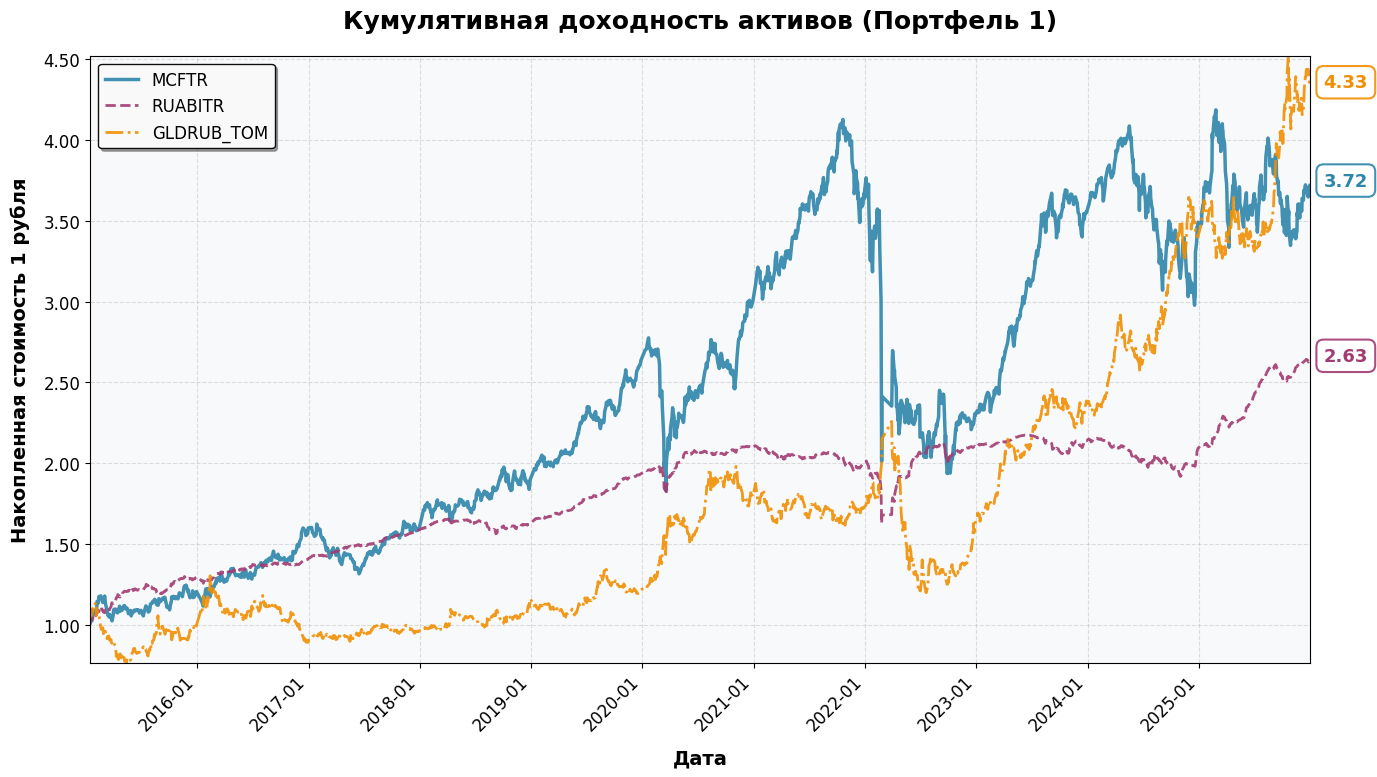

Итоговые кумулятивные доходности (Спец. 1):
  MCFTR: 3.7181
  RUABITR: 2.6340
  GLDRUB_TOM: 4.3261


In [50]:
cumulative_returns_1 = render_cumulative_returns(
    portfolio_1_daily_returns,
    asset_names_1,
    specification_number=1,
)

In [51]:
analysis_results_1 = run_specification_analysis(
    portfolio_1_daily_returns,
    initial_weights_1,
    asset_names_1,
    specification_number=1,
    risk_free_rate=risk_free_rate,
    mar=mar,
    cache_policy=CACHE_POLICY,
)

Загружен кэш: cache\analysis_results_1_7a943cfbb5c32d09.pkl


In [52]:
bounds_1, bounds_summary_1, pooled_weights_1 = build_specification_bounds(
    analysis_results_1,
    asset_names_1,
    core_metrics_for_bounds,
)

bounds_summary_1

,Asset,Mean_Weight,Median_Weight_Raw,Median_Weight,Std_Weight,P10_Weight,P90_Weight,Range_Width,N_Observations,N_Equal_Weight_Groups
0,MCFTR,23.9652,20.9362,18.6872,18.4884,0.0000,53.3907,53.3907,6912,216
1,RUABITR,42.2124,58.3992,52.1258,22.3794,0.0000,60.0000,60.0000,6912,216
2,GLDRUB_TOM,33.8225,32.6998,29.1870,19.8361,5.2454,60.0000,54.7546,6912,216


In [53]:
all_optimizations_1, summary_static_1 = optimize_specification(
    portfolio_1_daily_returns,
    bounds_1,
    asset_names_1,
    risk_free_rate=risk_free_rate,
    mar=mar,
)

In [54]:
style_static_optimization_summary(summary_static_1, asset_names_1)

Metric,Metric_Value,MCFTR,RUABITR,GLDRUB_TOM,Total_Weight
Sharpe Ratio,0.5877,5.05%,60.00%,34.95%,100.00%
Sortino Ratio,0.6873,8.37%,42.77%,48.86%,100.00%
Calmar Ratio,0.9662,3.42%,60.00%,36.58%,100.00%
CVaR Ratio (5%),0.0167,7.99%,60.00%,32.01%,100.00%
Martin Ratio,1.5426,6.49%,60.00%,33.51%,100.00%
Omega Ratio,1.1003,9.30%,60.00%,30.70%,100.00%
Min Volatility,0.0910,7.40%,60.00%,32.60%,100.00%
Min Max Drawdown,0.1622,3.42%,60.00%,36.58%,100.00%


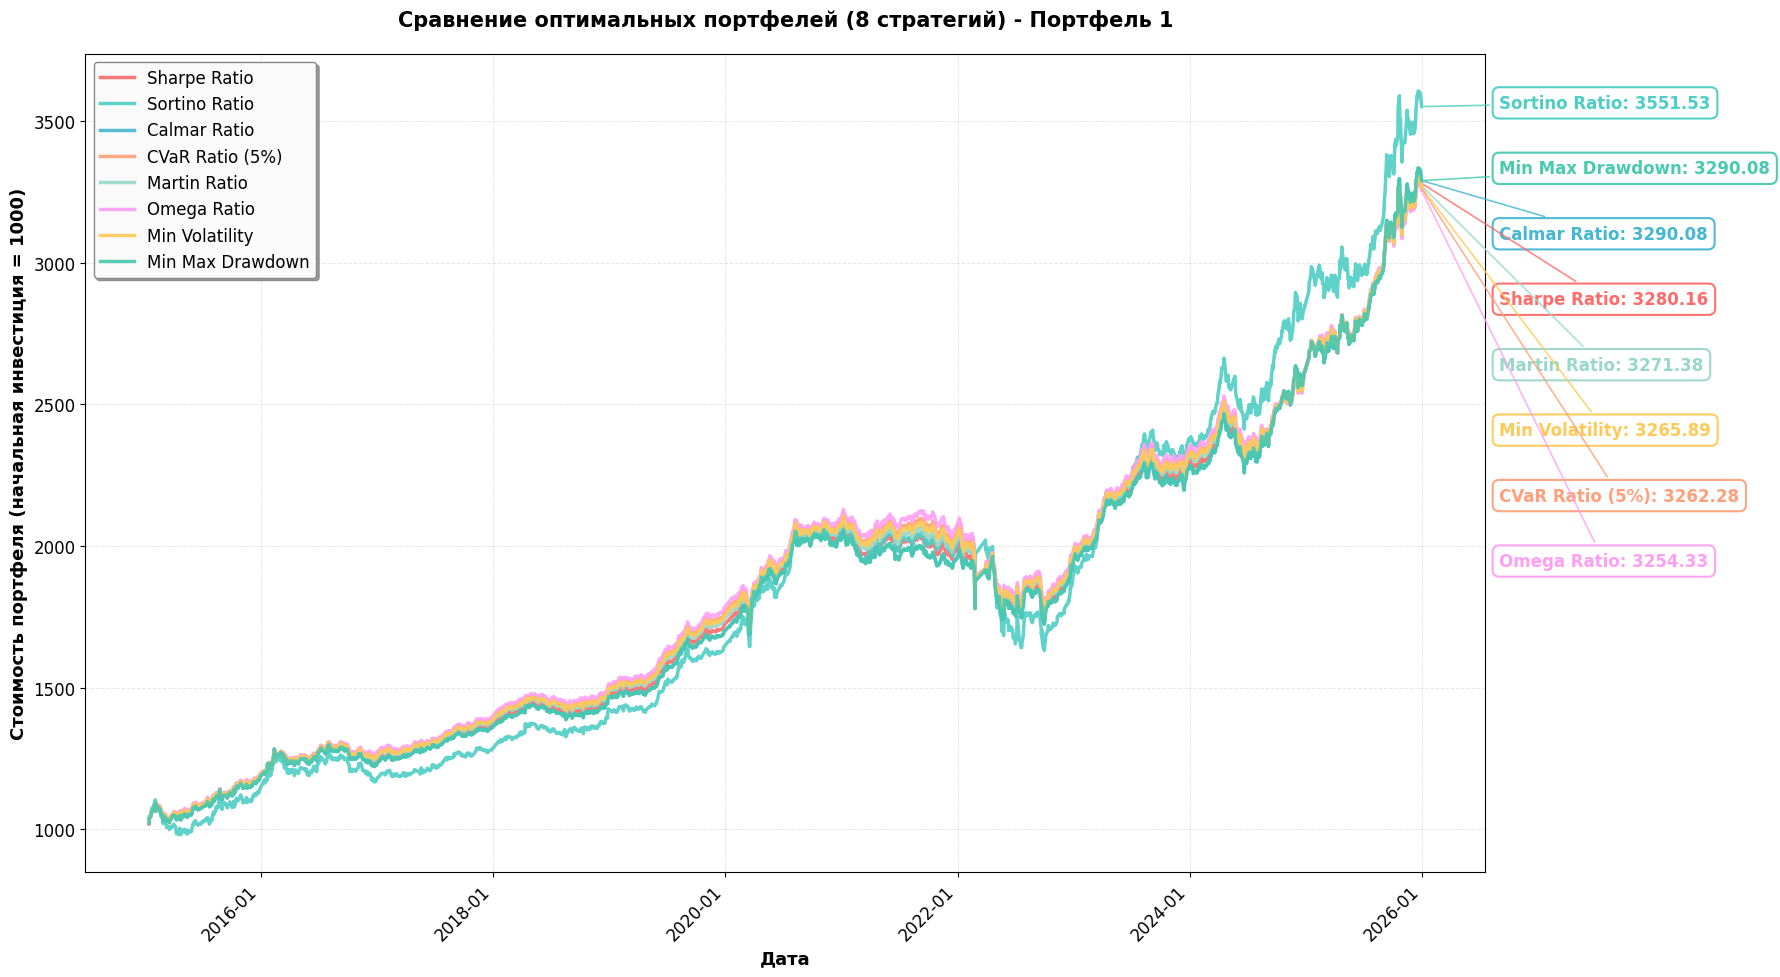

\nИтоговая стоимость портфелей (Спец. 1, начальная инвестиция = 1000):
  Sortino Ratio: 3551.53
  Min Max Drawdown: 3290.08
  Calmar Ratio: 3290.08
  Sharpe Ratio: 3280.16
  Martin Ratio: 3271.38
  Min Volatility: 3265.89
  CVaR Ratio (5%): 3262.28
  Omega Ratio: 3254.33


In [55]:
portfolio_values_1 = render_static_portfolio_values(
    portfolio_1_daily_returns,
    all_optimizations_1,
    specification_number=1,
)

### 3.3. Спецификация 2: MCFTR, RGBITR, GLDRUB_TOM

In [56]:
asset_names_2 = ['MCFTR', 'RGBITR', 'GLDRUB_TOM']
initial_weights_2 = np.array([30, 55, 15]) / 100

In [57]:
portfolio_2_data = build_synced_portfolio({
    'MCFTR': df_MCFTR,
    'RGBITR': df_RGBITR,
    'GLDRUB_TOM': df_GLDRUB_TOM,
})

Синхронизированный портфель: 2064 дат, 3 активов: ['MCFTR', 'RGBITR', 'GLDRUB_TOM']
Период: 2015-01-13 - 2025-12-30


In [58]:
portfolio_2_daily_returns = prepare_portfolio_daily_returns(portfolio_2_data)

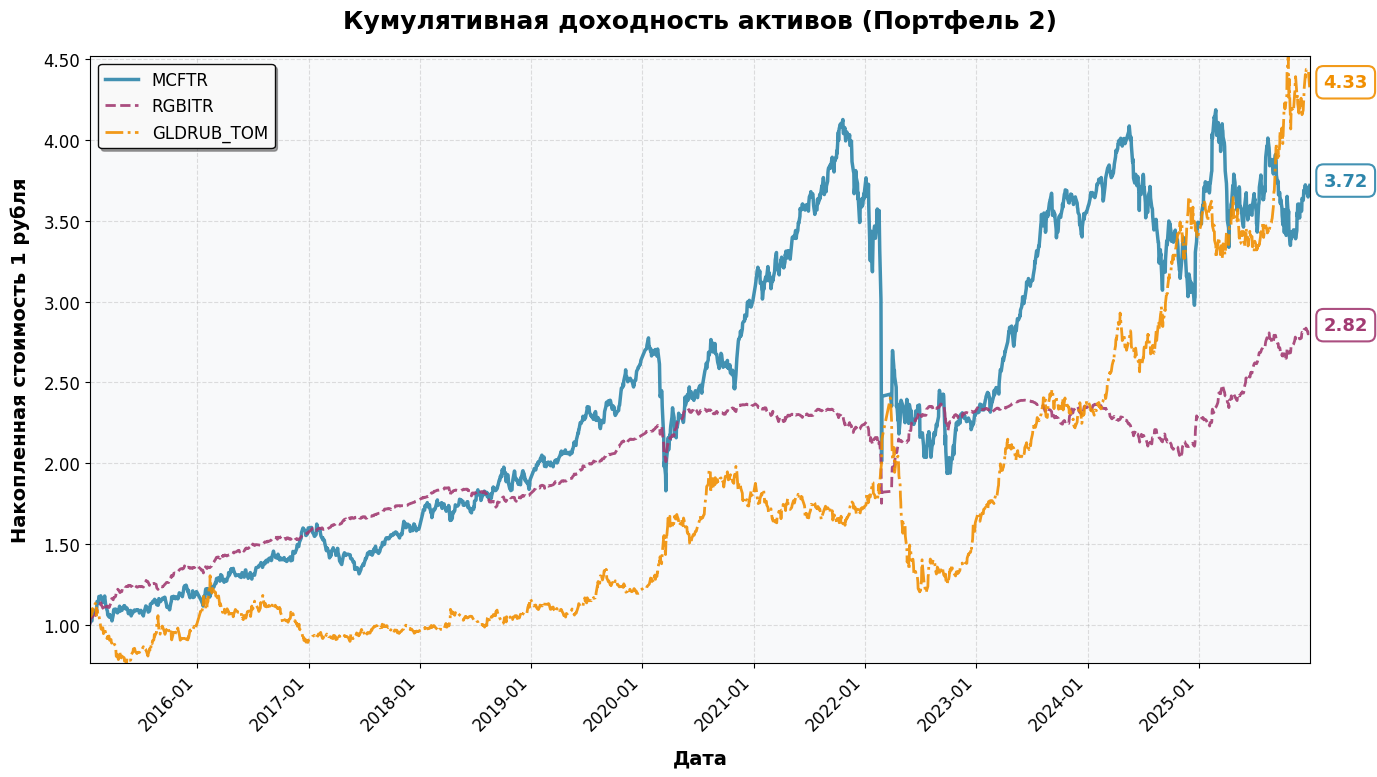

Итоговые кумулятивные доходности (Спец. 2):
  MCFTR: 3.7181
  RGBITR: 2.8236
  GLDRUB_TOM: 4.3261


In [59]:
cumulative_returns_2 = render_cumulative_returns(
    portfolio_2_daily_returns,
    asset_names_2,
    specification_number=2,
)

In [60]:
analysis_results_2 = run_specification_analysis(
    portfolio_2_daily_returns,
    initial_weights_2,
    asset_names_2,
    specification_number=2,
    risk_free_rate=risk_free_rate,
    mar=mar,
    cache_policy=CACHE_POLICY,
)

Загружен кэш: cache\analysis_results_2_770ebf721604f774.pkl


In [61]:
bounds_2, bounds_summary_2, pooled_weights_2 = build_specification_bounds(
    analysis_results_2,
    asset_names_2,
    core_metrics_for_bounds,
)

bounds_summary_2

,Asset,Mean_Weight,Median_Weight_Raw,Median_Weight,Std_Weight,P10_Weight,P90_Weight,Range_Width,N_Observations,N_Equal_Weight_Groups
0,MCFTR,24.2843,22.6576,19.7880,18.3885,0.000,53.2863,53.2863,6912,216
1,RGBITR,41.1217,58.3786,50.9849,23.1767,0.000,60.0000,60.0000,6912,216
2,GLDRUB_TOM,34.5940,33.4655,29.2271,19.5794,8.133,60.0000,51.8670,6912,216


In [62]:
all_optimizations_2, summary_static_2 = optimize_specification(
    portfolio_2_daily_returns,
    bounds_2,
    asset_names_2,
    risk_free_rate=risk_free_rate,
    mar=mar,
)

style_static_optimization_summary(summary_static_2, asset_names_2)

Metric,Metric_Value,MCFTR,RGBITR,GLDRUB_TOM,Total_Weight
Sharpe Ratio,0.6092,3.62%,60.00%,36.38%,100.00%
Sortino Ratio,0.7225,2.06%,54.88%,43.06%,100.00%
Calmar Ratio,0.9777,3.39%,60.00%,36.61%,100.00%
CVaR Ratio (5%),0.0174,7.25%,60.00%,32.75%,100.00%
Martin Ratio,1.6517,4.32%,60.00%,35.68%,100.00%
Omega Ratio,1.1092,8.95%,60.00%,31.05%,100.00%
Min Volatility,0.0957,6.14%,60.00%,33.86%,100.00%
Min Max Drawdown,0.1651,3.39%,60.00%,36.61%,100.00%


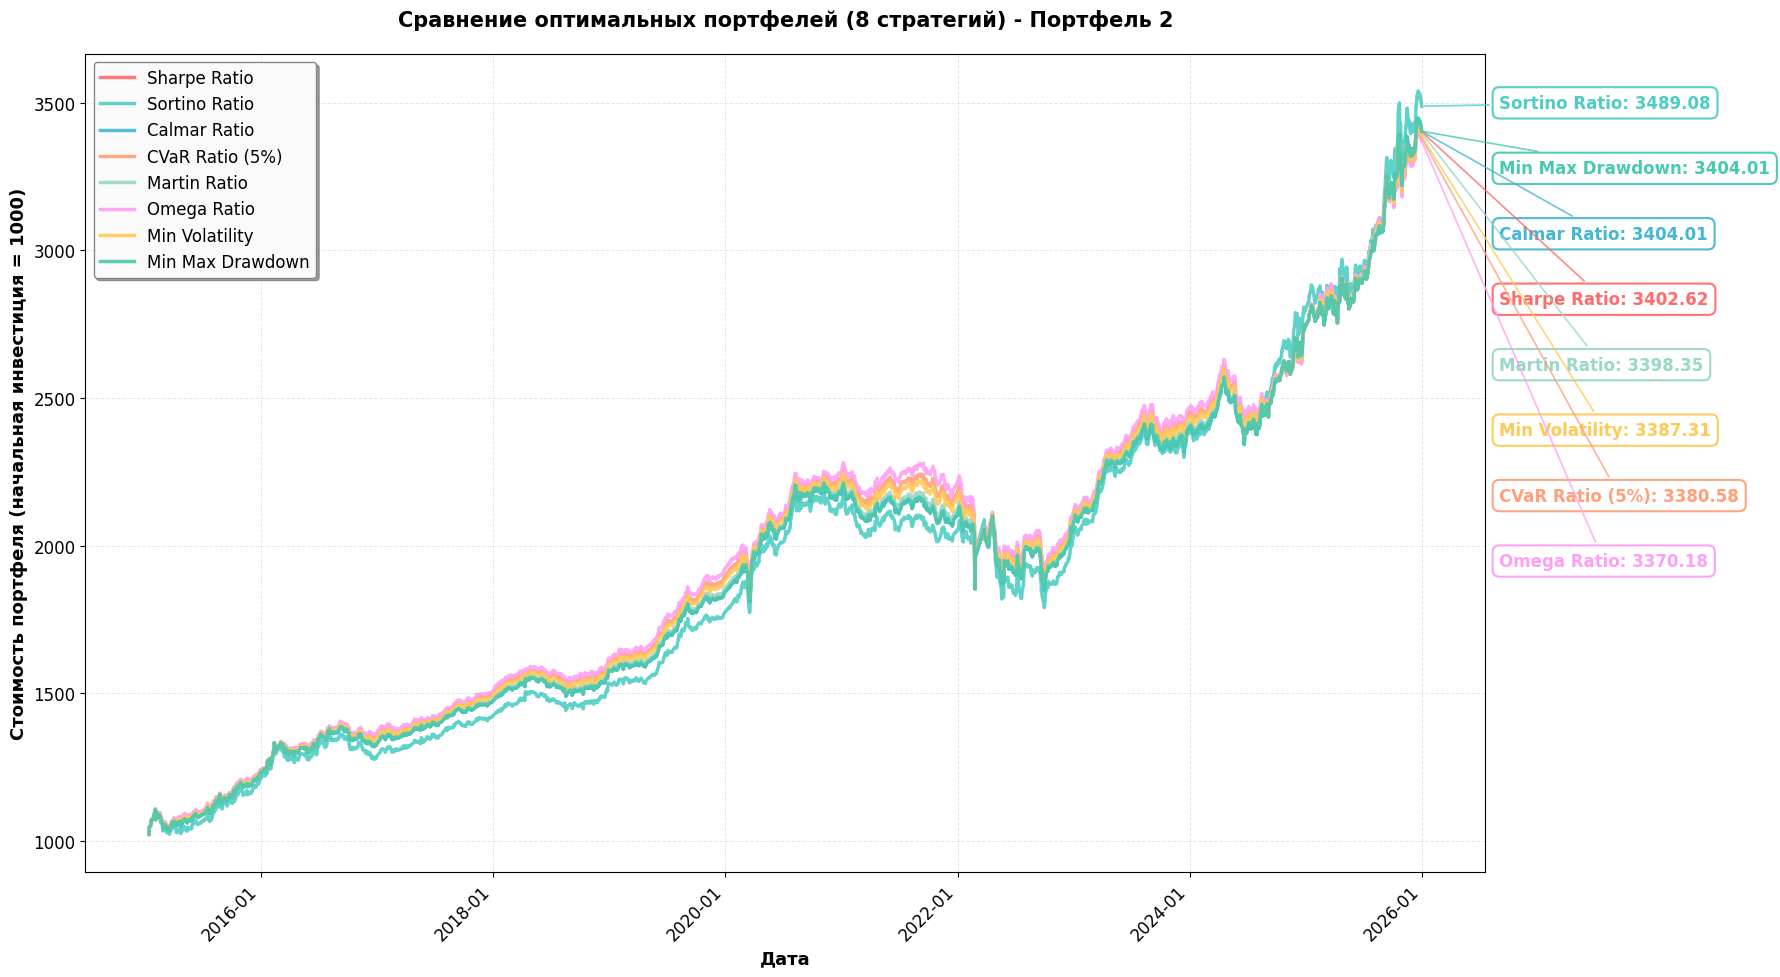

\nИтоговая стоимость портфелей (Спец. 2, начальная инвестиция = 1000):
  Sortino Ratio: 3489.08
  Min Max Drawdown: 3404.01
  Calmar Ratio: 3404.01
  Sharpe Ratio: 3402.62
  Martin Ratio: 3398.35
  Min Volatility: 3387.31
  CVaR Ratio (5%): 3380.58
  Omega Ratio: 3370.18


In [63]:
portfolio_values_2 = render_static_portfolio_values(
    portfolio_2_daily_returns,
    all_optimizations_2,
    specification_number=2,
)

### 3.4. Спецификация 3: MCFTR, RUGBITR3Y, RUGBITR10Y, GLDRUB_TOM

In [64]:
asset_names_3 = ['MCFTR', 'RUGBITR3Y', 'RUGBITR10Y', 'GLDRUB_TOM']
initial_weights_3 = np.array([30, 15, 40, 15]) / 100

In [65]:
portfolio_3_data = build_synced_portfolio({
    'MCFTR': df_MCFTR,
    'RUGBITR3Y': df_RUGBITR3Y,
    'RUGBITR10Y': df_RUGBITR10Y,
    'GLDRUB_TOM': df_GLDRUB_TOM,
})

Синхронизированный портфель: 2064 дат, 4 активов: ['MCFTR', 'RUGBITR3Y', 'RUGBITR10Y', 'GLDRUB_TOM']
Период: 2015-01-13 - 2025-12-30


In [66]:
portfolio_3_daily_returns = prepare_portfolio_daily_returns(portfolio_3_data)

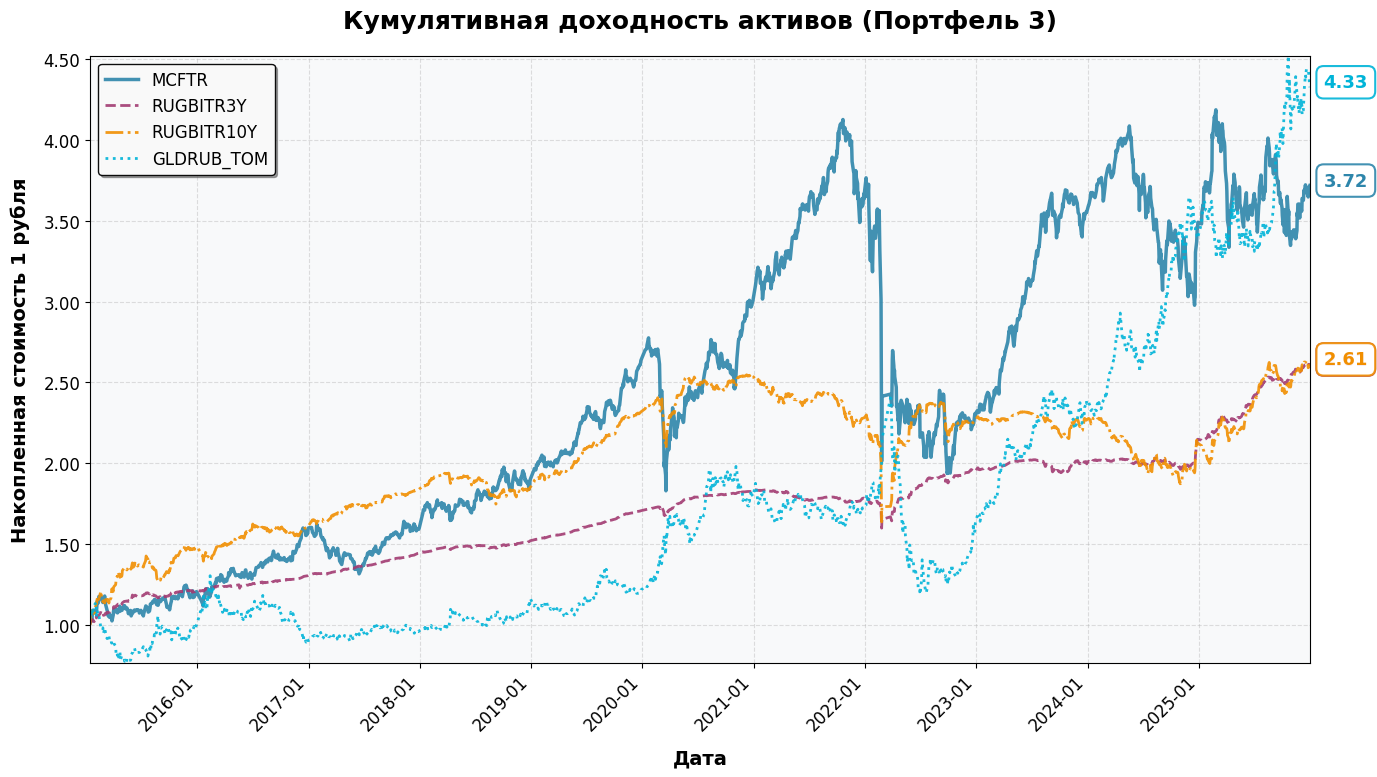

Итоговые кумулятивные доходности (Спец. 3):
  MCFTR: 3.7181
  RUGBITR3Y: 2.6105
  RUGBITR10Y: 2.6120
  GLDRUB_TOM: 4.3261


In [67]:
cumulative_returns_3 = render_cumulative_returns(
    portfolio_3_daily_returns,
    asset_names_3,
    specification_number=3,
)

In [68]:
analysis_results_3 = run_specification_analysis(
    portfolio_3_daily_returns,
    initial_weights_3,
    asset_names_3,
    specification_number=3,
    risk_free_rate=risk_free_rate,
    mar=mar,
    cache_policy=CACHE_POLICY,
)

Загружен кэш: cache\analysis_results_3_c5ab13d930033e4d.pkl


In [69]:
bounds_3, bounds_summary_3, pooled_weights_3 = build_specification_bounds(
    analysis_results_3,
    asset_names_3,
    core_metrics_for_bounds,
)

bounds_summary_3

,Asset,Mean_Weight,Median_Weight_Raw,Median_Weight,Std_Weight,P10_Weight,P90_Weight,Range_Width,N_Observations,N_Equal_Weight_Groups
0,MCFTR,18.0940,10.4916,10.4105,20.3248,0.0000,54.6093,54.6093,6912,216
1,RUGBITR3Y,38.8059,54.4874,54.0660,24.5891,0.0000,60.0000,60.0000,6912,216
2,RUGBITR10Y,15.1454,13.4531,13.3491,15.3985,0.0000,35.3729,35.3729,6912,216
3,GLDRUB_TOM,27.9548,22.3473,22.1745,21.2672,0.9702,60.0000,59.0298,6912,216


In [70]:
all_optimizations_3, summary_static_3 = optimize_specification(
    portfolio_3_daily_returns,
    bounds_3,
    asset_names_3,
    risk_free_rate=risk_free_rate,
    mar=mar,
)

In [71]:
style_static_optimization_summary(summary_static_3, asset_names_3)

Metric,Metric_Value,MCFTR,RUGBITR3Y,RUGBITR10Y,GLDRUB_TOM,Total_Weight
Sharpe Ratio,0.5907,3.84%,60.00%,8.70%,27.46%,100.00%
Sortino Ratio,0.6876,5.49%,60.00%,0.00%,34.51%,100.00%
Calmar Ratio,1.3044,1.28%,60.00%,10.95%,27.76%,100.00%
CVaR Ratio (5%),0.0174,6.47%,60.00%,9.69%,23.84%,100.00%
Martin Ratio,1.9054,5.83%,60.00%,8.91%,25.26%,100.00%
Omega Ratio,1.1007,7.21%,60.00%,8.96%,23.82%,100.00%
Min Volatility,0.0675,0.00%,60.00%,25.03%,14.97%,100.00%
Min Max Drawdown,0.1137,1.28%,60.00%,10.95%,27.76%,100.00%


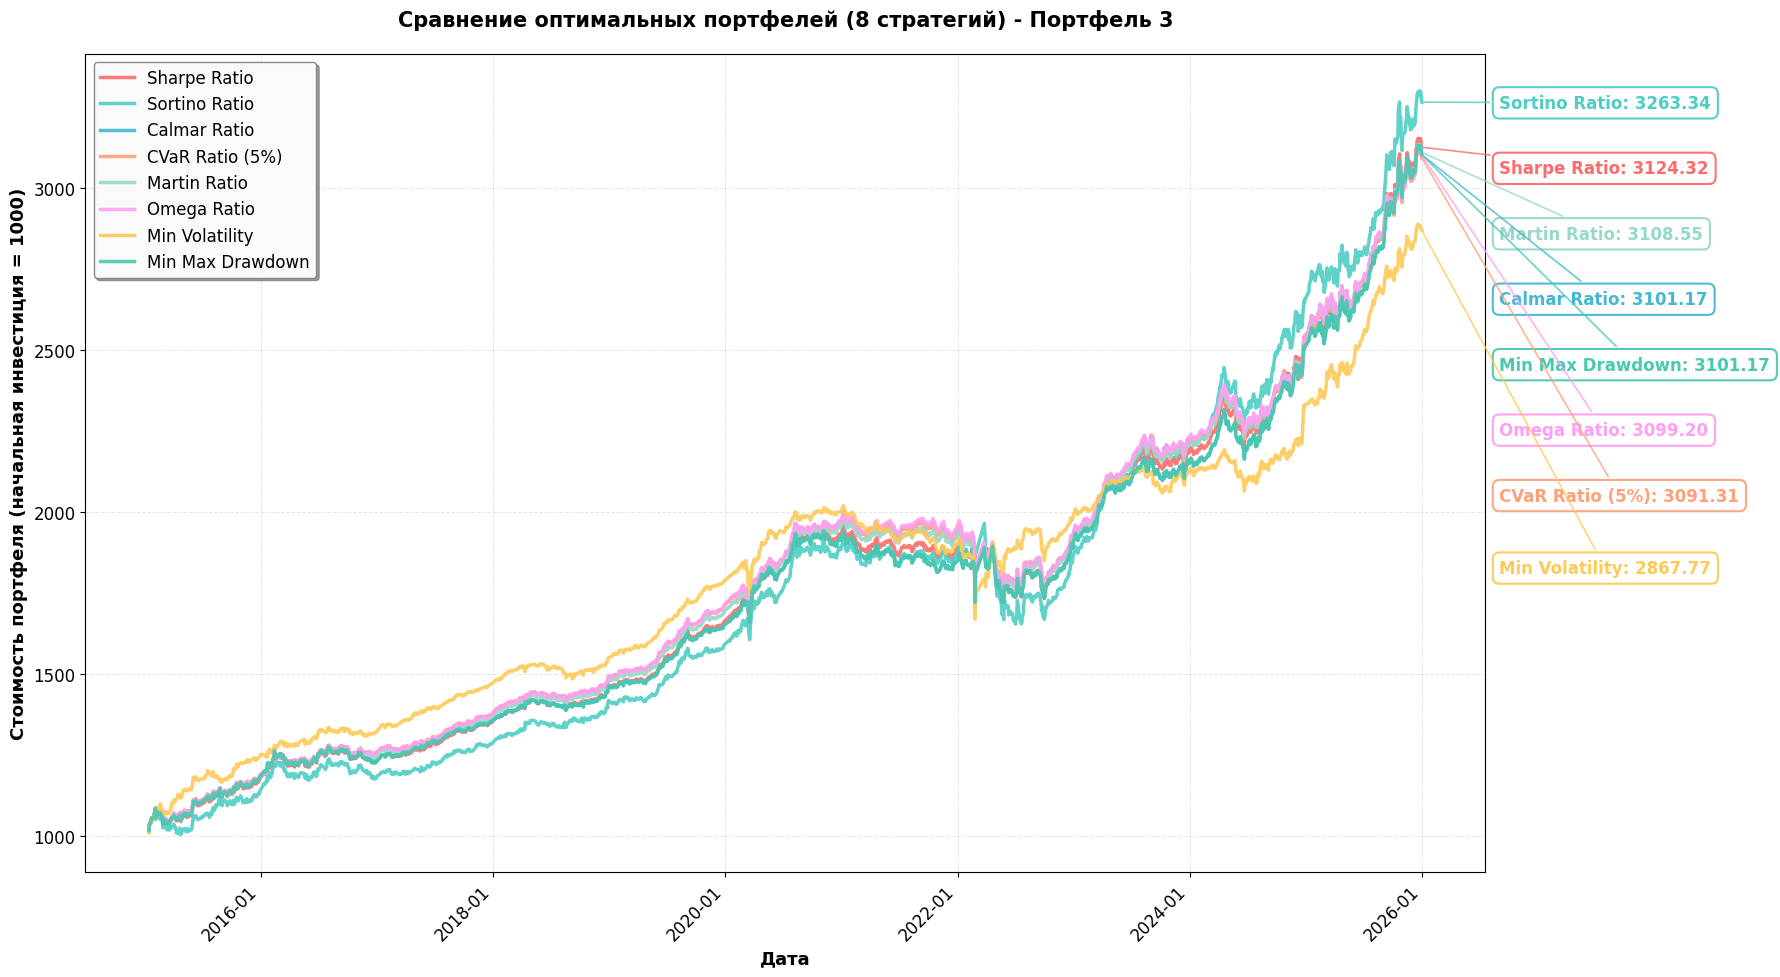

\nИтоговая стоимость портфелей (Спец. 3, начальная инвестиция = 1000):
  Sortino Ratio: 3263.34
  Sharpe Ratio: 3124.32
  Martin Ratio: 3108.55
  Calmar Ratio: 3101.17
  Min Max Drawdown: 3101.17
  Omega Ratio: 3099.20
  CVaR Ratio (5%): 3091.31
  Min Volatility: 2867.77


In [72]:
portfolio_values_3 = render_static_portfolio_values(
    portfolio_3_daily_returns,
    all_optimizations_3,
    specification_number=3,
)

### 3.5. Спецификация 4: MEBCTR, RUGBITR3Y, RUGBITR10Y, GLDRUB_TOM

In [73]:
asset_names_4 = ['MEBCTR', 'RUGBITR3Y', 'RUGBITR10Y', 'GLDRUB_TOM']
initial_weights_4 = np.array([30, 15, 40, 15]) / 100

In [74]:
portfolio_4_data = build_synced_portfolio({
    'MEBCTR': df_MEBCTR,
    'RUGBITR3Y': df_RUGBITR3Y,
    'RUGBITR10Y': df_RUGBITR10Y,
    'GLDRUB_TOM': df_GLDRUB_TOM,
})

Синхронизированный портфель: 2063 дат, 4 активов: ['MEBCTR', 'RUGBITR3Y', 'RUGBITR10Y', 'GLDRUB_TOM']
Период: 2015-01-13 - 2025-12-30


In [75]:
portfolio_4_daily_returns = prepare_portfolio_daily_returns(portfolio_4_data)

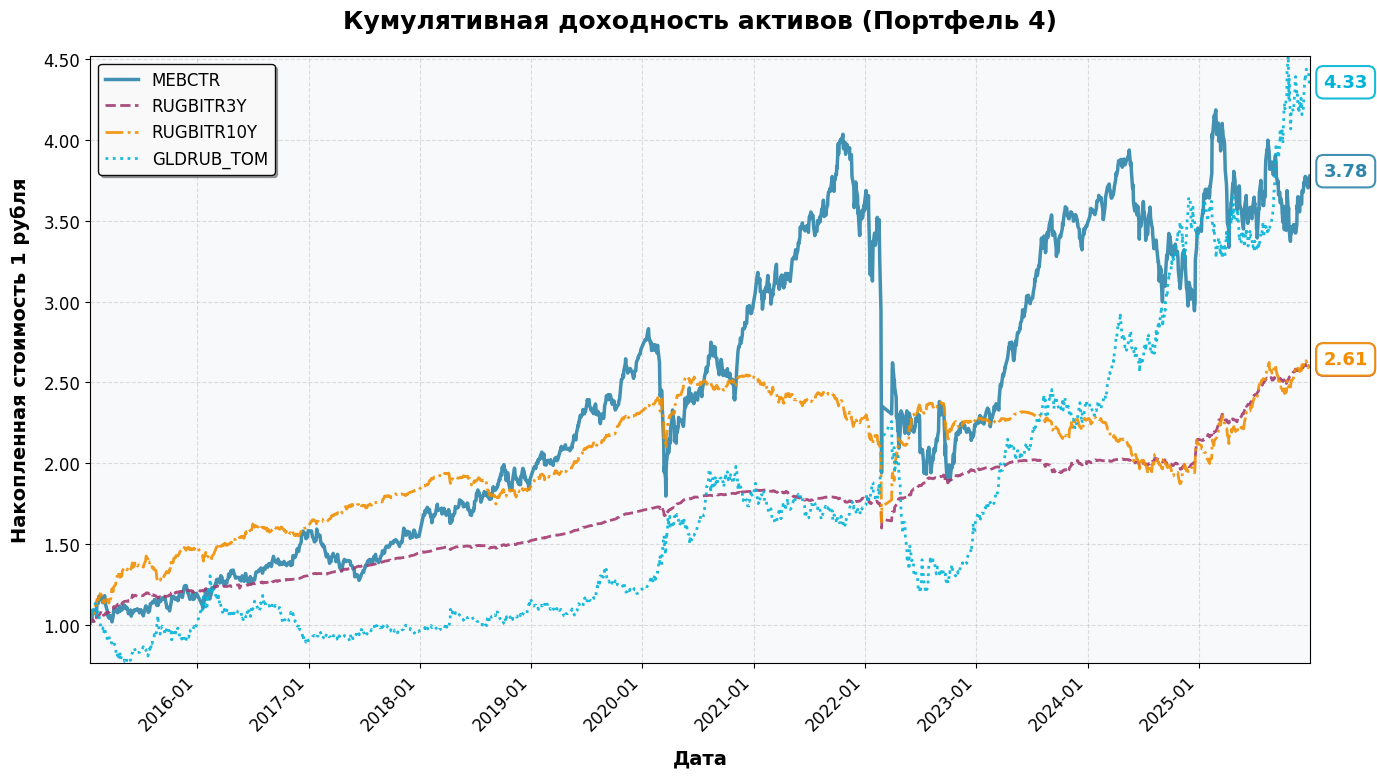

Итоговые кумулятивные доходности (Спец. 4):
  MEBCTR: 3.7762
  RUGBITR3Y: 2.6105
  RUGBITR10Y: 2.6120
  GLDRUB_TOM: 4.3261


In [76]:
cumulative_returns_4 = render_cumulative_returns(
    portfolio_4_daily_returns,
    asset_names_4,
    specification_number=4,
)

In [77]:
analysis_results_4 = run_specification_analysis(
    portfolio_4_daily_returns,
    initial_weights_4,
    asset_names_4,
    specification_number=4,
    risk_free_rate=risk_free_rate,
    mar=mar,
    cache_policy=CACHE_POLICY,
)

Загружен кэш: cache\analysis_results_4_94103cc89ab56c35.pkl


In [78]:
bounds_4, bounds_summary_4, pooled_weights_4 = build_specification_bounds(
    analysis_results_4,
    asset_names_4,
    core_metrics_for_bounds,
)

bounds_summary_4

,Asset,Mean_Weight,Median_Weight_Raw,Median_Weight,Std_Weight,P10_Weight,P90_Weight,Range_Width,N_Observations,N_Equal_Weight_Groups
0,MEBCTR,16.9947,9.3316,9.2076,19.7630,0.0000,52.1478,52.1478,6912,216
1,RUGBITR3Y,39.2452,55.8142,55.0726,24.2763,0.0000,60.0000,60.0000,6912,216
2,RUGBITR10Y,15.3933,13.7049,13.5228,15.7126,0.0000,36.2431,36.2431,6912,216
3,GLDRUB_TOM,28.3668,22.4959,22.1969,21.3808,0.4587,60.0000,59.5413,6912,216


In [79]:
all_optimizations_4, summary_static_4 = optimize_specification(
    portfolio_4_daily_returns,
    bounds_4,
    asset_names_4,
    risk_free_rate=risk_free_rate,
    mar=mar,
)

In [80]:
style_static_optimization_summary(summary_static_4, asset_names_4)

Metric,Metric_Value,MEBCTR,RUGBITR3Y,RUGBITR10Y,GLDRUB_TOM,Total_Weight
Sharpe Ratio,0.6049,3.70%,60.00%,8.34%,27.95%,100.00%
Sortino Ratio,0.6999,5.54%,60.00%,0.00%,34.46%,100.00%
Calmar Ratio,1.3038,1.22%,60.00%,11.00%,27.78%,100.00%
CVaR Ratio (5%),0.0178,6.37%,60.00%,9.84%,23.79%,100.00%
Martin Ratio,1.8815,5.20%,60.00%,9.30%,25.50%,100.00%
Omega Ratio,1.1014,6.87%,60.00%,9.02%,24.11%,100.00%
Min Volatility,0.0667,0.00%,60.00%,24.29%,15.71%,100.00%
Min Max Drawdown,0.1138,1.22%,60.00%,11.00%,27.78%,100.00%


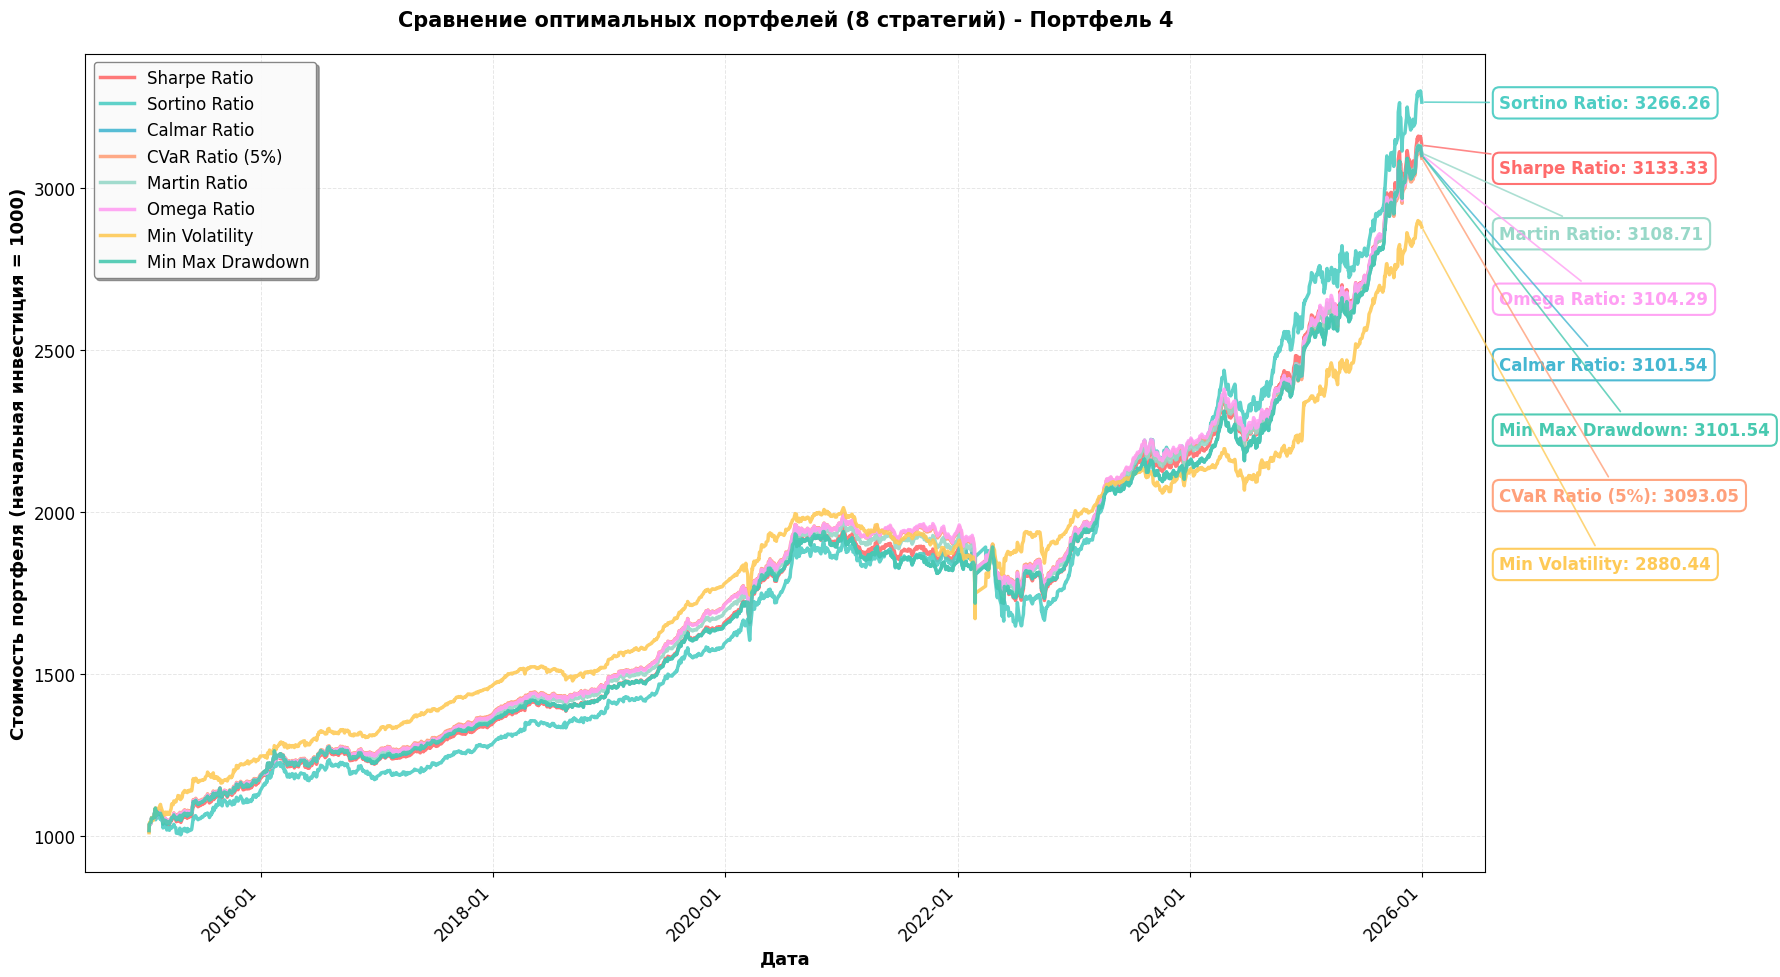

\nИтоговая стоимость портфелей (Спец. 4, начальная инвестиция = 1000):
  Sortino Ratio: 3266.26
  Sharpe Ratio: 3133.33
  Martin Ratio: 3108.71
  Omega Ratio: 3104.29
  Calmar Ratio: 3101.54
  Min Max Drawdown: 3101.54
  CVaR Ratio (5%): 3093.05
  Min Volatility: 2880.44


In [81]:
portfolio_values_4 = render_static_portfolio_values(
    portfolio_4_daily_returns,
    all_optimizations_4,
    specification_number=4,
)

### 3.6. Описательная статистика базовых активов

Статистика рассчитывается отдельно для максимально длинного доступного ряда
каждого уникального актива. Доходность портфеля с одним активом соответствует
buy-and-hold; внутрипериодной ребалансировки нет.

In [82]:
def collect_unique_asset_returns(
    specifications: Sequence[tuple[pd.DataFrame, Sequence[str]]],
) -> pd.DataFrame:
    """Собирает по одному максимально длинному ряду каждого уникального актива."""
    longest_series: dict[str, pd.Series] = {}
    for returns, asset_names in specifications:
        validated = _validate_returns_dataframe(returns)
        for asset in asset_names:
            series = validated[asset].dropna().rename(asset)
            if asset not in longest_series or len(series) > len(longest_series[asset]):
                longest_series[asset] = series
    if not longest_series:
        raise ValueError("No asset return series were supplied")
    return pd.concat(longest_series.values(), axis=1, join="outer").sort_index()


def calculate_asset_descriptive_statistics(
    asset_returns: pd.DataFrame,
    *,
    periods_per_year: int = TRADING_DAYS,
) -> pd.DataFrame:
    """Рассчитывает покрытие, доходность, риск и хвостовые характеристики активов."""
    rows: list[dict[str, Any]] = []
    for asset in asset_returns.columns:
        returns = pd.to_numeric(asset_returns[asset], errors="coerce").dropna()
        if returns.empty:
            continue
        wealth = (1.0 + returns).cumprod()
        drawdown = wealth / wealth.cummax() - 1.0
        cagr = float(wealth.iloc[-1] ** (periods_per_year / len(returns)) - 1.0)
        rows.append(
            {
                "Актив": asset,
                "Начало": returns.index.min(),
                "Конец": returns.index.max(),
                "N": int(len(returns)),
                "CAGR, %": cagr * 100,
                "Средняя годовая, %": float(returns.mean() * periods_per_year * 100),
                "Волатильность, %": float(
                    returns.std(ddof=1) * np.sqrt(periods_per_year) * 100
                ),
                "Мин. дневная, %": float(returns.min() * 100),
                "Макс. дневная, %": float(returns.max() * 100),
                "MDD, %": float(drawdown.min() * 100),
                "Асимметрия": float(returns.skew()),
                "Эксцесс": float(returns.kurt()),
            }
        )
    result = pd.DataFrame(rows)
    numeric_columns = result.select_dtypes(include=[np.number]).columns
    result[numeric_columns] = result[numeric_columns].round(4)
    return result.sort_values("Актив").reset_index(drop=True)


all_base_asset_returns = collect_unique_asset_returns(
    [
        (portfolio_1_daily_returns, asset_names_1),
        (portfolio_2_daily_returns, asset_names_2),
        (portfolio_3_daily_returns, asset_names_3),
        (portfolio_4_daily_returns, asset_names_4),
    ]
)
descriptive_statistics_assets = calculate_asset_descriptive_statistics(
    all_base_asset_returns
)
print("Описательная статистика уникальных базовых активов:")
print(descriptive_statistics_assets.to_string(index=False))

Описательная статистика уникальных базовых активов:
     Актив     Начало      Конец    N  CAGR, %  Средняя годовая, %  Волатильность, %  Мин. дневная, %  Макс. дневная, %   MDD, %  Асимметрия  Эксцесс
GLDRUB_TOM 2015-01-14 2025-12-30 2063  19.5916             20.8830           24.4807          -7.6100           11.8199 -50.0923      0.3265   5.5083
     MCFTR 2015-01-14 2025-12-30 2063  17.3995             19.7658           26.6060         -33.2806           20.0359 -53.0501     -3.2080  87.8490
    MEBCTR 2015-01-14 2025-12-30 2062  17.6312             20.3248           27.8856         -34.1195           21.2044 -53.0432     -2.9195  81.9926
    RGBITR 2015-01-14 2025-12-30 2063  13.5186             13.1030            9.0482         -13.7958            4.3258 -25.9667     -6.3610 177.0498
   RUABITR 2015-01-14 2025-12-30 2062  12.5653             12.1165            7.3629         -11.3871            3.5633 -22.7150     -7.0617 187.5473
RUGBITR10Y 2015-01-14 2025-12-30 2063  12.4435  

### 3.7. Интеграционная проверка спецификаций

In [83]:
section_3_specifications = {
    "Спец. 1": {
        "portfolio_daily_returns": portfolio_1_daily_returns,
        "asset_names": asset_names_1,
        "bounds_pct": bounds_1,
        "all_optimizations": all_optimizations_1,
    },
    "Спец. 2": {
        "portfolio_daily_returns": portfolio_2_daily_returns,
        "asset_names": asset_names_2,
        "bounds_pct": bounds_2,
        "all_optimizations": all_optimizations_2,
    },
    "Спец. 3": {
        "portfolio_daily_returns": portfolio_3_daily_returns,
        "asset_names": asset_names_3,
        "bounds_pct": bounds_3,
        "all_optimizations": all_optimizations_3,
    },
    "Спец. 4": {
        "portfolio_daily_returns": portfolio_4_daily_returns,
        "asset_names": asset_names_4,
        "bounds_pct": bounds_4,
        "all_optimizations": all_optimizations_4,
    },
}

section_3_compatibility_report = validate_section_3_specifications(
    section_3_specifications,
    required_metrics=core_metrics_for_bounds,
)
print("Совместимость данных, границ и статических оптимизаций:")
print(section_3_compatibility_report.to_string())

section_3_optimizer_cross_checks = cross_check_section_3_optimizers(
    section_3_specifications,
    risk_free_rate=risk_free_rate,
    mar=mar,
)
print("Сверка SLSQP с differential evolution:")
print(section_3_optimizer_cross_checks)

Совместимость данных, границ и статических оптимизаций:
              Наблюдений  Активов  Проверено метрик
Спецификация                                       
Спец. 1             2062        3                 8
Спец. 2             2063        3                 8
Спец. 3             2063        4                 8
Спец. 4             2062        4                 8
volatility    multi-start=0.09096 DE=0.09096 gap=0.000%
volatility    multi-start=0.09572 DE=0.10486 gap=-8.715%
volatility    multi-start=0.06750 DE=0.06970 gap=-3.163%
volatility    multi-start=0.06673 DE=0.06803 gap=-1.903%
Сверка SLSQP с differential evolution:
{'Спец. 1': True, 'Спец. 2': True, 'Спец. 3': True, 'Спец. 4': True}


### 3.8. Сравнение результатов спецификаций

In [84]:
def compute_all_metrics_for_weights(
    portfolio_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    risk_free_rate: float,
    mar: float,
    cvar_alpha: float = 0.05,
    periods_per_year: int = TRADING_DAYS,
) -> dict[str, float]:
    """Собирает сопоставимый отчёт из канонических портфельных метрик.

    Функция намеренно делегирует расчёты проверенным функциям блока 1.3,
    чтобы итоговые таблицы не содержали независимую копию тех же формул.

    Args:
        portfolio_daily_returns: Дневные простые доходности активов.
        weights: Long-only веса, сумма которых равна единице.
        risk_free_rate: Годовая безрисковая ставка в долях.
        mar: Годовой minimum acceptable return в долях.
        cvar_alpha: Размер левого хвоста для CVaR.
        periods_per_year: Число торговых дней для аннуализации.

    Returns:
        CAGR, волатильность и MDD в процентах; остальные метрики —
        безразмерные отношения в соглашениях блока 1.3.
    """
    returns, normalized_weights = _validate_inputs(
        portfolio_daily_returns,
        weights,
    )
    portfolio_returns = _portfolio_return_series(returns, normalized_weights)
    cagr = _cagr(portfolio_returns, periods_per_year=periods_per_year)

    return {
        "CAGR": cagr * 100,
        "Volatility": calculate_portfolio_volatility(
            returns,
            normalized_weights,
            periods_per_year=periods_per_year,
        ) * 100,
        "Sharpe": calculate_portfolio_sharpe_ratio(
            returns,
            normalized_weights,
            risk_free_rate,
            periods_per_year=periods_per_year,
        ),
        "Sortino": calculate_portfolio_sortino_ratio(
            returns,
            normalized_weights,
            mar=mar,
            mar_annual=True,
            periods_per_year=periods_per_year,
        ),
        "Calmar": calculate_portfolio_calmar_ratio(
            returns,
            normalized_weights,
            periods_per_year=periods_per_year,
        ),
        "MDD": calculate_portfolio_max_drawdown(returns, normalized_weights) * 100,
        "CVaR Ratio": calculate_portfolio_cvar_ratio(
            returns,
            normalized_weights,
            risk_free_rate,
            alpha=cvar_alpha,
            periods_per_year=periods_per_year,
        ),
        "Martin Ratio": calculate_portfolio_martin_ratio(
            returns,
            normalized_weights,
            risk_free_rate,
            periods_per_year=periods_per_year,
        ),
        "Omega": calculate_portfolio_omega_ratio(
            returns,
            normalized_weights,
            threshold_return=mar,
            threshold_annual=True,
            periods_per_year=periods_per_year,
        ),
    }

def extract_median_weights(bounds_summary: pd.DataFrame) -> np.ndarray:
    """Извлекает и нормализует медианные веса оконного распределения.

    Args:
        bounds_summary: Таблица агрегации с колонкой ``Median_Weight``
            в процентах и строками в порядке активов спецификации.

    Returns:
        Одномерный массив неотрицательных весов с суммой 1.0.

    Raises:
        KeyError: В таблице отсутствует ``Median_Weight``.
        ValueError: Веса пусты, нечисловые, отрицательные или имеют
            неположительную сумму.
    """
    if "Median_Weight" not in bounds_summary:
        raise KeyError("bounds_summary must contain Median_Weight")

    weights = pd.to_numeric(bounds_summary["Median_Weight"], errors="coerce").to_numpy(
        dtype=float
    )
    if weights.size == 0 or not np.isfinite(weights).all():
        raise ValueError("Median weights must be non-empty and finite")
    if (weights < 0).any():
        raise ValueError("Median weights must be non-negative")
    total = float(weights.sum())
    if total <= 0:
        raise ValueError("Median weights must have a positive sum")
    return weights / total

In [85]:
def build_comparison_table(
    specifications: Mapping[str, tuple[pd.DataFrame, np.ndarray]],
    risk_free_rate: float,
    mar: float,
) -> pd.DataFrame:
    """Строит сводную таблицу метрик спецификаций и бенчмарков.

    Args:
        specifications: Соответствие подписи паре ``(доходности, веса)``.
        risk_free_rate: Годовая безрисковая ставка в долях.
        mar: Годовой minimum acceptable return в долях.

    Returns:
        Таблица, где одна строка соответствует одной спецификации.
    """
    rows: list[dict[str, float | str]] = []
    for label, (returns, weights) in specifications.items():
        metrics: dict[str, float | str] = compute_all_metrics_for_weights(
            returns,
            weights,
            risk_free_rate,
            mar,
        )
        metrics["Portfolio"] = label
        rows.append(metrics)

    comparison = pd.DataFrame(rows)
    ordered_columns = [
        "Portfolio",
        *(column for column in comparison.columns if column != "Portfolio"),
    ]
    comparison = comparison[ordered_columns]
    numeric_columns = comparison.select_dtypes(include=[np.number]).columns
    comparison[numeric_columns] = comparison[numeric_columns].round(4)
    return comparison

In [86]:
def _parse_cbr_deposit_rates(html: str) -> tuple[dict[str, float], int]:
    """Преобразует HTML-таблицу ЦБ в среднемесячные депозитные ставки.

    Args:
        html: HTML страницы со ставками по декадам.

    Returns:
        Словарь ``YYYY-MM -> ставка, %`` и число распознанных декад.

    Raises:
        ValueError: Таблица отсутствует или не содержит корректных строк.
    """
    soup = BeautifulSoup(html, "html.parser")
    table = soup.find("table", class_="data")
    if table is None:
        for candidate in soup.find_all("table"):
            headers = [header.get_text(strip=True) for header in candidate.find_all("th")]
            if any("Декада" in header or "Ставка" in header for header in headers):
                table = candidate
                break
    if table is None:
        raise ValueError("Не удалось найти таблицу депозитных ставок ЦБ")

    rates_by_month: defaultdict[str, list[float]] = defaultdict(list)
    for row in table.find_all("tr"):
        cells = row.find_all("td")
        if len(cells) < 2:
            continue
        date_parts = cells[0].get_text(strip=True).split(".")
        if len(date_parts) != 3:
            continue
        try:
            month = int(date_parts[1])
            year = int(date_parts[2])
            rate = float(cells[1].get_text(strip=True).replace(",", "."))
        except (ValueError, IndexError):
            continue
        if 1 <= month <= 12 and np.isfinite(rate):
            rates_by_month[f"{year}-{month:02d}"].append(rate)

    if not rates_by_month:
        raise ValueError("Таблица ЦБ не содержит распознаваемых ставок")

    observation_count = sum(map(len, rates_by_month.values()))
    monthly_rates = {
        month: round(float(np.mean(values)), 2)
        for month, values in sorted(rates_by_month.items())
    }
    return monthly_rates, observation_count

def fetch_cbr_deposit_rates(
    url: str = (
        "https://www.cbr.ru/statistics/avgprocstav/"
        "?UniDbQuery.Posted=True"
        "&UniDbQuery.From=1.01.2015"
        "&UniDbQuery.To=3.12.2025"
    ),
) -> tuple[dict[str, float], int]:
    """Загружает и агрегирует ставки топ-10 банков с сайта ЦБ.

    Args:
        url: Страница ЦБ с заданным периодом наблюдений.

    Returns:
        Среднемесячные ставки в процентах и число исходных декад.

    Raises:
        requests.HTTPError: Сервер вернул ошибочный HTTP-статус.
        requests.RequestException: Сетевая ошибка или таймаут.
        ValueError: Формат HTML не соответствует ожидаемой таблице.

    Side Effects:
        Выполняет HTTP GET-запрос.
    """
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    response.encoding = "utf-8"
    return _parse_cbr_deposit_rates(response.text)

In [87]:
def build_deposit_daily_returns(
    portfolio_index: pd.DatetimeIndex,
    deposit_rates: Mapping[str, float],
    trading_days: int = TRADING_DAYS,
) -> pd.Series:
    """Преобразует месячные годовые ставки в дневной депозитный бенчмарк.

    Args:
        portfolio_index: Торговые даты сравниваемого портфеля.
        deposit_rates: Соответствие ``YYYY-MM -> годовая ставка, %``.
        trading_days: Число торговых дней в году.

    Returns:
        Дневные геометрически эквивалентные доходности с исходным индексом.

    Raises:
        TypeError: ``portfolio_index`` не DatetimeIndex.
        ValueError: Индекс пуст, периодичность неположительна, отсутствует
            ставка хотя бы для одного месяца или годовая ставка <= -100%.
    """
    if not isinstance(portfolio_index, pd.DatetimeIndex):
        raise TypeError("portfolio_index must be a DatetimeIndex")
    if portfolio_index.empty:
        raise ValueError("portfolio_index must not be empty")
    if trading_days <= 0:
        raise ValueError("trading_days must be positive")

    month_keys = pd.Series(
        portfolio_index.to_period("M").astype(str),
        index=portfolio_index,
    )
    annual_rates_pct = month_keys.map(deposit_rates)
    if annual_rates_pct.isna().any():
        missing_months = sorted(month_keys[annual_rates_pct.isna()].unique())
        raise ValueError(f"Missing deposit rates for months: {missing_months}")

    annual_rates = annual_rates_pct.astype(float) / 100.0
    if (annual_rates <= -1.0).any():
        raise ValueError("Deposit rates must be greater than -100%")
    daily_returns = np.expm1(np.log1p(annual_rates) / trading_days)
    return pd.Series(daily_returns, index=portfolio_index, name="Deposit")

In [88]:
def test_block_3_7_metric_report_matches_canonical_functions() -> None:
    """Фиксирует единые формулы между отчётом и каноническими метриками."""
    returns = _make_synthetic_returns(seed=31, n_years=2, n_assets=3)
    weights = np.array([0.4, 0.35, 0.25])
    risk_free_rate = 0.08
    mar = 0.10

    report = compute_all_metrics_for_weights(
        returns,
        weights,
        risk_free_rate,
        mar,
    )

    portfolio_returns = _portfolio_return_series(returns, weights)
    expected = {
        "CAGR": _cagr(portfolio_returns) * 100,
        "Volatility": calculate_portfolio_volatility(returns, weights) * 100,
        "Sharpe": calculate_portfolio_sharpe_ratio(returns, weights, risk_free_rate),
        "Sortino": calculate_portfolio_sortino_ratio(
            returns, weights, mar=mar, mar_annual=True
        ),
        "Calmar": calculate_portfolio_calmar_ratio(returns, weights),
        "MDD": calculate_portfolio_max_drawdown(returns, weights) * 100,
        "CVaR Ratio": calculate_portfolio_cvar_ratio(
            returns, weights, risk_free_rate, alpha=0.05
        ),
        "Martin Ratio": calculate_portfolio_martin_ratio(
            returns, weights, risk_free_rate
        ),
        "Omega": calculate_portfolio_omega_ratio(
            returns, weights, threshold_return=mar, threshold_annual=True
        ),
    }
    assert report.keys() == expected.keys()
    for metric_name, expected_value in expected.items():
        assert report[metric_name] == pytest.approx(expected_value)

def test_block_3_7_extract_median_weights_validates_and_normalizes() -> None:
    """Проверяет контракт медианных весов оконного распределения."""
    summary = pd.DataFrame({"Median_Weight": [20.0, 30.0, 40.0]})
    np.testing.assert_allclose(extract_median_weights(summary), [2 / 9, 1 / 3, 4 / 9])

    with pytest.raises(KeyError):
        extract_median_weights(pd.DataFrame({"Mean_Weight": [100.0]}))
    with pytest.raises(ValueError):
        extract_median_weights(pd.DataFrame({"Median_Weight": [0.0, 0.0]}))

def test_block_3_7_parses_deposit_rates_and_builds_daily_series() -> None:
    """Проверяет HTML-парсер и геометрическое преобразование ставок."""
    html = """
    <table class="data">
      <tr><th>Декада</th><th>Ставка</th></tr>
      <tr><td>1.01.2024</td><td>10,0</td></tr>
      <tr><td>2.01.2024</td><td>12,0</td></tr>
      <tr><td>1.02.2024</td><td>9,0</td></tr>
    </table>
    """
    monthly_rates, observation_count = _parse_cbr_deposit_rates(html)
    assert observation_count == 3
    assert monthly_rates == {"2024-01": 11.0, "2024-02": 9.0}

    index = pd.DatetimeIndex(["2024-01-10", "2024-02-12"])
    daily = build_deposit_daily_returns(index, monthly_rates)
    expected = np.expm1(np.log1p(np.array([0.11, 0.09])) / TRADING_DAYS)
    np.testing.assert_allclose(daily.to_numpy(), expected)

    with pytest.raises(ValueError, match="Missing deposit rates"):
        build_deposit_daily_returns(
            pd.DatetimeIndex(["2024-03-01"]),
            monthly_rates,
        )

In [89]:
run_notebook_tests("test_block_3_7")

...                                                                                          [100%]


0

In [90]:
deposit_monthly_rates_pct, n_obs = fetch_cbr_deposit_rates()
avg_deposit_rate = np.mean(list(deposit_monthly_rates_pct.values()))
print(f'Загружено {n_obs} подекадных наблюдений ({len(deposit_monthly_rates_pct)} месяцев)')
print(f'Период: {min(deposit_monthly_rates_pct.keys())} — {max(deposit_monthly_rates_pct.keys())}')
print(f'Средняя максимальная ставка по депозитам: {avg_deposit_rate:.2f}%')

Загружено 396 подекадных наблюдений (132 месяцев)
Период: 2015-01 — 2025-12
Средняя максимальная ставка по депозитам: 9.71%


In [91]:
median_w1 = extract_median_weights(bounds_summary_1)
median_w2 = extract_median_weights(bounds_summary_2)
median_w3 = extract_median_weights(bounds_summary_3)
median_w4 = extract_median_weights(bounds_summary_4)
 
print("\nМедианные веса (нормализованные):")
for i, (w, names) in enumerate([
    (median_w1, asset_names_1),
    (median_w2, asset_names_2),
    (median_w3, asset_names_3),
    (median_w4, asset_names_4),
], 1):
    parts = ", ".join(f"{n}: {v:.2f}%" for n, v in zip(names, w * 100))
    print(f"  Спецификация {i}: [{parts}], сумма = {w.sum()*100:.2f}%")


Медианные веса (нормализованные):
  Спецификация 1: [MCFTR: 18.69%, RUABITR: 52.13%, GLDRUB_TOM: 29.19%], сумма = 100.00%
  Спецификация 2: [MCFTR: 19.79%, RGBITR: 50.98%, GLDRUB_TOM: 29.23%], сумма = 100.00%
  Спецификация 3: [MCFTR: 10.41%, RUGBITR3Y: 54.07%, RUGBITR10Y: 13.35%, GLDRUB_TOM: 22.17%], сумма = 100.00%
  Спецификация 4: [MEBCTR: 9.21%, RUGBITR3Y: 55.07%, RUGBITR10Y: 13.52%, GLDRUB_TOM: 22.20%], сумма = 100.00%


In [92]:
n3 = len(asset_names_3)
equal_w3 = np.ones(n3) / n3
only_equity = np.array([1.0, 0.0, 0.0, 0.0])
only_bond_short = np.array([0.0, 1.0, 0.0, 0.0])
only_bond_long = np.array([0.0, 0.0, 1.0, 0.0])
only_gold = np.array([0.0, 0.0, 0.0, 1.0])
 
deposit_daily_ret = build_deposit_daily_returns(
    portfolio_3_daily_returns.index,
    deposit_monthly_rates_pct,
)
deposit_returns_df = deposit_daily_ret.to_frame('Deposit')
 
portfolio_60_40_data = build_synced_portfolio({
    'MCFTR': df_MCFTR,
    'RGBITR': df_RGBITR,
})
portfolio_60_40_returns = portfolio_60_40_data.pct_change().dropna()
weights_60_40 = np.array([0.60, 0.40])
weights_dalio = initial_weights_3
 
print(f"\nВеса Далио (оригинал): {weights_dalio * 100}%")
print(f"Равновзвешенные (Спец. 3): {equal_w3 * 100}%")

Синхронизированный портфель: 2762 дат, 2 активов: ['MCFTR', 'RGBITR']
Период: 2015-01-05 - 2025-12-30

Веса Далио (оригинал): [30. 15. 40. 15.]%
Равновзвешенные (Спец. 3): [25. 25. 25. 25.]%


In [93]:
# 60/40 на общей сетке Спец. 3 — для корректного сравнения в таблице 5
aligned_idx = portfolio_60_40_returns.index.intersection(portfolio_3_daily_returns.index)
portfolio_60_40_aligned = portfolio_60_40_returns.loc[aligned_idx]

metrics_60_40_native = compute_all_metrics_for_weights(
    portfolio_60_40_returns, weights_60_40, risk_free_rate, mar,
)
metrics_60_40_aligned = compute_all_metrics_for_weights(
    portfolio_60_40_aligned, weights_60_40, risk_free_rate, mar,
)
diff_60_40 = pd.DataFrame({
    f"Полная сетка ({len(portfolio_60_40_returns)} дней)": metrics_60_40_native,
    f"Сетка Спец. 3 ({len(portfolio_60_40_aligned)} дней)": metrics_60_40_aligned,
})
print("60/40: сравнение сеток")
print(diff_60_40.round(4).to_string())

60/40: сравнение сеток
              Полная сетка (2761 дней)  Сетка Спец. 3 (2063 дней)
CAGR                           11.9806                    12.0446
Volatility                     17.2499                    17.2161
Sharpe                          0.1923                     0.1967
Sortino                         0.1733                     0.1791
Calmar                          0.2697                     0.3603
MDD                            44.4140                    33.4285
CVaR Ratio                      0.0056                     0.0062
Martin Ratio                    0.1929                     0.2807
Omega                           1.0298                     1.0326


In [94]:
comparison = build_comparison_table(
    specifications={
        "Спец. 1 (медиана)": (portfolio_1_daily_returns, median_w1),
        "Спец. 2 (медиана)": (portfolio_2_daily_returns, median_w2),
        "Спец. 3 (медиана)": (portfolio_3_daily_returns, median_w3),
        "Спец. 4 (медиана)": (portfolio_4_daily_returns, median_w4),
        "Равновзвешенный (Спец.3)": (portfolio_3_daily_returns, equal_w3),
        "Депозит (макс. ставка)": (deposit_returns_df, np.array([1.0])),
        "100% Акции (MCFTR)": (portfolio_3_daily_returns, only_equity),
        "100% Облиг. кратк.": (portfolio_3_daily_returns, only_bond_short),
        "100% Облиг. длин.": (portfolio_3_daily_returns, only_bond_long),
        "100% Золото": (portfolio_3_daily_returns, only_gold),
        "60/40 (MCFTR/RGBITR)": (portfolio_60_40_returns, weights_60_40),
        "Далио оригинал (Спец.3)": (portfolio_3_daily_returns, weights_dalio),
    },
    risk_free_rate=risk_free_rate,
    mar=mar,
)
 
print("\n" + comparison.to_string(index=False))


               Portfolio    CAGR  Volatility  Sharpe  Sortino  Calmar     MDD  CVaR Ratio  Martin Ratio  Omega
       Спец. 1 (медиана) 15.8394     10.5870  0.5396   0.5963  0.6708 23.6125      0.0159        1.1167 1.0970
       Спец. 2 (медиана) 16.2889     11.1695  0.5521   0.6183  0.6727 24.2150      0.0163        1.1505 1.1039
       Спец. 3 (медиана) 14.8499      8.4085  0.5521   0.5914  0.8959 16.5760      0.0167        1.6245 1.0984
       Спец. 4 (медиана) 14.8233      8.1139  0.5662   0.6047  0.9255 16.0164      0.0172        1.7030 1.0994
Равновзвешенный (Спец.3) 15.7724     12.0926  0.4825   0.5302  0.5755 27.4080      0.0145        0.9051 1.0902
  Депозит (макс. ставка)  9.6020      0.2565 -1.5386  -6.5803     NaN  0.0000      0.0906           NaN 0.4730
      100% Акции (MCFTR) 17.3995     26.6060  0.3834   0.4617  0.3280 53.0501      0.0110        0.4551 1.0739
      100% Облиг. кратк. 12.4355      5.0701  0.4513   0.3570  0.9611 12.9385      0.0145        2.0003 1.0736


In [95]:
stability = pd.DataFrame({
    "Спецификация": [f"Спец. {i}" for i in range(1, 5)],
    "Средняя ширина диапазона": [
        bounds_summary_1["Range_Width"].mean(),
        bounds_summary_2["Range_Width"].mean(),
        bounds_summary_3["Range_Width"].mean(),
        bounds_summary_4["Range_Width"].mean(),
    ],
    "Число активов": [3, 3, 4, 4],
})

print("Устойчивость весов (средняя ширина диапазона, п.п.):")
print(stability.to_string(index=False))

Устойчивость весов (средняя ширина диапазона, п.п.):
Спецификация  Средняя ширина диапазона  Число активов
     Спец. 1                 56.048433              3
     Спец. 2                 55.051100              3
     Спец. 3                 52.253000              4
     Спец. 4                 51.983050              4


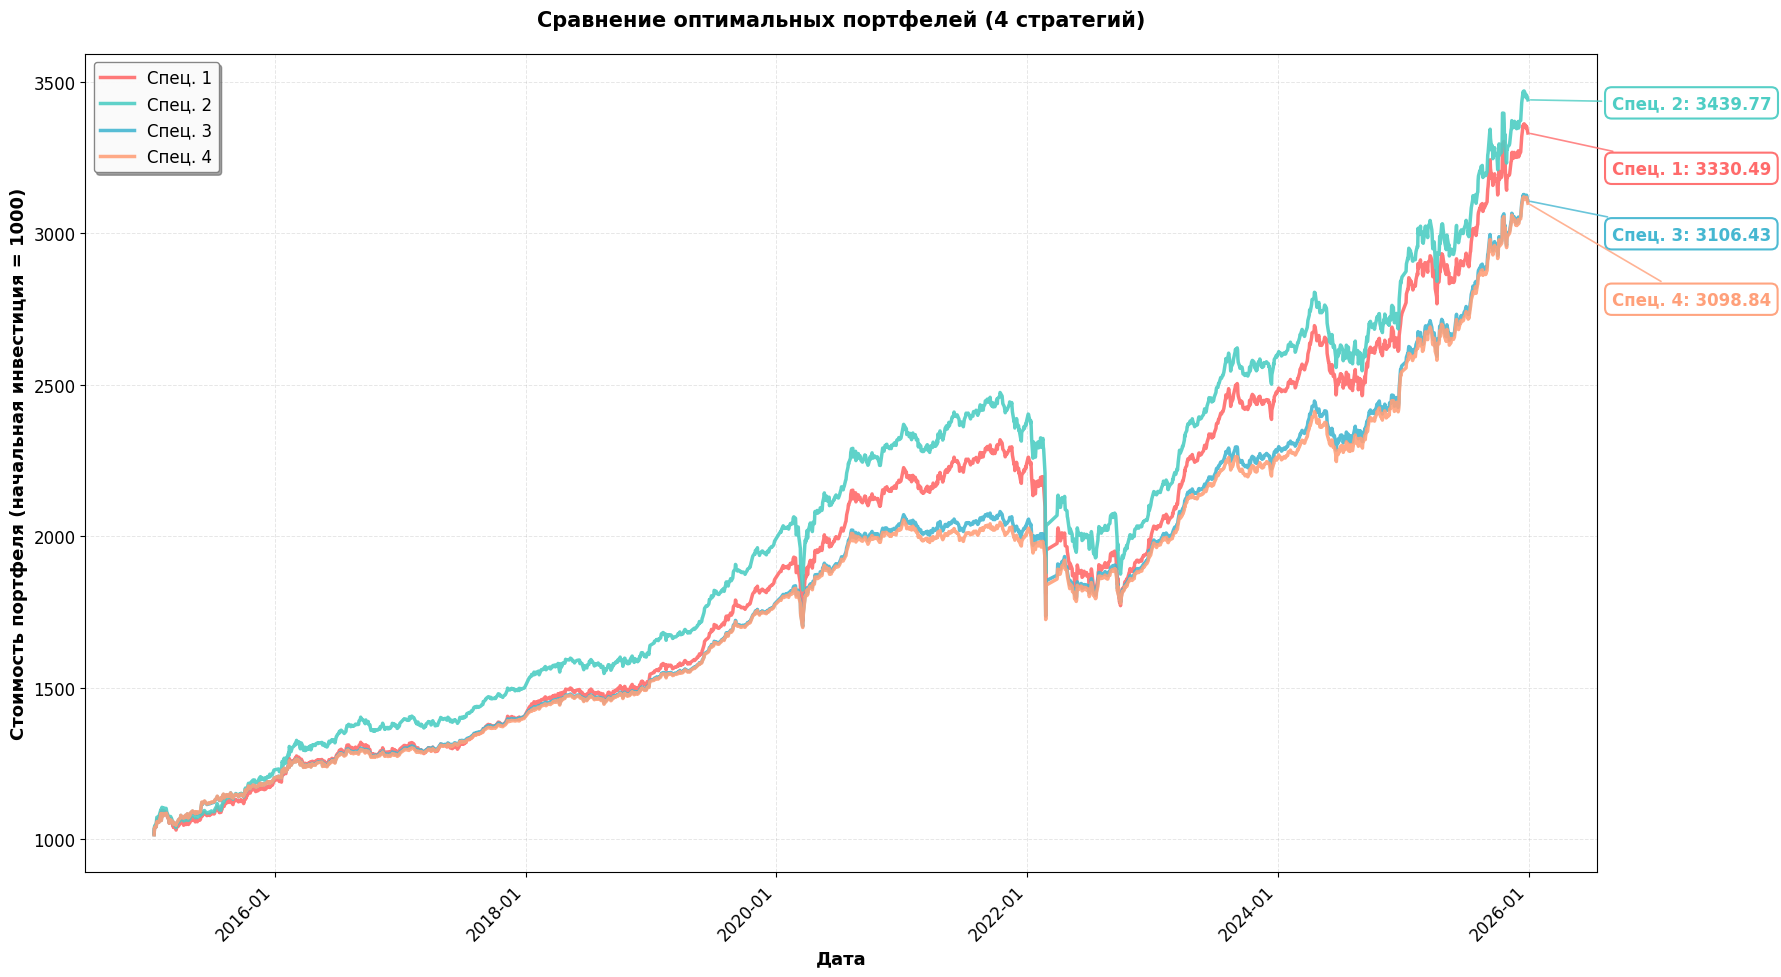


График 1 — Итоговая стоимость спецификаций:
  Спец. 1: 3330.49
  Спец. 2: 3439.77
  Спец. 3: 3106.43
  Спец. 4: 3098.84
Лидер по итоговой стоимости: Спец. 2 (3439.77)
Для сравнительных графиков используется: Спец. 3


In [96]:
spec_values = pd.DataFrame(index=portfolio_3_daily_returns.index)
for label, (ret_df, w) in [
    ("Спец. 1", (portfolio_1_daily_returns, median_w1)),
    ("Спец. 2", (portfolio_2_daily_returns, median_w2)),
    ("Спец. 3", (portfolio_3_daily_returns, median_w3)),
    ("Спец. 4", (portfolio_4_daily_returns, median_w4)),
]:
    port_ret = _portfolio_return_series(ret_df, w)
    spec_values[label] = 1000 * (1 + port_ret).cumprod()
spec_values = spec_values.dropna()
 
filepath, _ = plot_portfolio_comparison(
    portfolio_values=spec_values,
    portfolio_number=None,
    initial_investment=1000,
    save_dir="figures",
    filename="comparison_1_specs",
    fmt="pdf",
)
 
print("\nГрафик 1 — Итоговая стоимость спецификаций:")
for col in spec_values.columns:
    print(f"  {col}: {spec_values[col].iloc[-1]:.2f}")
 
top_spec_by_value = spec_values.iloc[-1].idxmax()
print(f"Лидер по итоговой стоимости: {top_spec_by_value} "
      f"({spec_values[top_spec_by_value].iloc[-1]:.2f})")

best_spec_name = "Спец. 3"  # выбрана по downside-метрикам
print(f"Для сравнительных графиков используется: {best_spec_name}")

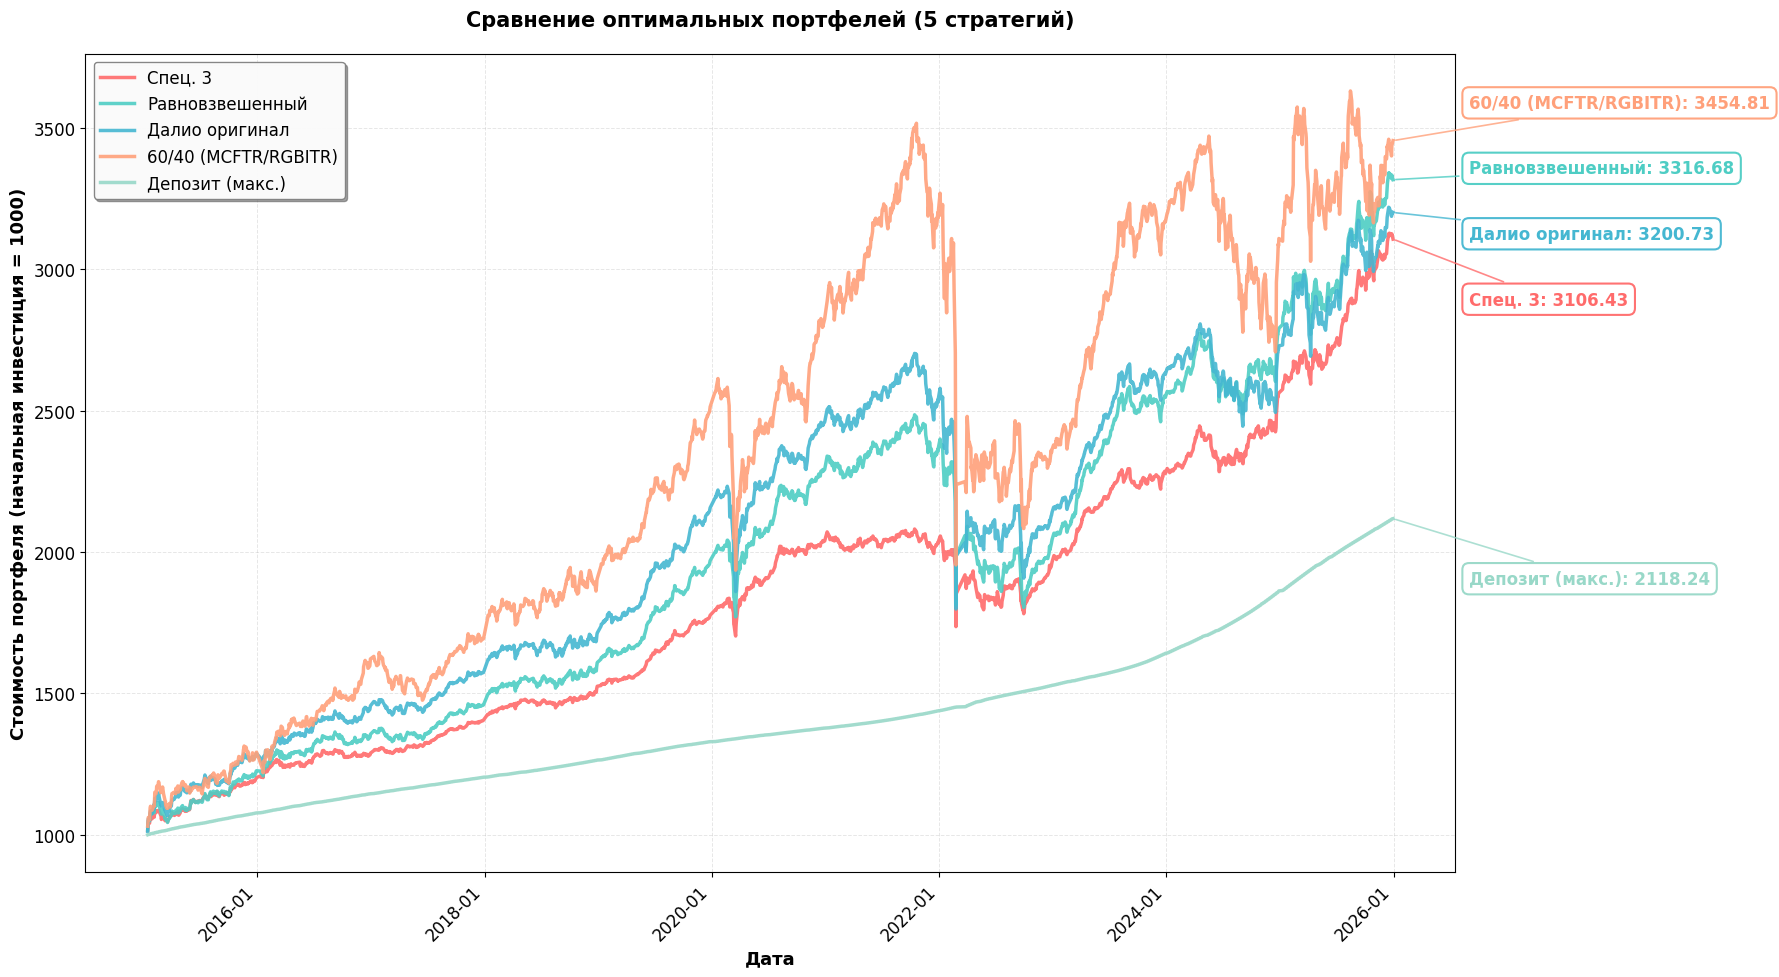


График 2 — Итоговая стоимость стратегий аллокации:
  Спец. 3: 3106.43
  Равновзвешенный: 3316.68
  Далио оригинал: 3200.73
  60/40 (MCFTR/RGBITR): 3454.81
  Депозит (макс.): 2118.24


In [97]:
spec_map = {
    "Спец. 1": (portfolio_1_daily_returns, median_w1),
    "Спец. 2": (portfolio_2_daily_returns, median_w2),
    "Спец. 3": (portfolio_3_daily_returns, median_w3),
    "Спец. 4": (portfolio_4_daily_returns, median_w4),
}
best_ret_df, best_weights = spec_map[best_spec_name]
best_port_ret = _portfolio_return_series(best_ret_df, best_weights)
 
strategy_values = pd.DataFrame(index=portfolio_3_daily_returns.index)
 
strategy_values[best_spec_name] = 1000 * (1 + best_port_ret).cumprod()
for label, w in [
    ("Равновзвешенный", equal_w3),
    ("Далио оригинал", weights_dalio),
]:
    port_ret = _portfolio_return_series(portfolio_3_daily_returns, w)
    strategy_values[label] = 1000 * (1 + port_ret).cumprod()
 
ret_60_40 = _portfolio_return_series(portfolio_60_40_returns, weights_60_40)
cum_60_40 = 1000 * (1 + ret_60_40).cumprod()
cum_60_40.index = pd.to_datetime(cum_60_40.index)
strategy_values["60/40 (MCFTR/RGBITR)"] = cum_60_40.reindex(
    strategy_values.index, method="ffill"
)
 
strategy_values["Депозит (макс.)"] = 1000 * (1 + deposit_daily_ret).cumprod()
 
strategy_values = strategy_values.dropna()
 
filepath, _ = plot_portfolio_comparison(
    portfolio_values=strategy_values,
    portfolio_number=None,
    initial_investment=1000,
    save_dir="figures",
    filename="comparison_3_strategies",
    fmt="pdf",
)
 
print("\nГрафик 2 — Итоговая стоимость стратегий аллокации:")
for col in strategy_values.columns:
    print(f"  {col}: {strategy_values[col].iloc[-1]:.2f}")

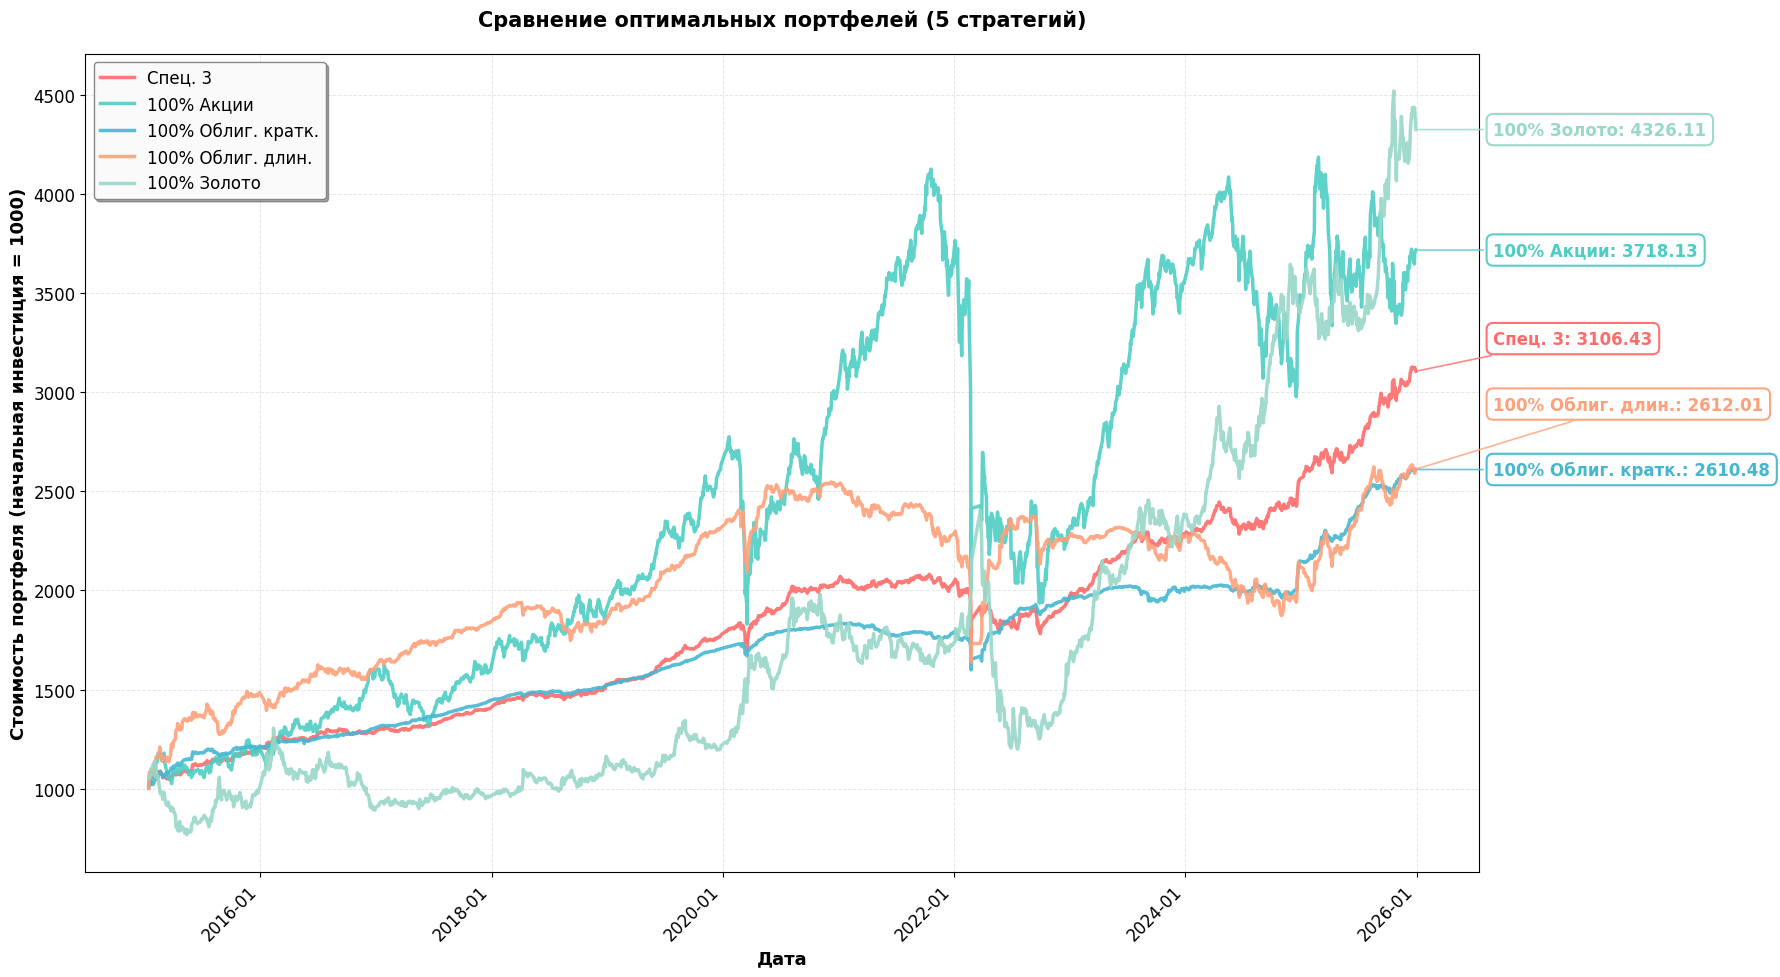


График 3 — Итоговая стоимость одноклассовых вложений:
  Спец. 3: 3106.43
  100% Акции: 3718.13
  100% Облиг. кратк.: 2610.48
  100% Облиг. длин.: 2612.01
  100% Золото: 4326.11


In [98]:
asset_values = pd.DataFrame(index=portfolio_3_daily_returns.index)
asset_values[best_spec_name] = 1000 * (1 + best_port_ret).cumprod()
for label, w in [
    ("100% Акции", only_equity),
    ("100% Облиг. кратк.", only_bond_short),
    ("100% Облиг. длин.", only_bond_long),
    ("100% Золото", only_gold),
]:
    port_ret = _portfolio_return_series(portfolio_3_daily_returns, w)
    asset_values[label] = 1000 * (1 + port_ret).cumprod()
 
asset_values = asset_values.dropna()
 
filepath, _ = plot_portfolio_comparison(
    portfolio_values=asset_values,
    portfolio_number=None,
    initial_investment=1000,
    save_dir="figures",
    filename="comparison_4_vs_assets",
    fmt="pdf",
)
 
print("\nГрафик 3 — Итоговая стоимость одноклассовых вложений:")
for col in asset_values.columns:
    print(f"  {col}: {asset_values[col].iloc[-1]:.2f}")

### 3.8. Устойчивость ранжирования спецификаций

In [99]:
def align_specs_to_common_dates(
    specs: Mapping[str, tuple[pd.DataFrame, np.ndarray]],
) -> dict[str, tuple[pd.DataFrame, np.ndarray]]:
    """Оставляет только даты, общие для всех сравниваемых спецификаций.

    Args:
        specs: Словарь вида ``{name: (daily_returns, weights)}``.

    Returns:
        Спецификации на общем отсортированном DatetimeIndex.

    Raises:
        ValueError: Передано меньше двух спецификаций или общих дат нет.

    Side Effects:
        Печатает диапазон общих торговых дат.
    """
    if len(specs) < 2:
        raise ValueError("At least two specifications are required")

    common_dates: pd.DatetimeIndex | None = None
    for returns, _ in specs.values():
        if not isinstance(returns.index, pd.DatetimeIndex):
            raise TypeError("Specification returns must use a DatetimeIndex")
        common_dates = (
            returns.index
            if common_dates is None
            else common_dates.intersection(returns.index)
        )

    assert common_dates is not None
    common_dates = common_dates.sort_values()
    if common_dates.empty:
        raise ValueError("Specifications do not have common trading dates")

    aligned_specs = {
        name: (returns.loc[common_dates], np.asarray(weights, dtype=np.float64))
        for name, (returns, weights) in specs.items()
    }
    print(
        f"Общих торговых дней: {len(common_dates)} "
        f"({common_dates.min().date()} - {common_dates.max().date()})"
    )
    return aligned_specs

def criterion_total_return(
    daily_returns: pd.DataFrame,
    weights: np.ndarray,
) -> float:
    """Возвращает итоговую buy-and-hold доходность для ранжирования."""
    portfolio_returns = _portfolio_return_series(daily_returns, weights)
    return float((1.0 + portfolio_returns).prod() - 1.0)

def criterion_max_drawdown(
    daily_returns: pd.DataFrame,
    weights: np.ndarray,
) -> float:
    """Возвращает максимальную просадку портфеля для ранжирования спецификаций."""
    return calculate_portfolio_max_drawdown(daily_returns, weights)

def criterion_sortino(
    daily_returns: pd.DataFrame,
    weights: np.ndarray,
) -> float:
    """Возвращает Sortino с текущим MAR для ранжирования спецификаций."""
    return calculate_portfolio_sortino_ratio(
        daily_returns,
        weights,
        risk_free_rate=None,
        mar=mar,
        mar_annual=True,
    )

def criterion_cvar(
    daily_returns: pd.DataFrame,
    weights: np.ndarray,
) -> float:
    """Возвращает CVaR reward-risk ratio для ранжирования спецификаций."""
    return calculate_portfolio_cvar_ratio(
        daily_returns,
        weights,
        risk_free_rate,
        alpha=0.05,
    )

def criterion_calmar(
    daily_returns: pd.DataFrame,
    weights: np.ndarray,
) -> float:
    """Возвращает Calmar ratio для ранжирования спецификаций."""
    return calculate_portfolio_calmar_ratio(daily_returns, weights)


specs = align_specs_to_common_dates(
    {
        "Спец. 1 (медиана)": (portfolio_1_daily_returns, median_w1),
        "Спец. 2 (медиана)": (portfolio_2_daily_returns, median_w2),
        "Спец. 3 (медиана)": (portfolio_3_daily_returns, median_w3),
        "Спец. 4 (медиана)": (portfolio_4_daily_returns, median_w4),
    }
)

Общих торговых дней: 2062 (2015-01-14 - 2025-12-30)


In [100]:
print("=== Критерий: итоговая доходность (больше - лучше) ===")
rank_stability_total_return = bootstrap_rank_stability(
    specs,
    criterion_total_return,
    higher_is_better=True,
    n_boot=1000,
    seed=1,
)

print("\n=== Критерий: MDD (меньше - лучше) ===")
rank_stability_max_drawdown_jackknife = jackknife_by_year_rank_stability(
    specs,
    criterion_max_drawdown,
    higher_is_better=False,
)

=== Критерий: итоговая доходность (больше - лучше) ===
Block bootstrap: n_boot=1000, block=63, criterion=max
Baseline leader: Спец. 1 (медиана)
Спец. 1 (медиана) baseline=1 modal=2 P(same)=35.0% CI=[0.9751, 6.9136]
Спец. 2 (медиана) baseline=2 modal=1 P(same)=25.4% CI=[0.8754, 7.0581]
Спец. 3 (медиана) baseline=4 modal=4 P(same)=57.3% CI=[0.9616, 5.1080]
Спец. 4 (медиана) baseline=3 modal=3 P(same)=43.8% CI=[1.0932, 5.1972]
P(top-1 unchanged): 35.0%
Mean rank correlation: 0.603

=== Критерий: MDD (меньше - лучше) ===
Jackknife by year, criterion=min
excluded=2015: {'Спец. 1 (медиана)': 3, 'Спец. 2 (медиана)': 4, 'Спец. 3 (медиана)': 2, 'Спец. 4 (медиана)': 1}
excluded=2016: {'Спец. 1 (медиана)': 3, 'Спец. 2 (медиана)': 4, 'Спец. 3 (медиана)': 2, 'Спец. 4 (медиана)': 1}
excluded=2017: {'Спец. 1 (медиана)': 3, 'Спец. 2 (медиана)': 4, 'Спец. 3 (медиана)': 2, 'Спец. 4 (медиана)': 1}
excluded=2018: {'Спец. 1 (медиана)': 3, 'Спец. 2 (медиана)': 4, 'Спец. 3 (медиана)': 2, 'Спец. 4 (медиана)':

In [101]:
rank_stability_sortino = bootstrap_rank_stability(
    specs,
    criterion_sortino,
    higher_is_better=True,
    n_boot=1000,
    seed=1,
)
rank_stability_cvar = bootstrap_rank_stability(
    specs,
    criterion_cvar,
    higher_is_better=True,
    n_boot=1000,
    seed=1,
)
rank_stability_calmar_jackknife = jackknife_by_year_rank_stability(
    specs,
    criterion_calmar,
    higher_is_better=True,
)

Block bootstrap: n_boot=1000, block=63, criterion=max
Baseline leader: Спец. 4 (медиана)
Спец. 1 (медиана) baseline=2 modal=2 P(same)=46.8% CI=[-0.1804, 2.0770]
Спец. 2 (медиана) baseline=3 modal=1 P(same)=30.1% CI=[-0.2250, 2.0877]
Спец. 3 (медиана) baseline=4 modal=4 P(same)=47.5% CI=[-0.2935, 1.9462]
Спец. 4 (медиана) baseline=1 modal=1 P(same)=36.4% CI=[-0.1732, 1.9871]
P(top-1 unchanged): 36.4%
Mean rank correlation: 0.311
Block bootstrap: n_boot=1000, block=63, criterion=max
Baseline leader: Спец. 4 (медиана)
Спец. 1 (медиана) baseline=2 modal=2 P(same)=43.7% CI=[-0.0015, 0.0433]
Спец. 2 (медиана) baseline=4 modal=1 P(same)=26.5% CI=[-0.0026, 0.0436]
Спец. 3 (медиана) baseline=3 modal=4 P(same)=33.4% CI=[-0.0032, 0.0429]
Спец. 4 (медиана) baseline=1 modal=1 P(same)=47.0% CI=[-0.0005, 0.0427]
P(top-1 unchanged): 47.0%
Mean rank correlation: 0.201
Jackknife by year, criterion=max
excluded=2015: {'Спец. 1 (медиана)': 3, 'Спец. 2 (медиана)': 4, 'Спец. 3 (медиана)': 2, 'Спец. 4 (медиа

## 4. Регрессионный анализ факторов доходности buy-and-hold портфеля

Зависимая переменная — месячная логарифмическая доходность **того же buy-and-hold портфеля спецификации 3**, который исследуется в портфельной части. Медианные веса задаются один раз в начале периода, после чего фактические веса свободно дрейфуют вместе со стоимостью активов; ежемесячной ребалансировки нет.

Главная задача раздела — **выявление и интерпретация условных исторических факторных связей**, а не построение торговой прогнозной системы. Поэтому подтверждающий результат — полновыборочные HAC-оценки заранее заданных вложенных моделей M1–M5. Псевдовневыборочная expanding-window проверка является вторичной проверкой переносимости результата во времени и риска подгонки; она не меняет объяснительную постановку статьи.

Подтверждающие модели M1–M5 оцениваются на единой **теоретической выборке**, определяемой только заранее заданными переменными. Перебор BIC и LASSO используют отдельную **exploratory-выборку** со всеми доступными факторами. Это не позволяет пропускам вспомогательных рядов сокращать основную выборку и запрещает прямое сравнение AIC/BIC моделей, оценённых на разных наблюдениях.

Все коэффициенты трактуются как условные исторические ассоциации, а не причинные эффекты. Основная ковариационная оценка — HAC/Newey–West; поиск подмножеств и LASSO остаются проверками устойчивости, а не источником подтверждающих p-value.

In [102]:
from itertools import combinations

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.regression.linear_model import RegressionResultsWrapper
from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    breaks_cusumolsresid,
    breaks_hansen,
    het_breuschpagan,
    het_white,
    linear_reset,
)
from statsmodels.stats.outliers_influence import (
    OLSInfluence,
    variance_inflation_factor,
)
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss


# statsmodels регистрирует InterpolationWarning при импорте; подавляем только
# сообщение об ограниченной таблице критических значений KPSS.
warnings.filterwarnings(
    "ignore",
    message="The test statistic is outside of the range of p-values available",
)

REGRESSION_HAC_LAGS = 4
REGRESSION_ALPHA = 0.05
REGRESSION_BREAK_DATE = pd.Timestamp("2022-02-01")
MAX_EXPLORATORY_FEATURES = 5
MIN_EXPANDING_TRAIN = 60

THEORY_SPECS: dict[str, list[str]] = {
    "M1 Market": ["MOEXBMI"],
    "M2 + FX": ["MOEXBMI", "EUR_RUB"],
    "M3 + Rates": ["MOEXBMI", "EUR_RUB", "yield_spread"],
    "M4 + Activity": ["MOEXBMI", "EUR_RUB", "yield_spread", "org_turnover"],
    "M5 + Trade": [
        "MOEXBMI",
        "EUR_RUB",
        "yield_spread",
        "org_turnover",
        "import_value",
    ],
}
PRIMARY_MODEL_KEY = "M4 + Activity"
THEORY_VARIABLES = list(
    dict.fromkeys(
        variable
        for variables in THEORY_SPECS.values()
        for variable in variables
    )
)
PRIMARY_VARIABLES = THEORY_SPECS[PRIMARY_MODEL_KEY]

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)
FIGURE_DPI = 600
FIGURE_FMT = "pdf"


def save_regression_figure(
    fig: Figure,
    filename: str,
    *,
    dpi: int = FIGURE_DPI,
    fmt: str = FIGURE_FMT,
) -> Path:
    """Сохраняет регрессионную фигуру и возвращает путь к файлу."""
    if not filename.strip() or not fmt.strip():
        raise ValueError("filename and fmt must not be empty")
    path = FIGURE_DIR / f"{filename}.{fmt}"
    fig.savefig(path, dpi=dpi, bbox_inches="tight", format=fmt, facecolor="white")
    print(f"Сохранено: {path}")
    return path


# Совместимое имя: неизменённые последующие разделы сохраняют общие фигуры.
save_figure = save_regression_figure

### 4.1. Загрузка исходных данных регрессии

В этом подразделе собраны все файлы, используемые только факторным анализом: валютные курсы, MOEXBMI, Brent, RUONIA и месячная макроэкономическая таблица. Общая кривая ОФЗ `df_ofz` формируется ранее в подразделе 2.1, поскольку одновременно используется для безрисковой ставки портфельного анализа; здесь из неё строится только регрессионный спред 10Y–1Y.

In [103]:
REGRESSION_DIR = DATA_DIR / "данные для регрессии"
REGRESSION_FILE_SPECS: dict[str, tuple[str, dict[str, Any]]] = {
    "CNY_RUB": ("CNY_RUB.csv", {"sep": ",", "decimal": ",", "verbose": False}),
    "EUR_RUB": ("EUR_RUB.csv", {"sep": ",", "decimal": ",", "verbose": False}),
    "MOEXBMI": ("MOEXBMI.csv", {"verbose": False}),
    "USD_CNY": ("USD_CNY.csv", {"sep": ",", "decimal": ",", "verbose": False}),
    "USD_RUB": ("USD_RUB.csv", {"sep": ",", "decimal": ",", "verbose": False}),
    "BRENT": (
        "Фьючерс на нефть Brent.csv",
        {"sep": ",", "decimal": ",", "verbose": False},
    ),
}

required_regression_files = [
    *(REGRESSION_DIR / filename for filename, _ in REGRESSION_FILE_SPECS.values()),
    REGRESSION_DIR / "RUONIA.xlsx",
    REGRESSION_DIR / "показатели по месяцам.xlsx",
]
missing_regression_files = [
    str(path) for path in required_regression_files if not path.is_file()
]
if missing_regression_files:
    raise FileNotFoundError(
        "Missing regression source files: " + ", ".join(missing_regression_files)
    )

regression_source_frames = {
    name: read_dataframe(REGRESSION_DIR / filename, **kwargs)
    for name, (filename, kwargs) in REGRESSION_FILE_SPECS.items()
}
regression_source_frames.update(
    {
        "RUONIA": pd.read_excel(REGRESSION_DIR / "RUONIA.xlsx"),
        "monthly_data": pd.read_excel(
            REGRESSION_DIR / "показатели по месяцам.xlsx"
        ),
    }
)

# Явные присваивания упрощают статический анализ и устраняют скрытый globals().
df_CNY_RUB = regression_source_frames["CNY_RUB"]
df_EUR_RUB = regression_source_frames["EUR_RUB"]
df_MOEXBMI = regression_source_frames["MOEXBMI"]
df_USD_CNY = regression_source_frames["USD_CNY"]
df_USD_RUB = regression_source_frames["USD_RUB"]
df_BRENT = regression_source_frames["BRENT"]
df_RUONIA = regression_source_frames["RUONIA"]
df_monthly_data = regression_source_frames["monthly_data"]

print(f"Загружено {len(regression_source_frames)} регрессионных датасетов:")
for name, frame in regression_source_frames.items():
    print(f"  {name}: {frame.shape}")

Загружено 8 регрессионных датасетов:
  CNY_RUB: (3284, 7)
  EUR_RUB: (2836, 7)
  MOEXBMI: (2761, 20)
  USD_CNY: (2871, 7)
  USD_RUB: (2874, 7)
  BRENT: (2840, 7)
  RUONIA: (2701, 11)
  monthly_data: (13, 134)


### 4.2. Зависимая переменная и календарное выравнивание

In [104]:
def to_month_end_level(
    frame: pd.DataFrame,
    output_name: str,
    *,
    date_column: str,
    value_column: str,
    dayfirst: bool = True,
) -> pd.DataFrame:
    """Возвращает последнее доступное значение уровня в каждом месяце.

    Все месячные ряды получают календарный индекс конца месяца. Это исключает
    смешение доходности за месяц с фактором, измеренным в начале того же месяца.
    """
    if not isinstance(frame, pd.DataFrame):
        raise TypeError("frame must be a pandas.DataFrame")
    missing = {date_column, value_column}.difference(frame.columns)
    if missing:
        raise KeyError(f"Missing columns: {sorted(missing)}")

    data = frame[[date_column, value_column]].copy()
    data[date_column] = pd.to_datetime(
        data[date_column],
        dayfirst=dayfirst,
        errors="raise",
    )
    data[value_column] = pd.to_numeric(data[value_column], errors="coerce")
    data = (
        data.dropna(subset=[date_column, value_column])
        .sort_values(date_column)
        .drop_duplicates(subset=date_column, keep="last")
        .set_index(date_column)
    )
    if data.empty:
        raise ValueError(f"No valid observations for {output_name}")
    return (
        data[[value_column]]
        .resample("ME")
        .last()
        .rename(columns={value_column: output_name})
    )


def build_buy_and_hold_monthly_returns(
    asset_daily_returns: pd.DataFrame,
    initial_weights: np.ndarray,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    """Строит месячные доходности и фактические веса buy-and-hold портфеля.

    Канонический дневной ряд берётся из ``_portfolio_return_series`` портфельного
    блока. Месячная простая доходность — произведение дневных gross returns;
    логарифмическая доходность вычисляется через ``log1p``. Начальные веса не
    восстанавливаются в начале каждого месяца.
    """
    clean_returns, weights = _validate_inputs(asset_daily_returns, initial_weights)
    if not isinstance(clean_returns.index, pd.DatetimeIndex):
        raise TypeError("asset_daily_returns must use a DatetimeIndex")
    if not clean_returns.index.is_monotonic_increasing:
        clean_returns = clean_returns.sort_index()
    if clean_returns.index.has_duplicates:
        raise ValueError("asset_daily_returns index contains duplicate dates")

    portfolio_daily = _portfolio_return_series(clean_returns, weights)
    monthly_simple = (1.0 + portfolio_daily).resample("ME").prod() - 1.0
    monthly_log = np.log1p(monthly_simple)
    monthly_wealth = (1.0 + portfolio_daily).cumprod().resample("ME").last()

    asset_wealth = (1.0 + clean_returns).cumprod().mul(weights, axis="columns")
    effective_weights_daily = asset_wealth.div(asset_wealth.sum(axis=1), axis="index")
    effective_weights_monthly = effective_weights_daily.resample("ME").last()
    observations_per_month = portfolio_daily.resample("ME").count()

    monthly = pd.DataFrame(
        {
            "simple_return": monthly_simple,
            "log_return": monthly_log,
            "wealth": monthly_wealth,
        }
    )
    if not np.isclose(
        float((1.0 + monthly["simple_return"]).prod()),
        float(monthly["wealth"].iloc[-1]),
        rtol=1e-10,
        atol=1e-12,
    ):
        raise AssertionError("Monthly compounding does not reproduce daily wealth")
    if not np.allclose(effective_weights_monthly.sum(axis=1), 1.0, atol=1e-10):
        raise AssertionError("Effective buy-and-hold weights do not sum to one")
    return monthly, effective_weights_monthly, observations_per_month

In [105]:
def test_block_4_2_to_month_end_level_uses_last_observation() -> None:
    source = pd.DataFrame(
        {
            "Дата": ["02.01.2024", "15.01.2024", "03.02.2024"],
            "Цена": [101.0, 99.0, 105.0],
        }
    )
    result = to_month_end_level(
        source,
        "Asset",
        date_column="Дата",
        value_column="Цена",
    )
    assert result.index.tolist() == [pd.Timestamp("2024-01-31"), pd.Timestamp("2024-02-29")]
    assert result["Asset"].tolist() == [99.0, 105.0]


def test_block_4_2_buy_and_hold_monthly_preserves_drifting_weights() -> None:
    index = pd.to_datetime(["2024-01-02", "2024-01-03", "2024-02-01", "2024-02-02"])
    returns = pd.DataFrame(
        {"A": [0.10, 0.00, 0.10, 0.00], "B": [0.00, 0.00, 0.00, 0.00]},
        index=index,
    )
    monthly, effective_weights, counts = build_buy_and_hold_monthly_returns(
        returns,
        np.array([0.5, 0.5]),
    )
    daily = _portfolio_return_series(returns, np.array([0.5, 0.5]))
    expected = (1.0 + daily).resample("ME").prod() - 1.0
    pd.testing.assert_series_equal(monthly["simple_return"], expected, check_names=False)
    assert effective_weights.loc[pd.Timestamp("2024-02-29"), "A"] > 0.5
    assert counts.tolist() == [2, 2]

In [106]:
run_notebook_tests("test_block_4_2")

..                                                                                           [100%]


0

In [107]:
regression_asset_returns = (
    portfolio_3_daily_returns.loc[:, asset_names_3]
    .sort_index()
    .dropna(how="any")
)
regression_initial_weights = extract_median_weights(bounds_summary_3)

(
    portfolio_buy_hold_monthly,
    portfolio_effective_weights_monthly,
    portfolio_daily_observations_by_month,
) = build_buy_and_hold_monthly_returns(
    regression_asset_returns,
    regression_initial_weights,
)

# Совместимые имена для прозрачной сверки с прежней версией раздела.
monthly_simple_returns_portfolio = portfolio_buy_hold_monthly[["simple_return"]].rename(
    columns={"simple_return": "Portfolio"}
)
monthly_log_returns_portfolio = portfolio_buy_hold_monthly[["log_return"]].rename(
    columns={"log_return": "Portfolio"}
)
portfolio_monthly_coverage = (
    portfolio_daily_observations_by_month
    .rename("Trading observations")
    .rename_axis("date")
    .reset_index()
)

print("Начальные веса buy-and-hold портфеля:")
for asset, weight in zip(asset_names_3, regression_initial_weights):
    print(f"  {asset}: {weight:.4f} ({weight * 100:.2f}%)")

print("\nФактические веса в конце выборки (после дрейфа):")
for asset, weight in portfolio_effective_weights_monthly.iloc[-1].items():
    print(f"  {asset}: {weight:.4f} ({weight * 100:.2f}%)")

thin_months = portfolio_daily_observations_by_month[
    portfolio_daily_observations_by_month < 10
]
print(
    f"\nY: {monthly_log_returns_portfolio.shape[0]} месяцев; "
    f"{monthly_log_returns_portfolio.index.min():%Y-%m} — "
    f"{monthly_log_returns_portfolio.index.max():%Y-%m}."
)
if not thin_months.empty:
    print("Месяцы менее чем с 10 торговыми наблюдениями (не удалены автоматически):")
    print(thin_months.to_string())

Начальные веса buy-and-hold портфеля:
  MCFTR: 0.1041 (10.41%)
  RUGBITR3Y: 0.5407 (54.07%)
  RUGBITR10Y: 0.1335 (13.35%)
  GLDRUB_TOM: 0.2217 (22.17%)

Фактические веса в конце выборки (после дрейфа):
  MCFTR: 0.1246 (12.46%)
  RUGBITR3Y: 0.4543 (45.43%)
  RUGBITR10Y: 0.1122 (11.22%)
  GLDRUB_TOM: 0.3088 (30.88%)

Y: 132 месяцев; 2015-01 — 2025-12.
Месяцы менее чем с 10 торговыми наблюдениями (не удалены автоматически):
TRADEDATE
2022-03-31    4
Freq: ME


In [108]:
df_MOEXBMI_m = to_month_end_level(
    df_MOEXBMI,
    "MOEXBMI",
    date_column="TRADEDATE",
    value_column="CLOSE",
)
moex_monthly_log_returns = np.log(df_MOEXBMI_m).diff().rename(
    columns={"MOEXBMI": "MOEXBMI"}
)

df_CNY_RUB_m = to_month_end_level(
    df_CNY_RUB, "CNY_RUB", date_column="Дата", value_column="Цена"
)
df_EUR_RUB_m = to_month_end_level(
    df_EUR_RUB, "EUR_RUB", date_column="Дата", value_column="Цена"
)
df_USD_RUB_m = to_month_end_level(
    df_USD_RUB, "USD_RUB", date_column="Дата", value_column="Цена"
)
df_USD_CNY_m = to_month_end_level(
    df_USD_CNY, "USD_CNY", date_column="Дата", value_column="Цена"
)
df_BRENT_m = to_month_end_level(
    df_BRENT, "BRENT", date_column="Дата", value_column="Цена"
)
df_RUONIA_m = to_month_end_level(
    df_RUONIA,
    "RUONIA",
    date_column="DT",
    value_column="ruo",
    dayfirst=False,
)

df_gcurve = (
    df_ofz[["tradedate", "period_1.0", "period_10.0"]]
    .copy()
    .assign(tradedate=lambda frame: pd.to_datetime(frame["tradedate"], errors="raise"))
    .sort_values("tradedate")
    .set_index("tradedate")
    .rename(columns={"period_1.0": "yield_1Y", "period_10.0": "yield_10Y"})
)
df_gcurve_m = df_gcurve.resample("ME").last()
df_yield_spread_m = (
    df_gcurve_m["yield_10Y"].sub(df_gcurve_m["yield_1Y"])
    .rename("yield_spread")
    .to_frame()
)

In [109]:
daily_factor_frames = [
    df_CNY_RUB_m,
    df_EUR_RUB_m,
    df_USD_RUB_m,
    df_USD_CNY_m,
    df_BRENT_m,
    df_RUONIA_m,
    df_yield_spread_m,
]
df_daily_macro = pd.concat(
    daily_factor_frames, axis="columns", join="outer", sort=False
).sort_index()

MONTHLY_MACRO_COLUMNS = [
    "budget_deficit_ratio",
    "gov_debt_internal",
    "gov_debt_external",
    "M2",
    "key_rate",
    "inflation",
    "output_index",
    "avg_wage",
    "org_turnover",
    "industry_prod_idx",
    "export_value",
    "import_value",
    "moex_volume",
]

if len(df_monthly_data) != len(MONTHLY_MACRO_COLUMNS):
    raise ValueError(
        "Unexpected number of monthly macro indicators: "
        f"{len(df_monthly_data)} instead of {len(MONTHLY_MACRO_COLUMNS)}"
    )

monthly_macro_metadata = pd.DataFrame(
    {
        "Source label": df_monthly_data.iloc[:, 0].astype(str).str.strip().to_numpy(),
        "Source unit": df_monthly_data.iloc[:, 1].astype(str).str.strip().to_numpy(),
    },
    index=pd.Index(MONTHLY_MACRO_COLUMNS, name="Variable"),
)
daily_factor_metadata = pd.DataFrame.from_dict(
    {
        "CNY_RUB": ("Курс CNY/RUB, конец месяца", "рублей за юань"),
        "EUR_RUB": ("Курс EUR/RUB, конец месяца", "рублей за евро"),
        "USD_RUB": ("Курс USD/RUB, конец месяца", "рублей за доллар США"),
        "USD_CNY": ("Курс USD/CNY, конец месяца", "юаней за доллар США"),
        "BRENT": ("Цена фьючерса Brent, конец месяца", "долларов США за баррель"),
        "RUONIA": ("RUONIA, последнее наблюдение месяца", "% годовых"),
        "yield_spread": ("Спред доходностей ОФЗ 10Y–1Y", "процентных пунктов"),
    },
    orient="index",
    columns=["Source label", "Source unit"],
).rename_axis("Variable")
factor_metadata = pd.concat(
    [daily_factor_metadata, monthly_macro_metadata],
    axis="index",
)

df_monthly_macro = df_monthly_data.T.iloc[2:].copy()
if df_monthly_macro.shape[1] != len(MONTHLY_MACRO_COLUMNS):
    raise ValueError(
        "Unexpected number of monthly macro indicators after transpose: "
        f"{df_monthly_macro.shape[1]} instead of {len(MONTHLY_MACRO_COLUMNS)}"
    )
df_monthly_macro.columns = MONTHLY_MACRO_COLUMNS
df_monthly_macro.index = (
    pd.to_datetime(df_monthly_macro.index, errors="raise")
    .to_period("M")
    .to_timestamp("M")
)
df_monthly_macro = (
    df_monthly_macro.apply(pd.to_numeric, errors="coerce")
    .groupby(level=0)
    .last()
    .sort_index()
)

df_macro_levels = pd.concat(
    [df_daily_macro, df_monthly_macro],
    axis="columns",
    join="outer",
    sort=False,
).sort_index()
if set(factor_metadata.index) != set(df_macro_levels.columns):
    raise KeyError("Factor metadata and factor columns do not match")

print(
    f"Сырые факторы: {df_macro_levels.shape[1]} рядов, "
    f"{df_macro_levels.index.min():%Y-%m} — {df_macro_levels.index.max():%Y-%m}."
)

Сырые факторы: 20 рядов, 2015-01 — 2025-12.


### 4.3. Предварительно заданные преобразования факторов

Преобразования фиксируют экономический смысл переменных до оценивания моделей. Для уровней цен и курсов используются лог-приросты, для ставок — изменения в процентных пунктах. `output_index` и `industry_prod_idx` в исходном XLSX уже выражены относительно соответствующего периода предыдущего года, поэтому применяется их месячное изменение в пунктах индекса, а не ещё один темп роста. Для сезонных номинальных уровней используются годовые log-приросты; дополнительная первая разность применяется только там, где одного годового преобразования недостаточно для совместного прохождения ADF и KPSS.

Паспорт преобразований автоматически объединяет код переменной, исходное название, единицу измерения, фактически применённую операцию и её конкретную экономическую интерпретацию.

In [110]:
TRANSFORMATION_SPEC: dict[str, str] = {
    "CNY_RUB": "log_diff_1",
    "EUR_RUB": "log_diff_1",
    "USD_RUB": "log_diff_1",
    "USD_CNY": "log_diff_1",
    "BRENT": "log_diff_1",
    "RUONIA": "diff_1",
    "yield_spread": "diff_1",
    "budget_deficit_ratio": "diff_12_diff_1",
    "gov_debt_internal": "log_diff_1",
    "gov_debt_external": "log_diff_1",
    "M2": "log_diff_12_diff_1",
    "key_rate": "diff_1",
    "inflation": "diff_1",
    "output_index": "diff_1",
    "avg_wage": "log_diff_12_diff_1",
    "org_turnover": "log_diff_12",
    "industry_prod_idx": "diff_1",
    "export_value": "log_diff_12_diff_1",
    "import_value": "log_diff_1",
    "moex_volume": "log_diff_1",
}

TRANSFORMATION_MEANING = {
    "log_diff_1": "месячный логарифмический темп прироста",
    "log_diff_12": "годовой логарифмический темп прироста",
    "log_diff_12_diff_1": "месячное изменение годового log-темпа прироста",
    "diff_1": "месячное изменение в исходных единицах",
    "diff_12": "годовое изменение в исходных единицах",
    "diff_12_diff_1": "месячное изменение годовой разности",
}

VARIABLE_TRANSFORM_MEANING = {
    "RUONIA": "месячное изменение RUONIA, процентных пунктов",
    "yield_spread": "месячное изменение спреда ОФЗ 10Y–1Y, процентных пунктов",
    "budget_deficit_ratio": "месячное изменение годовой разности бюджетного отношения",
    "key_rate": "месячное изменение ключевой ставки, процентных пунктов",
    "inflation": "месячное изменение инфляции г/г, процентных пунктов",
    "output_index": "месячное изменение уже годового индекса выпуска, пунктов индекса",
    "industry_prod_idx": "месячное изменение уже годового индекса промышленности, пунктов индекса",
    "org_turnover": "годовой логарифмический темп прироста оборота организаций",
    "import_value": "месячный логарифмический темп прироста стоимостного импорта",
}


def transform_factor_series(series: pd.Series, method: str) -> pd.Series:
    """Применяет одно явно заданное стационаризирующее преобразование."""
    numeric = pd.to_numeric(series, errors="coerce").astype(float)
    if method.startswith("log_"):
        observed = numeric.dropna()
        if observed.empty or (observed <= 0).any():
            raise ValueError(f"{series.name}: log transformation requires positive values")
        numeric = np.log(numeric)
    operations: dict[str, Callable[[pd.Series], pd.Series]] = {
        "log_diff_1": lambda values: values.diff(1),
        "log_diff_12": lambda values: values.diff(12),
        "log_diff_12_diff_1": lambda values: values.diff(12).diff(1),
        "diff_1": lambda values: values.diff(1),
        "diff_12": lambda values: values.diff(12),
        "diff_12_diff_1": lambda values: values.diff(12).diff(1),
    }
    if method not in operations:
        raise ValueError(f"Unknown transformation: {method}")
    return operations[method](numeric).rename(series.name)


def transform_factor_frame(
    levels: pd.DataFrame,
    specification: Mapping[str, str],
    metadata: pd.DataFrame | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Преобразует факторы по исчерпывающей спецификации и строит паспорт."""
    missing_spec = set(levels.columns).difference(specification)
    extra_spec = set(specification).difference(levels.columns)
    if missing_spec or extra_spec:
        raise KeyError(
            f"Transformation specification mismatch; missing={sorted(missing_spec)}, "
            f"extra={sorted(extra_spec)}"
        )
    if metadata is not None:
        missing_metadata = set(levels.columns).difference(metadata.index)
        if missing_metadata:
            raise KeyError(f"Missing factor metadata: {sorted(missing_metadata)}")

    transformed = pd.concat(
        [transform_factor_series(levels[column], specification[column]) for column in levels],
        axis="columns",
        sort=False,
    )
    rows = []
    for column in levels:
        method = specification[column]
        rows.append(
            {
                "Variable": column,
                "Source label": (
                    str(metadata.loc[column, "Source label"])
                    if metadata is not None else column
                ),
                "Source unit": (
                    str(metadata.loc[column, "Source unit"])
                    if metadata is not None else ""
                ),
                "Transformation": method,
                "Economic meaning": VARIABLE_TRANSFORM_MEANING.get(
                    column,
                    TRANSFORMATION_MEANING[method],
                ),
                "N after transformation": int(transformed[column].notna().sum()),
            }
        )
    return transformed, pd.DataFrame(rows)

In [111]:
def test_block_4_3_transform_factor_series_has_explicit_contract() -> None:
    positive = pd.Series([100.0, 110.0, 121.0], name="x")
    result = transform_factor_series(positive, "log_diff_1")
    assert np.isclose(result.iloc[1], np.log(1.1))
    log_linear = pd.Series(np.exp(np.arange(15) * 0.01), name="trend")
    second_difference = transform_factor_series(
        log_linear, "log_diff_12_diff_1"
    )
    assert np.isclose(second_difference.iloc[13], 0.0, atol=1e-12)
    with pytest.raises(ValueError):
        transform_factor_series(pd.Series([1.0, 0.0], name="x"), "log_diff_1")
    with pytest.raises(ValueError):
        transform_factor_series(positive, "unknown")


def test_block_4_3_transform_factor_frame_rejects_incomplete_spec() -> None:
    with pytest.raises(KeyError):
        transform_factor_frame(pd.DataFrame({"x": [1.0, 2.0]}), {})

In [112]:
run_notebook_tests("test_block_4_3")

..                                                                                           [100%]


0

In [113]:
df_macro_transformed_raw, transformation_report = transform_factor_frame(
    df_macro_levels,
    TRANSFORMATION_SPEC,
    factor_metadata,
)
display(transformation_report)

regression_panel = pd.concat(
    [
        monthly_log_returns_portfolio,
        moex_monthly_log_returns,
        df_macro_transformed_raw,
    ],
    axis="columns",
    join="inner",
    sort=False,
).sort_index()
if regression_panel.empty:
    raise ValueError("No observations after calendar alignment")
if regression_panel.index.has_duplicates or not regression_panel.index.is_monotonic_increasing:
    raise ValueError("Regression index must be unique and sorted")

all_factor_variables = ["MOEXBMI", *df_macro_transformed_raw.columns.tolist()]
theory_data = regression_panel[["Portfolio", *THEORY_VARIABLES]].dropna(how="any")
exploratory_data = regression_panel[["Portfolio", *all_factor_variables]].dropna(how="any")
if theory_data.empty or exploratory_data.empty:
    raise ValueError("No complete observations in a regression sample")

Y_theory = theory_data["Portfolio"].rename("Portfolio")
X_theory = theory_data[THEORY_VARIABLES].copy()
Y_exploratory = exploratory_data["Portfolio"].rename("Portfolio")
X_exploratory = exploratory_data[all_factor_variables].copy()

# Совместимые короткие имена относятся только к подтверждающей выборке.
Y = Y_theory
X_all = X_theory
X_market = X_exploratory[["MOEXBMI"]]
X_macro_all = X_exploratory.drop(columns="MOEXBMI")
df_macro_transformed = X_macro_all.copy()

def _sample_row(name: str, frame: pd.DataFrame, factor_count: int) -> dict[str, Any]:
    return {
        "Sample": name,
        "N": int(len(frame)),
        "Start": frame.index.min(),
        "End": frame.index.max(),
        "Factors": int(factor_count),
    }


sample_audit = pd.DataFrame(
    [
        _sample_row("Aligned panel before complete-case", regression_panel, len(all_factor_variables)),
        _sample_row("Theory common sample M1–M5", theory_data, len(THEORY_VARIABLES)),
        _sample_row("Exploratory complete-case sample", exploratory_data, len(all_factor_variables)),
    ]
)

missingness = regression_panel[["Portfolio", *all_factor_variables]].isna()
sample_missing_months = pd.DataFrame(
    {
        "date": regression_panel.index,
        "Missing in theory sample": [
            ", ".join(
                theory_missing.index[theory_missing]
            )
            for date in regression_panel.index
            for theory_missing in [
                missingness.loc[date, ["Portfolio", *THEORY_VARIABLES]]
            ]
        ],
        "Missing in exploratory sample": [
            ", ".join(missingness.columns[missingness.loc[date]])
            for date in regression_panel.index
        ],
    }
)
sample_missing_months = sample_missing_months.loc[
    (sample_missing_months["Missing in theory sample"] != "")
    | (sample_missing_months["Missing in exploratory sample"] != "")
].reset_index(drop=True)

display(sample_audit)
if not sample_missing_months.empty:
    print("Месяцы, исключаемые complete-case правилом:")
    display(sample_missing_months)
print(
    "Основная и exploratory-выборки разделены: вспомогательные факторы "
    "не сокращают подтверждающие модели M1–M5."
)

,Variable,Source label,Source unit,Transformation,Economic meaning,N after transformation
0,CNY_RUB,"Курс CNY/RUB, конец месяца",рублей за юань,log_diff_1,месячный логарифмический темп прироста,131
1,EUR_RUB,"Курс EUR/RUB, конец месяца",рублей за евро,log_diff_1,месячный логарифмический темп прироста,131
2,USD_RUB,"Курс USD/RUB, конец месяца",рублей за доллар США,log_diff_1,месячный логарифмический темп прироста,131
3,USD_CNY,"Курс USD/CNY, конец месяца",юаней за доллар США,log_diff_1,месячный логарифмический темп прироста,131
4,BRENT,"Цена фьючерса Brent, конец месяца",долларов США за баррель,log_diff_1,месячный логарифмический темп прироста,131
5,RUONIA,"RUONIA, последнее наблюдение месяца",% годовых,diff_1,"месячное изменение RUONIA, процентных пунктов",131
6,yield_spread,Спред доходностей ОФЗ 10Y–1Y,процентных пунктов,diff_1,"месячное изменение спреда ОФЗ 10Y–1Y, процентн...",131
7,budget_deficit_ratio,дефицит/профицит федерального бюджета к его ра...,%,diff_12_diff_1,месячное изменение годовой разности бюджетного...,119
8,gov_debt_internal,объем государственного внутреннего долга РФ,млрд. рублей,log_diff_1,месячный логарифмический темп прироста,131
9,gov_debt_external,объем государственного внешнего долга РФ,млн. долл. США,log_diff_1,месячный логарифмический темп прироста,131


,Sample,N,Start,End,Factors
0,Aligned panel before complete-case,132,2015-01-31,2025-12-31,21
1,Theory common sample M1–M5,120,2016-01-31,2025-12-31,5
2,Exploratory complete-case sample,119,2016-02-29,2025-12-31,21


Месяцы, исключаемые complete-case правилом:


,date,Missing in theory sample,Missing in exploratory sample
0,2015-01-31,"MOEXBMI, EUR_RUB, yield_spread, org_turnover, ...","MOEXBMI, CNY_RUB, EUR_RUB, USD_RUB, USD_CNY, B..."
1,2015-02-28,org_turnover,"budget_deficit_ratio, M2, avg_wage, org_turnov..."
2,2015-03-31,org_turnover,"budget_deficit_ratio, M2, avg_wage, org_turnov..."
3,2015-04-30,org_turnover,"budget_deficit_ratio, M2, avg_wage, org_turnov..."
4,2015-05-31,org_turnover,"budget_deficit_ratio, M2, avg_wage, org_turnov..."
5,2015-06-30,org_turnover,"budget_deficit_ratio, M2, avg_wage, org_turnov..."
6,2015-07-31,org_turnover,"budget_deficit_ratio, M2, avg_wage, org_turnov..."
7,2015-08-31,org_turnover,"budget_deficit_ratio, M2, avg_wage, org_turnov..."
8,2015-09-30,org_turnover,"budget_deficit_ratio, M2, avg_wage, org_turnov..."
9,2015-10-31,org_turnover,"budget_deficit_ratio, M2, avg_wage, org_turnov..."


Основная и exploratory-выборки разделены: вспомогательные факторы не сокращают подтверждающие модели M1–M5.


### 4.4. Стационарность, описательная статистика и мультиколлинеарность

ADF и KPSS рассчитываются для каждого ряда на всех доступных после календарного выравнивания наблюдениях; поэтому `N` отдельных тестов может различаться. VIF основной M4 приводится отдельно. VIF-фильтрация всего макронабора применяется только к exploratory-перебору и не меняет заранее заданные теоретические спецификации.

In [114]:
def assess_stationarity(
    series: pd.Series,
    *,
    alpha: float = REGRESSION_ALPHA,
) -> dict[str, float | bool | str | int | pd.Timestamp]:
    """Совмещает ADF (H0: единичный корень) и KPSS (H0: стационарность)."""
    clean = pd.to_numeric(series, errors="coerce").dropna().astype(float)
    if len(clean) < 20:
        raise ValueError(f"{series.name}: at least 20 observations are required")
    if clean.nunique() < 3:
        raise ValueError(f"{series.name}: series is effectively constant")
    try:
        adf_stat, adf_pvalue, *_ = adfuller(clean, autolag="AIC")
        kpss_stat, kpss_pvalue, *_ = kpss(clean, regression="c", nlags="auto")
        adf_stationary = bool(adf_pvalue < alpha)
        kpss_stationary = bool(kpss_pvalue > alpha)
        status = (
            "+" if adf_stationary and kpss_stationary
            else "±" if adf_stationary or kpss_stationary
            else "-"
        )
        error = ""
    except (ValueError, np.linalg.LinAlgError) as exc:
        adf_stat = adf_pvalue = kpss_stat = kpss_pvalue = np.nan
        adf_stationary = kpss_stationary = False
        status = "-"
        error = str(exc)
    return {
        "N": int(len(clean)),
        "Start": pd.Timestamp(clean.index.min()),
        "End": pd.Timestamp(clean.index.max()),
        "ADF statistic": float(adf_stat),
        "ADF p-value": float(adf_pvalue),
        "KPSS statistic": float(kpss_stat),
        "KPSS p-value": float(kpss_pvalue),
        "ADF stationary": adf_stationary,
        "KPSS stationary": kpss_stationary,
        "Stationary": bool(adf_stationary and kpss_stationary),
        "Status": status,
        "Error": error,
    }


def stationarity_report(frame: pd.DataFrame) -> pd.DataFrame:
    """Возвращает компактную таблицу ADF+KPSS для всех столбцов."""
    rows = []
    for name, series in frame.items():
        rows.append({"Variable": name, **assess_stationarity(series)})
    return pd.DataFrame(rows).set_index("Variable")

In [115]:
def test_block_4_4_stationarity_report_returns_complete_contract() -> None:
    rng = np.random.default_rng(42)
    frame = pd.DataFrame({"white_noise": rng.normal(size=160)})
    report = stationarity_report(frame)
    assert {"ADF p-value", "KPSS p-value", "Stationary", "Status"}.issubset(report.columns)
    assert report.loc["white_noise", "Status"] in {"+", "±", "-"}

In [116]:
run_notebook_tests("test_block_4_4")

.                                                                                            [100%]


0

In [117]:
stationarity_input = regression_panel[["Portfolio", *all_factor_variables]]
stationarity_table = stationarity_report(stationarity_input)
stationarity_display = stationarity_table.copy()
stationarity_numeric_columns = stationarity_display.select_dtypes(include=[np.number]).columns
stationarity_display.loc[:, stationarity_numeric_columns] = (
    stationarity_display.loc[:, stationarity_numeric_columns].round(4)
)
display(stationarity_display)

stationarity_failures = stationarity_table.index[
    ~stationarity_table["Stationary"]
].tolist()
if stationarity_failures:
    print(
        "Внимание: ADF и KPSS не дали совместного подтверждения стационарности для: "
        + ", ".join(stationarity_failures)
    )
    print(
        "Они будут исключены из exploratory-отбора. Основная модель должна "
        "содержать только стационарные факторы."
    )
else:
    print("ADF и KPSS совместно подтверждают стационарность всех рядов.")

nonstationary_primary = [
    variable
    for variable in THEORY_VARIABLES
    if not bool(stationarity_table.loc[variable, "Stationary"])
]

,N,Start,End,ADF statistic,ADF p-value,KPSS statistic,KPSS p-value,ADF stationary,KPSS stationary,Stationary,Status,Error
Variable,,,,,,,,,,,,
Portfolio,132,2015-01-31,2025-12-31,-3.4764,0.0086,0.1654,0.1,True,True,True,+,
MOEXBMI,131,2015-02-28,2025-12-31,-12.2919,0.0000,0.1250,0.1,True,True,True,+,
CNY_RUB,131,2015-02-28,2025-12-31,-5.3753,0.0000,0.0459,0.1,True,True,True,+,
EUR_RUB,131,2015-02-28,2025-12-31,-9.4886,0.0000,0.0392,0.1,True,True,True,+,
USD_RUB,131,2015-02-28,2025-12-31,-7.5701,0.0000,0.0384,0.1,True,True,True,+,
USD_CNY,131,2015-02-28,2025-12-31,-7.7923,0.0000,0.0624,0.1,True,True,True,+,
BRENT,131,2015-02-28,2025-12-31,-6.9080,0.0000,0.0462,0.1,True,True,True,+,
RUONIA,131,2015-02-28,2025-12-31,-7.4699,0.0000,0.1948,0.1,True,True,True,+,
yield_spread,131,2015-02-28,2025-12-31,-5.8418,0.0000,0.0584,0.1,True,True,True,+,


ADF и KPSS совместно подтверждают стационарность всех рядов.


In [118]:
def calculate_vif(frame: pd.DataFrame) -> pd.DataFrame:
    """Рассчитывает VIF через statsmodels для числовой полной матрицы."""
    if not isinstance(frame, pd.DataFrame) or frame.empty:
        raise ValueError("frame must be a non-empty DataFrame")
    if frame.isna().any().any():
        raise ValueError("VIF frame must not contain missing values")
    values = frame.astype(float)
    design = sm.add_constant(values, has_constant="add")
    rows = []
    for position, name in enumerate(design.columns):
        if name == "const":
            continue
        rows.append(
            {
                "Variable": name,
                "VIF": float(variance_inflation_factor(design.to_numpy(), position)),
            }
        )
    return pd.DataFrame(rows).sort_values("VIF", ascending=False).reset_index(drop=True)


def iterative_vif_filter(
    frame: pd.DataFrame,
    *,
    threshold: float = 10.0,
    min_features: int = 5,
) -> tuple[list[str], pd.DataFrame]:
    """Удаляет по одному максимальному VIF только для exploratory-множества."""
    if threshold <= 1:
        raise ValueError("threshold must be greater than one")
    selected = list(frame.columns)
    history: list[dict[str, float | int | str]] = []
    step = 0
    while len(selected) > min_features:
        vif = calculate_vif(frame[selected])
        worst = vif.iloc[0]
        if np.isfinite(worst["VIF"]) and float(worst["VIF"]) <= threshold:
            break
        step += 1
        removed = str(worst["Variable"])
        history.append(
            {"Step": step, "Removed": removed, "VIF before removal": float(worst["VIF"])}
        )
        selected.remove(removed)
    return selected, pd.DataFrame(history)

In [119]:
def test_block_4_4_vif_filter_reduces_perfect_collinearity() -> None:
    rng = np.random.default_rng(10)
    x = rng.normal(size=80)
    frame = pd.DataFrame({"x": x, "x_copy": x, "z": rng.normal(size=80)})
    selected, history = iterative_vif_filter(frame, threshold=10.0, min_features=2)
    assert len(selected) == 2
    assert len(history) == 1

In [120]:
run_notebook_tests("test_block_4_4_vif")

.                                                                                            [100%]
======================================== warnings summary =========================================
t_4523adec499f4fba915f26c7d4ab810c.py::test_block_4_4_vif_filter_reduces_perfect_collinearity
  C:\Users\Lev\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
    vif = 1. / (1. - r_squared_i)

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html


0

In [121]:
stationary_macro_variables = [
    variable for variable in X_macro_all.columns
    if bool(stationarity_table.loc[variable, "Stationary"])
]
excluded_nonstationary_macro = [
    variable for variable in X_macro_all.columns
    if variable not in stationary_macro_variables
]
X_macro_stationary = X_macro_all[stationary_macro_variables]
vif_before = calculate_vif(X_macro_stationary)
exploratory_macro_variables, vif_removal_history = iterative_vif_filter(
    X_macro_stationary,
    threshold=10.0,
    min_features=5,
)
X_macro_screened = X_macro_stationary[exploratory_macro_variables]
X_all_screened = pd.concat(
    [X_market, X_macro_screened], axis="columns", sort=False
)
df_macro_reduced = X_macro_screened.copy()

primary_descriptive = (
    pd.concat([Y, X_all[PRIMARY_VARIABLES]], axis="columns", sort=False)
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T
    .rename_axis("Variable")
    .reset_index()
)
vif_primary = calculate_vif(X_all[PRIMARY_VARIABLES])

print("Описательная статистика зависимой переменной и факторов M4:")
display(primary_descriptive.round(5))
print("VIF основной M4 (не используется для автоматического удаления факторов):")
display(vif_primary.round(3))
print(f"Исключены как нестационарные из exploratory-набора: {excluded_nonstationary_macro}")
print("VIF до exploratory-фильтра:")
display(vif_before.round(3))
print("Последовательность удаления (не применяется к основной теоретической модели):")
display(vif_removal_history)
print(f"Exploratory-набор: {X_all_screened.shape[1]} факторов.")

Описательная статистика зависимой переменной и факторов M4:


,Variable,count,mean,std,min,25%,50%,75%,max
0,Portfolio,120.0,0.00791,0.01734,-0.07359,0.00038,0.00771,0.01839,0.04828
1,MOEXBMI,120.0,0.00389,0.06208,-0.35520,-0.01773,0.01052,0.04015,0.14508
2,EUR_RUB,120.0,0.00128,0.05633,-0.15785,-0.02664,0.00130,0.02935,0.20978
3,yield_spread,120.0,0.01592,0.68913,-1.65000,-0.28250,0.06500,0.31000,2.93000
4,org_turnover,120.0,0.10131,0.10795,-0.13838,0.03129,0.08014,0.16828,0.41073


VIF основной M4 (не используется для автоматического удаления факторов):


,Variable,VIF
0,org_turnover,1.078
1,MOEXBMI,1.068
2,yield_spread,1.055
3,EUR_RUB,1.050


Исключены как нестационарные из exploratory-набора: []
VIF до exploratory-фильтра:


,Variable,VIF
0,CNY_RUB,40.165
1,USD_RUB,37.446
2,RUONIA,17.490
3,key_rate,16.814
4,EUR_RUB,13.872
5,output_index,9.602
6,industry_prod_idx,8.381
7,USD_CNY,3.032
8,moex_volume,2.715
9,import_value,2.384


Последовательность удаления (не применяется к основной теоретической модели):


,Step,Removed,VIF before removal
0,1,CNY_RUB,40.165497
1,2,RUONIA,16.885322
2,3,USD_RUB,12.230614


Exploratory-набор: 18 факторов.


### 4.5. Основные теоретические спецификации и exploratory-проверки

Основной вывод строится по вложенной последовательности экономических блоков: рынок, валютный канал, форма кривой ОФЗ и деловая активность. Импорт добавляется только как расширение M5. Все M1–M5 оцениваются на одной теоретической выборке, поэтому их AIC/BIC сопоставимы.

Полный перебор подмножеств и LASSO оцениваются отдельно на более строгой complete-case exploratory-выборке. Их AIC/BIC нельзя напрямую сопоставлять с теоретическими моделями при различающемся `N`; они служат лишь проверкой устойчивости набора сигналов. HAC p-value после отбора не трактуются как безусловные подтверждающие уровни значимости.

In [122]:
def fit_ols_hac(
    y: pd.Series,
    features: pd.DataFrame,
    *,
    maxlags: int = REGRESSION_HAC_LAGS,
    use_correction: bool = True,
) -> RegressionResultsWrapper:
    """Оценивает OLS с HAC/Newey-West ковариацией и малой поправкой."""
    joined = pd.concat(
        [y.rename("target"), features], axis="columns", sort=False
    ).dropna()
    if joined.empty:
        raise ValueError("No complete observations for OLS")
    y_aligned = joined.pop("target").astype(float)
    x_aligned = joined.astype(float)
    if len(y_aligned) <= x_aligned.shape[1] + 2:
        raise ValueError("Insufficient degrees of freedom")
    design = sm.add_constant(x_aligned, has_constant="add")
    return sm.OLS(y_aligned, design).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": int(maxlags), "use_correction": bool(use_correction)},
    )


# Совместимое имя для внутренних процедур этого раздела.
_fit_ols = fit_ols_hac


def model_fit_table(
    models: Mapping[str, RegressionResultsWrapper],
    *,
    sample_labels: Mapping[str, str] | None = None,
) -> pd.DataFrame:
    """Сопоставляет fit-метрики и явно маркирует использованную выборку."""
    rows = []
    for name, model in models.items():
        rows.append(
            {
                "Model": name,
                "Sample": sample_labels.get(name, "") if sample_labels else "",
                "N": int(model.nobs),
                "Parameters": int(len(model.params)),
                "R2": float(model.rsquared),
                "Adjusted R2": float(model.rsquared_adj),
                "AIC": float(model.aic),
                "BIC": float(model.bic),
            }
        )
    return pd.DataFrame(rows)


def coefficient_table(
    model: RegressionResultsWrapper,
    *,
    alpha: float = REGRESSION_ALPHA,
) -> pd.DataFrame:
    """Формирует таблицу коэффициентов HAC с доверительными интервалами."""
    confidence = model.conf_int(alpha=alpha)
    return pd.DataFrame(
        {
            "Variable": model.params.index,
            "Coefficient": model.params.to_numpy(),
            "HAC SE": model.bse.to_numpy(),
            "t": model.tvalues.to_numpy(),
            "p-value": model.pvalues.to_numpy(),
            "CI lower": confidence.iloc[:, 0].to_numpy(),
            "CI upper": confidence.iloc[:, 1].to_numpy(),
        }
    )


def standardized_coefficient_table(
    model: RegressionResultsWrapper,
    target: pd.Series,
    features: pd.DataFrame,
    *,
    alpha: float = REGRESSION_ALPHA,
) -> pd.DataFrame:
    """Добавляет сопоставимые эффекты изменения фактора на одно SD."""
    row_index = pd.Index(model.model.data.row_labels)
    y_aligned = target.loc[row_index].astype(float)
    x_aligned = features.loc[row_index].astype(float)
    y_sd = float(y_aligned.std(ddof=1))
    if not np.isfinite(y_sd) or y_sd <= 0:
        raise ValueError("Target standard deviation must be positive")

    table = coefficient_table(model, alpha=alpha)
    factor_sd = []
    effect_one_sd = []
    standardized_beta = []
    standardized_ci_lower = []
    standardized_ci_upper = []
    for _, row in table.iterrows():
        variable = str(row["Variable"])
        if variable == "const":
            factor_sd.append(np.nan)
            effect_one_sd.append(np.nan)
            standardized_beta.append(np.nan)
            standardized_ci_lower.append(np.nan)
            standardized_ci_upper.append(np.nan)
            continue
        x_sd = float(x_aligned[variable].std(ddof=1))
        scale = x_sd / y_sd
        factor_sd.append(x_sd)
        effect_one_sd.append(float(row["Coefficient"]) * x_sd)
        standardized_beta.append(float(row["Coefficient"]) * scale)
        standardized_ci_lower.append(float(row["CI lower"]) * scale)
        standardized_ci_upper.append(float(row["CI upper"]) * scale)

    return table.assign(
        **{
            "Factor SD": factor_sd,
            "Effect of +1 SD on monthly log return": effect_one_sd,
            "Effect of +1 SD, percentage points": np.asarray(effect_one_sd) * 100.0,
            "Standardized coefficient": standardized_beta,
            "Standardized CI lower": standardized_ci_lower,
            "Standardized CI upper": standardized_ci_upper,
        }
    )

In [123]:
def test_block_4_5_fit_ols_hac_recovers_synthetic_slope() -> None:
    rng = np.random.default_rng(7)
    x = pd.DataFrame({"x": rng.normal(size=180)})
    y = pd.Series(0.75 * x["x"] + rng.normal(scale=0.15, size=180), name="y")
    model = fit_ols_hac(y, x, maxlags=3)
    assert abs(model.params["x"] - 0.75) < 0.08
    assert model.cov_type == "HAC"

In [124]:
run_notebook_tests("test_block_4_5_fit_ols_hac")

.                                                                                            [100%]


0

In [125]:
missing_theory = sorted(set(THEORY_VARIABLES).difference(X_all.columns))
if missing_theory:
    raise KeyError(f"Missing pre-specified theory factors: {missing_theory}")
if nonstationary_primary:
    raise ValueError(f"Nonstationary factors in theory specifications: {nonstationary_primary}")

theory_models = {
    name: fit_ols_hac(Y, X_all[variables])
    for name, variables in THEORY_SPECS.items()
}
theory_sample_labels = {
    name: "Theory common sample M1–M5"
    for name in THEORY_SPECS
}

primary_model = theory_models[PRIMARY_MODEL_KEY]
primary_variables = PRIMARY_VARIABLES

theory_comparison = model_fit_table(
    theory_models,
    sample_labels=theory_sample_labels,
)
display(theory_comparison.round(4))

print("Последовательные HAC-Wald тесты добавленного блока:")
previous_variables: list[str] = []
for name, variables in THEORY_SPECS.items():
    added = [variable for variable in variables if variable not in previous_variables]
    if previous_variables:
        test = theory_models[name].wald_test(
            ", ".join(f"{variable} = 0" for variable in added),
            scalar=True,
        )
        print(
            f"  {name}; добавлено {added}: "
            f"statistic={float(test.statistic):.3f}, p={float(test.pvalue):.4f}"
        )
    previous_variables = variables

,Model,Sample,N,Parameters,R2,Adjusted R2,AIC,BIC
0,M1 Market,Theory common sample M1–M5,120,2,0.4322,0.4273,-697.5516,-691.9766
1,M2 + FX,Theory common sample M1–M5,120,3,0.5412,0.5333,-721.1319,-712.7694
2,M3 + Rates,Theory common sample M1–M5,120,4,0.5751,0.5641,-728.3557,-717.2057
3,M4 + Activity,Theory common sample M1–M5,120,5,0.6055,0.5918,-735.2547,-721.3173
4,M5 + Trade,Theory common sample M1–M5,120,6,0.6091,0.5919,-734.3538,-717.6288


Последовательные HAC-Wald тесты добавленного блока:
  M2 + FX; добавлено ['EUR_RUB']: statistic=12.964, p=0.0003
  M3 + Rates; добавлено ['yield_spread']: statistic=5.641, p=0.0175
  M4 + Activity; добавлено ['org_turnover']: statistic=16.032, p=0.0001
  M5 + Trade; добавлено ['import_value']: statistic=1.937, p=0.1640


In [126]:
def score_linear_subsets(
    features: pd.DataFrame,
    target: pd.Series,
    *,
    max_features: int = MAX_EXPLORATORY_FEATURES,
) -> pd.DataFrame:
    """Оценивает AIC/BIC всех подмножеств на одной и той же выборке.

    Для скорости используются обычные OLS-fit: AIC/BIC и точечные оценки не
    зависят от выбранной HAC-ковариации. Выбранные модели затем переоцениваются
    через ``fit_ols_hac``.
    """
    if not 1 <= max_features <= features.shape[1]:
        raise ValueError("max_features is outside the valid range")
    aligned = pd.concat(
        [target.rename("target"), features], axis="columns", sort=False
    ).dropna()
    y_values = aligned.pop("target")
    rows: list[dict[str, Any]] = []
    for size in range(1, max_features + 1):
        for subset in combinations(features.columns, size):
            design = sm.add_constant(aligned.loc[:, subset], has_constant="add")
            model = sm.OLS(y_values, design).fit()
            rows.append(
                {
                    "Features": tuple(subset),
                    "K": size,
                    "Adjusted R2": float(model.rsquared_adj),
                    "AIC": float(model.aic),
                    "BIC": float(model.bic),
                }
            )
    result = pd.DataFrame(rows)
    result["Delta BIC"] = result["BIC"] - result["BIC"].min()
    return result


def fit_lasso_time_series(
    features: pd.DataFrame,
    target: pd.Series,
) -> tuple[GridSearchCV, list[str]]:
    """Подбирает LASSO по TimeSeriesSplit без перемешивания наблюдений."""
    pipeline = Pipeline(
        [
            ("scale", StandardScaler()),
            ("lasso", Lasso(max_iter=100_000, random_state=42)),
        ]
    )
    search = GridSearchCV(
        pipeline,
        param_grid={"lasso__alpha": np.logspace(-5, -1, 80)},
        scoring="neg_mean_squared_error",
        cv=TimeSeriesSplit(n_splits=5),
        n_jobs=-1,
        refit=True,
    )
    search.fit(features, target)
    coefficients = search.best_estimator_.named_steps["lasso"].coef_
    selected = features.columns[np.abs(coefficients) > 1e-12].tolist()
    return search, selected

In [127]:
subset_scores = score_linear_subsets(
    X_all_screened,
    Y_exploratory,
    max_features=MAX_EXPLORATORY_FEATURES,
)
bic_evidence = subset_scores.nsmallest(10, "BIC").reset_index(drop=True)
bic_variables = list(bic_evidence.loc[0, "Features"])
bic_model = fit_ols_hac(Y_exploratory, X_all_screened[bic_variables])

lasso_search, lasso_variables = fit_lasso_time_series(
    X_all_screened,
    Y_exploratory,
)
lasso_model = (
    fit_ols_hac(Y_exploratory, X_all_screened[lasso_variables])
    if lasso_variables
    else None
)

robustness_models: dict[str, RegressionResultsWrapper] = {
    "Primary theory M4": primary_model,
    "Theory extension M5": theory_models["M5 + Trade"],
    "Exploratory min BIC": bic_model,
}
robustness_sample_labels = {
    "Primary theory M4": "Theory common sample M1–M5",
    "Theory extension M5": "Theory common sample M1–M5",
    "Exploratory min BIC": "Exploratory complete-case sample",
}
if lasso_model is not None:
    robustness_models["TimeSeriesSplit LASSO"] = lasso_model
    robustness_sample_labels["TimeSeriesSplit LASSO"] = "Exploratory complete-case sample"

robustness_model_comparison = model_fit_table(
    robustness_models,
    sample_labels=robustness_sample_labels,
)
final_models = robustness_models
best_model = primary_model
best_vars = primary_variables

print(f"Оценено exploratory-подмножеств: {len(subset_scores)}")
print("Десять лидеров BIC (не подтверждающий анализ):")
display(bic_evidence)
print(f"LASSO alpha: {lasso_search.best_params_['lasso__alpha']:.6g}")
print(f"LASSO variables: {lasso_variables}")
display(robustness_model_comparison.round(4))

if len(bic_evidence) > 1 and float(bic_evidence.loc[1, "Delta BIC"]) < 2:
    print("ΔBIC < 2: лидер BIC не имеет существенного преимущества над второй моделью.")
print(
    "Важно: AIC/BIC сопоставимы только внутри одинаково маркированной выборки; "
    "HAC p-value exploratory-моделей условны на результат отбора."
)

Оценено exploratory-подмножеств: 12615
Десять лидеров BIC (не подтверждающий анализ):


,Features,K,Adjusted R2,AIC,BIC,Delta BIC
0,"(MOEXBMI, EUR_RUB, BRENT, yield_spread, org_tu...",5,0.613764,-734.060429,-717.385688,0.000000
1,"(MOEXBMI, EUR_RUB, BRENT, key_rate, org_turnover)",5,0.611157,-733.260134,-716.585393,0.800295
2,"(MOEXBMI, EUR_RUB, BRENT, org_turnover)",4,0.597219,-730.020702,-716.125085,1.260604
3,"(MOEXBMI, EUR_RUB, key_rate, org_turnover)",4,0.596459,-729.796438,-715.900820,1.484868
4,"(MOEXBMI, EUR_RUB, BRENT, budget_deficit_ratio...",5,0.607733,-732.216735,-715.541994,1.843694
5,"(MOEXBMI, EUR_RUB, budget_deficit_ratio, key_r...",5,0.605265,-731.470384,-714.795643,2.590045
6,"(MOEXBMI, EUR_RUB, BRENT, budget_deficit_ratio...",5,0.603138,-730.830921,-714.156180,3.229508
7,"(MOEXBMI, EUR_RUB, yield_spread, org_turnover)",4,0.590491,-728.049470,-714.153853,3.231835
8,"(MOEXBMI, EUR_RUB, BRENT, key_rate)",4,0.589995,-727.905291,-714.009673,3.376015
9,"(MOEXBMI, EUR_RUB, key_rate)",3,0.576867,-725.115558,-713.999064,3.386624


LASSO alpha: 0.000943373
LASSO variables: ['MOEXBMI', 'EUR_RUB', 'USD_CNY', 'BRENT', 'yield_spread', 'budget_deficit_ratio', 'gov_debt_internal', 'M2', 'key_rate', 'org_turnover', 'import_value', 'moex_volume']


,Model,Sample,N,Parameters,R2,Adjusted R2,AIC,BIC
0,Primary theory M4,Theory common sample M1–M5,120,5,0.6055,0.5918,-735.2547,-721.3173
1,Theory extension M5,Theory common sample M1–M5,120,6,0.6091,0.5919,-734.3538,-717.6288
2,Exploratory min BIC,Exploratory complete-case sample,119,6,0.6301,0.6138,-734.0604,-717.3857
3,TimeSeriesSplit LASSO,Exploratory complete-case sample,119,13,0.6858,0.6502,-739.4775,-703.3489


ΔBIC < 2: лидер BIC не имеет существенного преимущества над второй моделью.
Важно: AIC/BIC сопоставимы только внутри одинаково маркированной выборки; HAC p-value exploratory-моделей условны на результат отбора.


### 4.6. Диагностика основной модели и устойчивость вывода

In [128]:
def residual_diagnostic_table(
    model: RegressionResultsWrapper,
    *,
    alpha: float = REGRESSION_ALPHA,
) -> pd.DataFrame:
    """Собирает библиотечные тесты остатков основной спецификации."""
    residuals = pd.Series(model.resid, index=model.model.data.row_labels)
    exog = np.asarray(model.model.exog, dtype=float)
    lag = min(12, max(1, len(residuals) // 5))
    ljung = acorr_ljungbox(residuals, lags=[lag], return_df=True).iloc[0]
    jb_stat, jb_pvalue, _, _ = jarque_bera(residuals)
    bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, exog)
    white_stat, white_pvalue, _, _ = het_white(residuals, exog)
    plain_model = sm.OLS(model.model.endog, exog).fit()
    reset = linear_reset(plain_model, power=2, use_f=True)
    cusum_stat, cusum_pvalue, _ = breaks_cusumolsresid(
        plain_model.resid,
        ddof=exog.shape[1],
    )
    rows = [
        (f"Ljung-Box({lag})", float(ljung["lb_stat"]), float(ljung["lb_pvalue"])),
        ("Jarque-Bera", float(jb_stat), float(jb_pvalue)),
        ("Breusch-Pagan", float(bp_stat), float(bp_pvalue)),
        ("White", float(white_stat), float(white_pvalue)),
        ("Ramsey RESET", float(reset.statistic), float(reset.pvalue)),
        ("CUSUM", float(cusum_stat), float(cusum_pvalue)),
    ]
    table = pd.DataFrame(rows, columns=["Test", "Statistic", "p-value"])
    table["Reject H0 at alpha"] = table["p-value"] < alpha
    return table


def plot_primary_diagnostics(
    model: RegressionResultsWrapper,
) -> tuple[Figure, np.ndarray]:
    """Строит фактические/оценённые значения, остатки, QQ и ACF."""
    index = pd.DatetimeIndex(model.model.data.row_labels)
    residuals = pd.Series(model.resid, index=index)
    fitted = pd.Series(model.fittedvalues, index=index)
    actual = pd.Series(model.model.endog, index=index)
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    actual.plot(ax=axes[0, 0], label="Факт", color="#1f4e79")
    fitted.plot(ax=axes[0, 0], label="Оценка", color="#c0504d")
    axes[0, 0].legend()
    axes[0, 0].set_title("Фактическая и оценённая log-доходность")
    residuals.plot(ax=axes[0, 1], color="#555555")
    axes[0, 1].axhline(0.0, color="black", linewidth=0.8)
    axes[0, 1].set_title("Остатки")
    sm.qqplot(residuals, line="45", ax=axes[1, 0], fit=True)
    axes[1, 0].set_title("QQ-график остатков")
    plot_acf(residuals, lags=min(24, len(residuals) // 3), zero=False, ax=axes[1, 1])
    axes[1, 1].set_title("ACF остатков")
    fig.tight_layout()
    return fig, axes

Основная заранее заданная модель M4 + Activity:


,Variable,Coefficient,HAC SE,t,p-value,CI lower,CI upper
0,const,0.00990,0.00158,6.25601,0.00000,0.00680,0.01300
1,MOEXBMI,0.19663,0.02999,6.55741,0.00000,0.13786,0.25540
2,EUR_RUB,0.09772,0.02607,3.74838,0.00018,0.04662,0.14882
3,yield_spread,0.00363,0.00176,2.06404,0.03901,0.00018,0.00708
4,org_turnover,-0.02906,0.00726,-4.00404,0.00006,-0.04328,-0.01483


Сопоставимые эффекты изменения каждого фактора на одно стандартное отклонение:


,Variable,Coefficient,HAC SE,t,p-value,CI lower,CI upper,Factor SD,Effect of +1 SD on monthly log return,"Effect of +1 SD, percentage points",Standardized coefficient,Standardized CI lower,Standardized CI upper
0,const,0.00990,0.00158,6.25601,0.00000,0.00680,0.01300,NaN,NaN,NaN,NaN,NaN,NaN
1,MOEXBMI,0.19663,0.02999,6.55741,0.00000,0.13786,0.25540,0.06208,0.01221,1.22061,0.70407,0.49362,0.91451
2,EUR_RUB,0.09772,0.02607,3.74838,0.00018,0.04662,0.14882,0.05633,0.00550,0.55049,0.31753,0.15150,0.48356
3,yield_spread,0.00363,0.00176,2.06404,0.03901,0.00018,0.00708,0.68913,0.00250,0.25036,0.14441,0.00728,0.28154
4,org_turnover,-0.02906,0.00726,-4.00404,0.00006,-0.04328,-0.01483,0.10795,-0.00314,-0.31367,-0.18093,-0.26950,-0.09237


N=120, R2=0.6055, Adjusted R2=0.5918, AIC=-735.25, BIC=-721.32.


,Test,Statistic,p-value,Reject H0 at alpha
0,Ljung-Box(12),19.7549,0.0719,False
1,Jarque-Bera,1.1174,0.5720,False
2,Breusch-Pagan,12.0922,0.0167,True
3,White,45.8367,0.0000,True
4,Ramsey RESET,6.5397,0.0119,True
5,CUSUM,1.4659,0.0272,True


Сохранено: figures\regression_primary_diagnostics.pdf


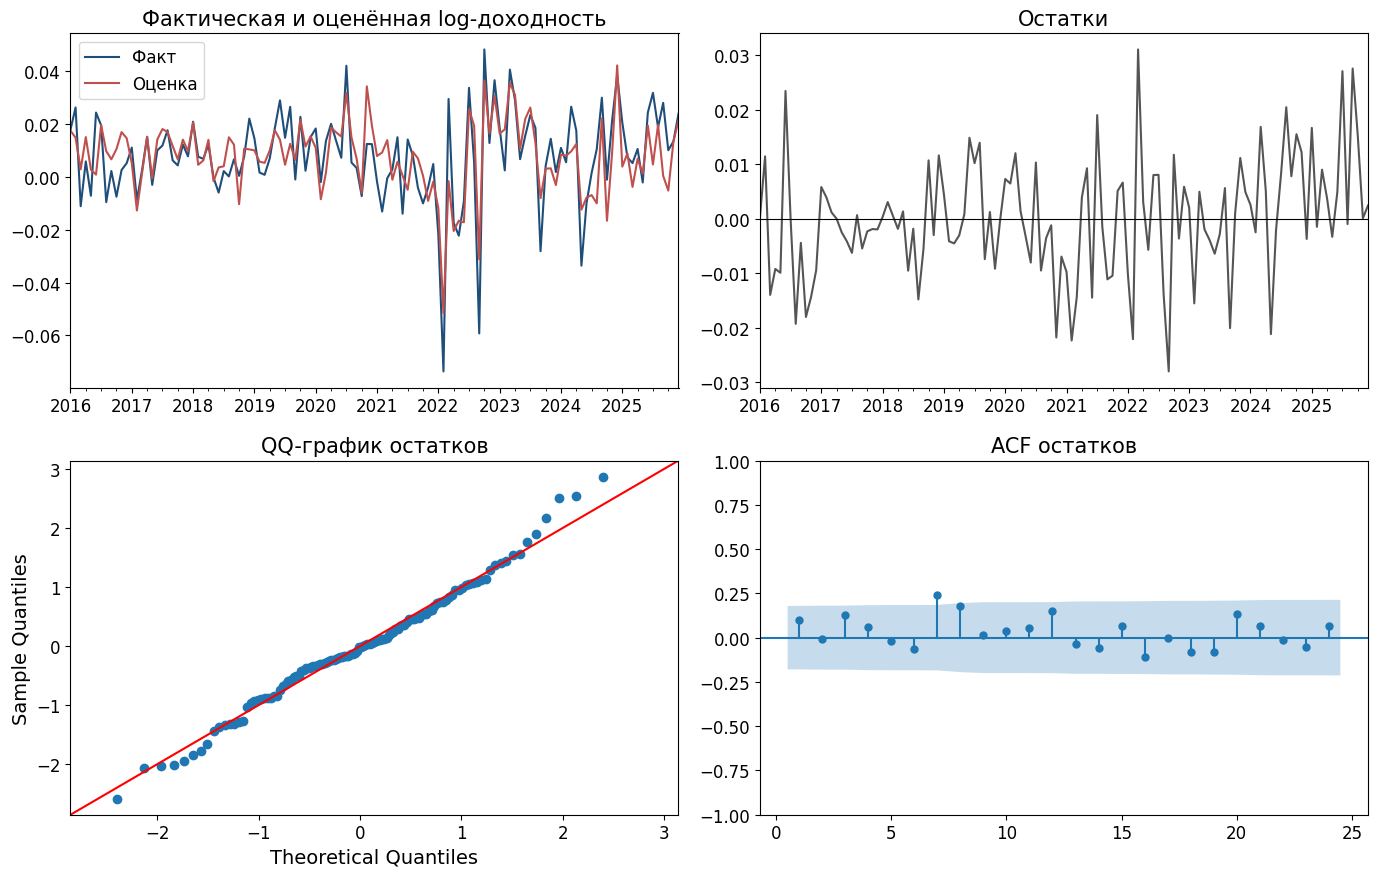

In [129]:
primary_coefficients = coefficient_table(primary_model)
primary_standardized_coefficients = standardized_coefficient_table(
    primary_model,
    Y,
    X_all[primary_variables],
)
primary_diagnostics = residual_diagnostic_table(primary_model)

print(f"Основная заранее заданная модель {PRIMARY_MODEL_KEY}:")
display(primary_coefficients.round(5))
print("Сопоставимые эффекты изменения каждого фактора на одно стандартное отклонение:")
display(primary_standardized_coefficients.round(5))
print(
    f"N={int(primary_model.nobs)}, R2={primary_model.rsquared:.4f}, "
    f"Adjusted R2={primary_model.rsquared_adj:.4f}, "
    f"AIC={primary_model.aic:.2f}, BIC={primary_model.bic:.2f}."
)
display(primary_diagnostics.round(4))

primary_diagnostic_figure, _ = plot_primary_diagnostics(primary_model)
save_regression_figure(primary_diagnostic_figure, "regression_primary_diagnostics")
_render_figure(primary_diagnostic_figure, show=True)

In [130]:
def hac_lag_sensitivity(
    target: pd.Series,
    features: pd.DataFrame,
    lags: Sequence[int] = (1, 3, 4, 6, 12),
) -> pd.DataFrame:
    """Сравнивает HAC-вывод при нескольких ширинах окна Ньюи-Уэста."""
    tables = []
    for lag in lags:
        table = coefficient_table(fit_ols_hac(target, features, maxlags=lag))
        table.insert(0, "HAC lags", lag)
        tables.append(table)
    return pd.concat(tables, ignore_index=True)


hac_sensitivity_table = hac_lag_sensitivity(Y, X_all[primary_variables])
display(
    hac_sensitivity_table[
        ["HAC lags", "Variable", "Coefficient", "HAC SE", "p-value", "CI lower", "CI upper"]
    ].round(5)
)

,HAC lags,Variable,Coefficient,HAC SE,p-value,CI lower,CI upper
0,1,const,0.00990,0.00146,0.00000,0.00703,0.01277
1,1,MOEXBMI,0.19663,0.02860,0.00000,0.14058,0.25268
2,1,EUR_RUB,0.09772,0.02391,0.00004,0.05086,0.14458
3,1,yield_spread,0.00363,0.00162,0.02465,0.00046,0.00680
4,1,org_turnover,-0.02906,0.00856,0.00068,-0.04583,-0.01229
5,3,const,0.00990,0.00156,0.00000,0.00684,0.01297
6,3,MOEXBMI,0.19663,0.02995,0.00000,0.13793,0.25532
7,3,EUR_RUB,0.09772,0.02563,0.00014,0.04748,0.14796
8,3,yield_spread,0.00363,0.00175,0.03755,0.00021,0.00706
9,3,org_turnover,-0.02906,0.00730,0.00007,-0.04337,-0.01475


In [131]:
primary_plain_model = sm.OLS(
    Y,
    sm.add_constant(X_all[primary_variables], has_constant="add"),
).fit()
influence_frame = OLSInfluence(primary_plain_model).summary_frame()
influence_frame.index = Y.index
cooks_threshold = 4.0 / len(Y)
influential_months = (
    influence_frame.loc[influence_frame["cooks_d"] > cooks_threshold]
    .sort_values("cooks_d", ascending=False)
)

print(f"Порог Cook's D = 4/N = {cooks_threshold:.4f}")
display(influential_months[["cooks_d", "standard_resid", "hat_diag"]].head(15).round(4))

post_break = (Y.index >= REGRESSION_BREAK_DATE).astype(int)
X_break = X_all[primary_variables].copy()
X_break["post_2022"] = post_break
interaction_names = []
for variable in primary_variables:
    interaction = f"{variable}_x_post_2022"
    X_break[interaction] = X_break[variable] * post_break
    interaction_names.append(interaction)

break_model = fit_ols_hac(Y, X_break)
break_test = break_model.wald_test(
    ", ".join(["post_2022 = 0", *(f"{name} = 0" for name in interaction_names)]),
    scalar=True,
)
hansen_statistic, hansen_critical_values = breaks_hansen(primary_plain_model)

structural_stability_table = pd.DataFrame(
    [
        {
            "Test": "Joint post-February-2022 intercept/slopes HAC-Wald",
            "Statistic": float(break_test.statistic),
            "p-value": float(break_test.pvalue),
        },
        {
            "Test": "Hansen parameter instability",
            "Statistic": float(hansen_statistic),
            "p-value": np.nan,
        },
    ]
)
print("Критические значения Hansen (таблица statsmodels):")
print(hansen_critical_values)
display(structural_stability_table.round(4))

crisis_months = pd.DatetimeIndex(["2022-02-28", "2022-03-31"])
cook_months = pd.DatetimeIndex(influential_months.index)
sensitivity_samples = {
    "Full sample": Y.index,
    "Without Feb-Mar 2022": Y.index.difference(crisis_months),
    "Without Cook D > 4/N": Y.index.difference(cook_months),
}
influence_sensitivity_models = {
    name: fit_ols_hac(Y.loc[index], X_all.loc[index, primary_variables])
    for name, index in sensitivity_samples.items()
}
influence_sensitivity_table = pd.concat(
    [
        coefficient_table(model).assign(Sample=name, N=int(model.nobs))
        for name, model in influence_sensitivity_models.items()
    ],
    ignore_index=True,
)
print("Чувствительность коэффициентов к влиятельным месяцам:")
display(influence_sensitivity_table.round(5))

regime_samples = {
    "Before February 2022": Y.index[Y.index < REGRESSION_BREAK_DATE],
    "From February 2022": Y.index[Y.index >= REGRESSION_BREAK_DATE],
}
regime_models = {
    name: fit_ols_hac(Y.loc[index], X_all.loc[index, primary_variables])
    for name, index in regime_samples.items()
}
regime_coefficient_table = pd.concat(
    [
        coefficient_table(model).assign(Regime=name, N=int(model.nobs))
        for name, model in regime_models.items()
    ],
    ignore_index=True,
)
print("Описательные оценки основной модели по режимам:")
display(regime_coefficient_table.round(5))

X_nonlinear = X_all[primary_variables].copy()
nonlinear_terms = []
for variable in ["MOEXBMI", "EUR_RUB"]:
    term = f"{variable}_squared"
    X_nonlinear[term] = (X_nonlinear[variable] - X_nonlinear[variable].mean()) ** 2
    nonlinear_terms.append(term)
nonlinear_model = fit_ols_hac(Y, X_nonlinear)
nonlinear_test = nonlinear_model.wald_test(
    ", ".join(f"{term} = 0" for term in nonlinear_terms),
    scalar=True,
)
nonlinear_robustness_table = pd.DataFrame(
    [
        {
            "Test": "Joint centered squares of MOEXBMI and EUR_RUB",
            "Statistic": float(nonlinear_test.statistic),
            "p-value": float(nonlinear_test.pvalue),
            "Adjusted R2": float(nonlinear_model.rsquared_adj),
            "AIC": float(nonlinear_model.aic),
            "BIC": float(nonlinear_model.bic),
        }
    ]
)
nonlinear_coefficients = coefficient_table(nonlinear_model)
print("Предварительно заданная нелинейная robustness-проверка:")
display(nonlinear_robustness_table.round(4))
display(nonlinear_coefficients.round(5))

Порог Cook's D = 4/N = 0.0333


,cooks_d,standard_resid,hat_diag
2022-02-28,0.6940,-2.4918,0.3585
2022-03-31,0.2910,3.0238,0.1373
2022-09-30,0.2408,-2.7272,0.1393
2025-01-31,0.0631,1.5983,0.1099
2024-08-31,0.0520,1.9149,0.0662
2025-09-30,0.0471,2.5374,0.0353
2025-07-31,0.0467,2.4937,0.0362
2020-11-30,0.0455,-2.0218,0.0527
2023-09-30,0.0443,-1.8692,0.0596
2024-10-31,0.0359,1.4607,0.0776


Критические значения Hansen (таблица statsmodels):
[( 2, 1.01) ( 6, 1.9 ) (15, 3.75) (19, 4.52)]


,Test,Statistic,p-value
0,Joint post-February-2022 intercept/slopes HAC-...,27.4515,0.0
1,Hansen parameter instability,1.7891,NaN


Чувствительность коэффициентов к влиятельным месяцам:


...

Описательные оценки основной модели по режимам:


,Variable,Coefficient,HAC SE,t,p-value,CI lower,CI upper,Regime,N
0,const,0.00946,0.00148,6.40508,0.00000,0.00656,0.01235,Before February 2022,73
1,MOEXBMI,0.14948,0.02062,7.24786,0.00000,0.10906,0.18990,Before February 2022,73
2,EUR_RUB,0.16025,0.02521,6.35720,0.00000,0.11085,0.20966,Before February 2022,73
3,yield_spread,-0.00597,0.00436,-1.36979,0.17075,-0.01450,0.00257,Before February 2022,73
4,org_turnover,-0.03792,0.00805,-4.71182,0.00000,-0.05370,-0.02215,Before February 2022,73
5,const,0.01225,0.00301,4.06648,0.00005,0.00635,0.01816,From February 2022,47
6,MOEXBMI,0.22992,0.03426,6.71145,0.00000,0.16278,0.29707,From February 2022,47
7,EUR_RUB,0.08531,0.02435,3.50429,0.00046,0.03760,0.13303,From February 2022,47
8,yield_spread,0.00481,0.00236,2.04089,0.04126,0.00019,0.00943,From February 2022,47
9,org_turnover,-0.02147,0.01911,-1.12309,0.26140,-0.05893,0.01600,From February 2022,47


Предварительно заданная нелинейная robustness-проверка:


,Test,Statistic,p-value,Adjusted R2,AIC,BIC
0,Joint centered squares of MOEXBMI and EUR_RUB,21.9331,0.0,0.6359,-747.0772,-727.5648


,Variable,Coefficient,HAC SE,t,p-value,CI lower,CI upper
0,const,0.00999,0.00179,5.59010,0.00000,0.00649,0.01349
1,MOEXBMI,0.16802,0.02565,6.54943,0.00000,0.11774,0.21831
2,EUR_RUB,0.11063,0.01849,5.98488,0.00000,0.07440,0.14687
3,yield_spread,0.00282,0.00171,1.64936,0.09907,-0.00053,0.00618
4,org_turnover,-0.02678,0.00738,-3.63002,0.00028,-0.04124,-0.01232
5,MOEXBMI_squared,-0.38785,0.08296,-4.67508,0.00000,-0.55045,-0.22525
6,EUR_RUB_squared,0.40425,0.18080,2.23586,0.02536,0.04988,0.75861


In [132]:
print("Интерпретация основной модели (ассоциации, не причинные эффекты):")
for _, row in primary_coefficients.iterrows():
    variable = str(row["Variable"])
    coefficient = float(row["Coefficient"])
    p_value = float(row["p-value"])
    if variable == "const":
        meaning = "условная константа при нулевых преобразованных факторах"
    elif variable == "MOEXBMI":
        meaning = "связь с месячной log-доходностью широкого рынка акций"
    elif variable == "EUR_RUB":
        meaning = "связь с месячным log-изменением курса EUR/RUB"
    elif variable == "yield_spread":
        meaning = "связь с месячным изменением спреда доходностей 10Y–1Y"
    elif variable == "org_turnover":
        meaning = "связь с годовым log-темпом оборота организаций"
    elif variable == "import_value":
        meaning = "связь с месячным log-темпом импорта"
    else:
        meaning = "условная статистическая связь"
    print(f"  {variable}: beta={coefficient:.5f}, p={p_value:.4f}; {meaning}.")

print("\nАссоциация при изменении фактора на одно стандартное отклонение:")
for _, row in primary_standardized_coefficients.query("Variable != 'const'").iterrows():
    print(
        f"  {row['Variable']}: {row['Effect of +1 SD, percentage points']:.3f} "
        f"п.п. месячной log-доходности; standardized beta="
        f"{row['Standardized coefficient']:.3f}."
    )

print(
    "Коэффициенты относятся к исторической условной ассоциации. Формулировки "
    "«повышает», «снижает» и другие причинные глаголы по этой модели не обоснованы."
)

Интерпретация основной модели (ассоциации, не причинные эффекты):
  const: beta=0.00990, p=0.0000; условная константа при нулевых преобразованных факторах.
  MOEXBMI: beta=0.19663, p=0.0000; связь с месячной log-доходностью широкого рынка акций.
  EUR_RUB: beta=0.09772, p=0.0002; связь с месячным log-изменением курса EUR/RUB.
  yield_spread: beta=0.00363, p=0.0390; связь с месячным изменением спреда доходностей 10Y–1Y.
  org_turnover: beta=-0.02906, p=0.0001; связь с годовым log-темпом оборота организаций.

Ассоциация при изменении фактора на одно стандартное отклонение:
  MOEXBMI: 1.221 п.п. месячной log-доходности; standardized beta=0.704.
  EUR_RUB: 0.550 п.п. месячной log-доходности; standardized beta=0.318.
  yield_spread: 0.250 п.п. месячной log-доходности; standardized beta=0.144.
  org_turnover: -0.314 п.п. месячной log-доходности; standardized beta=-0.181.
Коэффициенты относятся к исторической условной ассоциации. Формулировки «повышает», «снижает» и другие причинные глаголы п

### 4.7. Псевдовневыборочная expanding-window проверка

Для прогноза доходности месяца *t* рыночные факторы сдвигаются на один месяц, а официальные месячные показатели оборота и импорта — на два месяца как консервативное приближение задержки публикации. Коэффициенты переоцениваются только на предшествующих наблюдениях; benchmark — expanding-среднее.

Для вложенных моделей дополнительно приводится односторонний тест Clark–West с HAC-ошибкой: положительная скорректированная разность потерь означает преимущество более широкой модели. При коротком OOS-периоде тест имеет ограниченную мощность и не заменяет экономическую оценку RMSE и OOS R².

Важное ограничение: прогнозируется доходность портфеля, чьи начальные медианные веса были получены портфельным блоком на полной исторической выборке. Поэтому это проверка предсказуемости **условно заданного исследуемого портфеля**, а не полностью реализуемый real-time инвестиционный backtest.

In [133]:
def expanding_window_forecasts(
    target: pd.Series,
    features: pd.DataFrame,
    *,
    min_train: int = MIN_EXPANDING_TRAIN,
) -> pd.DataFrame:
    """Строит одношаговые OLS-прогнозы без использования будущих наблюдений."""
    data = pd.concat(
        [target.rename("actual"), features], axis="columns", sort=False
    ).dropna()
    if len(data) <= min_train:
        raise ValueError("Not enough observations for expanding-window validation")
    feature_names = list(features.columns)
    records = []
    for position in range(min_train, len(data)):
        train = data.iloc[:position]
        test = data.iloc[[position]]
        model = sm.OLS(
            train["actual"],
            sm.add_constant(train[feature_names], has_constant="add"),
        ).fit()
        test_design = pd.DataFrame(
            [[1.0, *test[feature_names].iloc[0].to_list()]],
            index=test.index,
            columns=["const", *feature_names],
        )
        prediction = float(model.predict(test_design).iloc[0])
        records.append(
            {
                "date": test.index[0],
                "actual": float(test["actual"].iloc[0]),
                "forecast": prediction,
                "historical_mean": float(train["actual"].mean()),
                "train_n": len(train),
            }
        )
    return pd.DataFrame(records).set_index("date")


def forecast_metrics(forecasts: pd.DataFrame) -> dict[str, float | int]:
    """Возвращает MAE, RMSE и OOS R² относительно historical mean."""
    actual = forecasts["actual"]
    predicted = forecasts["forecast"]
    benchmark = forecasts["historical_mean"]
    model_sse = float(np.square(actual - predicted).sum())
    benchmark_sse = float(np.square(actual - benchmark).sum())
    return {
        "N forecasts": int(len(forecasts)),
        "MAE": float(mean_absolute_error(actual, predicted)),
        "RMSE": float(np.sqrt(mean_squared_error(actual, predicted))),
        "OOS R2 vs expanding mean": float(1.0 - model_sse / benchmark_sse),
        "Directional accuracy": float((np.sign(actual) == np.sign(predicted)).mean()),
    }


def clark_west_test(
    actual: pd.Series,
    reference_forecast: pd.Series,
    candidate_forecast: pd.Series,
    *,
    reference_name: str,
    candidate_name: str,
    maxlags: int = REGRESSION_HAC_LAGS,
) -> dict[str, float | int | str]:
    """Односторонний Clark–West тест для вложенных одношаговых прогнозов."""
    aligned = pd.concat(
        [
            actual.rename("actual"),
            reference_forecast.rename("reference"),
            candidate_forecast.rename("candidate"),
        ],
        axis="columns",
        join="inner",
    ).dropna()
    if len(aligned) <= maxlags + 2:
        raise ValueError("Insufficient forecasts for Clark-West test")

    error_reference = aligned["actual"] - aligned["reference"]
    error_candidate = aligned["actual"] - aligned["candidate"]
    adjusted_loss_difference = (
        error_reference.pow(2)
        - error_candidate.pow(2)
        + (aligned["reference"] - aligned["candidate"]).pow(2)
    ).rename("adjusted_loss_difference")
    design = pd.DataFrame(
        {"const": np.ones(len(adjusted_loss_difference))},
        index=adjusted_loss_difference.index,
    )
    mean_model = sm.OLS(adjusted_loss_difference, design).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": int(maxlags), "use_correction": True},
    )
    estimate = float(mean_model.params["const"])
    standard_error = float(mean_model.bse["const"])
    statistic = estimate / standard_error if standard_error > 0 else np.nan
    return {
        "Reference": reference_name,
        "Candidate": candidate_name,
        "N": int(len(aligned)),
        "Mean adjusted loss difference": estimate,
        "HAC SE": standard_error,
        "CW statistic": float(statistic),
        "One-sided p-value": float(stats.norm.sf(statistic)),
    }

In [134]:
def test_block_4_7_expanding_window_starts_after_training_sample() -> None:
    rng = np.random.default_rng(11)
    index = pd.date_range("2010-01-31", periods=90, freq="ME")
    x = pd.DataFrame({"x": rng.normal(size=90)}, index=index)
    y = pd.Series(0.4 * x["x"] + rng.normal(scale=0.2, size=90), index=index)
    forecasts = expanding_window_forecasts(y, x, min_train=60)
    assert len(forecasts) == 30
    assert forecasts.index[0] == index[60]
    assert forecasts["train_n"].iloc[0] == 60
    metrics = forecast_metrics(forecasts)
    assert set(["MAE", "RMSE", "OOS R2 vs expanding mean"]).issubset(metrics)

    cw = clark_west_test(
        forecasts["actual"],
        forecasts["historical_mean"],
        forecasts["forecast"],
        reference_name="Mean",
        candidate_name="Model",
        maxlags=2,
    )
    assert cw["N"] == len(forecasts)
    assert np.isfinite(cw["Mean adjusted loss difference"])
    assert 0.0 <= cw["One-sided p-value"] <= 1.0

In [135]:
run_notebook_tests("test_block_4_7")

.                                                                                            [100%]


0

In [136]:
PREDICTIVE_LAGS = {
    "MOEXBMI": 1,
    "EUR_RUB": 1,
    "yield_spread": 1,
    "org_turnover": 2,
    "import_value": 2,
}
X_predictive = pd.DataFrame(
    {
        variable: X_all[variable].shift(lag)
        for variable, lag in PREDICTIVE_LAGS.items()
    }
)
predictive_sample = pd.concat(
    [Y, X_predictive], axis="columns", sort=False
).dropna()
Y_predictive = predictive_sample.pop("Portfolio")

predictive_forecasts = {
    "Market lag 1": expanding_window_forecasts(
        Y_predictive,
        predictive_sample[["MOEXBMI"]],
    ),
    "Primary M4 with availability lags": expanding_window_forecasts(
        Y_predictive,
        predictive_sample[primary_variables],
    ),
    "Extended M5 with availability lags": expanding_window_forecasts(
        Y_predictive,
        predictive_sample[THEORY_SPECS["M5 + Trade"]],
    ),
}
forecast_comparison = pd.DataFrame(
    {
        name: forecast_metrics(forecasts)
        for name, forecasts in predictive_forecasts.items()
    }
).T
display(forecast_comparison.round(5))

market_forecasts = predictive_forecasts["Market lag 1"]
primary_forecasts = predictive_forecasts["Primary M4 with availability lags"]
extended_forecasts = predictive_forecasts["Extended M5 with availability lags"]
forecast_loss_tests = pd.DataFrame(
    [
        clark_west_test(
            forecasts["actual"],
            forecasts["historical_mean"],
            forecasts["forecast"],
            reference_name="Expanding mean",
            candidate_name=name,
        )
        for name, forecasts in predictive_forecasts.items()
    ]
    + [
        clark_west_test(
            primary_forecasts["actual"],
            market_forecasts["forecast"],
            primary_forecasts["forecast"],
            reference_name="Market lag 1",
            candidate_name="Primary M4 with availability lags",
        ),
        clark_west_test(
            extended_forecasts["actual"],
            primary_forecasts["forecast"],
            extended_forecasts["forecast"],
            reference_name="Primary M4 with availability lags",
            candidate_name="Extended M5 with availability lags",
        ),
    ]
)
print("Clark–West: H1 — candidate имеет меньшую ожидаемую квадратичную ошибку:")
display(forecast_loss_tests.round(5))

forecast_design_audit = pd.DataFrame(
    [
        ("Target", "Месячная log-доходность того же buy-and-hold портфеля Spec3"),
        ("Portfolio weights", "Медианные начальные веса оценены портфельным блоком на полной истории"),
        ("Information lags", "Рынок/FX/спред: 1 месяц; оборот/импорт: 2 месяца"),
        ("Estimation", "Expanding window, минимум 60 месяцев, без переоценки на будущем"),
        ("Benchmark", "Expanding historical mean на той же OOS-выборке"),
        ("Interpretation", "Проверка предсказуемости условно заданного портфеля, не real-time backtest"),
    ],
    columns=["Element", "Implementation"],
)
display(forecast_design_audit)

print(
    "OOS R² <= 0 означает, что модель не улучшает прогноз относительно "
    "expanding-среднего на том же отрезке. Даже при OOS R² > 0 вывод должен "
    "учитывать p-value Clark–West и ограничение полной-истории для весов портфеля."
)

,N forecasts,MAE,RMSE,OOS R2 vs expanding mean,Directional accuracy
Market lag 1,58.0,0.01633,0.02241,-0.01309,0.68966
Primary M4 with availability lags,58.0,0.01545,0.02125,0.08910,0.60345
Extended M5 with availability lags,58.0,0.01557,0.02137,0.07855,0.60345


Clark–West: H1 — candidate имеет меньшую ожидаемую квадратичную ошибку:


,Reference,Candidate,N,Mean adjusted loss difference,HAC SE,CW statistic,One-sided p-value
0,Expanding mean,Market lag 1,58,0.00000,0.00002,0.09507,0.46213
1,Expanding mean,Primary M4 with availability lags,58,0.00010,0.00003,3.12997,0.00087
2,Expanding mean,Extended M5 with availability lags,58,0.00009,0.00003,2.97028,0.00149
3,Market lag 1,Primary M4 with availability lags,58,0.00009,0.00003,2.67447,0.00374
4,Primary M4 with availability lags,Extended M5 with availability lags,58,-0.00000,0.00001,-0.84984,0.80229


,Element,Implementation
0,Target,Месячная log-доходность того же buy-and-hold п...
1,Portfolio weights,Медианные начальные веса оценены портфельным б...
2,Information lags,Рынок/FX/спред: 1 месяц; оборот/импорт: 2 месяца
3,Estimation,"Expanding window, минимум 60 месяцев, без пере..."
4,Benchmark,Expanding historical mean на той же OOS-выборке
5,Interpretation,Проверка предсказуемости условно заданного пор...


OOS R² <= 0 означает, что модель не улучшает прогноз относительно expanding-среднего на том же отрезке. Даже при OOS R² > 0 вывод должен учитывать p-value Clark–West и ограничение полной-истории для весов портфеля.


### 4.8. Скользящая регрессия как описательная проверка стабильности

Rolling-оценки используют перекрывающиеся 60-месячные окна. Поэтому они иллюстрируют изменение условных коэффициентов во времени, но не являются независимой вневыборочной валидацией.

На графике сплошная синяя линия показывает коэффициент в каждом rolling-окне, красная пунктирная линия — оценку на полной выборке, а тонкая чёрная линия — нулевой уровень. Заполненный зелёный маркер означает, что коэффициент в соответствующем окне статистически значим по HAC p-value на уровне 5% ($p < 0{,}05$); пустой серый маркер означает отсутствие значимости на этом уровне ($p \geq 0{,}05$). Если p-value не может быть рассчитано, маркер для такого окна не отображается.

In [137]:
def rolling_hac_estimates(
    target: pd.Series,
    features: pd.DataFrame,
    *,
    window: int = 60,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    """Оценивает HAC-модель на последовательности перекрывающихся окон."""
    data = pd.concat(
        [target.rename("target"), features], axis="columns", sort=False
    ).dropna()
    if len(data) < window:
        raise ValueError(f"Need at least {window} observations")
    coefficients, pvalues, adjusted_r2 = [], [], []
    for end in range(window, len(data) + 1):
        sample = data.iloc[end - window : end]
        model = fit_ols_hac(sample.pop("target"), sample)
        date = data.index[end - 1]
        coefficients.append({"date": date, **model.params.to_dict()})
        pvalues.append({"date": date, **model.pvalues.to_dict()})
        adjusted_r2.append({"date": date, "Adjusted R2": model.rsquared_adj})
    return (
        pd.DataFrame(coefficients).set_index("date"),
        pd.DataFrame(pvalues).set_index("date"),
        pd.DataFrame(adjusted_r2).set_index("date")["Adjusted R2"],
    )


def plot_rolling_coefficients(
    coefficients: pd.DataFrame,
    pvalues: pd.DataFrame,
    adjusted_r2: pd.Series,
    full_sample_coefficients: pd.Series,
    *,
    window: int = 60,
    alpha: float = REGRESSION_ALPHA,
) -> tuple[Figure, np.ndarray]:
    """Строит rolling-коэффициенты и явно показывает значимость каждого окна."""
    variables = [column for column in coefficients if column != "const"]
    if not variables:
        raise ValueError("No rolling coefficients to plot")
    if not coefficients.index.equals(pvalues.index):
        raise ValueError("Coefficient and p-value indices must match")

    missing_pvalues = sorted(set(variables).difference(pvalues.columns))
    missing_full_sample = sorted(set(variables).difference(full_sample_coefficients.index))
    if missing_pvalues:
        raise KeyError(f"Missing rolling p-values for: {missing_pvalues}")
    if missing_full_sample:
        raise KeyError(f"Missing full-sample coefficients for: {missing_full_sample}")

    fig, axes = plt.subplots(
        len(variables) + 1,
        1,
        figsize=(14, 2.6 * (len(variables) + 1)),
        sharex=True,
    )
    for axis, variable in zip(axes, variables):
        estimates = coefficients[variable]
        variable_pvalues = pvalues[variable]
        significant = variable_pvalues.lt(alpha)
        not_significant = variable_pvalues.ge(alpha)

        axis.plot(coefficients.index, estimates, color="#1f4e79", linewidth=1.2)
        axis.scatter(
            coefficients.index[significant],
            estimates.loc[significant],
            facecolor="#2e8b57",
            edgecolor="#2e8b57",
            s=18,
            zorder=3,
        )
        axis.scatter(
            coefficients.index[not_significant],
            estimates.loc[not_significant],
            facecolor="white",
            edgecolor="#666666",
            linewidth=0.8,
            s=18,
            zorder=3,
        )
        axis.axhline(
            full_sample_coefficients[variable],
            color="#c0504d",
            linestyle="--",
            linewidth=1.2,
        )
        axis.axhline(0.0, color="black", linewidth=0.6)
        axis.set_ylabel(variable)

    axes[-1].plot(adjusted_r2.index, adjusted_r2, color="#7030a0", linewidth=1.2)
    axes[-1].set_ylabel("Adj. R²")
    axes[-1].set_xlabel(f"Конец {window}-месячного окна")

    alpha_label = f"{alpha:.2f}".replace(".", ",")
    legend_handles = [
        Line2D(
            [0],
            [0],
            color="#1f4e79",
            linewidth=1.4,
            label=f"Rolling-коэффициент ({window} мес.)",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            markerfacecolor="#2e8b57",
            markeredgecolor="#2e8b57",
            markersize=5,
            label=f"HAC p-value < {alpha_label}",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            markerfacecolor="white",
            markeredgecolor="#666666",
            markersize=5,
            label=f"HAC p-value ≥ {alpha_label}",
        ),
        Line2D(
            [0],
            [0],
            color="#c0504d",
            linestyle="--",
            linewidth=1.2,
            label="Коэффициент на полной выборке",
        ),
        Line2D(
            [0],
            [0],
            color="black",
            linewidth=0.7,
            label="Нулевой уровень",
        ),
        Line2D(
            [0],
            [0],
            color="#7030a0",
            linewidth=1.2,
            label="Скорректированный R²",
        ),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.995),
        ncol=3,
        frameon=False,
    )
    fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.92))
    return fig, axes

,Variable,Full-sample coefficient,Rolling median,Sign stability,Share p < 0.05
0,MOEXBMI,0.1966,0.2214,1.0000,1.0000
1,EUR_RUB,0.0977,0.1038,1.0000,0.9672
2,yield_spread,0.0036,0.0031,0.7213,0.4754
3,org_turnover,-0.0291,-0.0238,1.0000,0.9344


Сохранено: figures\regression_primary_rolling_60m.pdf


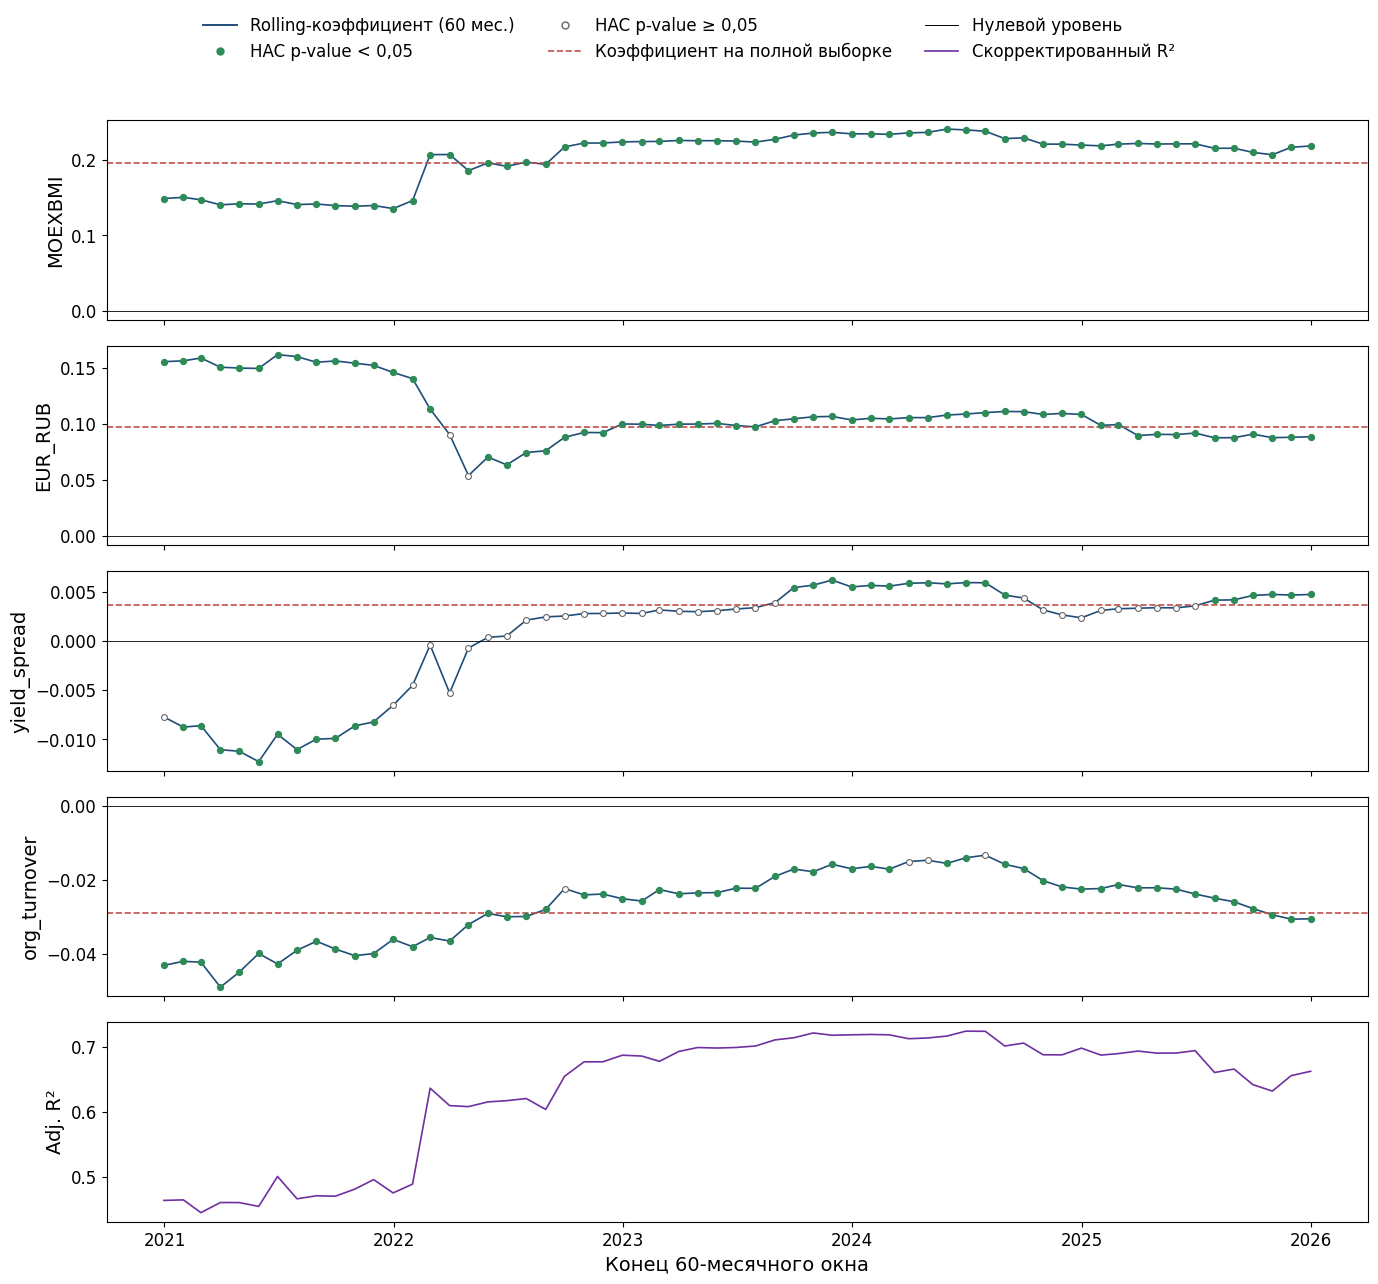

In [138]:
ROLLING_WINDOW = 60

rolling_coefficients, rolling_pvalues, rolling_adjusted_r2 = rolling_hac_estimates(
    Y,
    X_all[primary_variables],
    window=ROLLING_WINDOW,
)
rolling_stability_table = pd.DataFrame(
    {
        "Variable": primary_variables,
        "Full-sample coefficient": [primary_model.params[name] for name in primary_variables],
        "Rolling median": [rolling_coefficients[name].median() for name in primary_variables],
        "Sign stability": [
            (np.sign(rolling_coefficients[name]) == np.sign(primary_model.params[name])).mean()
            for name in primary_variables
        ],
        "Share p < 0.05": [
            (rolling_pvalues[name] < REGRESSION_ALPHA).mean()
            for name in primary_variables
        ],
    }
)
display(rolling_stability_table.round(4))

rolling_figure, _ = plot_rolling_coefficients(
    rolling_coefficients,
    rolling_pvalues,
    rolling_adjusted_r2,
    primary_model.params,
    window=ROLLING_WINDOW,
)
save_regression_figure(
    rolling_figure,
    f"regression_primary_rolling_{ROLLING_WINDOW}m",
)
_render_figure(rolling_figure, show=True)

### 4.9. Автоматический экспорт регрессионных результатов

Все таблицы, необходимые для переноса результатов в рукопись и последующей числовой сверки, записываются в CSV с UTF-8 BOM. В экспорт включены паспорт преобразований, аудит выборок, стационарность, описательная статистика, VIF основной модели, стандартизированные эффекты, диагностика, проверки устойчивости и псевдовневыборочные результаты.

In [139]:
REGRESSION_TABLE_DIR = Path("tables") / "regression"
REGRESSION_TABLE_DIR.mkdir(parents=True, exist_ok=True)

regression_tables: dict[str, pd.DataFrame] = {
    "transformation_report": transformation_report,
    "sample_audit": sample_audit,
    "sample_missing_months": sample_missing_months,
    "stationarity": stationarity_table.reset_index(),
    "primary_descriptive_statistics": primary_descriptive,
    "primary_vif": vif_primary,
    "vif_before_exploratory_filter": vif_before,
    "vif_removal_history": vif_removal_history,
    "theory_model_comparison": theory_comparison,
    "primary_coefficients_hac": primary_coefficients,
    "primary_standardized_coefficients": primary_standardized_coefficients,
    "primary_diagnostics": primary_diagnostics,
    "hac_lag_sensitivity": hac_sensitivity_table,
    "influential_months": influential_months.reset_index(names="date"),
    "structural_stability": structural_stability_table,
    "influence_sensitivity": influence_sensitivity_table,
    "regime_coefficients": regime_coefficient_table,
    "nonlinear_robustness": nonlinear_robustness_table,
    "nonlinear_coefficients": nonlinear_coefficients,
    "exploratory_bic_top10": bic_evidence,
    "robustness_model_comparison": robustness_model_comparison,
    "forecast_comparison": forecast_comparison.reset_index(names="Model"),
    "forecast_loss_tests_clark_west": forecast_loss_tests,
    "forecast_design_audit": forecast_design_audit,
    "rolling_stability": rolling_stability_table,
    "portfolio_monthly_coverage": portfolio_monthly_coverage,
    "effective_weights_month_end": portfolio_effective_weights_monthly.reset_index(),
}

exported_regression_tables: dict[str, Path] = {}
for name, table in regression_tables.items():
    path = REGRESSION_TABLE_DIR / f"{name}.csv"
    table.to_csv(path, index=False, encoding="utf-8-sig")
    exported_regression_tables[name] = path

print(f"Экспортировано таблиц: {len(exported_regression_tables)}")
for name, path in exported_regression_tables.items():
    print(f"  {name}: {path}")

Экспортировано таблиц: 27
  transformation_report: tables\regression\transformation_report.csv
  sample_audit: tables\regression\sample_audit.csv
  sample_missing_months: tables\regression\sample_missing_months.csv
  stationarity: tables\regression\stationarity.csv
  primary_descriptive_statistics: tables\regression\primary_descriptive_statistics.csv
  primary_vif: tables\regression\primary_vif.csv
  vif_before_exploratory_filter: tables\regression\vif_before_exploratory_filter.csv
  vif_removal_history: tables\regression\vif_removal_history.csv
  theory_model_comparison: tables\regression\theory_model_comparison.csv
  primary_coefficients_hac: tables\regression\primary_coefficients_hac.csv
  primary_standardized_coefficients: tables\regression\primary_standardized_coefficients.csv
  primary_diagnostics: tables\regression\primary_diagnostics.csv
  hac_lag_sensitivity: tables\regression\hac_lag_sensitivity.csv
  influential_months: tables\regression\influential_months.csv
  structural_s

## 5. Ответы на замечания рецензента

### 5.1. Выбор безрисковой ставки: 10Y и проверка чувствительности

Замечание 1. Длинный конец кривой бескупонной доходности может быть модельно обусловлен и неустойчив. Поэтому базовой безрисковой ставкой остаётся 10Y: этот срок соответствует наблюдаемому участку кривой.

Сегмент 20Y возвращён в проверку чувствительности. В КБД он формируется моделью Свенссона на дальнем, экстраполируемом конце кривой, поэтому его уместно рассматривать как консервативный сценарий, а не как замену базовой ставке. Если ранжирование портфелей не меняется при переходе от 10Y к 20Y, вывод устойчив и к этому модельному допущению.

Текущая реализация берёт простое среднее ежедневных значений каждого сегмента за весь доступный период кривой ОФЗ. Альтернативные сегменты в этом разделе не меняют выбранную ставку в основном анализе.

In [140]:
RISK_FREE_SENSITIVITY_SEGMENTS: tuple[str, ...] = ("1Y", "3Y", "10Y", "20Y")


def build_risk_free_candidates(
    yield_curve_summary: pd.DataFrame,
    *,
    segments: Sequence[str] = RISK_FREE_SENSITIVITY_SEGMENTS,
    ruonia_data: pd.DataFrame | None = None,
    ruonia_rate_column: str = "ruo",
) -> dict[str, float]:
    """Строит сценарии ставки из КБД ОФЗ и, при наличии, RUONIA.

    Все значения возвращаются как годовые ставки в долях. Для RUONIA
    используется простое среднее дневных опубликованных значений в процентах.
    """
    candidates = {
        segment: select_risk_free_rate(yield_curve_summary, segment) / 100
        for segment in segments
    }
    if ruonia_data is not None:
        if ruonia_rate_column not in ruonia_data:
            raise KeyError(f"Missing RUONIA column: {ruonia_rate_column}")
        ruonia_values = pd.to_numeric(
            ruonia_data[ruonia_rate_column],
            errors="coerce",
        ).dropna()
        if ruonia_values.empty:
            raise ValueError("RUONIA series has no numeric observations")
        candidates["RUONIA"] = float(ruonia_values.mean() / 100)
    return candidates

def calculate_risk_free_sensitivity(
    specifications: Mapping[str, tuple[pd.DataFrame, np.ndarray]],
    risk_free_candidates: Mapping[str, float],
    *,
    mar: float,
    metric_function: Callable[
        [pd.DataFrame, np.ndarray, float, float], Mapping[str, float]
    ] = compute_all_metrics_for_weights,
) -> pd.DataFrame:
    """Считает риск-скорректированные метрики при альтернативных ставках.

    Args:
        specifications: Словарь спецификация -> дневные доходности и веса.
        risk_free_candidates: Метки и годовые ставки в долях.
        mar: Годовой minimum acceptable return.
        metric_function: Функция расчёта метрик портфеля.

    Returns:
        Таблица метрик каждой пары ставка-спецификация.
    """
    rows: list[dict[str, str | float]] = []
    for rate_label, rate_value in risk_free_candidates.items():
        for specification_name, (returns, weights) in specifications.items():
            metrics = metric_function(returns, weights, rate_value, mar)
            rows.append(
                {
                    "RF": rate_label,
                    "RF_value_%": rate_value * 100,
                    "Спецификация": specification_name,
                    "Sharpe": float(metrics["Sharpe"]),
                    "Sortino": float(metrics["Sortino"]),
                    "Calmar": float(metrics["Calmar"]),
                    "Martin": float(metrics["Martin Ratio"]),
                }
            )
    return pd.DataFrame(rows)

def create_sensitivity_pivot(
    sensitivity: pd.DataFrame,
    metric: str,
) -> pd.DataFrame:
    """Преобразует результаты чувствительности в таблицу сегмент на спецификацию.

    Args:
        sensitivity: Результат calculate_risk_free_sensitivity.
        metric: Имя метрики для значений таблицы.

    Returns:
        Pivot-таблица для сравнения сегментов кривой.
    """
    return sensitivity.pivot(index="RF", columns="Спецификация", values=metric)

def has_stable_ranking(metric_pivot: pd.DataFrame) -> bool:
    """Проверяет неизменность ранжирования спецификаций между ставками.

    Args:
        metric_pivot: Таблица сегмент на спецификацию.

    Returns:
        True, если ранг каждой спецификации одинаков во всех строках.
    """
    ranking = metric_pivot.rank(axis=1, ascending=False, method="min")
    return bool((ranking.nunique(axis=0) == 1).all())

In [141]:
def test_block_5_1_build_risk_free_candidates_converts_percent_to_fraction() -> None:
    summary = pd.DataFrame(
        {"Средняя доходность, %": [8.0, 9.0, 10.0, 11.0]},
        index=["1Y", "3Y", "10Y", "20Y"],
    )

    candidates = build_risk_free_candidates(summary)

    assert candidates == {"1Y": 0.08, "3Y": 0.09, "10Y": 0.10, "20Y": 0.11}

def test_block_5_1_sensitivity_keeps_expected_shape_and_ranking() -> None:
    specifications = {
        "A": (pd.DataFrame({"asset": [0.01]}), np.array([1.0])),
        "B": (pd.DataFrame({"asset": [0.02]}), np.array([1.0])),
    }

    def fake_metrics(
        returns: pd.DataFrame,
        weights: np.ndarray,
        risk_free_rate: float,
        mar: float,
    ) -> Mapping[str, float]:
        """Возвращает детерминированные метрики для проверки формы таблицы."""
        del weights, mar
        value = float(returns.iloc[0, 0] - risk_free_rate)
        return {
            "Sharpe": value,
            "Sortino": value,
            "Calmar": value,
            "Martin Ratio": value,
        }

    sensitivity = calculate_risk_free_sensitivity(
        specifications,
        {"1Y": 0.01, "10Y": 0.02, "20Y": 0.03},
        mar=0.03,
        metric_function=fake_metrics,
    )
    sharpe = create_sensitivity_pivot(sensitivity, "Sharpe")

    assert sensitivity.shape == (6, 7)
    assert has_stable_ranking(sharpe)


def test_block_5_1_adds_ruonia_candidate() -> None:
    summary = pd.DataFrame(
        {"Средняя доходность, %": [8.0, 9.0, 10.0, 11.0]},
        index=["1Y", "3Y", "10Y", "20Y"],
    )
    ruonia = pd.DataFrame({"ruo": [7.0, 9.0, np.nan]})

    candidates = build_risk_free_candidates(summary, ruonia_data=ruonia)

    assert candidates["RUONIA"] == pytest.approx(0.08)

In [142]:
run_notebook_tests("test_block_5_1")

...                                                                                          [100%]


0

In [143]:

risk_free_candidates = build_risk_free_candidates(
    yield_curve_summary,
    ruonia_data=df_RUONIA,
)
specifications_for_rf_sensitivity = {
    "Спец. 1": (portfolio_1_daily_returns, median_w1),
    "Спец. 2": (portfolio_2_daily_returns, median_w2),
    "Спец. 3": (portfolio_3_daily_returns, median_w3),
    "Спец. 4": (portfolio_4_daily_returns, median_w4),
}
risk_free_sensitivity = calculate_risk_free_sensitivity(
    specifications_for_rf_sensitivity,
    risk_free_candidates,
    mar=mar,
)

selected_rf_period = yield_curve_summary.loc[
    SELECTED_RISK_FREE_SEGMENT,
    ["Наблюдений", "Начало", "Конец", "Средняя доходность, %"],
]
ruonia_numeric = pd.to_numeric(df_RUONIA["ruo"], errors="coerce").dropna()
ruonia_dates = pd.to_datetime(df_RUONIA["DT"], errors="coerce").dropna()

print(
    f"Базовая ставка: ZCYC {SELECTED_RISK_FREE_SEGMENT} = "
    f"{risk_free_rate_ofz:.2f}%"
)
print(selected_rf_period.to_string())
print(
    f"RUONIA (сценарий): {ruonia_numeric.mean():.2f}%; "
    f"наблюдений = {len(ruonia_numeric)}, "
    f"период = {ruonia_dates.min():%Y-%m-%d} — {ruonia_dates.max():%Y-%m-%d}"
)
print(
    "20Y включён как сценарий чувствительности: дальний участок КБД "
    "получен модельной экстраполяцией Свенссона."
)

for metric_name in ("Sharpe", "Sortino", "Calmar", "Martin"):
    metric_pivot = create_sensitivity_pivot(risk_free_sensitivity, metric_name)
    print(f"\n{metric_name} при альтернативных безрисковых ставках:")
    print(metric_pivot.round(3).to_string())
    print(f"Ранжирование устойчиво: {has_stable_ranking(metric_pivot)}")

Базовая ставка: ZCYC 1Y = 9.57%
Наблюдений                              2766
Начало                   2015-01-05 00:00:00
Конец                    2025-12-30 00:00:00
Средняя доходность, %               9.565134
RUONIA (сценарий): 10.32%; наблюдений = 2701, период = 2015-01-12 — 2025-12-29
20Y включён как сценарий чувствительности: дальний участок КБД получен модельной экстраполяцией Свенссона.

Sharpe при альтернативных безрисковых ставках:
Спецификация  Спец. 1  Спец. 2  Спец. 3  Спец. 4
RF                                              
10Y             0.517    0.531    0.524    0.537
1Y              0.540    0.552    0.552    0.566
20Y             0.508    0.522    0.513    0.525
3Y              0.533    0.546    0.543    0.557
RUONIA          0.468    0.484    0.462    0.473
Ранжирование устойчиво: False

Sortino при альтернативных безрисковых ставках:
Спецификация  Спец. 1  Спец. 2  Спец. 3  Спец. 4
RF                                              
10Y             0.596    0.618    

### 5.2. MOEXALLW как benchmark, а не цель репликации

Исследование не решает задачу репликации MOEXALLW: целевая функция выбирает веса по набору риск-скорректированных метрик, а индекс используется как внешний ориентир. Tracking error и information ratio показываются как диагностические характеристики, а не как критерии оптимизации.

В текущем наборе данных MOEXALLW доступен только с 12.03.2025 по 31.12.2025. Поэтому ниже сравнение ограничено общим доступным периодом и не подтверждает поведение портфеля на всём горизонте 2015–2025. Для такого вывода необходимо добавить историю MOEXALLW за весь исследуемый период.

Замечание 2. Инвестор во «всепогодный» портфель может ориентироваться
на MOEXALLW, поэтому нужны корреляция и соответствие индексу.

Проверка добавлена для всех спецификаций. При этом MOEXALLW является внешним
benchmark: задача исследования — не репликация индекса, а выбор устойчивого
смешанного портфеля по набору риск-доходностных критериев. Если целью была бы
именно репликация, критерием оптимизации стал бы tracking error, а не Sharpe,
Sortino и другие использованные метрики.

In [144]:
def calculate_benchmark_statistics(
    portfolio_returns: pd.Series,
    benchmark_returns: pd.Series,
    *,
    periods_per_year: int = 252,
) -> dict[str, float | int | pd.Timestamp]:
    """Вычисляет связь портфеля с benchmark на общем временном интервале.

    Args:
        portfolio_returns: Дневные доходности портфеля.
        benchmark_returns: Дневные доходности benchmark.
        periods_per_year: Число торговых периодов в году.

    Returns:
        Корреляция, beta, tracking error, active return, information ratio
        и параметры общего периода.

    Raises:
        ValueError: Если после синхронизации недостаточно наблюдений или
            дисперсия benchmark равна нулю.
    """
    aligned = pd.concat(
        [portfolio_returns.rename("portfolio"), benchmark_returns.rename("benchmark")],
        axis=1,
        sort=False,
    ).dropna()
    if len(aligned) < 2:
        raise ValueError("At least two overlapping observations are required")

    active_returns = aligned["portfolio"] - aligned["benchmark"]
    benchmark_variance = float(aligned["benchmark"].var(ddof=1))
    if benchmark_variance == 0:
        raise ValueError("Benchmark variance must be non-zero")

    tracking_error = float(active_returns.std(ddof=1) * np.sqrt(periods_per_year))
    active_return = float(active_returns.mean() * periods_per_year)
    information_ratio = (
        float(active_returns.mean() / active_returns.std(ddof=1) * np.sqrt(periods_per_year))
        if tracking_error > 0
        else np.nan
    )
    covariance = float(np.cov(aligned["portfolio"], aligned["benchmark"], ddof=1)[0, 1])
    return {
        "Наблюдений": len(aligned),
        "Начало": aligned.index.min(),
        "Конец": aligned.index.max(),
        "Корреляция": float(aligned["portfolio"].corr(aligned["benchmark"])),
        "Beta": covariance / benchmark_variance,
        "Tracking Error, %": tracking_error * 100,
        "Активная доходность, %": active_return * 100,
        "Information Ratio": information_ratio,
    }

def compare_specifications_to_benchmark(
    specifications: Mapping[str, tuple[pd.DataFrame, np.ndarray]],
    benchmark_returns: pd.Series,
) -> pd.DataFrame:
    """Сравнивает все портфельные спецификации с единым benchmark.

    Args:
        specifications: Спецификация -> доходности активов и начальные веса.
        benchmark_returns: Дневные доходности benchmark.

    Returns:
        Таблица benchmark-статистик для каждой спецификации.
    """
    rows: list[dict[str, str | float | int | pd.Timestamp]] = []
    for name, (returns, weights) in specifications.items():
        common_index = returns.index.intersection(benchmark_returns.index).sort_values()
        if len(common_index) < 2:
            raise ValueError(
                f"{name}: at least two overlapping observations are required"
            )
        portfolio_returns = _portfolio_return_series(
            returns.loc[common_index],
            weights,
        )
        rows.append(
            {
                "Спецификация": name,
                **calculate_benchmark_statistics(
                    portfolio_returns,
                    benchmark_returns.loc[common_index],
                ),
            }
        )
    return pd.DataFrame(rows).set_index("Спецификация").sort_values(
        "Tracking Error, %",
        ascending=True,
    )

def plot_benchmark_growth(
    portfolio_returns: pd.Series,
    benchmark_returns: pd.Series,
    *,
    portfolio_label: str,
    benchmark_label: str = "MOEXALLW",
    initial_value: float = 1000.0,
) -> Figure:
    """Строит динамику стоимости портфеля и benchmark на общем периоде.

    Args:
        portfolio_returns: Дневные доходности портфеля.
        benchmark_returns: Дневные доходности benchmark.
        portfolio_label: Подпись портфеля.
        benchmark_label: Подпись benchmark.
        initial_value: Начальная стоимость обеих инвестиций.

    Returns:
        Фигура Matplotlib без немедленного отображения.
    """
    aligned = pd.concat(
        [portfolio_returns.rename(portfolio_label), benchmark_returns.rename(benchmark_label)],
        axis=1,
        sort=False,
    ).dropna()
    values = (1 + aligned).cumprod() * initial_value
    figure, axis = plt.subplots(figsize=(12, 6))
    values.plot(ax=axis, linewidth=1.8)
    axis.set_title(f"{portfolio_label} и {benchmark_label}: общий период")
    axis.set_xlabel("Дата")
    axis.set_ylabel("Стоимость инвестиции")
    axis.grid(alpha=0.3)
    axis.legend(loc="best")
    figure.tight_layout()
    return figure

In [145]:
def test_block_5_2_calculates_benchmark_statistics_on_common_period() -> None:
    index = pd.bdate_range("2024-01-01", periods=4)
    portfolio = pd.Series([0.02, 0.01, -0.01, 0.03], index=index)
    benchmark = pd.Series([0.01, 0.00, -0.02, 0.02], index=index)

    statistics = calculate_benchmark_statistics(portfolio, benchmark)

    assert statistics["Наблюдений"] == 4
    assert statistics["Корреляция"] == pytest.approx(1.0)
    assert statistics["Tracking Error, %"] > 0

def test_block_5_2_compares_each_specification() -> None:
    index = pd.bdate_range("2024-01-01", periods=4)
    specifications = {
        "A": (pd.DataFrame({"x": [0.01, 0.02, 0.01, 0.02]}, index=index), np.array([1.0])),
        "B": (pd.DataFrame({"x": [0.02, 0.01, 0.00, 0.03]}, index=index), np.array([1.0])),
    }
    benchmark = pd.Series([0.01, 0.01, 0.00, 0.02], index=index)

    comparison = compare_specifications_to_benchmark(specifications, benchmark)

    assert set(comparison.index) == {"A", "B"}
    assert set(["Beta", "Information Ratio"]).issubset(comparison.columns)

In [146]:
run_notebook_tests("test_block_5_2")

..                                                                                           [100%]


0

Сравнение спецификаций с MOEXALLW:
              Наблюдений     Начало      Конец  Корреляция   Beta  Tracking Error, %  Активная доходность, %  Information Ratio
Спецификация                                                                                                                   
Спец. 3              161 2025-03-13 2025-12-30       0.424  0.340              9.887                  14.938              1.511
Спец. 4              161 2025-03-13 2025-12-30       0.412  0.326              9.937                  15.458              1.556
Спец. 1              161 2025-03-13 2025-12-30       0.444  0.441             10.580                  15.404              1.456
Спец. 2              161 2025-03-13 2025-12-30       0.493  0.562             10.924                  14.197              1.300

Спец. 3 относительно MOEXALLW:
Наблюдений                                161
Начало                    2025-03-13 00:00:00
Конец                     2025-12-30 00:00:00
Корреляция                 

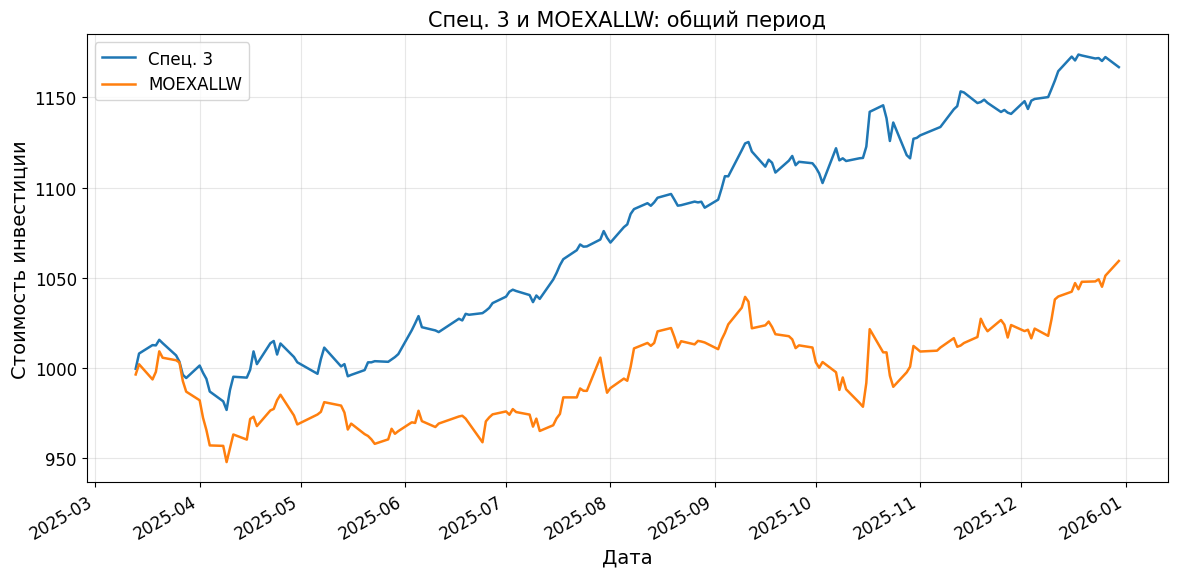

In [147]:
moexallw_prices = df_MOEXALLW.set_index("TRADEDATE")["CLOSE"].sort_index()
moexallw_daily = moexallw_prices.pct_change().dropna()

specifications_for_benchmark = {
    "Спец. 1": (portfolio_1_daily_returns, median_w1),
    "Спец. 2": (portfolio_2_daily_returns, median_w2),
    "Спец. 3": (portfolio_3_daily_returns, median_w3),
    "Спец. 4": (portfolio_4_daily_returns, median_w4),
}
benchmark_comparison = compare_specifications_to_benchmark(
    specifications_for_benchmark,
    moexallw_daily,
)
print("Сравнение спецификаций с MOEXALLW:")
benchmark_display = benchmark_comparison.copy()
benchmark_numeric_columns = benchmark_display.select_dtypes(include=[np.number]).columns
benchmark_display[benchmark_numeric_columns] = benchmark_display[
    benchmark_numeric_columns
].round(3)
print(benchmark_display.to_string())

recommended_common_idx = (
    portfolio_3_daily_returns.index.intersection(moexallw_daily.index).sort_values()
)
recommended_portfolio_returns = _portfolio_return_series(
    portfolio_3_daily_returns.loc[recommended_common_idx],
    median_w3,
)
recommended_statistics = calculate_benchmark_statistics(
    recommended_portfolio_returns,
    moexallw_daily.loc[recommended_common_idx],
)
print("\nСпец. 3 относительно MOEXALLW:")
print(pd.Series(recommended_statistics).to_string())

benchmark_figure = plot_benchmark_growth(
    recommended_portfolio_returns,
    moexallw_daily,
    portfolio_label="Спец. 3",
)
save_figure(benchmark_figure, "comparison_spec3_vs_moexallw")
_render_figure(benchmark_figure, show=True)

In [148]:
common_idx = (
    portfolio_3_daily_returns.index.intersection(moexallw_daily.index).sort_values()
)
spec3_daily = _portfolio_return_series(
    portfolio_3_daily_returns.loc[common_idx],
    median_w3,
)

spec3_common = spec3_daily.to_frame("Spec3")
moexallw_common = moexallw_daily.loc[common_idx].to_frame("MOEXALLW")

table_7_metrics = pd.DataFrame({
    "Спец. 3":  compute_all_metrics_for_weights(spec3_common,   np.array([1.0]), risk_free_rate, mar),
    "MOEXALLW": compute_all_metrics_for_weights(moexallw_common, np.array([1.0]), risk_free_rate, mar),
}).T
print(f"Общий период: {common_idx.min():%Y-%m-%d} — {common_idx.max():%Y-%m-%d}, {len(common_idx)} наблюдений")
print(table_7_metrics.round(4).to_string())

Общий период: 2025-03-13 — 2025-12-30, 161 наблюдений
             CAGR  Volatility  Sharpe  Sortino  Calmar     MDD  CVaR Ratio  Martin Ratio   Omega
Спец. 3   27.2937      8.0804  1.8443   2.7509  7.1396  3.8228      0.0659       17.5145  1.3376
MOEXALLW   9.4460     10.0689 -0.0035  -0.1509  1.5543  6.0772     -0.0001       -0.0400  0.9836


## 6. Проверка устойчивости диапазонов весов к набору метрик

Раздел проверяет, насколько диапазоны и медианные веса зависят от
состава метрик, включённых в агрегацию. Базовым остаётся фактический набор из
восьми метрик, использованный в основном анализе.

In [149]:
ALL_METRICS: tuple[str, ...] = CORE_METRICS_FOR_BOUNDS
BASE_METRIC_SET = "8 (базовый, с MDD)"
METRIC_SETS: dict[str, list[str]] = {
    BASE_METRIC_SET: list(ALL_METRICS),
    "7 (без MDD)": [
        "sharpe",
        "sortino",
        "calmar",
        "cvar_005",
        "martin",
        "omega",
        "volatility",
    ],
    "5 (узкий)": ["sharpe", "sortino", "calmar", "cvar_005", "martin"],
}


def validate_metric_set_configuration(
    core_metrics: Sequence[str],
    all_metrics: Sequence[str],
    metric_sets: Mapping[str, Sequence[str]],
    *,
    base_set: str,
) -> None:
    """Проверяет согласованность базового набора и альтернативных наборов метрик.

    Args:
        core_metrics: Метрики, применённые в основном расчёте bounds.
        all_metrics: Полный допустимый набор метрик.
        metric_sets: Наборы для robustness checks.
        base_set: Метка набора, соответствующего основному расчёту.

    Raises:
        ValueError: Если базовый набор не совпадает с основным расчётом
            либо альтернативный набор содержит неизвестную метрику.
        KeyError: Если базовый набор отсутствует.
    """
    if base_set not in metric_sets:
        raise KeyError(f"Unknown base metric set: {base_set}")
    if set(core_metrics) != set(metric_sets[base_set]):
        raise ValueError(
            "core_metrics_for_bounds must match the declared base metric set"
        )
    available_metrics = set(all_metrics)
    for set_name, metrics in metric_sets.items():
        if not set(metrics).issubset(available_metrics):
            raise ValueError(f"{set_name} contains unknown metrics")

def calculate_bounds_sensitivity(
    specifications: Mapping[str, tuple[Mapping[str, dict[str, Any]], Sequence[str]]],
    metric_sets: Mapping[str, Sequence[str]],
    *,
    aggregate_function: Callable[..., tuple[list[tuple[float, float]], pd.DataFrame, pd.DataFrame]]
    = aggregate_bounds_from_window_results,
) -> dict[str, dict[str, pd.DataFrame]]:
    """Агрегирует bounds для всех спецификаций и наборов метрик.

    Args:
        specifications: Спецификация -> результаты окон и порядок активов.
        metric_sets: Набор метрик для каждой альтернативы.
        aggregate_function: Функция агрегирования bounds.

    Returns:
        Вложенный словарь спецификация -> набор метрик -> таблица bounds.
    """
    result: dict[str, dict[str, pd.DataFrame]] = {}
    for specification_name, (analysis_results, asset_names) in specifications.items():
        result[specification_name] = {}
        for set_name, metrics in metric_sets.items():
            _, summary, _ = aggregate_function(
                analysis_results=analysis_results,
                asset_names=list(asset_names),
                metrics_to_use=list(metrics),
                lower_percentile=10,
                upper_percentile=90,
                successful_only=True,
            )
            result[specification_name][set_name] = summary
    return result

def build_bounds_shift_summary(
    sensitivity: Mapping[str, Mapping[str, pd.DataFrame]],
    *,
    base_set: str,
) -> pd.DataFrame:
    """Собирает максимальные сдвиги медианных весов от базового набора.

    Args:
        sensitivity: Результат calculate_bounds_sensitivity.
        base_set: Метка базового набора метрик.

    Returns:
        Таблица максимальных абсолютных сдвигов медианы по спецификациям.
    """
    rows: list[dict[str, str | float]] = []
    for specification_name, set_results in sensitivity.items():
        base = set_results[base_set].set_index("Asset")["Median_Weight"]
        for set_name, summary in set_results.items():
            if set_name == base_set:
                continue
            shift = summary.set_index("Asset")["Median_Weight"].sub(base)
            asset = str(shift.abs().idxmax())
            rows.append(
                {
                    "Спецификация": specification_name,
                    "Набор": set_name,
                    "Макс |сдвиг|, п.п.": float(shift.abs().max()),
                    "Актив с макс. сдвигом": asset,
                    "Знак сдвига": "+" if shift.loc[asset] > 0 else "-",
                    "Средняя ширина диапазона, п.п.": float(
                        summary["Range_Width"].mean()
                    ),
                }
            )
    return pd.DataFrame(rows)

def calculate_portfolio_metrics_by_set(
    bounds_by_set: Mapping[str, pd.DataFrame],
    asset_names: Sequence[str],
    portfolio_returns: pd.DataFrame,
    *,
    risk_free_rate: float,
    mar: float,
) -> pd.DataFrame:
    """Сравнивает метрики портфеля на медианных весах разных наборов.

    Args:
        bounds_by_set: Таблицы bounds одной спецификации по наборам метрик.
        asset_names: Порядок активов портфеля.
        portfolio_returns: Дневные доходности активов.
        risk_free_rate: Годовая безрисковая ставка.
        mar: Годовой MAR.

    Returns:
        Таблица метрик по набору агрегации.
    """
    metrics_by_set: dict[str, Mapping[str, float | str]] = {}
    for set_name, summary in bounds_by_set.items():
        median_weights = summary.set_index("Asset").loc[
            list(asset_names),
            "Median_Weight",
        ].to_numpy(dtype=float)
        normalized_weights = median_weights / median_weights.sum()
        metrics = dict(
            compute_all_metrics_for_weights(
                portfolio_returns,
                normalized_weights,
                risk_free_rate,
                mar,
            )
        )
        metrics["Веса (норм.), %"] = ", ".join(
            f"{weight * 100:.1f}" for weight in normalized_weights
        )
        metrics_by_set[set_name] = metrics
    return pd.DataFrame(metrics_by_set).T


def _equal_group_observation_weights(frame: pd.DataFrame) -> np.ndarray:
    """Даёт равную массу каждой доступной metric × grid конфигурации."""
    if "aggregation_group" not in frame:
        raise KeyError("pooled weights must contain aggregation_group")
    group_sizes = frame.groupby(
        "aggregation_group",
        observed=True,
    )["aggregation_group"].transform("size")
    n_groups = int(frame["aggregation_group"].nunique())
    if n_groups == 0:
        raise ValueError("No aggregation groups in selected subset")
    return (1.0 / (n_groups * group_sizes)).to_numpy(dtype=float)


def _weighted_asset_percentiles(
    frame: pd.DataFrame,
    asset_names: Sequence[str],
) -> dict[str, tuple[float, float, float]]:
    """Возвращает P10, медиану и P90 весов каждого актива в процентах."""
    observation_weights = _equal_group_observation_weights(frame)
    result: dict[str, tuple[float, float, float]] = {}
    for asset in asset_names:
        values = frame[f"w_{asset}"].to_numpy(dtype=float)
        p10, median, p90 = _weighted_quantile(
            values,
            [0.10, 0.50, 0.90],
            observation_weights,
        )
        result[asset] = (p10 * 100, median * 100, p90 * 100)
    return result


def build_weight_robustness_table(
    pooled_weights: pd.DataFrame,
    asset_names: Sequence[str],
) -> pd.DataFrame:
    """Сравнивает веса по длине/шагу окна и ранней/поздней подвыборкам."""
    required = {
        "aggregation_group",
        "window_years",
        "step_months",
        "window_start",
        "window_end",
        *(f"w_{asset}" for asset in asset_names),
    }
    missing = required.difference(pooled_weights.columns)
    if missing:
        raise KeyError(f"Missing robustness columns: {sorted(missing)}")

    frame = pooled_weights.copy()
    frame["window_start"] = pd.to_datetime(frame["window_start"])
    frame["window_end"] = pd.to_datetime(frame["window_end"])
    frame["window_midpoint"] = (
        frame["window_start"]
        + (frame["window_end"] - frame["window_start"]) / 2
    )
    unique_windows = frame[
        ["window_start", "window_end", "window_midpoint"]
    ].drop_duplicates()
    split_date = pd.Timestamp(unique_windows["window_midpoint"].median())
    frame["subperiod"] = np.where(
        frame["window_midpoint"] <= split_date,
        "Ранняя",
        "Поздняя",
    )

    baseline = _weighted_asset_percentiles(frame, asset_names)
    scenarios: list[tuple[str, str, pd.DataFrame]] = []
    for value in sorted(frame["window_years"].dropna().unique()):
        scenarios.append(
            (
                "Длина окна",
                f"{int(value)} года",
                frame[frame["window_years"].eq(value)],
            )
        )
    for value in sorted(frame["step_months"].dropna().unique()):
        scenarios.append(
            (
                "Шаг окна",
                f"{int(value)} мес.",
                frame[frame["step_months"].eq(value)],
            )
        )
    for label in ("Ранняя", "Поздняя"):
        scenarios.append(
            (
                "Подвыборка",
                label,
                frame[frame["subperiod"].eq(label)],
            )
        )

    rows: list[dict[str, Any]] = []
    for dimension, scenario, subset in scenarios:
        if subset.empty:
            continue
        scenario_stats = _weighted_asset_percentiles(subset, asset_names)
        median_shifts = {
            asset: scenario_stats[asset][1] - baseline[asset][1]
            for asset in asset_names
        }
        max_shift_asset = max(median_shifts, key=lambda asset: abs(median_shifts[asset]))
        max_abs_shift = abs(median_shifts[max_shift_asset])

        for asset in asset_names:
            p10, median, p90 = scenario_stats[asset]
            base_p10, base_median, base_p90 = baseline[asset]
            rows.append(
                {
                    "Измерение": dimension,
                    "Сценарий": scenario,
                    "Граница ранней/поздней": (
                        split_date if dimension == "Подвыборка" else pd.NaT
                    ),
                    "Актив": asset,
                    "P10, %": p10,
                    "Медиана, %": median,
                    "P90, %": p90,
                    "ΔP10, п.п.": p10 - base_p10,
                    "ΔМедиана, п.п.": median - base_median,
                    "ΔP90, п.п.": p90 - base_p90,
                    "Макс |Δмедиана| сценария, п.п.": max_abs_shift,
                    "Актив с макс. сдвигом": max_shift_asset,
                    "N оконных решений": int(len(subset)),
                    "N равновзвешенных групп": int(
                        subset["aggregation_group"].nunique()
                    ),
                }
            )

    result = pd.DataFrame(rows)
    numeric_columns = result.select_dtypes(include=[np.number]).columns
    result[numeric_columns] = result[numeric_columns].round(4)
    return result

In [150]:
def test_block_6_validates_base_metric_set() -> None:
    validate_metric_set_configuration(
        ["a", "b"],
        ["a", "b", "c"],
        {"base": ["a", "b"], "alternative": ["a"]},
        base_set="base",
    )

    with pytest.raises(ValueError):
        validate_metric_set_configuration(
            ["a"],
            ["a", "b"],
            {"base": ["a", "b"]},
            base_set="base",
        )

def test_block_6_calculates_bounds_shift_summary() -> None:
    summary_base = pd.DataFrame(
        {
            "Asset": ["A", "B"],
            "Median_Weight": [40.0, 60.0],
            "Range_Width": [10.0, 20.0],
        }
    )
    summary_alt = pd.DataFrame(
        {
            "Asset": ["A", "B"],
            "Median_Weight": [45.0, 55.0],
            "Range_Width": [12.0, 18.0],
        }
    )

    result = build_bounds_shift_summary(
        {"Spec": {"base": summary_base, "alt": summary_alt}},
        base_set="base",
    )

    assert result.loc[0, "Макс |сдвиг|, п.п."] == pytest.approx(5.0)
    assert result.loc[0, "Актив с макс. сдвигом"] == "A"

In [151]:
run_notebook_tests("test_block_6")

..                                                                                           [100%]


0

In [152]:
validate_metric_set_configuration(
    core_metrics_for_bounds,
    ALL_METRICS,
    METRIC_SETS,
    base_set=BASE_METRIC_SET,
)

all_specifications_for_sensitivity = {
    "Спец. 1": (analysis_results_1, asset_names_1),
    "Спец. 2": (analysis_results_2, asset_names_2),
    "Спец. 3": (analysis_results_3, asset_names_3),
    "Спец. 4": (analysis_results_4, asset_names_4),
}
bounds_sensitivity = calculate_bounds_sensitivity(
    all_specifications_for_sensitivity,
    METRIC_SETS,
)
bounds_shift_summary = build_bounds_shift_summary(
    bounds_sensitivity,
    base_set=BASE_METRIC_SET,
)

print("Сдвиг медианных весов относительно базового набора:")
print(bounds_shift_summary.round(2).to_string(index=False))

spec3_bounds_by_set = bounds_sensitivity["Спец. 3"]
spec3_medians = pd.DataFrame(
    {
        set_name: summary.set_index("Asset")["Median_Weight"]
        for set_name, summary in spec3_bounds_by_set.items()
    }
)
print("\nСпец. 3: нормированные компонентные медианы, %:")
print(spec3_medians.round(2).to_string())

portfolio_metrics_by_set = calculate_portfolio_metrics_by_set(
    spec3_bounds_by_set,
    asset_names_3,
    portfolio_3_daily_returns,
    risk_free_rate=risk_free_rate,
    mar=mar,
)
metric_columns = [
    "CAGR",
    "Volatility",
    "Sharpe",
    "Sortino",
    "Calmar",
    "MDD",
    "Martin Ratio",
    "Omega",
]
print("\nСпец. 3: метрики на медианных весах:")
print(portfolio_metrics_by_set[metric_columns].round(3).to_string())

metric_ranges = (
    portfolio_metrics_by_set[metric_columns]
    .astype(float)
    .agg(lambda values: values.max() - values.min())
)
print("\nРазмах метрик между наборами:")
print(metric_ranges.round(3).to_string())


bounds_sensitivity_detailed = pd.concat(
    [
        summary.assign(
            Спецификация=specification_name,
            Набор=set_name,
        )
        for specification_name, sets in bounds_sensitivity.items()
        for set_name, summary in sets.items()
    ],
    ignore_index=True,
)
diagnostic_columns = [
    "Спецификация",
    "Набор",
    *(
        column
        for column in bounds_sensitivity_detailed.columns
        if column not in {"Спецификация", "Набор"}
    ),
]
bounds_sensitivity_detailed = bounds_sensitivity_detailed[diagnostic_columns]


weight_robustness = pd.concat(
    [
        build_weight_robustness_table(pool, asset_names).assign(
            Спецификация=specification_name
        )
        for specification_name, pool, asset_names in (
            ("Спец. 1", pooled_weights_1, asset_names_1),
            ("Спец. 2", pooled_weights_2, asset_names_2),
            ("Спец. 3", pooled_weights_3, asset_names_3),
            ("Спец. 4", pooled_weights_4, asset_names_4),
        )
    ],
    ignore_index=True,
)
robustness_columns = [
    "Спецификация",
    *(column for column in weight_robustness.columns if column != "Спецификация"),
]
weight_robustness = weight_robustness[robustness_columns]

print("\nМаксимальные сдвиги медианных весов по сценариям:")
print(
    weight_robustness[
        [
            "Спецификация",
            "Измерение",
            "Сценарий",
            "Макс |Δмедиана| сценария, п.п.",
            "Актив с макс. сдвигом",
        ]
    ]
    .drop_duplicates()
    .round(3)
    .to_string(index=False)
)

Сдвиг медианных весов относительно базового набора:
Спецификация       Набор  Макс |сдвиг|, п.п. Актив с макс. сдвигом Знак сдвига  Средняя ширина диапазона, п.п.
     Спец. 1 7 (без MDD)                8.88               RUABITR           -                           57.59
     Спец. 1   5 (узкий)               15.59               RUABITR           -                           58.35
     Спец. 2 7 (без MDD)               10.98                RGBITR           -                           56.34
     Спец. 2   5 (узкий)               14.53                RGBITR           -                           57.07
     Спец. 3 7 (без MDD)                8.52             RUGBITR3Y           -                           53.15
     Спец. 3   5 (узкий)               11.68            RUGBITR10Y           -                           53.02
     Спец. 4 7 (без MDD)                8.82             RUGBITR3Y           -                           52.88
     Спец. 4   5 (узкий)               13.25            GLDR

In [153]:
# Сдвиги границ P10/P90 при смене набора метрик — для утверждения раздела 3.3
boundary_shifts = []
for spec_name, sets in bounds_sensitivity.items():
    base = sets[BASE_METRIC_SET].set_index("Asset")
    for set_name, summary in sets.items():
        if set_name == BASE_METRIC_SET:
            continue
        current = summary.set_index("Asset")
        dP10_series = (current["P10_Weight"] - base["P10_Weight"]).abs()
        dP90_series = (current["P90_Weight"] - base["P90_Weight"]).abs()
        boundary_shifts.append({
            "Спецификация": spec_name,
            "Набор": set_name,
            "Макс |ΔP10|, п.п.": dP10_series.max(),
            "Актив (P10)": dP10_series.idxmax(),
            "Макс |ΔP90|, п.п.": dP90_series.max(),
            "Актив (P90)": dP90_series.idxmax(),
        })
boundary_shifts_df = pd.DataFrame(boundary_shifts)
print("Сдвиги границ диапазонов при смене набора метрик:")
print(boundary_shifts_df.round(2).to_string(index=False))
print(f"\nМаксимальный сдвиг любой границы: "
      f"{boundary_shifts_df[['Макс |ΔP10|, п.п.', 'Макс |ΔP90|, п.п.']].values.max():.2f} п.п.")

Сдвиги границ диапазонов при смене набора метрик:
Спецификация       Набор  Макс |ΔP10|, п.п. Актив (P10)  Макс |ΔP90|, п.п. Актив (P90)
     Спец. 1 7 (без MDD)               2.30  GLDRUB_TOM               2.31       MCFTR
     Спец. 1   5 (узкий)               3.70  GLDRUB_TOM               3.20       MCFTR
     Спец. 2 7 (без MDD)               2.00  GLDRUB_TOM               1.87       MCFTR
     Спец. 2   5 (узкий)               2.95  GLDRUB_TOM               3.11       MCFTR
     Спец. 3 7 (без MDD)               0.97  GLDRUB_TOM               1.31       MCFTR
     Спец. 3   5 (узкий)               0.97  GLDRUB_TOM               2.49       MCFTR
     Спец. 4 7 (без MDD)               0.46  GLDRUB_TOM               2.23  RUGBITR10Y
     Спец. 4   5 (узкий)               0.46  GLDRUB_TOM               1.80      MEBCTR

Максимальный сдвиг любой границы: 3.70 п.п.


## 7. Обзор литературы: временная карта источников

Визуализация группирует ключевые работы по направлениям исследования. Она дополняет библиографию, но не заменяет полный список источников в тексте работы.

In [154]:
_CAT_RU = {
    "Теория портфеля":           "#1565C0",
    "Устойчивая оптимизация":    "#E65100",
    "Risk Parity / All-Weather": "#2E7D32",
    "Метрики эффективности":     "#6A0DAD",
    "Эконометрика":              "#C62828",
    "Золото и защитные активы":  "#F57F17",
    "Российский рынок":          "#AD1457",
}

_PAPERS_RU = [
    (1930, "Fisher",                "Теория портфеля"),
    (1952, "Markowitz",             "Теория портфеля"),
    (1958, "Tobin",                 "Теория портфеля"),
    (1969, "Samuelson",             "Теория портфеля"),
    (1969, "Merton\n(lifetime)",    "Теория портфеля"),
    (1973, "Merton\n(ICAPM)",       "Теория портфеля"),
    (2002, "Campbell,\nViceira",    "Теория портфеля"),
    (2012, "Damodaran",             "Теория портфеля"),
    (1986, "Jorion",                "Устойчивая оптимизация"),
    (1989, "Michaud",               "Устойчивая оптимизация"),
    (1991, "Best,\nGrauer",         "Устойчивая оптимизация"),
    (1992, "Black,\nLitterman",     "Устойчивая оптимизация"),
    (1993, "Chopra,\nZiemba",       "Устойчивая оптимизация"),
    (2003, "Goldfarb,\nIyengar",    "Устойчивая оптимизация"),
    (2003, "Jagannathan,\nMa",      "Устойчивая оптимизация"),
    (2004, "Ledoit,\nWolf",         "Устойчивая оптимизация"),
    (2009, "DeMiguel\net al.",      "Устойчивая оптимизация"),
    (2008, "Choueifaty,\nCoignard", "Risk Parity / All-Weather"),
    (2010, "Maillard\net al.",      "Risk Parity / All-Weather"),
    (2011, "Qian",                  "Risk Parity / All-Weather"),
    (2011, "Bridgewater\n(Eng.)",   "Risk Parity / All-Weather"),
    (2012, "Asness\net al.",        "Risk Parity / All-Weather"),
    (2012, "Bridgewater\n(Story)",  "Risk Parity / All-Weather"),
    (2013, "Roncalli",              "Risk Parity / All-Weather"),
    (2014, "Ang",                   "Risk Parity / All-Weather"),
    (2016, "Roncalli,\nWeisang",    "Risk Parity / All-Weather"),
    (1966, "Sharpe\n(1966)",        "Метрики эффективности"),
    (1989, "Martin,\nMcCann",       "Метрики эффективности"),
    (1991, "Sortino,\nvan der Meer","Метрики эффективности"),
    (1993, "Rom,\nFerguson",        "Метрики эффективности"),
    (1994, "Sharpe\n(1994)",        "Метрики эффективности"),
    (1994, "Sortino,\nPrice",       "Метрики эффективности"),
    (1999, "Artzner\net al.",       "Метрики эффективности"),
    (2000, "Rockafellar,\nUryasev", "Метрики эффективности"),
    (2002, "Lo",                    "Метрики эффективности"),
    (2002, "Keating,\nShadwick",    "Метрики эффективности"),
    (2004, "Ehrgott\net al.",       "Метрики эффективности"),
    (2005, "Chekhlov\net al.",      "Метрики эффективности"),
    (2007, "Eling,\nSchuhmacher",   "Метрики эффективности"),
    (2021, "Bacon",                 "Метрики эффективности"),
    (1950, "Durbin,\nWatson",       "Эконометрика"),
    (1965, "Shapiro,\nWilk",        "Эконометрика"),
    (1979, "Dickey,\nFuller",       "Эконометрика"),
    (1979, "Breusch,\nPagan",       "Эконометрика"),
    (1980, "Jarque,\nBera",         "Эконометрика"),
    (1980, "White",                 "Эконометрика"),
    (1992, "KPSS",                  "Эконометрика"),
    (1994, "Newey,\nWest",          "Эконометрика"),
    (2013, "James\net al.",         "Эконометрика"),
    (2010, "Baur,\nLucey",          "Золото и защитные активы"),
    (2013, "Erb,\nHarvey",          "Золото и защитные активы"),
    (2017, "Teplova,\nSokolova",    "Российский рынок"),
    (2018, "Asaturov",              "Российский рынок"),
    (2019, "Redkin",                "Российский рынок"),
]




def build_compressed_year_positions(
    papers: Sequence[tuple[int, str, str]],
    *,
    min_gap: float = 2.0,
    scale: float = 0.4,
) -> dict[int, float]:
    """Строит нелинейные координаты лет для компактной временной шкалы.

    Args:
        papers: Тройки год, подпись и категория источника.
        min_gap: Минимальный интервал между соседними годами на оси.
        scale: Множитель реального временного интервала.

    Returns:
        Словарь год -> координата на сжатой оси.

    Raises:
        ValueError: Если список источников пуст.
    """
    years = sorted({year for year, _, _ in papers})
    if not years:
        raise ValueError("papers must not be empty")

    positions = {years[0]: 0.0}
    current_position = 0.0
    for previous_year, year in zip(years, years[1:]):
        current_position += max(min_gap, (year - previous_year) * scale)
        positions[year] = current_position
    return positions

def interpolate_year_position(year: int, year_positions: Mapping[int, float]) -> float:
    """Интерполирует координату произвольного года на сжатой шкале.

    Args:
        year: Год для размещения.
        year_positions: Координаты опорных лет.

    Returns:
        Координата года на шкале.
    """
    years = sorted(year_positions)
    if year <= years[0]:
        return year_positions[years[0]]
    if year >= years[-1]:
        return year_positions[years[-1]]
    for left_year, right_year in zip(years, years[1:]):
        if left_year <= year <= right_year:
            ratio = (year - left_year) / (right_year - left_year)
            return year_positions[left_year] + ratio * (
                year_positions[right_year] - year_positions[left_year]
            )
    raise ValueError("year interpolation failed")

def assign_timeline_levels(
    papers: Sequence[tuple[int, str, str]],
    *,
    year_gap: int = 3,
) -> list[tuple[int, str, str, int]]:
    """Назначает вертикальные уровни, предотвращая наложение подписей.

    Args:
        papers: Тройки год, подпись и категория источника.
        year_gap: Минимальная разница лет для повторного использования уровня.

    Returns:
        Четвёрки год, подпись, категория и вертикальный уровень.
    """
    placed: list[tuple[int, int]] = []
    result: list[tuple[int, str, str, int]] = []
    for year, label, category in sorted(papers, key=lambda item: (item[0], item[2])):
        blocked_levels = {
            level for placed_year, level in placed if abs(year - placed_year) < year_gap
        }
        level = 1
        while level in blocked_levels:
            level += 1
        placed.append((year, level))
        result.append((year, label, category, level))
    return result

def plot_literature_timeline(
    papers: Sequence[tuple[int, str, str]],
    category_colors: Mapping[str, str],
) -> Figure:
    """Строит временную карту ключевых источников исследования.

    Args:
        papers: Тройки год, подпись и тематическая категория.
        category_colors: Цвет для каждой тематической категории.

    Returns:
        Фигура Matplotlib, готовая к сохранению и отображению.
    """
    year_positions = build_compressed_year_positions(papers)
    positioned_papers = assign_timeline_levels(papers)
    max_level = max(level for _, _, _, level in positioned_papers)
    level_step = 0.60

    figure, axis = plt.subplots(figsize=(22, max_level * level_step + 3.6))
    figure.patch.set_facecolor("#FFFFFF")
    axis.set_facecolor("#F5F7FA")
    axis.set_xlim(year_positions[min(year_positions)] - 1.5, year_positions[max(year_positions)] + 2.5)
    axis.set_ylim(-1.2, (max_level + 1.9) * level_step)
    axis.axis("off")
    axis.axhline(0, color="#1C1C1C", linewidth=2.5, zorder=5)

    for year in range(1930, 2030, 10):
        x_position = interpolate_year_position(year, year_positions)
        axis.plot(x_position, 0, "|", color="#1C1C1C", markersize=10, markeredgewidth=1.8)
        axis.text(x_position, -0.23, str(year), ha="center", va="top", fontsize=9)

    for year, label, category, level in positioned_papers:
        x_position = year_positions[year]
        y_position = level * level_step
        color = category_colors[category]
        axis.plot(
            [x_position, x_position],
            [0.05, y_position - 0.11],
            linestyle="--",
            color=color,
            linewidth=0.85,
            alpha=0.45,
        )
        axis.scatter(x_position, y_position, s=50, color=color, edgecolors="white", linewidths=1.2)
        axis.text(
            x_position,
            y_position + 0.10,
            label,
            ha="center",
            va="bottom",
            fontsize=6.2,
            color="#111111",
            linespacing=1.2,
            multialignment="center",
        )

    handles = [
        mpatches.Patch(color=color, label=category)
        for category, color in category_colors.items()
    ]
    axis.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.14),
        ncol=4,
        fontsize=8.5,
        frameon=True,
    )
    axis.set_title("Временная карта ключевых научных источников", fontsize=13, fontweight="bold")
    figure.tight_layout(pad=1.5)
    return figure

In [155]:
def test_block_7_builds_compressed_year_positions() -> None:
    papers = [(2000, "A", "x"), (2010, "B", "x"), (2011, "C", "x")]

    positions = build_compressed_year_positions(papers, min_gap=2.0, scale=0.4)

    assert positions[2010] - positions[2000] == pytest.approx(4.0)
    assert positions[2011] - positions[2010] == pytest.approx(2.0)

def test_block_7_assigns_distinct_levels_to_nearby_sources() -> None:
    papers = [(2020, "A", "x"), (2021, "B", "x"), (2025, "C", "x")]

    positioned = assign_timeline_levels(papers, year_gap=3)

    assert positioned[0][3] != positioned[1][3]
    assert positioned[2][3] == 1

In [156]:
run_notebook_tests("test_block_7")

..                                                                                           [100%]


0

Сохранено: figures\bibliography_timeline_pptx.png


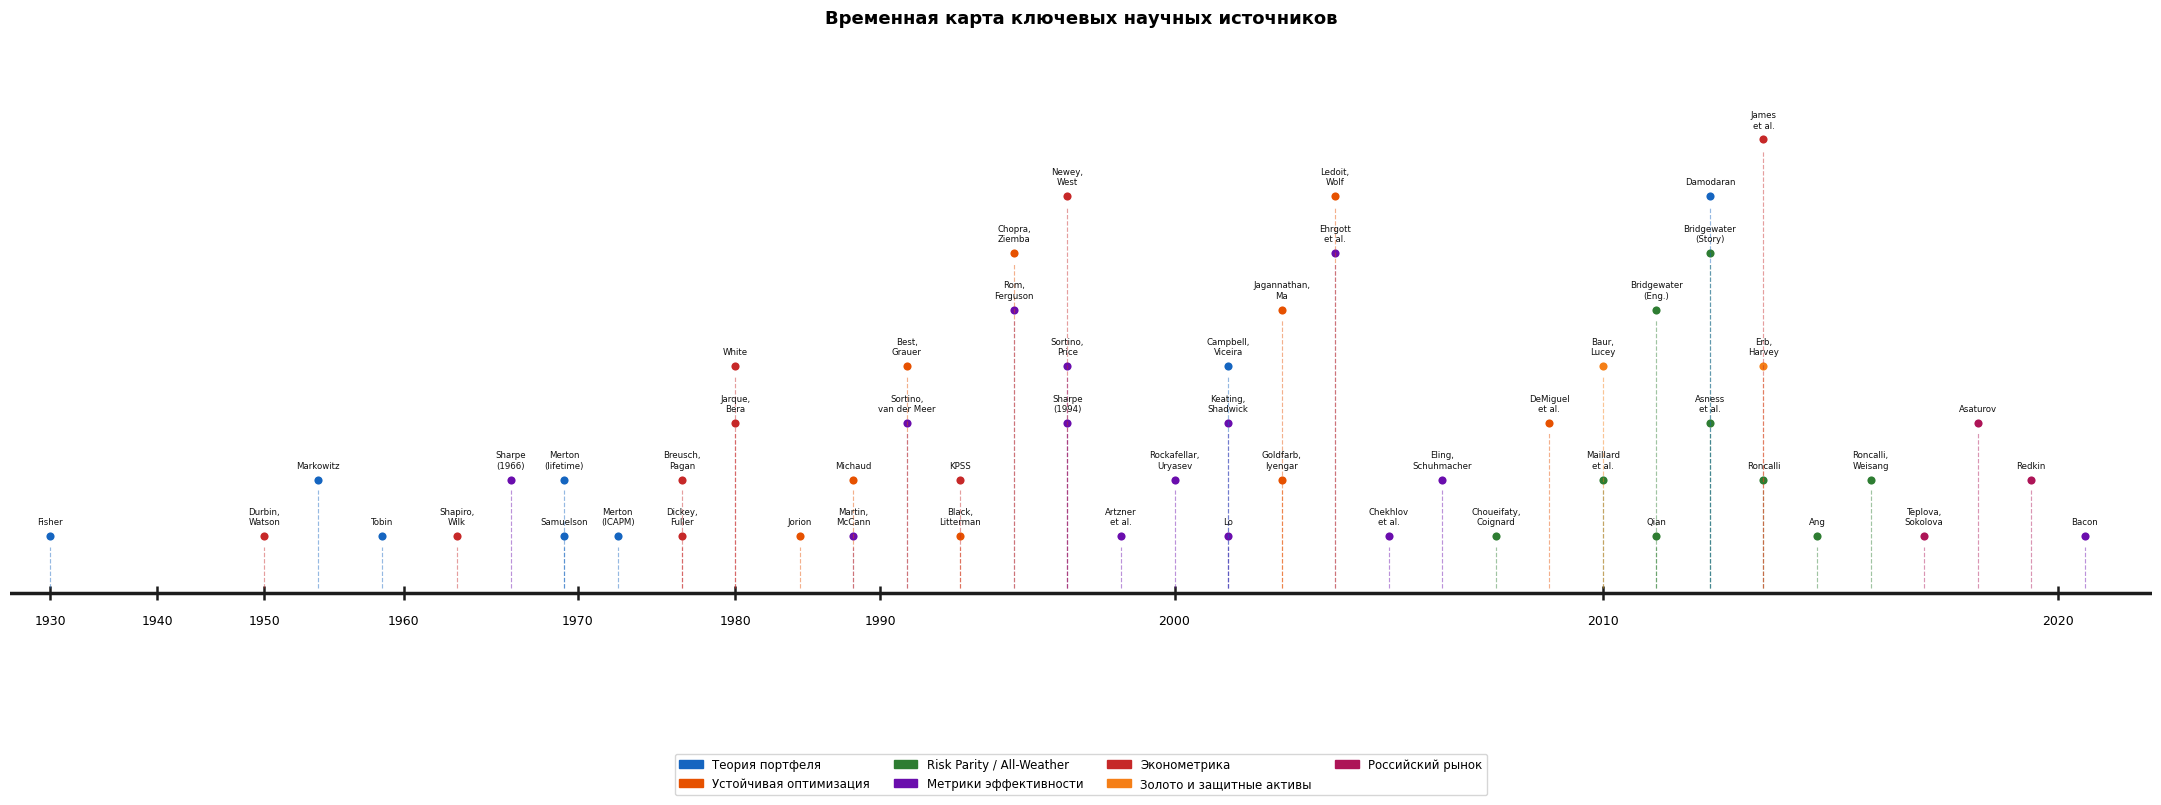

In [157]:
literature_timeline_figure = plot_literature_timeline(_PAPERS_RU, _CAT_RU)
save_figure(literature_timeline_figure, "bibliography_timeline_pptx", dpi=300, fmt="png")
_render_figure(literature_timeline_figure, show=True)

## 8. Дополнительные диагностические материалы

In [158]:
def summarize_asset_correlations(
    asset_returns: pd.DataFrame,
    *,
    reference_asset: str = "GLDRUB_TOM",
) -> tuple[pd.DataFrame, pd.Series]:
    """Вычисляет корреляционную матрицу и связи выбранного актива с остальными.

    Args:
        asset_returns: Дневные доходности активов.
        reference_asset: Актив, для которого нужна отдельная строка корреляций.

    Returns:
        Полная корреляционная матрица и корреляции reference_asset с остальными.

    Raises:
        KeyError: Если reference_asset отсутствует среди столбцов.
    """
    if reference_asset not in asset_returns.columns:
        raise KeyError(f"Unknown reference asset: {reference_asset}")
    correlation = asset_returns.corr()
    return correlation, correlation[reference_asset].drop(reference_asset)

def plot_asset_correlation(correlation: pd.DataFrame) -> Figure:
    """Строит тепловую карту корреляций доходностей активов.

    Args:
        correlation: Квадратная корреляционная матрица.

    Returns:
        Готовая фигура Matplotlib.
    """
    figure, axis = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8, "label": "Корреляция"},
        ax=axis,
    )
    axis.set_title("Корреляция дневных доходностей активов")
    figure.tight_layout()
    return figure

def calculate_yield_curve_spread(
    yield_curve: pd.DataFrame,
    *,
    short_column: str = "yield_1Y",
    long_column: str = "yield_10Y",
) -> pd.Series:
    """Рассчитывает спред длинного и короткого сегментов кривой ОФЗ.

    Args:
        yield_curve: Кривая доходности с временным индексом.
        short_column: Столбец короткого сегмента.
        long_column: Столбец длинного сегмента.

    Returns:
        Ряд long - short в процентных пунктах.

    Raises:
        KeyError: Если не найдены требуемые столбцы.
    """
    required_columns = {short_column, long_column}
    missing_columns = required_columns.difference(yield_curve.columns)
    if missing_columns:
        raise KeyError(f"Missing yield curve columns: {sorted(missing_columns)}")
    return yield_curve[long_column] - yield_curve[short_column]

def summarize_yield_curve_spread(spread: pd.Series) -> pd.Series:
    """Собирает описательные статистики спреда кривой доходности.

    Args:
        spread: Временной ряд long-short.

    Returns:
        Серия с ключевыми характеристиками спреда.
    """
    return pd.Series(
        {
            "Среднее, п.п.": spread.mean(),
            "Медиана, п.п.": spread.median(),
            "Минимум, п.п.": spread.min(),
            "Максимум, п.п.": spread.max(),
            "Стандартное отклонение, п.п.": spread.std(),
            "Доля инверсии, %": (spread < 0).mean() * 100,
        }
    )

def plot_yield_curve_spread(spread: pd.Series) -> Figure:
    """Строит временной ряд спреда 10Y-1Y и выделяет периоды инверсии.

    Args:
        spread: Временной ряд спреда в процентных пунктах.

    Returns:
        Фигура Matplotlib.
    """
    figure, axis = plt.subplots(figsize=(11, 4))
    axis.plot(spread.index, spread.to_numpy(), lw=1, color="steelblue")
    axis.axhline(0, color="red", linestyle="--", lw=1, label="Плоская кривая")
    axis.axhline(spread.mean(), color="green", linestyle=":", lw=1.3, label="Среднее")
    axis.fill_between(
        spread.index,
        spread.to_numpy(),
        0,
        where=spread.to_numpy() < 0,
        color="red",
        alpha=0.15,
        label="Инверсия",
    )
    axis.set_title("Спред бескупонной кривой ОФЗ: 10Y - 1Y")
    axis.set_xlabel("Дата")
    axis.set_ylabel("Спред, п.п.")
    axis.legend(loc="best", fontsize=9)
    axis.grid(alpha=0.3)
    figure.tight_layout()
    return figure

In [159]:
def test_block_8_summarizes_asset_correlations() -> None:
    returns = pd.DataFrame(
        {
            "A": [0.01, 0.02, 0.03],
            "GLDRUB_TOM": [0.02, 0.04, 0.06],
        }
    )

    correlation, gold_correlation = summarize_asset_correlations(returns)

    assert correlation.loc["A", "GLDRUB_TOM"] == pytest.approx(1.0)
    assert gold_correlation.index.tolist() == ["A"]

def test_block_8_calculates_yield_curve_spread() -> None:
    curve = pd.DataFrame({"yield_1Y": [7.0, 8.0], "yield_10Y": [8.5, 7.5]})

    spread = calculate_yield_curve_spread(curve)
    summary = summarize_yield_curve_spread(spread)

    assert spread.tolist() == [1.5, -0.5]
    assert summary["Доля инверсии, %"] == pytest.approx(50.0)

In [160]:
run_notebook_tests("test_block_8")

..                                                                                           [100%]


0

Корреляционная матрица Спец. 3:
            MCFTR  RUGBITR3Y  RUGBITR10Y  GLDRUB_TOM
MCFTR        1.00       0.50        0.54       -0.01
RUGBITR3Y    0.50       1.00        0.79       -0.04
RUGBITR10Y   0.54       0.79        1.00       -0.13
GLDRUB_TOM  -0.01      -0.04       -0.13        1.00

Золото и остальные активы:
MCFTR        -0.01
RUGBITR3Y    -0.04
RUGBITR10Y   -0.13
Сохранено: figures\asset_correlation_spec3.pdf


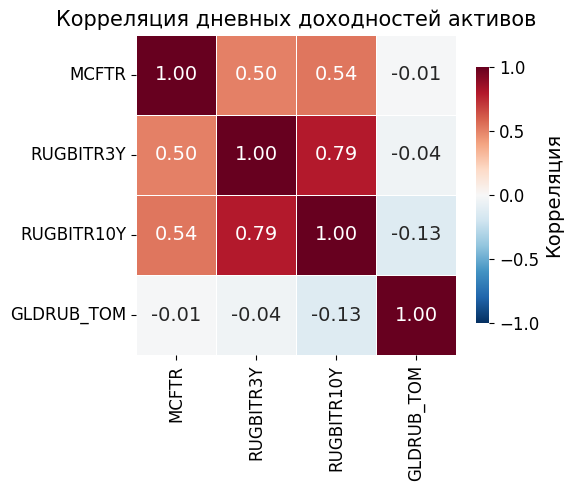


Спред кривой ОФЗ 10Y - 1Y:
Среднее, п.п.                    0.23
Медиана, п.п.                    0.36
Минимум, п.п.                   -6.69
Максимум, п.п.                   3.66
Стандартное отклонение, п.п.     1.58
Доля инверсии, %                39.84
Сохранено: figures\gcurve_spread_10_1.pdf


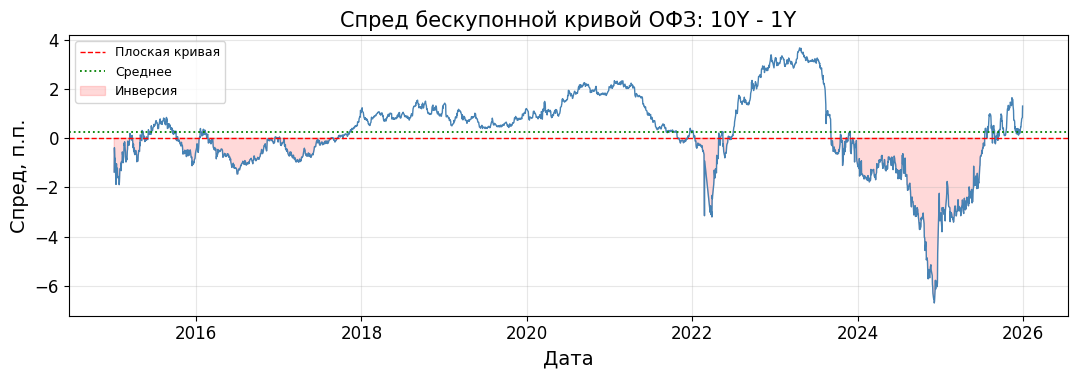

In [161]:
assets_spec3 = portfolio_3_daily_returns[asset_names_3]
asset_correlation, gold_correlation = summarize_asset_correlations(assets_spec3)

print("Корреляционная матрица Спец. 3:")
print(asset_correlation.round(2).to_string())
print("\nЗолото и остальные активы:")
print(gold_correlation.round(2).to_string())

asset_correlation_figure = plot_asset_correlation(asset_correlation)
save_figure(asset_correlation_figure, "asset_correlation_spec3")
_render_figure(asset_correlation_figure, show=True)

yield_curve_spread = calculate_yield_curve_spread(df_gcurve)
spread_summary = summarize_yield_curve_spread(yield_curve_spread)
print("\nСпред кривой ОФЗ 10Y - 1Y:")
print(spread_summary.round(2).to_string())

spread_figure = plot_yield_curve_spread(yield_curve_spread)
save_figure(spread_figure, "gcurve_spread_10_1")
_render_figure(spread_figure, show=True)

In [162]:
initial_value = 1000.0

g1 = (
    initial_value * cumulative_returns_3
).rename_axis("Дата").reset_index()

g2 = spec_values.rename_axis("Дата").reset_index()

g3 = asset_values.rename_axis("Дата").reset_index()

g4 = (
    strategy_values
    .rename(columns={
        "Далио оригинал": "Адаптированная аллокация Bridgewater",
        "Депозит (макс.)": "Депозит"
    })
    .rename_axis("Дата")
    .reset_index()
)

benchmark_returns = pd.concat(
    [
        recommended_portfolio_returns.rename("Спец. 3"),
        moexallw_daily.rename("MOEXALLW"),
    ],
    axis=1,
).dropna()

g5 = (
    initial_value * (1 + benchmark_returns).cumprod()
).rename_axis("Дата").reset_index()

weight_rows = []

for spec_name, asset_names, weights in [
    ("Спец. 1", asset_names_1, median_w1),
    ("Спец. 2", asset_names_2, median_w2),
    ("Спец. 3", asset_names_3, median_w3),
    ("Спец. 4", asset_names_4, median_w4),
]:
    for asset, weight in zip(asset_names, weights):
        weight_rows.append({
            "Портфель": spec_name,
            "Актив": asset,
            "Вес": float(weight),
            "Вес, %": float(weight * 100),
        })

weights_excel = pd.DataFrame(weight_rows)

with pd.ExcelWriter(
    "Данные_для_графиков_статьи.xlsx",
    engine="openpyxl"
) as writer:
    g1.to_excel(writer, sheet_name="G1_Активы", index=False)
    g2.to_excel(writer, sheet_name="G2_Спецификации", index=False)
    g3.to_excel(writer, sheet_name="G3_Активы_сравнение", index=False)
    g4.to_excel(writer, sheet_name="G4_Стратегии", index=False)
    g5.to_excel(writer, sheet_name="G5_MOEXALLW", index=False)
    weights_excel.to_excel(writer, sheet_name="Веса", index=False)

    descriptive_statistics_assets.to_excel(
        writer,
        sheet_name="Описательная",
        index=False,
    )
    risk_free_sensitivity.to_excel(
        writer,
        sheet_name="RF_чувствительность",
        index=False,
    )
    bounds_shift_summary.to_excel(
        writer,
        sheet_name="Наборы_метрик",
        index=False,
    )
    bounds_sensitivity_detailed.to_excel(
        writer,
        sheet_name="Медианы_диагностика",
        index=False,
    )
    portfolio_metrics_by_set.reset_index(names="Набор").to_excel(
        writer,
        sheet_name="Метрики_наборов",
        index=False,
    )
    weight_robustness.to_excel(
        writer,
        sheet_name="Устойчивость_весов",
        index=False,
    )

C:\Users\Lev\AppData\Local\Temp\ipykernel_13688\205356160.py:21: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  benchmark_returns = pd.concat(
